# L1+L6: Perfect Metal + Surface Kinetics — Analysis Notebook

**Physics:**
- Surface dissociation/recombination at the gas–metal interface (L6)
- Bulk lattice diffusion of atomic H through a perfect metal (L1)
- No oxide layer

**Two competing resistances:**
- $R_{surface} \sim 1 / (k_{diss} \cdot P_{up} \cdot (1-\theta)^2)$
- $R_{metal} = L_m / (D_m \cdot K_{s,m})$

**Key physics question:** At what pressure and temperature does the rate-limiting step shift from surface dissociation to bulk diffusion?


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os
import sys

# Add parent directory to path
parent_dir = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

In [2]:
# =============================================================================
# CELL 1 — SETUP
# Run once. All imports and helper functions.
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import brentq
import pandas as pd
from itertools import groupby
from operator import itemgetter
from IPython.display import display

from calculations.surface_kinetics import solve_steady_state_flux_L1L6
from calculations.config.model_config import (
    R, F,
    METALS, CONDITIONS, VALIDATION,
    PLOT_STYLE as STYLE,
    CURVE_STYLES,
    apply_style,
    build_simulation_config,
)

# ── Simulation config ────────────────────────────────────────────────────────
SIM       = build_simulation_config(
    metal='metal_X40_NiCrAlTi_31_19_Incoloy802_Schmidt1985',
    oxide='Cr2O3_sample4',
    T_operating=873,
    P_upstream=1e5,
    L_metal=1e-3,
)

METAL_KEY = SIM['metal_name']
METAL     = METALS[METAL_KEY]
SK        = METAL['surface_kinetics']     # surface kinetics sub-dict

# ── Pressure sweep (matches widget range) ────────────────────────────────────
P_RANGE_ARR = np.logspace(
    np.log10(CONDITIONS['P_range'][0]),
    np.log10(CONDITIONS['P_range'][1]),
    CONDITIONS['n_P_points']
)   #np.logspace(-3, 12, 100)
P_DOWN      = SIM['P_downstream']         # Pa
T_RANGE     = CONDITIONS['T_range']       # K
N_T         = CONDITIONS['n_T_points']

# ── Arrhenius helper functions ───────────────────────────────────────────────
def get_k_diss_at_T(T_K):
    """k_diss at temperature T_K via Arrhenius from config."""
    return SK['k_diss_metal_ref'] * np.exp(
        (-SK['E_diss_metal'] / R) * (1/T_K - 1/SK['T_ref'])
    )

def get_K_eq_at_T(T_K):
    """K_eq at temperature T_K via van't Hoff from config."""
    return SK['K_eq_metal_ref'] * np.exp(
        (-SK['H_eq_metal'] / R) * (1/T_K - 1/SK['T_ref'])
    )

def get_D_m_at_T(T_K):
    """D_m at temperature T_K via Arrhenius from config."""
    return METAL['D_ref'] * np.exp(
        (-METAL['E_D'] / R) * (1/T_K - 1/METAL['T_ref'])
    )

def get_K_s_m_at_T(T_K):
    """K_s_m at temperature T_K via Arrhenius from config."""
    return METAL['K_s_ref'] * np.exp(
        (-METAL['H_s'] / R) * (1/T_K - 1/METAL['T_ref'])
    )

# ── Known reference activation energies (for validation) ────────────────────
E_REF_SURFACE = SK['E_diss_metal']              # J/mol — surface dissociation
E_REF_METAL   = METAL['E_D'] + METAL['H_s']    # J/mol — bulk permeation

print("=" * 60)
print("SETUP COMPLETE")
print("=" * 60)
print(f"  Metal:           {METAL_KEY}")
print(f"  E_ref surface:   {E_REF_SURFACE/1000:.1f} kJ/mol  (E_diss)")
print(f"  E_ref metal:     {E_REF_METAL/1000:.1f} kJ/mol  (E_D + H_s)")
print(f"  P range:         {P_RANGE_ARR[0]:.0e} – {P_RANGE_ARR[-1]:.0e} Pa")
print(f"  T range:         {T_RANGE[0]} – {T_RANGE[1]} K")
print("=" * 60)

SETUP COMPLETE
  Metal:           metal_X40_NiCrAlTi_31_19_Incoloy802_Schmidt1985
  E_ref surface:   81.6 kJ/mol  (E_diss)
  E_ref metal:     79.4 kJ/mol  (E_D + H_s)
  P range:         1e-02 – 1e+12 Pa
  T range:         623 – 1200 K


In [3]:
P_RANGE_ARR

array([1.00000000e-02, 2.28546386e-02, 5.22334507e-02, 1.19377664e-01,
       2.72833338e-01, 6.23550734e-01, 1.42510267e+00, 3.25702066e+00,
       7.44380301e+00, 1.70125428e+01, 3.88815518e+01, 8.88623816e+01,
       2.03091762e+02, 4.64158883e+02, 1.06081836e+03, 2.42446202e+03,
       5.54102033e+03, 1.26638017e+04, 2.89426612e+04, 6.61474064e+04,
       1.51177507e+05, 3.45510729e+05, 7.89652287e+05, 1.80472177e+06,
       4.12462638e+06, 9.42668455e+06, 2.15443469e+07, 4.92388263e+07,
       1.12533558e+08, 2.57191381e+08, 5.87801607e+08, 1.34339933e+09,
       3.07029063e+09, 7.01703829e+09, 1.60371874e+10, 3.66524124e+10,
       8.37677640e+10, 1.91448198e+11, 4.37547938e+11, 1.00000000e+12])

In [4]:
# =============================================================================
# CELL 2 — PARAMETERS
# All physics values at operating temperature, pulled from config.
# Change placeholder values in config and rerun from this cell downward.
# =============================================================================

# ── Operating conditions ─────────────────────────────────────────────────────
T_op  = SIM['T_operating']    # K
L_m   = SIM['L_metal']        # m
P_down = SIM['P_downstream']  # Pa

# ── Surface kinetics at T_op ─────────────────────────────────────────────────
k_diss = get_k_diss_at_T(T_op)
K_eq   = get_K_eq_at_T(T_op)
k_recomb = k_diss / K_eq      # derived — not stored separately

# ── Metal transport at T_op ──────────────────────────────────────────────────
D_m   = get_D_m_at_T(T_op)
K_s_m = get_K_s_m_at_T(T_op)

# ── Derived ──────────────────────────────────────────────────────────────────
beta = D_m * K_s_m / L_m      # metal permeance [mol/m²/s/Pa^0.5]

# ── Print verification ───────────────────────────────────────────────────────
print("=" * 60)
print(f"L1+L6 PARAMETERS AT T = {T_op-273.15:.0f}°C  ({T_op} K)")
print("=" * 60)

print(f"\n  Geometry")
print(f"    L_m      = {L_m:.3e}  m")
print(f"    P_down   = {P_down:.1e}  Pa")

print(f"\n  Surface kinetics  [config: surface_kinetics sub-dict]")
print(f"    k_diss   = {k_diss:.3e}  mol/m²/s/Pa")
print(f"    K_eq     = {K_eq:.3e}  Pa⁻¹")
print(f"    k_recomb = {k_recomb:.3e}  mol/m²/s  (= k_diss / K_eq)")

print(f"\n  Metal transport  [config: Arrhenius]")
print(f"    D_m      = {D_m:.3e}  m²/s")
print(f"    K_s_m    = {K_s_m:.3e}  mol/m³/Pa^0.5")

print(f"\n  Derived")
print(f"    β        = {beta:.3e}  mol/m²/s/Pa^0.5  (= D_m × K_s_m / L_m)")

print(f"\n  Reference activation energies  [config]")
print(f"    E_diss   = {E_REF_SURFACE/1000:.1f} kJ/mol   (surface dissociation)")
print(f"    E_D+Hs   = {E_REF_METAL/1000:.1f} kJ/mol   (bulk permeation)")

# ── Placeholder warning ──────────────────────────────────────────────────────
if SK['k_diss_metal_ref'] <= 1e-12:
    print(f"\n  ⚠  WARNING: k_diss_metal_ref = {SK['k_diss_metal_ref']:.0e} looks like")
    print(f"     a placeholder. Update config surface_kinetics sub-dict")
    print(f"     with literature values before interpreting results.")

print("\n" + "=" * 60)

L1+L6 PARAMETERS AT T = 600°C  (873 K)

  Geometry
    L_m      = 1.000e-03  m
    P_down   = 0.0e+00  Pa

  Surface kinetics  [config: surface_kinetics sub-dict]
    k_diss   = 4.611e-07  mol/m²/s/Pa
    K_eq     = 8.212e-09  Pa⁻¹
    k_recomb = 5.615e+01  mol/m²/s  (= k_diss / K_eq)

  Metal transport  [config: Arrhenius]
    D_m      = 2.487e-10  m²/s
    K_s_m    = 3.834e-02  mol/m³/Pa^0.5

  Derived
    β        = 9.534e-09  mol/m²/s/Pa^0.5  (= D_m × K_s_m / L_m)

  Reference activation energies  [config]
    E_diss   = 81.6 kJ/mol   (surface dissociation)
    E_D+Hs   = 79.4 kJ/mol   (bulk permeation)



In [5]:
# =============================================================================
# CELL 3 — COMPUTE
# Single-pass loop over full pressure range.
# Builds all arrays, regime summary, and Arrhenius pressure selection.
# =============================================================================

# ── Single-pass loop ─────────────────────────────────────────────────────────
rows             = []
J_arr            = []
theta_arr        = []
P_int_arr        = []
frac_surface_arr = []
frac_metal_arr   = []
R_surface_arr    = []
R_metal_arr      = []
R_total_arr      = []
rate_lim_arr     = []

for P_up in P_RANGE_ARR:
    try:
        r = solve_steady_state_flux_L1L6(
            P_up, P_down, L_m,
            k_diss, K_eq, D_m, K_s_m
        )
        J_arr.append(r['J_ss'])
        theta_arr.append(r['theta'])
        P_int_arr.append(r['P_int'])
        frac_surface_arr.append(r['resistances']['fraction_surface'])
        frac_metal_arr.append(r['resistances']['fraction_metal'])
        R_surface_arr.append(r['resistances']['R_surface'])
        R_metal_arr.append(r['resistances']['R_metal'])
        R_total_arr.append(r['resistances']['R_total'])
        rate_lim_arr.append(r['rate_limiting'])

        rows.append({
            'P_up (Pa)':            P_up,
            'P_int (Pa)':           r['P_int'],
            'J_ss (mol/m²/s)':      r['J_ss'],
            'θ_surface':            r['theta'],
            'β_metal':              r['beta'],
            'R_surface':            r['resistances']['R_surface'],
            'R_metal':              r['resistances']['R_metal'],
            'R_total':              r['resistances']['R_total'],
            'fraction_surface (%)': r['resistances']['fraction_surface'] * 100,
            'fraction_metal (%)':   r['resistances']['fraction_metal']   * 100,
            'Rate-Limiting':        r['rate_limiting'].upper(),
        })

    except Exception as e:
        J_arr.append(np.nan);            theta_arr.append(np.nan)
        P_int_arr.append(np.nan);        frac_surface_arr.append(np.nan)
        frac_metal_arr.append(np.nan);   R_surface_arr.append(np.nan)
        R_metal_arr.append(np.nan);      R_total_arr.append(np.nan)
        rate_lim_arr.append('error')
        rows.append({'P_up (Pa)': P_up, 'Rate-Limiting': 'ERROR', 'Error': str(e)})

# ── Convert to arrays ────────────────────────────────────────────────────────
J_arr            = np.array(J_arr)
theta_arr        = np.array(theta_arr)
P_int_arr        = np.array(P_int_arr)
frac_surface_arr = np.array(frac_surface_arr)
frac_metal_arr   = np.array(frac_metal_arr)
R_surface_arr    = np.array(R_surface_arr)
R_metal_arr      = np.array(R_metal_arr)
R_total_arr      = np.array(R_total_arr)
rate_lim_arr     = np.array(rate_lim_arr)
valid            = ~np.isnan(J_arr)

# ── Rate-limiting classification array (for plot shading) ────────────────────
rl_arr = np.where(frac_surface_arr > 0.5, 'surface',
         np.where(frac_metal_arr   > 0.5, 'metal', 'mixed'))

# ── Regime summary ───────────────────────────────────────────────────────────
# Count points in each regime
n_surface = np.sum((frac_surface_arr > 0.5)  & valid)
n_metal   = np.sum((frac_metal_arr   > 0.5)  & valid)
n_mixed   = np.sum(
    (frac_surface_arr <= 0.5) & (frac_metal_arr <= 0.5) & valid
)

# Pressure ranges for each dominant regime (>90% — clean, not transitional)
surf_dom_mask  = (frac_surface_arr > 0.90) & valid
metal_dom_mask = (frac_metal_arr   > 0.90) & valid

P_surf_dom  = P_RANGE_ARR[surf_dom_mask]
P_metal_dom = P_RANGE_ARR[metal_dom_mask]

# ── Arrhenius pressure selection ─────────────────────────────────────────────
# Use median of each dominant region — no dependence on crossover
P_for_surface_Ea = np.median(P_surf_dom)  if len(P_surf_dom)  > 3 else None
P_for_metal_Ea   = np.median(P_metal_dom) if len(P_metal_dom) > 3 else None

# ── Crossover pressure (purely diagnostic, not used for Ea selection) ────────
P_crossover = None
valid_cross = valid & ~np.isnan(frac_surface_arr)
if np.sum(valid_cross) > 2:
    fs_v   = frac_surface_arr[valid_cross]
    P_v    = P_RANGE_ARR[valid_cross]
    sc     = np.where(np.diff(np.sign(fs_v - 0.5)))[0]
    if len(sc) > 0:
        idx = sc[0]
        # Direction check: surface fraction must drop (not rise) at crossover
        if idx + 1 < len(fs_v) and fs_v[idx] > 0.5 and fs_v[idx + 1] < 0.5:
            P_crossover = P_v[idx]

# ── Print regime summary ─────────────────────────────────────────────────────
print("=" * 60)
print(f"L1+L6 REGIME SUMMARY  (T = {T_op-273.15:.0f}°C, {np.sum(valid)} valid points)")
print("=" * 60)

print(f"\n  Regime breakdown (fraction > 50%)")
print(f"    Surface-limited:  {n_surface:3d} points")
print(f"    Metal-limited:    {n_metal:3d} points")
print(f"    Mixed:            {n_mixed:3d} points")

print(f"\n  Dominant regions (fraction > 90%) — used for Arrhenius")
if len(P_surf_dom) > 3:
    print(f"    Surface-dominant: {len(P_surf_dom):3d} points  "
          f"P = {P_surf_dom.min():.1e} – {P_surf_dom.max():.1e} Pa")
    print(f"    → P_for_surface_Ea = {P_for_surface_Ea:.2e} Pa")
else:
    print(f"    Surface-dominant: {len(P_surf_dom):3d} points  "
          f"(insufficient — surface Ea not extractable)")

if len(P_metal_dom) > 3:
    print(f"    Metal-dominant:   {len(P_metal_dom):3d} points  "
          f"P = {P_metal_dom.min():.1e} – {P_metal_dom.max():.1e} Pa")
    print(f"    → P_for_metal_Ea  = {P_for_metal_Ea:.2e} Pa")
else:
    print(f"    Metal-dominant:   {len(P_metal_dom):3d} points  "
          f"(insufficient — metal Ea not extractable)")

print(f"\n  Crossover pressure (diagnostic only)")
if P_crossover is not None:
    print(f"    P_crossover = {P_crossover:.2e} Pa")
else:
    print(f"    No crossover detected in physical pressure range")
    dominant = 'surface-limited' if n_surface > n_metal else 'metal-limited'
    print(f"    System is predominantly {dominant} across full range")

print(f"\n  θ range:  {np.nanmin(theta_arr):.4f} → {np.nanmax(theta_arr):.4f}")
print(f"  J range:  {np.nanmin(J_arr):.2e} → {np.nanmax(J_arr):.2e} mol/m²/s")
print("=" * 60)

L1+L6 REGIME SUMMARY  (T = 600°C, 40 valid points)

  Regime breakdown (fraction > 50%)
    Surface-limited:    1 points
    Metal-limited:     39 points
    Mixed:              0 points

  Dominant regions (fraction > 90%) — used for Arrhenius
    Surface-dominant:   0 points  (insufficient — surface Ea not extractable)
    Metal-dominant:    36 points  P = 2.7e-01 – 1.0e+12 Pa
    → P_for_metal_Ea  = 5.68e+05 Pa

  Crossover pressure (diagnostic only)
    P_crossover = 1.00e-02 Pa

  θ range:  0.0000 → 0.9891
  J range:  8.60e-10 → 9.53e-03 mol/m²/s


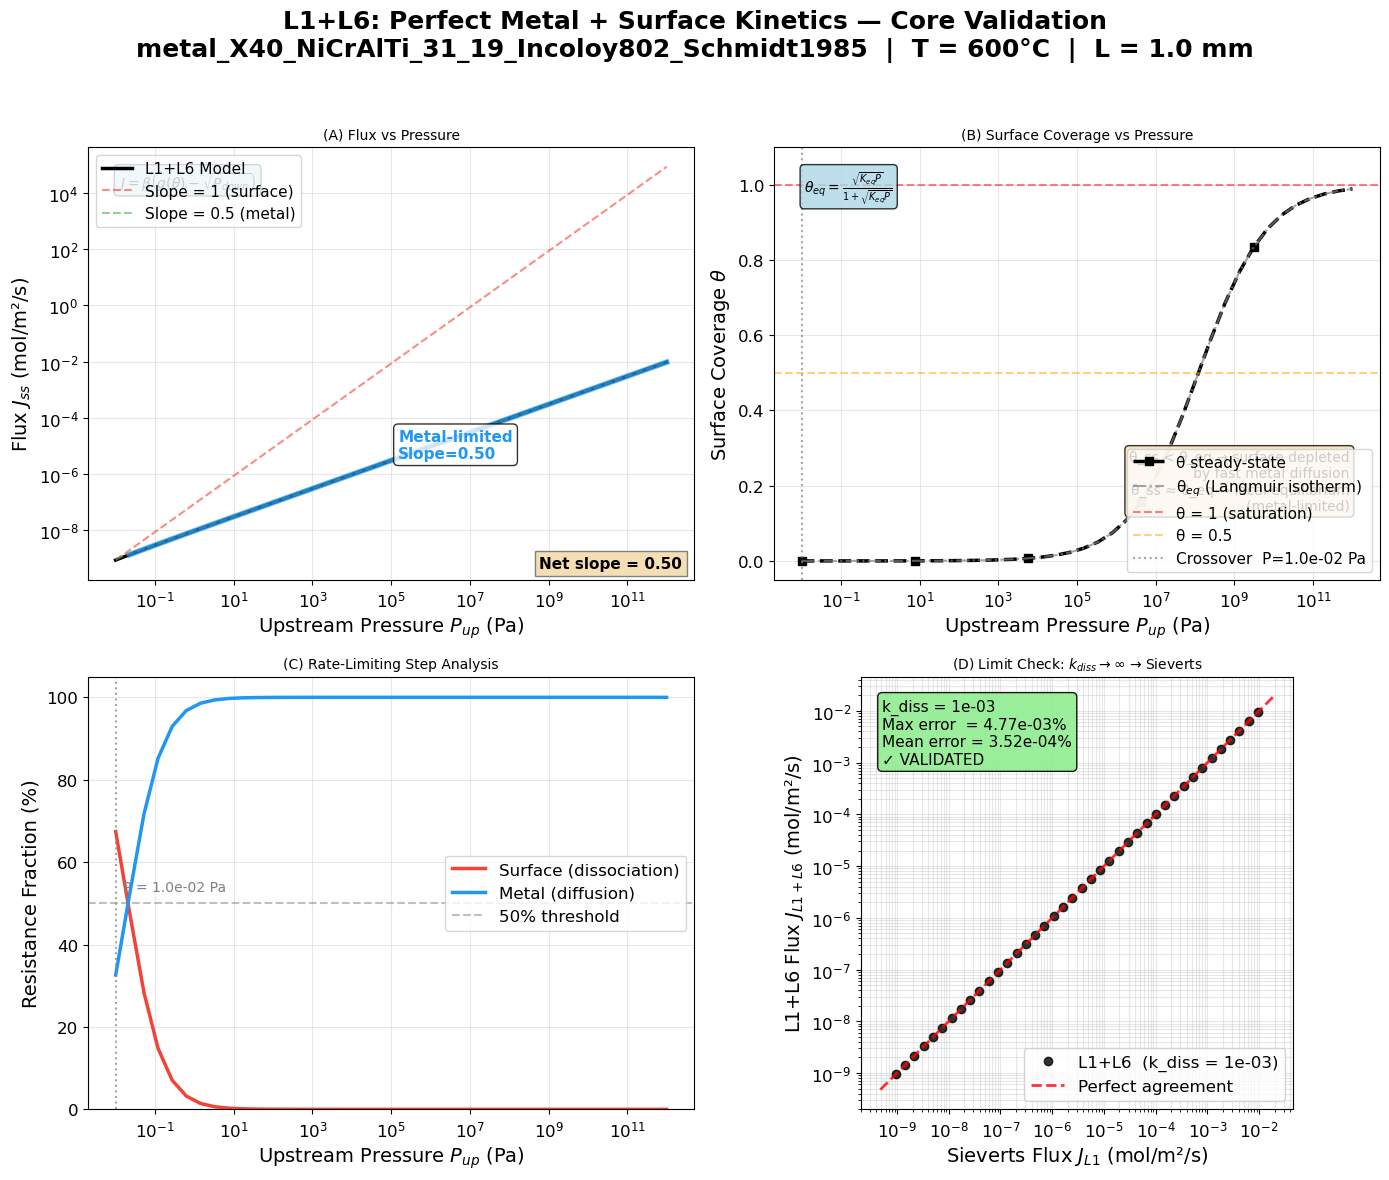


L1+L6 FIGURE 1 — VALIDATION SUMMARY
  Net log-log slope:       0.5012
  θ range:                 0.0000 → 0.9891
  Sieverts recovery error: 4.77e-03%  (✓)
  Crossover pressure:      1.00e-02 Pa


In [6]:
# =============================================================================
# CELL 4 — FIGURE 1: Core Validation (2×2)
# (A) Flux vs Pressure
# (B) Surface Coverage θ vs Pressure
# (C) Resistance Fractions vs Pressure
# (D) Limit Check: Sieverts Recovery
# =============================================================================


"""
Figure 1 validates the L1+L6 model from four angles at the operating temperature.

Panel (A) — Flux vs Pressure
    Question: Does the model produce the correct pressure-dependent behaviour?
    The hero plot. Shows J_ss vs P_up on a log-log scale. The curve should
    transition from slope=1 (surface-limited, low P) to slope=0.5
    (metal-limited, high P). Style follows the widget — no fill_between.
    Instead the curve itself is recolored by regime using thick colored
    segments, with a slope annotation box sitting directly on each segment.
    The black model curve sits underneath, the colored overlay sits on top.
    Reference lines for slope=1 and slope=0.5 are drawn as dashed lines
    anchored to the start and end of the curve respectively.
    Net slope annotation box in the bottom right corner.

Panel (B) — Surface Coverage θ vs Pressure
    Question: How does surface occupancy evolve with pressure, and does it
    match the Langmuir equilibrium isotherm?
    Plots the steady-state θ from the compute loop alongside the analytical
    Langmuir isotherm θ_eq = sqrt(K_eq * P) / (1 + sqrt(K_eq * P)) as a
    gray dash-dot line. The gap between θ_ss and θ_eq is physically
    meaningful — when they coincide the surface is in local equilibrium
    (metal-limited). When θ_ss < θ_eq the surface is being depleted by fast
    diffusion into the metal (surface-limited). Crossover pressure marked
    if it exists.

Panel (C) — Resistance Fractions vs Pressure
    Question: Which step controls the rate, and how does the balance shift
    with pressure?
    Plots R_surface/R_total and R_metal/R_total as percentages vs pressure
    on a semilog scale. The 50% threshold line marks the crossover. If no
    crossover exists in the physical range a text annotation states which
    regime dominates throughout. Crossover pressure annotated if present.

Panel (D) — Limit Check: Sieverts Recovery
    Question: As k_diss → ∞, does L1+L6 recover the pure Sieverts result?
    Runs the solver at k_diss = 1e-3 (fast kinetics limit) and compares
    J_L1+L6 against the analytical Sieverts flux J = beta*(sqrt(P_up) -
    sqrt(P_down)). A parity plot shows J_L1+L6 vs J_Sieverts — perfect
    agreement is a diagonal line. Max and mean relative errors are shown
    in an annotation box. Green box if max error < 1%, yellow otherwise.
    This validates the model correctly recovers L1 in the fast-kinetics limit.
"""

props = dict(boxstyle='round', facecolor='wheat', alpha=0.9)

fig, axes = plt.subplots(2, 2, figsize=STYLE['figsize'])
fig.suptitle(
    f'L1+L6: Perfect Metal + Surface Kinetics — Core Validation\n'
    f'{METAL_KEY}  |  T = {T_op-273.15:.0f}°C  |  L = {L_m*1e3:.1f} mm',
    fontsize=STYLE['fontsize_suptitle'], fontweight='bold', y=0.98
)

# ─────────────────────────────────────────────────────────────────────────────
# (A) FLUX vs PRESSURE — widget style: colored segments + slope annotations
# ─────────────────────────────────────────────────────────────────────────────
ax1 = axes[0, 0]

# Base black curve
ax1.loglog(
    P_RANGE_ARR[valid], J_arr[valid],
    color='black', lw=STYLE['linewidth'],
    label='L1+L6 Model'
)

# Slope reference lines
if np.any(valid):
    P_ref1  = P_RANGE_ARR[valid][0]
    J_ref1  = J_arr[valid][0]
    ax1.loglog(
        P_RANGE_ARR[valid],
        J_ref1 * (P_RANGE_ARR[valid] / P_ref1) ** 1.0,
        color=CURVE_STYLES['slope_1']['color'],
        ls=CURVE_STYLES['slope_1']['ls'],
        lw=CURVE_STYLES['slope_1']['lw'],
        alpha=CURVE_STYLES['slope_1']['alpha'],
        label='Slope = 1 (surface)'
    )
    P_ref05 = P_RANGE_ARR[valid][-1]
    J_ref05 = J_arr[valid][-1]
    ax1.loglog(
        P_RANGE_ARR[valid],
        J_ref05 * (P_RANGE_ARR[valid] / P_ref05) ** 0.5,
        color=CURVE_STYLES['slope_05']['color'],
        ls=CURVE_STYLES['slope_05']['ls'],
        lw=CURVE_STYLES['slope_05']['lw'],
        alpha=CURVE_STYLES['slope_05']['alpha'],
        label='Slope = 0.5 (metal)'
    )

# Colored regime segments + slope annotation boxes (widget style)
region_styles = [
    ('surface', CURVE_STYLES['surface_region']['color'], 'Surface-limited'),
    ('metal',   CURVE_STYLES['metal_region']['color'],   'Metal-limited'),
    ('mixed',   CURVE_STYLES['mixed_region']['color'],   'Mixed'),
]

for regime, color, label in region_styles:
    mask = (rl_arr == regime) & valid
    if not np.any(mask):
        continue
    idxs = np.where(mask)[0]
    for _, g in groupby(enumerate(idxs), lambda x: x[0] - x[1]):
        group = list(map(itemgetter(1), g))
        if len(group) < 3:
            continue
        P_seg = P_RANGE_ARR[group]
        J_seg = J_arr[group]
        ax1.loglog(P_seg, J_seg, color=color, lw=4, alpha=0.7)
        slope_seg, *_ = stats.linregress(
            np.log10(P_seg), np.log10(np.abs(J_seg))
        )
        mid = len(group) // 2
        ax1.text(
            P_seg[mid], J_seg[mid],
            f'{label}\nSlope={slope_seg:.2f}',
            color=color,
            fontsize=STYLE['fontsize_annotation'],
            fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
        )

# Net slope annotation
log_P_v = np.log10(P_RANGE_ARR[valid])
log_J_v = np.log10(np.abs(J_arr[valid]))
slope_net, *_ = stats.linregress(log_P_v, log_J_v)
ax1.text(
    0.98, 0.02, f'Net slope = {slope_net:.2f}',
    transform=ax1.transAxes, ha='right', va='bottom',
    fontsize=STYLE['fontsize_annotation'], fontweight='bold',
    bbox=dict(boxstyle='square', fc='wheat', ec='gray', alpha=1)
)
ax1.text(
    0.05, 0.95,
    r'$J = \beta\left(g(\theta) - \sqrt{P_{down}}\right)$',
    transform=ax1.transAxes, fontsize=10, va='top',
    bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8)
)

ax1.set_xlabel('Upstream Pressure $P_{up}$ (Pa)', fontsize=STYLE['fontsize_axis'])
ax1.set_ylabel('Flux $J_{ss}$ (mol/m²/s)',         fontsize=STYLE['fontsize_axis'])
ax1.set_title('(A) Flux vs Pressure',               fontsize=STYLE['fontsize_title'])
ax1.legend(fontsize=STYLE['fontsize_legend']-1, loc='upper left')
ax1.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax1.tick_params(labelsize=STYLE['fontsize_tick'])

# ─────────────────────────────────────────────────────────────────────────────
# (B) SURFACE COVERAGE θ vs PRESSURE
# ─────────────────────────────────────────────────────────────────────────────
ax2 = axes[0, 1]

# Steady-state θ from compute loop
ax2.semilogx(
    P_RANGE_ARR[valid], theta_arr[valid],
    color=CURVE_STYLES['L1_L6']['color'],
    ls=CURVE_STYLES['L1_L6']['ls'],
    lw=STYLE['linewidth'],
    marker=CURVE_STYLES['L1_L6']['marker'],
    ms=CURVE_STYLES['L1_L6']['ms'],
    markevery=8,
    label='θ steady-state'
)

# Equilibrium Langmuir isotherm overlay
theta_eq = (np.sqrt(K_eq * P_RANGE_ARR) /
            (1 + np.sqrt(K_eq * P_RANGE_ARR)))
ax2.semilogx(
    P_RANGE_ARR, theta_eq,
    color='gray', ls='-.', lw=1.5, alpha=0.7,
    label=r'θ$_{eq}$ (Langmuir isotherm)'
)

# Reference lines
ax2.axhline(
    1.0, color='red', ls='--', lw=1.5, alpha=0.5,
    label='θ = 1 (saturation)'
)
ax2.axhline(
    0.5, color='orange', ls='--', lw=1.5, alpha=0.5,
    label='θ = 0.5'
)

# Crossover line
if P_crossover is not None:
    ax2.axvline(
        P_crossover, color='gray', ls=':', lw=1.5, alpha=0.7,
        label=f'Crossover  P={P_crossover:.1e} Pa'
    )

ax2.text(
    0.05, 0.95,
    r'$\theta_{eq} = \frac{\sqrt{K_{eq} P}}{1 + \sqrt{K_{eq} P}}$',
    transform=ax2.transAxes, fontsize=10, va='top',
    bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8)
)
ax2.text(
    0.95, 0.30,
    'θ_ss < θ_eq → surface depleted\n   by fast metal diffusion\n'
    'θ_ss ≈ θ_eq → local equilibrium\n   (metal-limited)',
    transform=ax2.transAxes, fontsize=STYLE['fontsize_annotation']-1,
    va='top', ha='right',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8)
)

ax2.set_xlabel('Upstream Pressure $P_{up}$ (Pa)',  fontsize=STYLE['fontsize_axis'])
ax2.set_ylabel('Surface Coverage $\\theta$',        fontsize=STYLE['fontsize_axis'])
ax2.set_title('(B) Surface Coverage vs Pressure',   fontsize=STYLE['fontsize_title'])
ax2.set_ylim(-0.05, 1.1)
ax2.legend(fontsize=STYLE['fontsize_legend']-1, loc='lower right')
ax2.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax2.tick_params(labelsize=STYLE['fontsize_tick'])

# ─────────────────────────────────────────────────────────────────────────────
# (C) RESISTANCE FRACTIONS vs PRESSURE
# ─────────────────────────────────────────────────────────────────────────────
ax3 = axes[1, 0]

ax3.semilogx(
    P_RANGE_ARR[valid], frac_surface_arr[valid] * 100,
    color=CURVE_STYLES['surface_region']['color'],
    lw=STYLE['linewidth'], label='Surface (dissociation)'
)
ax3.semilogx(
    P_RANGE_ARR[valid], frac_metal_arr[valid] * 100,
    color=CURVE_STYLES['metal_region']['color'],
    lw=STYLE['linewidth'], label='Metal (diffusion)'
)

# 50% threshold
ax3.axhline(
    50,
    color=CURVE_STYLES['threshold']['color'],
    ls=CURVE_STYLES['threshold']['ls'],
    lw=CURVE_STYLES['threshold']['lw'],
    alpha=CURVE_STYLES['threshold']['alpha'],
    label='50% threshold'
)

# Crossover annotation
if P_crossover is not None:
    ax3.axvline(P_crossover, color='gray', ls=':', lw=1.5, alpha=0.7)
    ax3.text(
        P_crossover * 1.5, 53,
        f'P = {P_crossover:.1e} Pa',
        fontsize=STYLE['fontsize_annotation']-1, color='gray'
    )
else:
    dominant = 'Surface-limited' if n_surface > n_metal else 'Metal-limited'
    ax3.text(
        0.05, 0.50,
        f'No crossover in range\n{dominant} throughout',
        transform=ax3.transAxes,
        fontsize=STYLE['fontsize_annotation'],
        va='center',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9)
    )

ax3.set_xlabel('Upstream Pressure $P_{up}$ (Pa)', fontsize=STYLE['fontsize_axis'])
ax3.set_ylabel('Resistance Fraction (%)',          fontsize=STYLE['fontsize_axis'])
ax3.set_title('(C) Rate-Limiting Step Analysis',   fontsize=STYLE['fontsize_title'])
ax3.set_ylim(0, 105)
ax3.legend(fontsize=STYLE['fontsize_legend'], loc='center right')
ax3.grid(True, alpha=STYLE['grid_alpha'])
ax3.tick_params(labelsize=STYLE['fontsize_tick'])

# ─────────────────────────────────────────────────────────────────────────────
# (D) LIMIT CHECK — Sieverts Recovery as k_diss → ∞
# ─────────────────────────────────────────────────────────────────────────────
ax4 = axes[1, 1]

# Sieverts reference (L1, no surface kinetics)
J_sieverts = beta * (np.sqrt(P_RANGE_ARR) - np.sqrt(P_down))

# Sweep k_diss over many orders of magnitude
k_diss_sweep = np.logspace(-15, -3, 7)

# Compute L1+L6 at the highest k_diss only — for parity plot
J_high_k = []
for P_up in P_RANGE_ARR:
    try:
        r = solve_steady_state_flux_L1L6(
            P_up, P_down, L_m,
            k_diss_sweep[-1], K_eq, D_m, K_s_m
        )
        J_high_k.append(r['J_ss'])
    except Exception:
        J_high_k.append(np.nan)
J_high_k = np.array(J_high_k)

valid_parity = ~np.isnan(J_high_k) & (J_sieverts > 0) & (J_high_k > 0)

# Parity plot
ax4.loglog(
    J_sieverts[valid_parity], J_high_k[valid_parity],
    'o',
    color=CURVE_STYLES['L1_L6']['color'],
    markersize=6, alpha=0.8,
    label=f'L1+L6  (k_diss = {k_diss_sweep[-1]:.0e})'
)

# Perfect agreement line
J_min = min(J_sieverts[valid_parity].min(), J_high_k[valid_parity].min()) * 0.5
J_max = max(J_sieverts[valid_parity].max(), J_high_k[valid_parity].max()) * 2.0
ax4.loglog(
    [J_min, J_max], [J_min, J_max],
    color=CURVE_STYLES['parity']['color'],
    ls=CURVE_STYLES['parity']['ls'],
    lw=CURVE_STYLES['parity']['lw'],
    alpha=CURVE_STYLES['parity']['alpha'],
    label='Perfect agreement'
)

# Max relative error
rel_errors = (np.abs(J_high_k[valid_parity] - J_sieverts[valid_parity])
              / J_sieverts[valid_parity] * 100)
max_err    = rel_errors.max()
mean_err   = rel_errors.mean()
box_color  = 'lightgreen' if max_err < 1.0 else 'lightyellow'

ax4.text(
    0.05, 0.95,
    f'k_diss = {k_diss_sweep[-1]:.0e}\n'
    f'Max error  = {max_err:.2e}%\n'
    f'Mean error = {mean_err:.2e}%\n'
    f'{"✓ VALIDATED" if max_err < 1.0 else "⚠ CHECK k_diss"}',
    transform=ax4.transAxes,
    fontsize=STYLE['fontsize_annotation'],
    va='top',
    bbox=dict(boxstyle='round', facecolor=box_color, alpha=0.9)
)

ax4.set_xlabel('Sieverts Flux $J_{L1}$ (mol/m²/s)',         fontsize=STYLE['fontsize_axis'])
ax4.set_ylabel('L1+L6 Flux $J_{L1+L6}$ (mol/m²/s)',         fontsize=STYLE['fontsize_axis'])
ax4.set_title(r'(D) Limit Check: $k_{diss} \to \infty$ → Sieverts', fontsize=STYLE['fontsize_title'])
ax4.set_aspect('equal', adjustable='box')
ax4.legend(fontsize=STYLE['fontsize_legend'], loc='lower right')
ax4.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax4.tick_params(labelsize=STYLE['fontsize_tick'])

# ─────────────────────────────────────────────────────────────────────────────
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# ── Validation summary ───────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("L1+L6 FIGURE 1 — VALIDATION SUMMARY")
print("=" * 60)
print(f"  Net log-log slope:       {slope_net:.4f}")
print(f"  θ range:                 "
      f"{np.nanmin(theta_arr):.4f} → {np.nanmax(theta_arr):.4f}")
print(f"  Sieverts recovery error: {max_err:.2e}%  "
      f"({'✓' if max_err < 1.0 else '⚠'})")
if P_crossover is not None:
    print(f"  Crossover pressure:      {P_crossover:.2e} Pa")
else:
    dominant = 'surface-limited' if n_surface > n_metal else 'metal-limited'
    print(f"  No crossover — system is {dominant} across full range")
print("=" * 60)

  ⚠  surface: P_for_surface_Ea is None — fit skipped


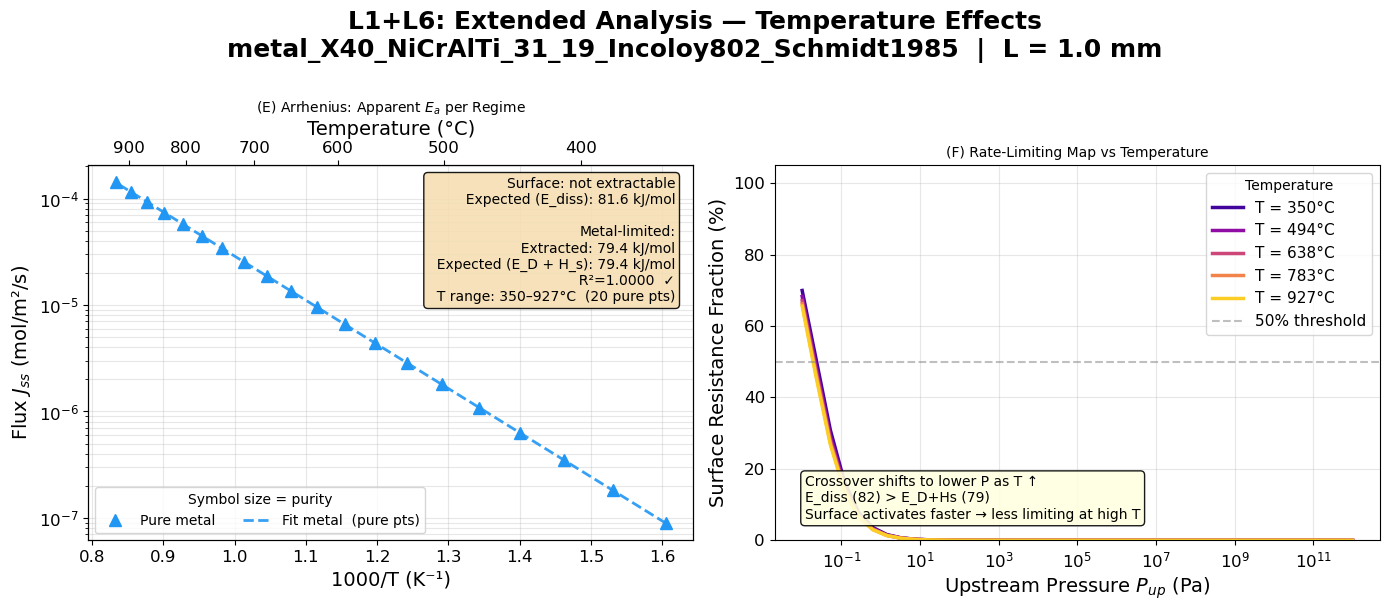


L1+L6 FIGURE 2 — ARRHENIUS SUMMARY
  Surface-limited:  not extractable
  Metal-limited:
    Extracted  Ea = 79.4 kJ/mol
    Expected (E_D + H_s) = 79.4 kJ/mol
    R²         = 1.000000
    Match:       ✓

  Crossover pressures across T sweep:
    T = 350°C  →  P_crossover = 2.29e-02 Pa
    T = 494°C  →  P_crossover = 1.00e-02 Pa
    T = 638°C  →  P_crossover = 1.00e-02 Pa
    T = 783°C  →  P_crossover = 1.00e-02 Pa
    T = 927°C  →  P_crossover = 1.00e-02 Pa


In [7]:
# =============================================================================
# CELL 5 — FIGURE 2: Extended Analysis (1×2)
# (E) Arrhenius: apparent Ea per regime vs known reference
# (F) Rate-limiting map: surface fraction vs pressure at multiple temperatures
# =============================================================================

# =============================================================================
"""
Figure 2 examines how temperature changes the balance between surface and
metal resistance. While Figure 1 is at a single operating temperature,
Figure 2 asks what happens across the full temperature range.

Panel (E) — Arrhenius: apparent Ea per regime
    Question: Does the model extract the correct activation energy in each
    regime, and does it match the known reference values from config?
    Sweeps temperature from T_RANGE[0] to T_RANGE[1]. At each temperature
    all four properties (k_diss, K_eq, D_m, K_s_m) are recomputed via the
    Arrhenius helper functions from Cell 1. The solver is called at two fixed
    pressures — P_for_surface_Ea and P_for_metal_Ea — selected in Cell 3 as
    the median of each dominant region (fraction > 90%). A linear fit to
    ln(J) vs 1000/T gives the apparent activation energy for each regime.
    Extracted Ea is compared to the known reference from config:
      - Surface regime: extracted Ea vs E_diss (config surface_kinetics)
      - Metal regime:   extracted Ea vs E_D + H_s (config metal transport)
    Dual x-axis: 1000/T on the bottom (K-1), degrees C on top.
    If a regime has insufficient dominant points (P set to None in Cell 3),
    that fit is skipped cleanly with a printed message — no crash.

Panel (F) — Rate-limiting map: surface fraction vs pressure at multiple T
    Question: How does the balance between surface and metal resistance shift
    as temperature increases, and in which direction does the crossover move?
    Runs the full pressure sweep at 5 temperatures spread across T_RANGE.
    Plots surface resistance fraction (%) vs pressure for each temperature
    using a plasma colormap — cool for low T, warm for high T. The direction
    of the crossover shift reveals whether surface kinetics or metal diffusion
    activates faster with temperature, determined by comparing E_diss vs
    E_D + H_s. An annotation box states the observed direction and the
    physical reason derived from config activation energies.
"""




fig2, axes2 = plt.subplots(1, 2, figsize=(14, 6))
fig2.suptitle(
    f'L1+L6: Extended Analysis — Temperature Effects\n'
    f'{METAL_KEY}  |  L = {L_m*1e3:.1f} mm',
    fontsize=STYLE['fontsize_suptitle'], fontweight='bold', y=1.01
)

# # ─────────────────────────────────────────────────────────────────────────────
# # (E) ARRHENIUS — apparent Ea per regime
# # ─────────────────────────────────────────────────────────────────────────────
# ax_E = axes2[0]

# temperatures_K = np.linspace(T_RANGE[0], T_RANGE[1], N_T)
# inv_T          = 1000.0 / temperatures_K

# # ── Compute J at each regime pressure across temperature sweep ────────────────
# results = {}

# for label, P_fixed, color in [
#     ('surface', P_for_surface_Ea, CURVE_STYLES['surface_region']['color']),
#     ('metal',   P_for_metal_Ea,   CURVE_STYLES['metal_region']['color']),
# ]:
#     if P_fixed is None:
#         print(f"  ⚠  {label}-regime: P_for_{label}_Ea is None — fit skipped")
#         results[label] = None
#         continue

#     J_row = []
#     for T_K in temperatures_K:
#         try:
#             r = solve_steady_state_flux_L1L6(
#                 P_fixed, P_down, L_m,
#                 get_k_diss_at_T(T_K),
#                 get_K_eq_at_T(T_K),
#                 get_D_m_at_T(T_K),
#                 get_K_s_m_at_T(T_K),
#             )
#             J_row.append(r['J_ss'])
#         except Exception:
#             J_row.append(np.nan)

#     J_arr_T = np.array(J_row)
#     valid_T  = ~np.isnan(J_arr_T) & (J_arr_T > 0)

#     if np.sum(valid_T) < 3:
#         print(f"  ⚠  {label}-regime: only {np.sum(valid_T)} valid points — fit skipped")
#         results[label] = None
#         continue

#     # Arrhenius fit
#     slope, intercept, r_val, *_ = stats.linregress(
#         inv_T[valid_T], np.log(J_arr_T[valid_T])
#     )
#     E_a_extracted = -slope * R * 1000   # J/mol

#     results[label] = {
#         'J':           J_arr_T,
#         'valid':       valid_T,
#         'slope':       slope,
#         'intercept':   intercept,
#         'r_sq':        r_val**2,
#         'E_a':         E_a_extracted,
#         'P_fixed':     P_fixed,
#         'color':       color,
#     }

#     # Plot data points
#     ax_E.semilogy(
#         inv_T[valid_T], J_arr_T[valid_T],
#         color=color, ls='-', lw=STYLE['linewidth'],
#         marker='o' if label == 'surface' else 's',
#         ms=5, markevery=2,
#         label=f'{label.capitalize()}-limited  (P = {P_fixed:.1e} Pa)'
#     )

#     # Plot fitted line
#     ax_E.semilogy(
#         inv_T[valid_T],
#         np.exp(slope * inv_T[valid_T] + intercept),
#         color=color, ls='--', lw=1.5, alpha=0.7
#     )

# # ── Dual x-axis: °C on top ────────────────────────────────────────────────────
# ax_E_top = ax_E.twiny()
# ax_E_top.set_xlim(ax_E.get_xlim())
# T_ticks_C  = np.array([200, 300, 400, 500, 600, 700, 800, 900])
# T_ticks_K  = T_ticks_C + 273.15
# in_range   = (T_ticks_K >= T_RANGE[0]) & (T_ticks_K <= T_RANGE[1])
# if np.any(in_range):
#     ax_E_top.set_xticks(1000.0 / T_ticks_K[in_range])
#     ax_E_top.set_xticklabels([f'{t}' for t in T_ticks_C[in_range]])
# ax_E_top.set_xlabel('Temperature (°C)',      fontsize=STYLE['fontsize_axis'])
# ax_E_top.tick_params(labelsize=STYLE['fontsize_tick'])

# # ── Annotation box ────────────────────────────────────────────────────────────
# annot_lines = []

# for label, E_ref, ref_name in [
#     ('surface', E_REF_SURFACE, 'E_diss'),
#     ('metal',   E_REF_METAL,   'E_D + H_s'),
# ]:
#     res = results.get(label)
#     if res is None:
#         annot_lines.append(f'{label.capitalize()}: not extractable')
#         annot_lines.append(f'  Expected ({ref_name}): {E_ref/1000:.1f} kJ/mol')
#     else:
#         E_a = res['E_a']
#         match = abs(E_a - E_ref) < 3000    # within 3 kJ/mol
#         annot_lines.append(
#             f'{label.capitalize()}-limited:'
#         )
#         annot_lines.append(
#             f'  Extracted:  {E_a/1000:.1f} kJ/mol'
#         )
#         annot_lines.append(
#             f'  Expected ({ref_name}): {E_ref/1000:.1f} kJ/mol'
#         )
#         annot_lines.append(
#             f'  R² = {res["r_sq"]:.6f}  '
#             f'{"✓" if match else "⚠ check regime"}'
#         )
#     annot_lines.append('')   # blank line between blocks

# ax_E.text(
#     0.97, 0.97, '\n'.join(annot_lines).rstrip(),
#     transform=ax_E.transAxes,
#     fontsize=STYLE['fontsize_annotation'],
#     va='top', ha='right',
#     bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9)
# )

# ax_E.set_xlabel('1000/T (K⁻¹)',              fontsize=STYLE['fontsize_axis'])
# ax_E.set_ylabel('Flux $J_{ss}$ (mol/m²/s)',  fontsize=STYLE['fontsize_axis'])
# ax_E.set_title('(E) Arrhenius: Apparent $E_a$ per Regime',
#                fontsize=STYLE['fontsize_title'])
# ax_E.legend(fontsize=STYLE['fontsize_legend']-1, loc='lower left')
# ax_E.grid(True, which='both', alpha=STYLE['grid_alpha'])
# ax_E.tick_params(labelsize=STYLE['fontsize_tick'])

# ─────────────────────────────────────────────────────────────────────────────
# (E) ARRHENIUS — apparent Ea per regime, classified by regime purity
# ─────────────────────────────────────────────────────────────────────────────
ax_E = axes2[0]

temperatures_K = np.linspace(T_RANGE[0], T_RANGE[1], N_T)
inv_T          = 1000.0 / temperatures_K

# ── Regime classification — two resistances only ──────────────────────────────
def classify_regime_L1(fs, fm, pure_thresh=0.90, mixed_thresh=0.50):
    if fs >= pure_thresh:    return 'pure_surface'
    elif fm >= pure_thresh:  return 'pure_metal'
    elif fs >= mixed_thresh: return 'mixed_surface'
    elif fm >= mixed_thresh: return 'mixed_metal'
    else:                    return 'mixed'

regime_class_styles = {
    'pure_surface':  {'color': CURVE_STYLES['surface_region']['color'], 'marker': 'o', 'ms': 8,  'alpha': 1.0},
    'mixed_surface': {'color': CURVE_STYLES['surface_region']['color'], 'marker': 'o', 'ms': 5,  'alpha': 0.35},
    'pure_metal':    {'color': CURVE_STYLES['metal_region']['color'],   'marker': '^', 'ms': 8,  'alpha': 1.0},
    'mixed_metal':   {'color': CURVE_STYLES['metal_region']['color'],   'marker': '^', 'ms': 5,  'alpha': 0.35},
    'mixed':         {'color': CURVE_STYLES['mixed_region']['color'],   'marker': 'x', 'ms': 6,  'alpha': 0.5},
}

regime_Ea_cases = [
    ('surface', P_for_surface_Ea, CURVE_STYLES['surface_region']['color']),
    ('metal',   P_for_metal_Ea,   CURVE_STYLES['metal_region']['color']),
]

results            = {}
plotted_cls_labels = set()

for label, P_fixed, color in regime_Ea_cases:
    if P_fixed is None:
        print(f"  ⚠  {label}: P_for_{label}_Ea is None — fit skipped")
        results[label] = None
        continue

    J_row     = []
    class_row = []

    for T_K in temperatures_K:
        try:
            r = solve_steady_state_flux_L1L6(
                P_fixed, P_down, L_m,
                get_k_diss_at_T(T_K),
                get_K_eq_at_T(T_K),
                get_D_m_at_T(T_K),
                get_K_s_m_at_T(T_K),
            )
            J_row.append(r['J_ss'])
            fs = r['resistances']['fraction_surface']
            fm = r['resistances']['fraction_metal']
            class_row.append(classify_regime_L1(fs, fm))
        except Exception:
            J_row.append(np.nan)
            class_row.append('mixed')

    J_arr_T   = np.array(J_row)
    class_arr = np.array(class_row)
    pure      = (class_arr == f'pure_{label}') & ~np.isnan(J_arr_T) & (J_arr_T > 0)

    # Plot all classified points
    for cls, sty in regime_class_styles.items():
        mask = (class_arr == cls) & ~np.isnan(J_arr_T) & (J_arr_T > 0)
        if not np.any(mask):
            continue
        cls_label = cls.replace('_', ' ').capitalize()
        ax_E.semilogy(
            inv_T[mask], J_arr_T[mask],
            ls='none',
            color=sty['color'], marker=sty['marker'],
            ms=sty['ms'], alpha=sty['alpha'],
            label=cls_label if cls_label not in plotted_cls_labels
                  else '_nolegend_'
        )
        plotted_cls_labels.add(cls_label)

    # Fit on pure points only
    if np.sum(pure) < 3:
        print(f"  ⚠  {label}: only {np.sum(pure)} pure T points — fit skipped")
        results[label] = None
        continue

    slope, intercept, r_val, *_ = stats.linregress(
        inv_T[pure], np.log(J_arr_T[pure])
    )
    E_a = -slope * R * 1000

    results[label] = {
        'J': J_arr_T, 'valid': pure,
        'slope': slope, 'intercept': intercept,
        'r_sq': r_val**2, 'E_a': E_a,
        'P_fixed': P_fixed, 'color': color,
        'n_pure': int(np.sum(pure)),
        'T_pure_range': (temperatures_K[pure].min() - 273.15,
                         temperatures_K[pure].max() - 273.15),
    }

    ax_E.semilogy(
        inv_T[pure],
        np.exp(slope * inv_T[pure] + intercept),
        color=color, ls='--', lw=2.0, alpha=0.9,
        label=f'Fit {label}  (pure pts)'
    )

# Dual x-axis
ax_E_top = ax_E.twiny()
ax_E_top.set_xlim(ax_E.get_xlim())
T_ticks_C = np.array([200, 300, 400, 500, 600, 700, 800, 900])
T_ticks_K = T_ticks_C + 273.15
in_range  = (T_ticks_K >= T_RANGE[0]) & (T_ticks_K <= T_RANGE[1])
if np.any(in_range):
    ax_E_top.set_xticks(1000.0 / T_ticks_K[in_range])
    ax_E_top.set_xticklabels([f'{t}' for t in T_ticks_C[in_range]])
ax_E_top.set_xlabel('Temperature (°C)', fontsize=STYLE['fontsize_axis'])
ax_E_top.tick_params(labelsize=STYLE['fontsize_tick'])

# Annotation box
annot = []
for lbl, E_ref, ref_name in [
    ('surface', E_REF_SURFACE, 'E_diss'),
    ('metal',   E_REF_METAL,   'E_D + H_s'),
]:
    res = results.get(lbl)
    if res is None:
        annot.append(f'{lbl.capitalize()}: not extractable')
        annot.append(f'  Expected ({ref_name}): {E_ref/1000:.1f} kJ/mol')
    else:
        match = abs(res['E_a'] - E_ref) < 3000
        annot.append(f'{lbl.capitalize()}-limited:')
        annot.append(f'  Extracted: {res["E_a"]/1000:.1f} kJ/mol')
        annot.append(f'  Expected ({ref_name}): {E_ref/1000:.1f} kJ/mol')
        annot.append(f'  R²={res["r_sq"]:.4f}  {"✓" if match else "⚠"}')
        annot.append(f'  T range: {res["T_pure_range"][0]:.0f}–'
                     f'{res["T_pure_range"][1]:.0f}°C  '
                     f'({res["n_pure"]} pure pts)')
    annot.append('')

ax_E.text(
    0.97, 0.97, '\n'.join(annot).rstrip(),
    transform=ax_E.transAxes, fontsize=STYLE['fontsize_annotation']-1,
    va='top', ha='right',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9)
)

ax_E.set_xlabel('1000/T (K⁻¹)',             fontsize=STYLE['fontsize_axis'])
ax_E.set_ylabel('Flux $J_{ss}$ (mol/m²/s)', fontsize=STYLE['fontsize_axis'])
ax_E.set_title('(E) Arrhenius: Apparent $E_a$ per Regime',
               fontsize=STYLE['fontsize_title'])
ax_E.legend(fontsize=STYLE['fontsize_legend']-2, loc='lower left',
            ncol=2, title='Symbol size = purity')
ax_E.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax_E.tick_params(labelsize=STYLE['fontsize_tick'])
# ─────────────────────────────────────────────────────────────────────────────
# (F) RATE-LIMITING MAP — surface fraction vs pressure at 5 temperatures
# ─────────────────────────────────────────────────────────────────────────────
ax_F = axes2[1]

T_map_values = np.linspace(T_RANGE[0], T_RANGE[1], 5)
T_colors     = plt.cm.plasma(np.linspace(0.1, 0.9, len(T_map_values)))

crossover_pressures = []   # collect crossover per T for annotation

for T_K, col in zip(T_map_values, T_colors):
    fs_row = []
    for P_up in P_RANGE_ARR:
        try:
            r = solve_steady_state_flux_L1L6(
                P_up, P_down, L_m,
                get_k_diss_at_T(T_K),
                get_K_eq_at_T(T_K),
                get_D_m_at_T(T_K),
                get_K_s_m_at_T(T_K),
            )
            fs_row.append(r['resistances']['fraction_surface'] * 100)
        except Exception:
            fs_row.append(np.nan)

    fs_row    = np.array(fs_row)
    valid_row = ~np.isnan(fs_row)

    if not np.any(valid_row):
        continue

    ax_F.semilogx(
        P_RANGE_ARR[valid_row], fs_row[valid_row],
        color=col, lw=STYLE['linewidth'],
        label=f'T = {T_K-273.15:.0f}°C'
    )

    # Find crossover for this temperature
    sc = np.where(np.diff(np.sign(fs_row[valid_row] - 50)))[0]
    if len(sc) > 0:
        idx = sc[0]
        fs_v = fs_row[valid_row]
        if idx + 1 < len(fs_v) and fs_v[idx] > 50 and fs_v[idx+1] < 50:
            crossover_pressures.append((T_K, P_RANGE_ARR[valid_row][idx]))

# 50% threshold
ax_F.axhline(
    50,
    color=CURVE_STYLES['threshold']['color'],
    ls=CURVE_STYLES['threshold']['ls'],
    lw=CURVE_STYLES['threshold']['lw'],
    alpha=CURVE_STYLES['threshold']['alpha'],
    label='50% threshold'
)

# ── Crossover shift annotation ────────────────────────────────────────────────
if len(crossover_pressures) >= 2:
    T_low,  P_co_low  = crossover_pressures[0]
    T_high, P_co_high = crossover_pressures[-1]

    if P_co_high < P_co_low:
        direction = 'lower P as T ↑'
        physical  = f'E_diss ({E_REF_SURFACE/1000:.0f}) > E_D+Hs ({E_REF_METAL/1000:.0f})'
        meaning   = 'Surface activates faster → less limiting at high T'
    else:
        direction = 'higher P as T ↑'
        physical  = f'E_D+Hs ({E_REF_METAL/1000:.0f}) > E_diss ({E_REF_SURFACE/1000:.0f})'
        meaning   = 'Metal activates faster → more limiting at high T'

    ax_F.text(
        0.05, 0.05,
        f'Crossover shifts to {direction}\n{physical}\n{meaning}',
        transform=ax_F.transAxes,
        fontsize=STYLE['fontsize_annotation']-1,
        va='bottom',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9)
    )
elif len(crossover_pressures) == 0:
    dominant = 'surface-limited' if n_surface > n_metal else 'metal-limited'
    ax_F.text(
        0.05, 0.05,
        f'No crossover at any T\nSystem is {dominant}\nacross full pressure range',
        transform=ax_F.transAxes,
        fontsize=STYLE['fontsize_annotation']-1,
        va='bottom',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9)
    )

ax_F.set_xlabel('Upstream Pressure $P_{up}$ (Pa)',  fontsize=STYLE['fontsize_axis'])
ax_F.set_ylabel('Surface Resistance Fraction (%)',  fontsize=STYLE['fontsize_axis'])
ax_F.set_title('(F) Rate-Limiting Map vs Temperature',
               fontsize=STYLE['fontsize_title'])
ax_F.set_ylim(0, 105)
ax_F.legend(
    fontsize=STYLE['fontsize_legend']-1,
    loc='upper right',
    title='Temperature'
)
ax_F.grid(True, alpha=STYLE['grid_alpha'])
ax_F.tick_params(labelsize=STYLE['fontsize_tick'])

plt.tight_layout()
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("L1+L6 FIGURE 2 — ARRHENIUS SUMMARY")
print("=" * 60)

for label, E_ref, ref_name in [
    ('surface', E_REF_SURFACE, 'E_diss'),
    ('metal',   E_REF_METAL,   'E_D + H_s'),
]:
    res = results.get(label)
    if res is None:
        print(f"  {label.capitalize()}-limited:  not extractable")
    else:
        match = abs(res['E_a'] - E_ref) < 3000
        print(f"  {label.capitalize()}-limited:")
        print(f"    Extracted  Ea = {res['E_a']/1000:.1f} kJ/mol")
        print(f"    Expected ({ref_name}) = {E_ref/1000:.1f} kJ/mol")
        print(f"    R²         = {res['r_sq']:.6f}")
        print(f"    Match:       {'✓' if match else '⚠ — check regime purity'}")

if crossover_pressures:
    print(f"\n  Crossover pressures across T sweep:")
    for T_K, P_co in crossover_pressures:
        print(f"    T = {T_K-273.15:.0f}°C  →  P_crossover = {P_co:.2e} Pa")

print("=" * 60)

In [8]:
# =============================================================================
# CELL 6 — DATAFRAME OUTPUT
# =============================================================================
df = pd.DataFrame(rows)

# ── Formatting ────────────────────────────────────────────────────────────────
df_display = df.copy()

for col in df_display.columns:
    if col == 'Rate-Limiting' or col == 'Error':
        continue
    if df_display[col].dtype == float:
        if 'fraction' in col.lower():
            df_display[col] = df_display[col].round(2)
        elif 'theta' in col.lower():
            df_display[col] = df_display[col].round(6)
        else:
            df_display[col] = df_display[col].apply(
                lambda x: f'{x:.4e}' if pd.notna(x) else 'NaN'
            )

# ── Summary line ──────────────────────────────────────────────────────────────
n_surface_df = (df['Rate-Limiting'] == 'SURFACE').sum()
n_metal_df   = (df['Rate-Limiting'] == 'METAL').sum()
n_mixed_df   = (df['Rate-Limiting'] == 'MIXED').sum()
n_error_df   = (df['Rate-Limiting'] == 'ERROR').sum()

print("=" * 60)
print("L1+L6 RESULTS DATAFRAME")
print("=" * 60)
print(f"  Metal:       {METAL_KEY}")
print(f"  T:           {T_op-273.15:.0f}°C  ({T_op} K)")
print(f"  L_m:         {L_m*1e3:.1f} mm")
print(f"  k_diss:      {k_diss:.3e}  mol/m²/s/Pa")
print(f"  K_eq:        {K_eq:.3e}  Pa⁻¹")
print(f"  D_m:         {D_m:.3e}  m²/s")
print(f"  K_s_m:       {K_s_m:.3e}  mol/m³/Pa^0.5")
print(f"\n  Total rows:        {len(df)}")
print(f"  Surface-limited:   {n_surface_df}")
print(f"  Metal-limited:     {n_metal_df}")
print(f"  Mixed:             {n_mixed_df}")
if n_error_df > 0:
    print(f"  Errors:            {n_error_df}  ⚠")
print("=" * 60)

display(df_display)

L1+L6 RESULTS DATAFRAME
  Metal:       metal_X40_NiCrAlTi_31_19_Incoloy802_Schmidt1985
  T:           600°C  (873 K)
  L_m:         1.0 mm
  k_diss:      4.611e-07  mol/m²/s/Pa
  K_eq:        8.212e-09  Pa⁻¹
  D_m:         2.487e-10  m²/s
  K_s_m:       3.834e-02  mol/m³/Pa^0.5

  Total rows:        40
  Surface-limited:   1
  Metal-limited:     39
  Mixed:             0


,P_up (Pa),P_int (Pa),J_ss (mol/m²/s),θ_surface,β_metal,R_surface,R_metal,R_total,fraction_surface (%),fraction_metal (%),Rate-Limiting
0,1.0000e-02,8.1349e-03,8.5994e-10,8.1732e-06,9.5343e-09,2.1688e+08,1.0488e+08,3.2177e+08,67.40,32.60,SURFACE
1,2.2855e-02,1.9935e-02,1.3462e-09,1.2794e-05,9.5343e-09,9.4897e+07,1.0488e+08,1.9978e+08,47.50,52.50,METAL
2,5.2233e-02,4.7716e-02,2.0827e-09,1.9794e-05,9.5343e-09,4.1523e+07,1.0488e+08,1.4641e+08,28.36,71.64,METAL
3,1.1938e-01,1.1244e-01,3.1971e-09,3.0386e-05,9.5343e-09,1.8169e+07,1.0488e+08,1.2305e+08,14.76,85.24,METAL
4,2.7283e-01,2.6224e-01,4.8825e-09,4.6403e-05,9.5343e-09,7.9499e+06,1.0488e+08,1.1283e+08,7.05,92.95,METAL
5,6.2355e-01,6.0743e-01,7.4309e-09,7.0621e-05,9.5343e-09,3.4786e+06,1.0488e+08,1.0836e+08,3.21,96.79,METAL
6,1.4251e+00,1.4006e+00,1.1284e-08,1.0723e-04,9.5343e-09,1.5222e+06,1.0488e+08,1.0641e+08,1.43,98.57,METAL
7,3.2570e+00,3.2199e+00,1.7108e-08,1.6258e-04,9.5343e-09,6.6610e+05,1.0488e+08,1.0555e+08,0.63,99.37,METAL
8,7.4438e+00,7.3876e+00,2.5914e-08,2.4624e-04,9.5343e-09,2.9150e+05,1.0488e+08,1.0518e+08,0.28,99.72,METAL
9,1.7013e+01,1.6927e+01,3.9227e-08,3.7269e-04,9.5343e-09,1.2758e+05,1.0488e+08,1.0501e+08,0.12,99.88,METAL


### L2a+L6: Perfect Oxide + Surface Kinetics 

In [9]:
# =============================================================================
# CELL 1 — SETUP
# Run once. All imports and helper functions.
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import brentq
import pandas as pd
from itertools import groupby
from operator import itemgetter
from IPython.display import display

from calculations.surface_kinetics import solve_steady_state_flux_L2aL6
from calculations.config.model_config import (
    R, F,
    METALS, OXIDES, CONDITIONS, VALIDATION,
    PLOT_STYLE as STYLE,
    CURVE_STYLES,
    apply_style,
    build_simulation_config,
)

# ── Simulation config ─────────────────────────────────────────────────────────
SIM      = build_simulation_config(
    metal='metal_X40_NiCrAlTi_31_19_Incoloy802_Schmidt1985',
    oxide='Cr2O3_sample4',
    T_operating=873,
    P_upstream=1e5,
    L_metal=1e-3,
)

OXIDE_KEY = SIM['oxide_name']
OXIDE     = OXIDES[OXIDE_KEY]
SK        = OXIDE['surface_kinetics']     # oxide surface kinetics sub-dict

# ── Pressure sweep (matches widget range) ─────────────────────────────────────
P_RANGE_ARR = np.logspace(np.log10(CONDITIONS['P_range'][0]), np.log10(CONDITIONS['P_range'][1]), CONDITIONS['n_P_points'])
P_DOWN      = SIM['P_downstream']
T_RANGE     = CONDITIONS['T_range']
N_T         = CONDITIONS['n_T_points']

# ── Arrhenius helper functions ────────────────────────────────────────────────
def get_k_diss_at_T(T_K):
    """k_diss at temperature T_K via Arrhenius from config."""
    return SK['k_diss_ref'] * np.exp(
        (-SK['E_diss'] / R) * (1/T_K - 1/SK['T_ref'])
    )

def get_K_eq_at_T(T_K):
    """K_eq at temperature T_K via van't Hoff from config."""
    return SK['K_eq_ref'] * np.exp(
        (-SK['H_eq'] / R) * (1/T_K - 1/SK['T_ref'])
    )

def get_D_ox_at_T(T_K):
    """D_ox at temperature T_K via Arrhenius from config."""
    return OXIDE['D_ox_ref'] * np.exp(
        (-OXIDE['E_D_ox'] / R) * (1/T_K - 1/OXIDE['T_ref'])
    )

def get_K_ox_at_T(T_K):
    """K_ox at temperature T_K via Arrhenius from config."""
    return OXIDE['K_ox_ref'] * np.exp(
        (-OXIDE['H_sol_ox'] / R) * (1/T_K - 1/OXIDE['T_ref'])
    )

# ── Known reference activation energies ──────────────────────────────────────
E_REF_SURFACE = SK['E_diss']                          # J/mol — surface dissociation
E_REF_OXIDE   = OXIDE['E_D_ox'] + OXIDE['H_sol_ox']  # J/mol — oxide permeation

print("=" * 60)
print("SETUP COMPLETE")
print("=" * 60)
print(f"  Oxide:           {OXIDE_KEY}")
print(f"  E_ref surface:   {E_REF_SURFACE/1000:.1f} kJ/mol  (E_diss)")
print(f"  E_ref oxide:     {E_REF_OXIDE/1000:.1f} kJ/mol  (E_D_ox + H_sol_ox)")
print(f"  P range:         {P_RANGE_ARR[0]:.0e} – {P_RANGE_ARR[-1]:.0e} Pa")
print(f"  T range:         {T_RANGE[0]} – {T_RANGE[1]} K")
print("=" * 60)

SETUP COMPLETE
  Oxide:           Cr2O3_sample4
  E_ref surface:   58.0 kJ/mol  (E_diss)
  E_ref oxide:     234.0 kJ/mol  (E_D_ox + H_sol_ox)
  P range:         1e-02 – 1e+12 Pa
  T range:         623 – 1200 K


In [10]:
# =============================================================================
# CELL 2 — PARAMETERS
# All physics values at operating temperature, pulled from config.
# Change placeholder values in config and rerun from this cell downward.
# =============================================================================

# ── Operating conditions ──────────────────────────────────────────────────────
T_op   = SIM['T_operating']
L_ox   = SIM['L_oxide']
P_down = SIM['P_downstream']

# ── Surface kinetics at T_op ──────────────────────────────────────────────────
k_diss   = get_k_diss_at_T(T_op)
K_eq     = get_K_eq_at_T(T_op)
k_recomb = k_diss / K_eq

# ── Oxide transport at T_op ───────────────────────────────────────────────────
D_ox = get_D_ox_at_T(T_op)
K_ox = get_K_ox_at_T(T_op)

# ── Derived ───────────────────────────────────────────────────────────────────
alpha = D_ox * K_ox / L_ox    # oxide permeance [mol/m²/s/Pa^0.5]

# ── Print verification ────────────────────────────────────────────────────────
print("=" * 60)
print(f"L2a+L6 PARAMETERS AT T = {T_op-273.15:.0f}°C  ({T_op} K)")
print("=" * 60)

print(f"\n  Geometry")
print(f"    L_ox     = {L_ox:.3e}  m")
print(f"    P_down   = {P_down:.1e}  Pa")

print(f"\n  Surface kinetics  [config: oxide surface_kinetics sub-dict]")
print(f"    k_diss   = {k_diss:.3e}  mol/m²/s/Pa")
print(f"    K_eq     = {K_eq:.3e}  Pa⁻¹")
print(f"    k_recomb = {k_recomb:.3e}  mol/m²/s  (= k_diss / K_eq)")

print(f"\n  Oxide transport  [config: Arrhenius]")
print(f"    D_ox     = {D_ox:.3e}  m²/s")
print(f"    K_ox     = {K_ox:.3e}  mol/m³/Pa^0.5")

print(f"\n  Derived")
print(f"    α        = {alpha:.3e}  mol/m²/s/Pa^0.5  (= D_ox × K_ox / L_ox)")

print(f"\n  Reference activation energies  [config]")
print(f"    E_diss        = {E_REF_SURFACE/1000:.1f} kJ/mol   (surface dissociation)")
print(f"    E_D_ox+H_sol  = {E_REF_OXIDE/1000:.1f} kJ/mol   (oxide permeation)")

if SK['k_diss_ref'] <= 1e-12:
    print(f"\n  ⚠  WARNING: k_diss_ref = {SK['k_diss_ref']:.0e} looks like a placeholder.")
    print(f"     Update config oxide surface_kinetics sub-dict with literature values.")

print("\n" + "=" * 60)

L2a+L6 PARAMETERS AT T = 600°C  (873 K)

  Geometry
    L_ox     = 4.800e-08  m
    P_down   = 0.0e+00  Pa

  Surface kinetics  [config: oxide surface_kinetics sub-dict]
    k_diss   = 2.370e-09  mol/m²/s/Pa
    K_eq     = 2.799e-11  Pa⁻¹
    k_recomb = 8.468e+01  mol/m²/s  (= k_diss / K_eq)

  Oxide transport  [config: Arrhenius]
    D_ox     = 1.395e-17  m²/s
    K_ox     = 2.869e+02  mol/m³/Pa^0.5

  Derived
    α        = 8.337e-08  mol/m²/s/Pa^0.5  (= D_ox × K_ox / L_ox)

  Reference activation energies  [config]
    E_diss        = 58.0 kJ/mol   (surface dissociation)
    E_D_ox+H_sol  = 234.0 kJ/mol   (oxide permeation)



In [11]:
# =============================================================================
# CELL 3 — COMPUTE
# Single-pass loop over full pressure range.
# Builds all arrays, regime summary, and Arrhenius pressure selection.
# =============================================================================

# ── Single-pass loop ──────────────────────────────────────────────────────────
rows             = []
J_arr            = []
theta_arr        = []
P_surf_arr       = []
frac_surface_arr = []
frac_oxide_arr   = []
R_surface_arr    = []
R_oxide_arr      = []
R_total_arr      = []
rate_lim_arr     = []

for P_up in P_RANGE_ARR:
    try:
        r = solve_steady_state_flux_L2aL6(
            P_up, P_down,
            k_diss, K_eq, D_ox, K_ox, L_ox
        )
        J_arr.append(r['J_ss'])
        theta_arr.append(r['theta'])
        P_surf_arr.append(r['P_surf'])
        frac_surface_arr.append(r['resistances']['fraction_surface'])
        frac_oxide_arr.append(r['resistances']['fraction_oxide'])
        R_surface_arr.append(r['resistances']['R_surface'])
        R_oxide_arr.append(r['resistances']['R_oxide'])
        R_total_arr.append(r['resistances']['R_total'])
        rate_lim_arr.append(r['rate_limiting'])

        rows.append({
            'P_up (Pa)':            P_up,
            'P_surf (Pa)':          r['P_surf'],
            'J_ss (mol/m²/s)':      r['J_ss'],
            'θ_surface':            r['theta'],
            'α_oxide':              r['alpha'],
            'R_surface':            r['resistances']['R_surface'],
            'R_oxide':              r['resistances']['R_oxide'],
            'R_total':              r['resistances']['R_total'],
            'fraction_surface (%)': r['resistances']['fraction_surface'] * 100,
            'fraction_oxide (%)':   r['resistances']['fraction_oxide']   * 100,
            'Rate-Limiting':        r['rate_limiting'].upper(),
        })

    except Exception as e:
        J_arr.append(np.nan);            theta_arr.append(np.nan)
        P_surf_arr.append(np.nan);       frac_surface_arr.append(np.nan)
        frac_oxide_arr.append(np.nan);   R_surface_arr.append(np.nan)
        R_oxide_arr.append(np.nan);      R_total_arr.append(np.nan)
        rate_lim_arr.append('error')
        rows.append({'P_up (Pa)': P_up, 'Rate-Limiting': 'ERROR', 'Error': str(e)})

# ── Convert to arrays ─────────────────────────────────────────────────────────
J_arr            = np.array(J_arr)
theta_arr        = np.array(theta_arr)
P_surf_arr       = np.array(P_surf_arr)
frac_surface_arr = np.array(frac_surface_arr)
frac_oxide_arr   = np.array(frac_oxide_arr)
R_surface_arr    = np.array(R_surface_arr)
R_oxide_arr      = np.array(R_oxide_arr)
R_total_arr      = np.array(R_total_arr)
rate_lim_arr     = np.array(rate_lim_arr)
valid            = ~np.isnan(J_arr)

# ── Rate-limiting classification array ───────────────────────────────────────
rl_arr = np.where(frac_surface_arr > 0.5, 'surface',
         np.where(frac_oxide_arr   > 0.5, 'oxide', 'mixed'))

# ── Regime summary ────────────────────────────────────────────────────────────
n_surface = np.sum((frac_surface_arr > 0.5) & valid)
n_oxide   = np.sum((frac_oxide_arr   > 0.5) & valid)
n_mixed   = np.sum(
    (frac_surface_arr <= 0.5) & (frac_oxide_arr <= 0.5) & valid
)

surf_dom_mask  = (frac_surface_arr > 0.90) & valid
oxide_dom_mask = (frac_oxide_arr   > 0.90) & valid
P_surf_dom     = P_RANGE_ARR[surf_dom_mask]
P_oxide_dom    = P_RANGE_ARR[oxide_dom_mask]

# ── Arrhenius pressure selection (no crossover dependence) ───────────────────
P_for_surface_Ea = np.median(P_surf_dom)  if len(P_surf_dom)  > 3 else None
P_for_oxide_Ea   = np.median(P_oxide_dom) if len(P_oxide_dom) > 3 else None

# ── Crossover pressure (diagnostic only) ─────────────────────────────────────
P_crossover = None
valid_cross = valid & ~np.isnan(frac_surface_arr)
if np.sum(valid_cross) > 2:
    fs_v = frac_surface_arr[valid_cross]
    P_v  = P_RANGE_ARR[valid_cross]
    sc   = np.where(np.diff(np.sign(fs_v - 0.5)))[0]
    if len(sc) > 0:
        idx = sc[0]
        if idx + 1 < len(fs_v) and fs_v[idx] > 0.5 and fs_v[idx+1] < 0.5:
            P_crossover = P_v[idx]

# ── Print regime summary ──────────────────────────────────────────────────────
print("=" * 60)
print(f"L2a+L6 REGIME SUMMARY  (T = {T_op-273.15:.0f}°C, {np.sum(valid)} valid points)")
print("=" * 60)

print(f"\n  Regime breakdown (fraction > 50%)")
print(f"    Surface-limited:  {n_surface:3d} points")
print(f"    Oxide-limited:    {n_oxide:3d} points")
print(f"    Mixed:            {n_mixed:3d} points")

print(f"\n  Dominant regions (fraction > 90%) — used for Arrhenius")
if len(P_surf_dom) > 3:
    print(f"    Surface-dominant: {len(P_surf_dom):3d} points  "
          f"P = {P_surf_dom.min():.1e} – {P_surf_dom.max():.1e} Pa")
    print(f"    → P_for_surface_Ea = {P_for_surface_Ea:.2e} Pa")
else:
    print(f"    Surface-dominant: {len(P_surf_dom):3d} points  "
          f"(insufficient — surface Ea not extractable)")

if len(P_oxide_dom) > 3:
    print(f"    Oxide-dominant:   {len(P_oxide_dom):3d} points  "
          f"P = {P_oxide_dom.min():.1e} – {P_oxide_dom.max():.1e} Pa")
    print(f"    → P_for_oxide_Ea  = {P_for_oxide_Ea:.2e} Pa")
else:
    print(f"    Oxide-dominant:   {len(P_oxide_dom):3d} points  "
          f"(insufficient — oxide Ea not extractable)")

print(f"\n  Crossover pressure (diagnostic only)")
if P_crossover is not None:
    print(f"    P_crossover = {P_crossover:.2e} Pa")
else:
    print(f"    No crossover detected in physical pressure range")
    dominant = 'surface-limited' if n_surface > n_oxide else 'oxide-limited'
    print(f"    System is predominantly {dominant} across full range")

print(f"\n  θ range:  {np.nanmin(theta_arr):.4f} → {np.nanmax(theta_arr):.4f}")
print(f"  J range:  {np.nanmin(J_arr):.2e} → {np.nanmax(J_arr):.2e} mol/m²/s")
print("=" * 60)

L2a+L6 REGIME SUMMARY  (T = 600°C, 40 valid points)

  Regime breakdown (fraction > 50%)
    Surface-limited:   10 points
    Oxide-limited:     30 points
    Mixed:              0 points

  Dominant regions (fraction > 90%) — used for Arrhenius
    Surface-dominant:   8 points  P = 1.0e-02 – 3.3e+00 Pa
    → P_for_surface_Ea = 1.96e-01 Pa
    Oxide-dominant:    27 points  P = 4.6e+02 – 1.0e+12 Pa
    → P_for_oxide_Ea  = 2.15e+07 Pa

  Crossover pressure (diagnostic only)
    P_crossover = 1.70e+01 Pa

  θ range:  0.0000 → 0.8409
  J range:  2.37e-11 → 8.33e-02 mol/m²/s


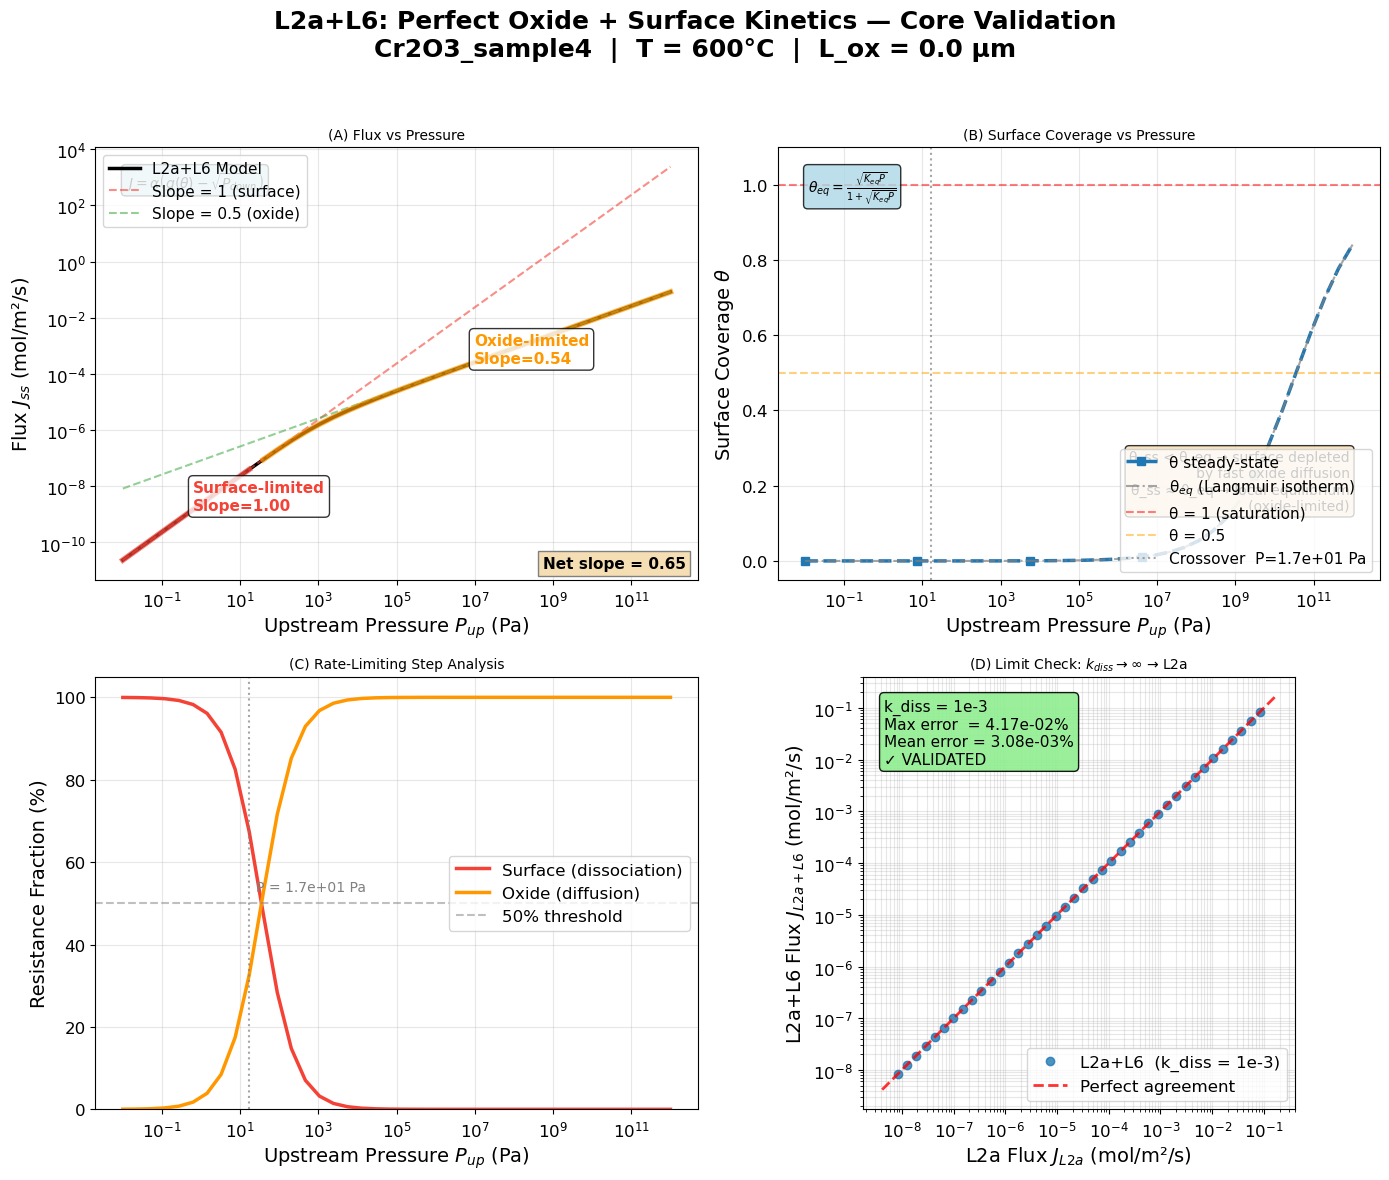


L2a+L6 FIGURE 1 — VALIDATION SUMMARY
  Net log-log slope:         0.6547
  θ range:                   0.0000 → 0.8409
  L2a recovery error:        4.17e-02%  (✓)
  Crossover pressure:        1.70e+01 Pa


In [12]:
# =============================================================================
# CELL 4 — FIGURE 1: Core Validation (2×2)
# =============================================================================
"""
Figure 1 validates the L2a+L6 model from four angles at operating temperature.

Panel (A) — Flux vs Pressure
    Question: Does the model produce the correct pressure-dependent behaviour?
    The hero plot. Shows J_ss vs P_up on a log-log scale. The curve should
    transition from slope=1 (surface-limited, low P) to slope=0.5
    (oxide-limited, high P). Note: in the pure L2a limit (no surface
    kinetics), the oxide follows Sieverts-like solubility so the slope is
    always 0.5. The addition of L6 introduces the slope=1 surface-limited
    regime at low P. Style follows the widget — no fill_between. The curve
    is recolored by regime using thick colored segments with slope annotation
    boxes sitting directly on each segment. Reference lines for slope=1 and
    slope=0.5 are drawn as dashed lines. Net slope annotation box in the
    bottom right corner.

Panel (B) — Surface Coverage θ vs Pressure
    Question: How does surface occupancy evolve with pressure, and does it
    match the Langmuir equilibrium isotherm?
    Plots steady-state θ from the compute loop alongside the equilibrium
    Langmuir isotherm θ_eq = sqrt(K_eq*P)/(1+sqrt(K_eq*P)) as a gray
    dash-dot line. In the oxide-limited regime the surface is in local
    equilibrium (θ_ss ≈ θ_eq). In the surface-limited regime the surface
    is being depleted faster than it can be replenished (θ_ss < θ_eq).
    Crossover pressure marked if it exists.

Panel (C) — Resistance Fractions vs Pressure
    Question: Which step controls the rate, and how does the balance shift
    with pressure?
    Plots R_surface/R_total and R_oxide/R_total as percentages vs pressure
    on a semilog scale. Note: there is no metal resistance term here — the
    two fractions always sum to 100%. The 50% threshold line marks the
    crossover. If no crossover exists a text annotation states which regime
    dominates throughout.

Panel (D) — Limit Check: Fast-Kinetics Recovery (L2a)
    Question: As k_diss → ∞, does L2a+L6 recover the pure L2a result?
    Runs the solver at k_diss = 1e-3 (fast kinetics limit) and compares
    J_L2a+L6 against the analytical L2a flux J = alpha*(sqrt(P_up) -
    sqrt(P_down)). A parity plot shows J_L2a+L6 vs J_L2a — perfect
    agreement is a diagonal line. This validates the model correctly
    recovers oxide-only Sieverts diffusion when surface kinetics is fast.
    Green box if max error < 1%, yellow otherwise.
"""

props = dict(boxstyle='round', facecolor='wheat', alpha=0.9)

fig, axes = plt.subplots(2, 2, figsize=STYLE['figsize'])
fig.suptitle(
    f'L2a+L6: Perfect Oxide + Surface Kinetics — Core Validation\n'
    f'{OXIDE_KEY}  |  T = {T_op-273.15:.0f}°C  |  L_ox = {L_ox*1e6:.1f} μm',
    fontsize=STYLE['fontsize_suptitle'], fontweight='bold', y=0.98
)

# ─────────────────────────────────────────────────────────────────────────────
# (A) FLUX vs PRESSURE
# ─────────────────────────────────────────────────────────────────────────────
ax1 = axes[0, 0]

ax1.loglog(
    P_RANGE_ARR[valid], J_arr[valid],
    color='black', lw=STYLE['linewidth'], label='L2a+L6 Model'
)

if np.any(valid):
    P_ref1 = P_RANGE_ARR[valid][0]
    J_ref1 = J_arr[valid][0]
    ax1.loglog(
        P_RANGE_ARR[valid],
        J_ref1 * (P_RANGE_ARR[valid] / P_ref1) ** 1.0,
        color=CURVE_STYLES['slope_1']['color'],
        ls=CURVE_STYLES['slope_1']['ls'],
        lw=CURVE_STYLES['slope_1']['lw'],
        alpha=CURVE_STYLES['slope_1']['alpha'],
        label='Slope = 1 (surface)'
    )
    P_ref05 = P_RANGE_ARR[valid][-1]
    J_ref05 = J_arr[valid][-1]
    ax1.loglog(
        P_RANGE_ARR[valid],
        J_ref05 * (P_RANGE_ARR[valid] / P_ref05) ** 0.5,
        color=CURVE_STYLES['slope_05']['color'],
        ls=CURVE_STYLES['slope_05']['ls'],
        lw=CURVE_STYLES['slope_05']['lw'],
        alpha=CURVE_STYLES['slope_05']['alpha'],
        label='Slope = 0.5 (oxide)'
    )

# Colored regime segments + slope annotation boxes
region_styles = [
    ('surface', CURVE_STYLES['surface_region']['color'], 'Surface-limited'),
    ('oxide',   CURVE_STYLES['oxide_region']['color'],   'Oxide-limited'),
    ('mixed',   CURVE_STYLES['mixed_region']['color'],   'Mixed'),
]

for regime, color, label in region_styles:
    mask = (rl_arr == regime) & valid
    if not np.any(mask):
        continue
    idxs = np.where(mask)[0]
    for _, g in groupby(enumerate(idxs), lambda x: x[0] - x[1]):
        group = list(map(itemgetter(1), g))
        if len(group) < 3:
            continue
        P_seg = P_RANGE_ARR[group]
        J_seg = J_arr[group]
        ax1.loglog(P_seg, J_seg, color=color, lw=4, alpha=0.7)
        slope_seg, *_ = stats.linregress(
            np.log10(P_seg), np.log10(np.abs(J_seg))
        )
        mid = len(group) // 2
        ax1.text(
            P_seg[mid], J_seg[mid],
            f'{label}\nSlope={slope_seg:.2f}',
            color=color,
            fontsize=STYLE['fontsize_annotation'],
            fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
        )

log_P_v   = np.log10(P_RANGE_ARR[valid])
log_J_v   = np.log10(np.abs(J_arr[valid]))
slope_net, *_ = stats.linregress(log_P_v, log_J_v)

ax1.text(
    0.98, 0.02, f'Net slope = {slope_net:.2f}',
    transform=ax1.transAxes, ha='right', va='bottom',
    fontsize=STYLE['fontsize_annotation'], fontweight='bold',
    bbox=dict(boxstyle='square', fc='wheat', ec='gray', alpha=1)
)
ax1.text(
    0.05, 0.95,
    r'$J = \alpha\left(g(\theta) - \sqrt{P_{down}}\right)$',
    transform=ax1.transAxes, fontsize=10, va='top',
    bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8)
)

ax1.set_xlabel('Upstream Pressure $P_{up}$ (Pa)', fontsize=STYLE['fontsize_axis'])
ax1.set_ylabel('Flux $J_{ss}$ (mol/m²/s)',         fontsize=STYLE['fontsize_axis'])
ax1.set_title('(A) Flux vs Pressure',               fontsize=STYLE['fontsize_title'])
ax1.legend(fontsize=STYLE['fontsize_legend']-1, loc='upper left')
ax1.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax1.tick_params(labelsize=STYLE['fontsize_tick'])

# ─────────────────────────────────────────────────────────────────────────────
# (B) SURFACE COVERAGE θ vs PRESSURE
# ─────────────────────────────────────────────────────────────────────────────
ax2 = axes[0, 1]

ax2.semilogx(
    P_RANGE_ARR[valid], theta_arr[valid],
    color=CURVE_STYLES['L2a_L6']['color'],
    ls=CURVE_STYLES['L2a_L6']['ls'],
    lw=STYLE['linewidth'],
    marker=CURVE_STYLES['L2a_L6']['marker'],
    ms=CURVE_STYLES['L2a_L6']['ms'],
    markevery=8,
    label='θ steady-state'
)

theta_eq = (np.sqrt(K_eq * P_RANGE_ARR) /
            (1 + np.sqrt(K_eq * P_RANGE_ARR)))
ax2.semilogx(
    P_RANGE_ARR, theta_eq,
    color='gray', ls='-.', lw=1.5, alpha=0.7,
    label=r'θ$_{eq}$ (Langmuir isotherm)'
)
ax2.axhline(1.0, color='red',    ls='--', lw=1.5, alpha=0.5, label='θ = 1 (saturation)')
ax2.axhline(0.5, color='orange', ls='--', lw=1.5, alpha=0.5, label='θ = 0.5')

if P_crossover is not None:
    ax2.axvline(P_crossover, color='gray', ls=':', lw=1.5, alpha=0.7,
                label=f'Crossover  P={P_crossover:.1e} Pa')

ax2.text(
    0.05, 0.95,
    r'$\theta_{eq} = \frac{\sqrt{K_{eq} P}}{1 + \sqrt{K_{eq} P}}$',
    transform=ax2.transAxes, fontsize=10, va='top',
    bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8)
)
ax2.text(
    0.95, 0.30,
    'θ_ss < θ_eq → surface depleted\n   by fast oxide diffusion\n'
    'θ_ss ≈ θ_eq → local equilibrium\n   (oxide-limited)',
    transform=ax2.transAxes, fontsize=STYLE['fontsize_annotation']-1,
    va='top', ha='right',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8)
)

ax2.set_xlabel('Upstream Pressure $P_{up}$ (Pa)',  fontsize=STYLE['fontsize_axis'])
ax2.set_ylabel('Surface Coverage $\\theta$',        fontsize=STYLE['fontsize_axis'])
ax2.set_title('(B) Surface Coverage vs Pressure',   fontsize=STYLE['fontsize_title'])
ax2.set_ylim(-0.05, 1.1)
ax2.legend(fontsize=STYLE['fontsize_legend']-1, loc='lower right')
ax2.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax2.tick_params(labelsize=STYLE['fontsize_tick'])

# ─────────────────────────────────────────────────────────────────────────────
# (C) RESISTANCE FRACTIONS vs PRESSURE
# ─────────────────────────────────────────────────────────────────────────────
ax3 = axes[1, 0]

ax3.semilogx(
    P_RANGE_ARR[valid], frac_surface_arr[valid] * 100,
    color=CURVE_STYLES['surface_region']['color'],
    lw=STYLE['linewidth'], label='Surface (dissociation)'
)
ax3.semilogx(
    P_RANGE_ARR[valid], frac_oxide_arr[valid] * 100,
    color=CURVE_STYLES['oxide_region']['color'],
    lw=STYLE['linewidth'], label='Oxide (diffusion)'
)
ax3.axhline(
    50,
    color=CURVE_STYLES['threshold']['color'],
    ls=CURVE_STYLES['threshold']['ls'],
    lw=CURVE_STYLES['threshold']['lw'],
    alpha=CURVE_STYLES['threshold']['alpha'],
    label='50% threshold'
)

if P_crossover is not None:
    ax3.axvline(P_crossover, color='gray', ls=':', lw=1.5, alpha=0.7)
    ax3.text(
        P_crossover * 1.5, 53,
        f'P = {P_crossover:.1e} Pa',
        fontsize=STYLE['fontsize_annotation']-1, color='gray'
    )
else:
    dominant = 'Surface-limited' if n_surface > n_oxide else 'Oxide-limited'
    ax3.text(
        0.05, 0.50,
        f'No crossover in range\n{dominant} throughout',
        transform=ax3.transAxes,
        fontsize=STYLE['fontsize_annotation'],
        va='center',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9)
    )

ax3.set_xlabel('Upstream Pressure $P_{up}$ (Pa)', fontsize=STYLE['fontsize_axis'])
ax3.set_ylabel('Resistance Fraction (%)',          fontsize=STYLE['fontsize_axis'])
ax3.set_title('(C) Rate-Limiting Step Analysis',   fontsize=STYLE['fontsize_title'])
ax3.set_ylim(0, 105)
ax3.legend(fontsize=STYLE['fontsize_legend'], loc='center right')
ax3.grid(True, alpha=STYLE['grid_alpha'])
ax3.tick_params(labelsize=STYLE['fontsize_tick'])

# ─────────────────────────────────────────────────────────────────────────────
# (D) LIMIT CHECK — Fast-Kinetics Recovery (L2a)
# ─────────────────────────────────────────────────────────────────────────────
ax4 = axes[1, 1]

# L2a reference flux (no surface kinetics)
J_L2a = alpha * (np.sqrt(P_RANGE_ARR) - np.sqrt(P_down))

# L2a+L6 at high k_diss (fast kinetics limit)
J_high_k = []
for P_up in P_RANGE_ARR:
    try:
        r = solve_steady_state_flux_L2aL6(
            P_up, P_down,
            1e-3, K_eq, D_ox, K_ox, L_ox    # k_diss → large
        )
        J_high_k.append(r['J_ss'])
    except Exception:
        J_high_k.append(np.nan)
J_high_k = np.array(J_high_k)

valid_parity = ~np.isnan(J_high_k) & (J_L2a > 0) & (J_high_k > 0)

ax4.loglog(
    J_L2a[valid_parity], J_high_k[valid_parity],
    'o', color=CURVE_STYLES['L2a_L6']['color'],
    markersize=6, alpha=0.8,
    label='L2a+L6  (k_diss = 1e-3)'
)

J_min = min(J_L2a[valid_parity].min(), J_high_k[valid_parity].min()) * 0.5
J_max = max(J_L2a[valid_parity].max(), J_high_k[valid_parity].max()) * 2.0
ax4.loglog(
    [J_min, J_max], [J_min, J_max],
    color=CURVE_STYLES['parity']['color'],
    ls=CURVE_STYLES['parity']['ls'],
    lw=CURVE_STYLES['parity']['lw'],
    alpha=CURVE_STYLES['parity']['alpha'],
    label='Perfect agreement'
)

rel_errors = (np.abs(J_high_k[valid_parity] - J_L2a[valid_parity])
              / J_L2a[valid_parity] * 100)
max_err   = rel_errors.max()
mean_err  = rel_errors.mean()
box_color = 'lightgreen' if max_err < 1.0 else 'lightyellow'

ax4.text(
    0.05, 0.95,
    f'k_diss = 1e-3\n'
    f'Max error  = {max_err:.2e}%\n'
    f'Mean error = {mean_err:.2e}%\n'
    f'{"✓ VALIDATED" if max_err < 1.0 else "⚠ CHECK k_diss"}',
    transform=ax4.transAxes, fontsize=STYLE['fontsize_annotation'],
    va='top',
    bbox=dict(boxstyle='round', facecolor=box_color, alpha=0.9)
)

ax4.set_xlabel('L2a Flux $J_{L2a}$ (mol/m²/s)',              fontsize=STYLE['fontsize_axis'])
ax4.set_ylabel('L2a+L6 Flux $J_{L2a+L6}$ (mol/m²/s)',        fontsize=STYLE['fontsize_axis'])
ax4.set_title(r'(D) Limit Check: $k_{diss} \to \infty$ → L2a', fontsize=STYLE['fontsize_title'])
ax4.set_aspect('equal', adjustable='box')
ax4.legend(fontsize=STYLE['fontsize_legend'], loc='lower right')
ax4.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax4.tick_params(labelsize=STYLE['fontsize_tick'])

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print("\n" + "=" * 60)
print("L2a+L6 FIGURE 1 — VALIDATION SUMMARY")
print("=" * 60)
print(f"  Net log-log slope:         {slope_net:.4f}")
print(f"  θ range:                   "
      f"{np.nanmin(theta_arr):.4f} → {np.nanmax(theta_arr):.4f}")
print(f"  L2a recovery error:        {max_err:.2e}%  "
      f"({'✓' if max_err < 1.0 else '⚠'})")
if P_crossover is not None:
    print(f"  Crossover pressure:        {P_crossover:.2e} Pa")
else:
    dominant = 'surface-limited' if n_surface > n_oxide else 'oxide-limited'
    print(f"  No crossover — system is {dominant} across full range")
print("=" * 60)

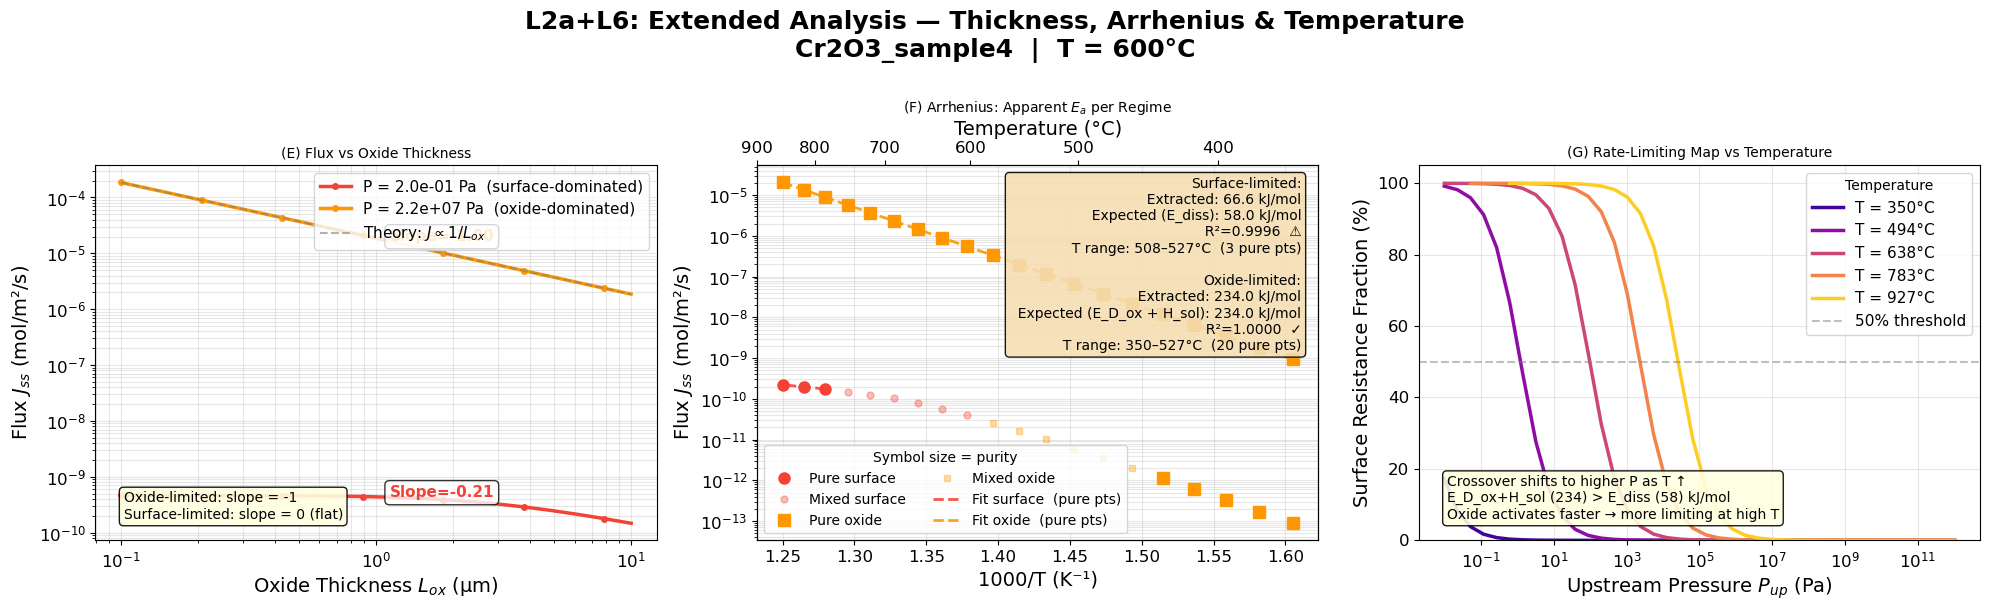


L2a+L6 FIGURE 2 — SUMMARY
  Surface: extracted=66.6  expected=58.0 kJ/mol  (⚠)  3 pure pts
  Oxide: extracted=234.0  expected=234.0 kJ/mol  (✓)  20 pure pts

  Crossover pressures across T sweep:
    T = 494°C  →  P_crossover = 6.24e-01 Pa
    T = 638°C  →  P_crossover = 8.89e+01 Pa
    T = 783°C  →  P_crossover = 1.06e+03 Pa
    T = 927°C  →  P_crossover = 1.27e+04 Pa


In [13]:
# =============================================================================
# CELL 5 — FIGURE 2: Extended Analysis (1×3)
# =============================================================================
"""
Figure 2 examines three additional dimensions: oxide thickness sensitivity,
Arrhenius activation energy per regime, and temperature effects on the
rate-limiting balance.

Panel (E) — Flux vs Oxide Thickness
    Question: How does flux respond to oxide thickness, and does the
    response change between surface-limited and oxide-limited regimes?
    Sweeps L_ox from 0.1 μm to 10 μm at fixed T and P. In the oxide-limited
    regime flux scales as J ∝ 1/L_ox (slope = -1 on log-log). In the
    surface-limited regime the surface kinetics is the bottleneck so oxide
    thickness has no effect — the curve goes flat. Two pressures are used:
    one in each dominant regime (from Cell 3). Both curves are plotted on
    the same axes. A theoretical J ∝ 1/L_ox reference line is overlaid to
    validate the oxide-limited slope.

Panel (F) — Arrhenius: apparent Ea per regime, classified by regime purity
    Question: Does the model extract the correct activation energy in each
    regime, and does it match the known reference values from config?
    Sweeps temperature from T_RANGE[0] to T_RANGE[1]. At each temperature
    all properties are recomputed via helper functions. The solver is called
    at two fixed pressures — one per dominant regime from Cell 3. Each T
    point is classified into one of five categories based on actual regime
    fractions: pure_surface, mixed_surface, pure_oxide, mixed_oxide, mixed.
    Large opaque markers = pure (used for fit). Small faded markers = mixed
    (shown for context, excluded from fit). Dashed line = Arrhenius fit
    through pure points only. Extracted Ea compared to config references.
    Dual x-axis: 1000/T bottom, °C top.

Panel (G) — Rate-Limiting Map: surface fraction vs pressure at multiple T
    Question: How does the balance between surface and oxide resistance shift
    as temperature increases, and in which direction does the crossover move?
    Runs the full pressure sweep at 5 temperatures spread across T_RANGE.
    Plots surface resistance fraction (%) vs pressure for each temperature
    using a plasma colormap — cool for low T, warm for high T. The direction
    of the crossover shift reveals whether surface kinetics or oxide diffusion
    activates faster with temperature, determined by comparing E_diss vs
    E_D_ox + H_sol_ox from config.
"""

fig2, axes2 = plt.subplots(1, 3, figsize=(20, 6))
fig2.suptitle(
    f'L2a+L6: Extended Analysis — Thickness, Arrhenius & Temperature\n'
    f'{OXIDE_KEY}  |  T = {T_op-273.15:.0f}°C',
    fontsize=STYLE['fontsize_suptitle'], fontweight='bold', y=1.01
)

# ─────────────────────────────────────────────────────────────────────────────
# (E) FLUX vs OXIDE THICKNESS
# ─────────────────────────────────────────────────────────────────────────────
ax_E = axes2[0]

L_ox_sweep = np.logspace(
    np.log10(CONDITIONS['L_oxide_range'][0]),
    np.log10(CONDITIONS['L_oxide_range'][1]),
    CONDITIONS['n_L_points']
)

pressure_cases = []
if P_for_surface_Ea is not None:
    pressure_cases.append((
        P_for_surface_Ea,
        CURVE_STYLES['surface_region']['color'],
        f'P = {P_for_surface_Ea:.1e} Pa  (surface-dominated)'
    ))
if P_for_oxide_Ea is not None:
    pressure_cases.append((
        P_for_oxide_Ea,
        CURVE_STYLES['oxide_region']['color'],
        f'P = {P_for_oxide_Ea:.1e} Pa  (oxide-dominated)'
    ))
if not pressure_cases:
    pressure_cases = [
        (1e2, CURVE_STYLES['surface_region']['color'], 'P = 1e2 Pa'),
        (1e8, CURVE_STYLES['oxide_region']['color'],   'P = 1e8 Pa'),
    ]

for P_fixed, color, lbl in pressure_cases:
    J_thickness = []
    for L_test in L_ox_sweep:
        try:
            r = solve_steady_state_flux_L2aL6(
                P_fixed, P_down,
                k_diss, K_eq, D_ox, K_ox, L_test
            )
            J_thickness.append(r['J_ss'])
        except Exception:
            J_thickness.append(np.nan)

    J_thickness = np.array(J_thickness)
    valid_th    = ~np.isnan(J_thickness) & (J_thickness > 0)
    if not np.any(valid_th):
        continue

    ax_E.loglog(
        L_ox_sweep[valid_th] * 1e6, J_thickness[valid_th],
        color=color, lw=STYLE['linewidth'],
        marker='o', ms=4, markevery=3,
        label=lbl
    )

    slope_th, *_ = stats.linregress(
        np.log10(L_ox_sweep[valid_th]),
        np.log10(np.abs(J_thickness[valid_th]))
    )
    mid_idx = np.sum(valid_th) // 2
    ax_E.text(
        L_ox_sweep[valid_th][mid_idx] * 1e6,
        J_thickness[valid_th][mid_idx],
        f'Slope={slope_th:.2f}',
        color=color,
        fontsize=STYLE['fontsize_annotation'],
        fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
    )

if P_for_oxide_Ea is not None:
    J_theory_ref = solve_steady_state_flux_L2aL6(
        P_for_oxide_Ea, P_down,
        k_diss, K_eq, D_ox, K_ox, L_ox_sweep[len(L_ox_sweep)//2]
    )['J_ss']
    L_ref    = L_ox_sweep[len(L_ox_sweep)//2]
    J_theory = J_theory_ref * (L_ref / L_ox_sweep)
    ax_E.loglog(
        L_ox_sweep * 1e6, J_theory,
        color='gray', ls='--', lw=1.5, alpha=0.6,
        label='Theory: $J \\propto 1/L_{ox}$'
    )

ax_E.text(
    0.05, 0.05,
    'Oxide-limited: slope = -1\nSurface-limited: slope = 0 (flat)',
    transform=ax_E.transAxes, fontsize=STYLE['fontsize_annotation']-1,
    va='bottom',
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9)
)
ax_E.set_xlabel('Oxide Thickness $L_{ox}$ (μm)',  fontsize=STYLE['fontsize_axis'])
ax_E.set_ylabel('Flux $J_{ss}$ (mol/m²/s)',        fontsize=STYLE['fontsize_axis'])
ax_E.set_title('(E) Flux vs Oxide Thickness',      fontsize=STYLE['fontsize_title'])
ax_E.legend(fontsize=STYLE['fontsize_legend']-1, loc='upper right')
ax_E.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax_E.tick_params(labelsize=STYLE['fontsize_tick'])

# ─────────────────────────────────────────────────────────────────────────────
# (F) ARRHENIUS — apparent Ea per regime, classified by regime purity
# ─────────────────────────────────────────────────────────────────────────────
ax_F = axes2[1]

temperatures_K = np.linspace(T_RANGE[0], 800, N_T)
inv_T          = 1000.0 / temperatures_K

def classify_regime_L2a(fs, fo, pure_thresh=0.90, mixed_thresh=0.50):
    if fs >= pure_thresh:    return 'pure_surface'
    elif fo >= pure_thresh:  return 'pure_oxide'
    elif fs >= mixed_thresh: return 'mixed_surface'
    elif fo >= mixed_thresh: return 'mixed_oxide'
    else:                    return 'mixed'

regime_class_styles = {
    'pure_surface':  {'color': CURVE_STYLES['surface_region']['color'], 'marker': 'o', 'ms': 8,  'alpha': 1.0},
    'mixed_surface': {'color': CURVE_STYLES['surface_region']['color'], 'marker': 'o', 'ms': 5,  'alpha': 0.35},
    'pure_oxide':    {'color': CURVE_STYLES['oxide_region']['color'],   'marker': 's', 'ms': 8,  'alpha': 1.0},
    'mixed_oxide':   {'color': CURVE_STYLES['oxide_region']['color'],   'marker': 's', 'ms': 5,  'alpha': 0.35},
    'mixed':         {'color': CURVE_STYLES['mixed_region']['color'],   'marker': 'x', 'ms': 6,  'alpha': 0.5},
}

regime_Ea_cases    = [
    ('surface', P_for_surface_Ea, CURVE_STYLES['surface_region']['color']),
    ('oxide',   P_for_oxide_Ea,   CURVE_STYLES['oxide_region']['color']),
]
results            = {}
plotted_cls_labels = set()

for label, P_fixed, color in regime_Ea_cases:
    if P_fixed is None:
        print(f"  ⚠  {label}: P_for_{label}_Ea is None — fit skipped")
        results[label] = None
        continue

    J_row     = []
    class_row = []

    for T_K in temperatures_K:
        try:
            r = solve_steady_state_flux_L2aL6(
                P_fixed, P_down,
                get_k_diss_at_T(T_K),
                get_K_eq_at_T(T_K),
                get_D_ox_at_T(T_K),
                get_K_ox_at_T(T_K),
                L_ox,
            )
            J_row.append(r['J_ss'])
            fs = r['resistances']['fraction_surface']
            fo = r['resistances']['fraction_oxide']
            class_row.append(classify_regime_L2a(fs, fo))
        except Exception:
            J_row.append(np.nan)
            class_row.append('mixed')

    J_arr_T   = np.array(J_row)
    class_arr = np.array(class_row)
    pure      = (class_arr == f'pure_{label}') & ~np.isnan(J_arr_T) & (J_arr_T > 0)

    # Plot all classified points onto ax_F
    for cls, sty in regime_class_styles.items():
        mask = (class_arr == cls) & ~np.isnan(J_arr_T) & (J_arr_T > 0)
        if not np.any(mask):
            continue
        cls_label = cls.replace('_', ' ').capitalize()
        ax_F.semilogy(
            inv_T[mask], J_arr_T[mask],
            ls='none',
            color=sty['color'], marker=sty['marker'],
            ms=sty['ms'], alpha=sty['alpha'],
            label=cls_label if cls_label not in plotted_cls_labels
                  else '_nolegend_'
        )
        plotted_cls_labels.add(cls_label)

    if np.sum(pure) < 3:
        print(f"  ⚠  {label}: only {np.sum(pure)} pure T points — fit skipped")
        results[label] = None
        continue

    slope, intercept, r_val, *_ = stats.linregress(
        inv_T[pure], np.log(J_arr_T[pure])
    )
    E_a = -slope * R * 1000

    results[label] = {
        'J': J_arr_T, 'valid': pure,
        'slope': slope, 'intercept': intercept,
        'r_sq': r_val**2, 'E_a': E_a,
        'P_fixed': P_fixed, 'color': color,
        'n_pure': int(np.sum(pure)),
        'T_pure_range': (temperatures_K[pure].min() - 273.15,
                         temperatures_K[pure].max() - 273.15),
    }

    # Fitted line onto ax_F
    ax_F.semilogy(
        inv_T[pure],
        np.exp(slope * inv_T[pure] + intercept),
        color=color, ls='--', lw=2.0, alpha=0.9,
        label=f'Fit {label}  (pure pts)'
    )

# Dual x-axis on ax_F
ax_F_top = ax_F.twiny()
ax_F_top.set_xlim(ax_F.get_xlim())
T_ticks_C = np.array([200, 300, 400, 500, 600, 700, 800, 900])
T_ticks_K = T_ticks_C + 273.15
in_range  = (T_ticks_K >= T_RANGE[0]) & (T_ticks_K <= T_RANGE[1])
if np.any(in_range):
    ax_F_top.set_xticks(1000.0 / T_ticks_K[in_range])
    ax_F_top.set_xticklabels([f'{t}' for t in T_ticks_C[in_range]])
ax_F_top.set_xlabel('Temperature (°C)', fontsize=STYLE['fontsize_axis'])
ax_F_top.tick_params(labelsize=STYLE['fontsize_tick'])

# Annotation box on ax_F
annot = []
for lbl, E_ref, ref_name in [
    ('surface', E_REF_SURFACE, 'E_diss'),
    ('oxide',   E_REF_OXIDE,   'E_D_ox + H_sol'),
]:
    res = results.get(lbl)
    if res is None:
        annot.append(f'{lbl.capitalize()}: not extractable')
        annot.append(f'  Expected ({ref_name}): {E_ref/1000:.1f} kJ/mol')
    else:
        match = abs(res['E_a'] - E_ref) < 3000
        annot.append(f'{lbl.capitalize()}-limited:')
        annot.append(f'  Extracted: {res["E_a"]/1000:.1f} kJ/mol')
        annot.append(f'  Expected ({ref_name}): {E_ref/1000:.1f} kJ/mol')
        annot.append(f'  R²={res["r_sq"]:.4f}  {"✓" if match else "⚠"}')
        annot.append(f'  T range: {res["T_pure_range"][0]:.0f}–'
                     f'{res["T_pure_range"][1]:.0f}°C  '
                     f'({res["n_pure"]} pure pts)')
    annot.append('')

ax_F.text(
    0.97, 0.97, '\n'.join(annot).rstrip(),
    transform=ax_F.transAxes, fontsize=STYLE['fontsize_annotation']-1,
    va='top', ha='right',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9)
)
ax_F.set_xlabel('1000/T (K⁻¹)',             fontsize=STYLE['fontsize_axis'])
ax_F.set_ylabel('Flux $J_{ss}$ (mol/m²/s)', fontsize=STYLE['fontsize_axis'])
ax_F.set_title('(F) Arrhenius: Apparent $E_a$ per Regime',
               fontsize=STYLE['fontsize_title'])
ax_F.legend(fontsize=STYLE['fontsize_legend']-2, loc='lower left',
            ncol=2, title='Symbol size = purity')
ax_F.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax_F.tick_params(labelsize=STYLE['fontsize_tick'])

# ─────────────────────────────────────────────────────────────────────────────
# (G) RATE-LIMITING MAP
# ─────────────────────────────────────────────────────────────────────────────
ax_G = axes2[2]

T_map_values        = np.linspace(T_RANGE[0], T_RANGE[1], 5)
T_colors            = plt.cm.plasma(np.linspace(0.1, 0.9, len(T_map_values)))
crossover_pressures = []

for T_K, col in zip(T_map_values, T_colors):
    fs_row = []
    for P_up in P_RANGE_ARR:
        try:
            r = solve_steady_state_flux_L2aL6(
                P_up, P_down,
                get_k_diss_at_T(T_K),
                get_K_eq_at_T(T_K),
                get_D_ox_at_T(T_K),
                get_K_ox_at_T(T_K),
                L_ox,
            )
            fs_row.append(r['resistances']['fraction_surface'] * 100)
        except Exception:
            fs_row.append(np.nan)

    fs_row    = np.array(fs_row)
    valid_row = ~np.isnan(fs_row)
    if not np.any(valid_row):
        continue

    ax_G.semilogx(
        P_RANGE_ARR[valid_row], fs_row[valid_row],
        color=col, lw=STYLE['linewidth'],
        label=f'T = {T_K-273.15:.0f}°C'
    )

    sc = np.where(np.diff(np.sign(fs_row[valid_row] - 50)))[0]
    if len(sc) > 0:
        idx  = sc[0]
        fs_v = fs_row[valid_row]
        if idx + 1 < len(fs_v) and fs_v[idx] > 50 and fs_v[idx+1] < 50:
            crossover_pressures.append((T_K, P_RANGE_ARR[valid_row][idx]))

ax_G.axhline(
    50,
    color=CURVE_STYLES['threshold']['color'],
    ls=CURVE_STYLES['threshold']['ls'],
    lw=CURVE_STYLES['threshold']['lw'],
    alpha=CURVE_STYLES['threshold']['alpha'],
    label='50% threshold'
)

if len(crossover_pressures) >= 2:
    T_low,  P_co_low  = crossover_pressures[0]
    T_high, P_co_high = crossover_pressures[-1]
    if P_co_high < P_co_low:
        direction = 'lower P as T ↑'
        physical  = (f'E_diss ({E_REF_SURFACE/1000:.0f}) > '
                     f'E_D_ox+H_sol ({E_REF_OXIDE/1000:.0f}) kJ/mol')
        meaning   = 'Surface activates faster → less limiting at high T'
    else:
        direction = 'higher P as T ↑'
        physical  = (f'E_D_ox+H_sol ({E_REF_OXIDE/1000:.0f}) > '
                     f'E_diss ({E_REF_SURFACE/1000:.0f}) kJ/mol')
        meaning   = 'Oxide activates faster → more limiting at high T'
    ax_G.text(
        0.05, 0.05,
        f'Crossover shifts to {direction}\n{physical}\n{meaning}',
        transform=ax_G.transAxes,
        fontsize=STYLE['fontsize_annotation']-1, va='bottom',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9)
    )
elif len(crossover_pressures) == 0:
    dominant = 'surface-limited' if n_surface > n_oxide else 'oxide-limited'
    ax_G.text(
        0.05, 0.05,
        f'No crossover at any T\nSystem is {dominant}\nacross full pressure range',
        transform=ax_G.transAxes,
        fontsize=STYLE['fontsize_annotation']-1, va='bottom',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9)
    )

ax_G.set_xlabel('Upstream Pressure $P_{up}$ (Pa)',  fontsize=STYLE['fontsize_axis'])
ax_G.set_ylabel('Surface Resistance Fraction (%)',  fontsize=STYLE['fontsize_axis'])
ax_G.set_title('(G) Rate-Limiting Map vs Temperature',
               fontsize=STYLE['fontsize_title'])
ax_G.set_ylim(0, 105)
ax_G.legend(fontsize=STYLE['fontsize_legend']-1, loc='upper right',
            title='Temperature')
ax_G.grid(True, alpha=STYLE['grid_alpha'])
ax_G.tick_params(labelsize=STYLE['fontsize_tick'])

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("L2a+L6 FIGURE 2 — SUMMARY")
print("=" * 60)
for lbl in ('surface', 'oxide'):
    res = results.get(lbl)
    E_ref = E_REF_SURFACE if lbl == 'surface' else E_REF_OXIDE
    if res is None:
        print(f"  {lbl.capitalize()}: not extractable")
    else:
        match = abs(res['E_a'] - E_ref) < 3000
        print(f"  {lbl.capitalize()}: extracted={res['E_a']/1000:.1f}  "
              f"expected={E_ref/1000:.1f} kJ/mol  "
              f"({'✓' if match else '⚠'})  "
              f"{res['n_pure']} pure pts")
if crossover_pressures:
    print(f"\n  Crossover pressures across T sweep:")
    for T_K, P_co in crossover_pressures:
        print(f"    T = {T_K-273.15:.0f}°C  →  P_crossover = {P_co:.2e} Pa")
else:
    dominant = 'surface-limited' if n_surface > n_oxide else 'oxide-limited'
    print(f"  No crossover found — system predominantly {dominant}")
print("=" * 60)

In [14]:
# =============================================================================
# CELL 6 — DATAFRAME OUTPUT
# =============================================================================
df = pd.DataFrame(rows)

df_display = df.copy()
for col in df_display.columns:
    if col in ('Rate-Limiting', 'Error'):
        continue
    if df_display[col].dtype == float:
        if 'fraction' in col.lower():
            df_display[col] = df_display[col].round(2)
        elif 'theta' in col.lower():
            df_display[col] = df_display[col].round(6)
        else:
            df_display[col] = df_display[col].apply(
                lambda x: f'{x:.4e}' if pd.notna(x) else 'NaN'
            )

n_surface_df = (df['Rate-Limiting'] == 'SURFACE').sum()
n_oxide_df   = (df['Rate-Limiting'] == 'OXIDE').sum()
n_mixed_df   = (df['Rate-Limiting'] == 'MIXED').sum()
n_error_df   = (df['Rate-Limiting'] == 'ERROR').sum()

print("=" * 60)
print("L2a+L6 RESULTS DATAFRAME")
print("=" * 60)
print(f"  Oxide:       {OXIDE_KEY}")
print(f"  T:           {T_op-273.15:.0f}°C  ({T_op} K)")
print(f"  L_ox:        {L_ox*1e6:.1f} μm")
print(f"  k_diss:      {k_diss:.3e}  mol/m²/s/Pa")
print(f"  K_eq:        {K_eq:.3e}  Pa⁻¹")
print(f"  D_ox:        {D_ox:.3e}  m²/s")
print(f"  K_ox:        {K_ox:.3e}  mol/m³/Pa^0.5")
print(f"\n  Total rows:        {len(df)}")
print(f"  Surface-limited:   {n_surface_df}")
print(f"  Oxide-limited:     {n_oxide_df}")
print(f"  Mixed:             {n_mixed_df}")
if n_error_df > 0:
    print(f"  Errors:            {n_error_df}  ⚠")
print("=" * 60)

display(df_display)

L2a+L6 RESULTS DATAFRAME
  Oxide:       Cr2O3_sample4
  T:           600°C  (873 K)
  L_ox:        0.0 μm
  k_diss:      2.370e-09  mol/m²/s/Pa
  K_eq:        2.799e-11  Pa⁻¹
  D_ox:        1.395e-17  m²/s
  K_ox:        2.869e+02  mol/m³/Pa^0.5

  Total rows:        40
  Surface-limited:   10
  Oxide-limited:     30
  Mixed:             0


,P_up (Pa),P_surf (Pa),J_ss (mol/m²/s),θ_surface,α_oxide,R_surface,R_oxide,R_total,fraction_surface (%),fraction_oxide (%),Rate-Limiting
0,1.0000e-02,8.0829e-08,2.3702e-11,1.5041e-09,8.3368e-08,4.2191e+10,1.1995e+07,4.2203e+10,99.97,0.03,SURFACE
1,2.2855e-02,4.2220e-07,5.4170e-11,3.4376e-09,8.3368e-08,1.8460e+10,1.1995e+07,1.8472e+10,99.94,0.06,SURFACE
2,5.2233e-02,2.2053e-06,1.2380e-10,7.8565e-09,8.3368e-08,8.0773e+09,1.1995e+07,8.0893e+09,99.85,0.15,SURFACE
3,1.1938e-01,1.1517e-05,2.8292e-10,1.7954e-08,8.3368e-08,3.5342e+09,1.1995e+07,3.5462e+09,99.66,0.34,SURFACE
4,2.7283e-01,6.0141e-05,6.4652e-10,4.1028e-08,8.3368e-08,1.5464e+09,1.1995e+07,1.5584e+09,99.23,0.77,SURFACE
5,6.2355e-01,3.1396e-04,1.4772e-09,9.3741e-08,8.3368e-08,6.7662e+08,1.1995e+07,6.8862e+08,98.26,1.74,SURFACE
6,1.4251e+00,1.6378e-03,3.3739e-09,2.1410e-07,8.3368e-08,2.9605e+08,1.1995e+07,3.0805e+08,96.11,3.89,SURFACE
7,3.2570e+00,8.5296e-03,7.6995e-09,4.8861e-07,8.3368e-08,1.2954e+08,1.1995e+07,1.4153e+08,91.52,8.48,SURFACE
8,7.4438e+00,4.4256e-02,1.7538e-08,1.1130e-06,8.3368e-08,5.6679e+07,1.1995e+07,6.8674e+07,82.53,17.47,SURFACE
9,1.7013e+01,2.2772e-01,3.9783e-08,2.5246e-06,8.3368e-08,2.4800e+07,1.1995e+07,3.6795e+07,67.40,32.60,SURFACE


### L2a +L6

In [15]:
# =============================================================================
# CELL 1 — SETUP
# Run once. All imports and helper functions.
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import brentq
import pandas as pd
from itertools import groupby
from operator import itemgetter
from IPython.display import display

from calculations.surface_kinetics import solve_steady_state_flux_direct
from calculations.config.model_config import (
    R, F,
    METALS, OXIDES, CONDITIONS,
    PLOT_STYLE as STYLE,
    CURVE_STYLES,
    apply_style,
    build_simulation_config,
)

# ── Simulation config ─────────────────────────────────────────────────────────
SIM       = build_simulation_config(
    metal='metal_X40_NiCrAlTi_31_19_Incoloy802_Schmidt1985',
    oxide='Cr2O3_sample4',
    T_operating=873,
    P_upstream=1e5,
    L_metal=1e-3,
)

METAL_KEY = SIM['metal_name']
OXIDE_KEY = SIM['oxide_name']
METAL     = METALS[METAL_KEY]
OXIDE     = OXIDES[OXIDE_KEY]
SK        = OXIDE['surface_kinetics']    # oxide surface kinetics sub-dict

# ── Pressure sweep ────────────────────────────────────────────────────────────
P_RANGE_ARR = np.logspace(0, 12, 100)
P_DOWN      = SIM['P_downstream']
T_RANGE     = CONDITIONS['T_range']
N_T         = CONDITIONS['n_T_points']

In [16]:
# =============================================================================
# CELL 2 — PARAMETERS
# All physics values at operating temperature, pulled from config.
# Change placeholder values in config and rerun from this cell downward.
# =============================================================================

# ── Operating conditions ──────────────────────────────────────────────────────
T_op   = SIM['T_operating']
L_ox   = SIM['L_oxide']
L_m    = SIM['L_metal']
P_down = SIM['P_downstream']

# ── Surface kinetics at T_op ──────────────────────────────────────────────────
k_diss   = get_k_diss_at_T(T_op)
K_eq     = get_K_eq_at_T(T_op)
k_recomb = k_diss / K_eq

# ── Oxide transport at T_op ───────────────────────────────────────────────────
D_ox = get_D_ox_at_T(T_op)
K_ox = get_K_ox_at_T(T_op)

# ── Metal transport at T_op ───────────────────────────────────────────────────
D_m   = get_D_m_at_T(T_op)
K_s_m = get_K_s_m_at_T(T_op)

# ── Derived ───────────────────────────────────────────────────────────────────
alpha = D_ox * K_ox / L_ox
beta  = D_m  * K_s_m / L_m

# ── Print verification ────────────────────────────────────────────────────────
print("=" * 60)
print(f"L2+L6 PARAMETERS AT T = {T_op-273.15:.0f}°C  ({T_op} K)")
print("=" * 60)

print(f"\n  Geometry")
print(f"    L_ox     = {L_ox:.3e}  m")
print(f"    L_m      = {L_m:.3e}  m")
print(f"    P_down   = {P_down:.1e}  Pa")

print(f"\n  Surface kinetics  [config: oxide surface_kinetics sub-dict]")
print(f"    k_diss   = {k_diss:.3e}  mol/m²/s/Pa")
print(f"    K_eq     = {K_eq:.3e}  Pa⁻¹")
print(f"    k_recomb = {k_recomb:.3e}  mol/m²/s  (= k_diss / K_eq)")

print(f"\n  Oxide transport  [config: Arrhenius]")
print(f"    D_ox     = {D_ox:.3e}  m²/s")
print(f"    K_ox     = {K_ox:.3e}  mol/m³/Pa^0.5")

print(f"\n  Metal transport  [config: Arrhenius]")
print(f"    D_m      = {D_m:.3e}  m²/s")
print(f"    K_s_m    = {K_s_m:.3e}  mol/m³/Pa^0.5")

print(f"\n  Derived")
print(f"    α        = {alpha:.3e}  mol/m²/s/Pa^0.5  (= D_ox × K_ox / L_ox)")
print(f"    β        = {beta:.3e}  mol/m²/s/Pa^0.5  (= D_m × K_s_m / L_m)")
print(f"    α/β      = {alpha/beta:.3e}  (oxide/metal permeance ratio)")

print(f"\n  Reference activation energies  [config]")
print(f"    E_diss        = {E_REF_SURFACE/1000:.1f} kJ/mol   (surface)")
print(f"    E_D_ox+H_sol  = {E_REF_OXIDE/1000:.1f} kJ/mol   (oxide permeation)")
print(f"    E_D+H_s       = {E_REF_METAL/1000:.1f} kJ/mol   (metal permeation)")

if SK['k_diss_ref'] <= 1e-12:
    print(f"\n  ⚠  WARNING: k_diss_ref = {SK['k_diss_ref']:.0e} looks like a placeholder.")
    print(f"     Update config oxide surface_kinetics sub-dict with literature values.")

print("\n" + "=" * 60)

L2+L6 PARAMETERS AT T = 600°C  (873 K)

  Geometry
    L_ox     = 4.800e-08  m
    L_m      = 1.000e-03  m
    P_down   = 0.0e+00  Pa

  Surface kinetics  [config: oxide surface_kinetics sub-dict]
    k_diss   = 2.370e-09  mol/m²/s/Pa
    K_eq     = 2.799e-11  Pa⁻¹
    k_recomb = 8.468e+01  mol/m²/s  (= k_diss / K_eq)

  Oxide transport  [config: Arrhenius]
    D_ox     = 1.395e-17  m²/s
    K_ox     = 2.869e+02  mol/m³/Pa^0.5

  Metal transport  [config: Arrhenius]
    D_m      = 2.487e-10  m²/s
    K_s_m    = 3.834e-02  mol/m³/Pa^0.5

  Derived
    α        = 8.337e-08  mol/m²/s/Pa^0.5  (= D_ox × K_ox / L_ox)
    β        = 9.534e-09  mol/m²/s/Pa^0.5  (= D_m × K_s_m / L_m)
    α/β      = 8.744e+00  (oxide/metal permeance ratio)

  Reference activation energies  [config]
    E_diss        = 58.0 kJ/mol   (surface)
    E_D_ox+H_sol  = 234.0 kJ/mol   (oxide permeation)
    E_D+H_s       = 79.4 kJ/mol   (metal permeation)



In [17]:
# =============================================================================
# CELL 3 — COMPUTE
# Single-pass loop over full pressure range.
# Builds all arrays, regime summary, and Arrhenius pressure selection.
# =============================================================================

# ── Single-pass loop ──────────────────────────────────────────────────────────
rows             = []
J_arr            = []
theta_arr        = []
P_int_arr        = []
frac_surface_arr = []
frac_oxide_arr   = []
frac_metal_arr   = []
R_surface_arr    = []
R_oxide_arr      = []
R_metal_arr      = []
R_total_arr      = []
rate_lim_arr     = []

for P_up in P_RANGE_ARR:
    try:
        r = solve_steady_state_flux_direct(
            P_up, P_down, L_m,
            k_diss, K_eq,
            D_ox, K_ox, L_ox,
            D_m, K_s_m
        )
        J_arr.append(r['J_ss'])
        theta_arr.append(r['theta'])
        P_int_arr.append(r['P_int'])
        frac_surface_arr.append(r['resistances']['fraction_surface'])
        frac_oxide_arr.append(r['resistances']['fraction_oxide'])
        frac_metal_arr.append(r['resistances']['fraction_metal'])
        R_surface_arr.append(r['resistances']['R_surface'])
        R_oxide_arr.append(r['resistances']['R_oxide'])
        R_metal_arr.append(r['resistances']['R_metal'])
        R_total_arr.append(r['resistances']['R_total'])
        rate_lim_arr.append(r['rate_limiting'])

        rows.append({
            'P_up (Pa)':            P_up,
            'P_int (Pa)':           r['P_int'],
            'J_ss (mol/m²/s)':      r['J_ss'],
            'θ_surface':            r['theta'],
            'α_oxide':              r['alpha'],
            'β_metal':              r['beta'],
            'R_surface':            r['resistances']['R_surface'],
            'R_oxide':              r['resistances']['R_oxide'],
            'R_metal':              r['resistances']['R_metal'],
            'R_total':              r['resistances']['R_total'],
            'fraction_surface (%)': r['resistances']['fraction_surface'] * 100,
            'fraction_oxide (%)':   r['resistances']['fraction_oxide']   * 100,
            'fraction_metal (%)':   r['resistances']['fraction_metal']   * 100,
            'Rate-Limiting':        r['rate_limiting'].upper(),
        })

    except Exception as e:
        for lst in [J_arr, theta_arr, P_int_arr, frac_surface_arr,
                    frac_oxide_arr, frac_metal_arr, R_surface_arr,
                    R_oxide_arr, R_metal_arr, R_total_arr]:
            lst.append(np.nan)
        rate_lim_arr.append('error')
        rows.append({'P_up (Pa)': P_up, 'Rate-Limiting': 'ERROR', 'Error': str(e)})

# ── Convert to arrays ─────────────────────────────────────────────────────────
J_arr            = np.array(J_arr)
theta_arr        = np.array(theta_arr)
P_int_arr        = np.array(P_int_arr)
frac_surface_arr = np.array(frac_surface_arr)
frac_oxide_arr   = np.array(frac_oxide_arr)
frac_metal_arr   = np.array(frac_metal_arr)
R_surface_arr    = np.array(R_surface_arr)
R_oxide_arr      = np.array(R_oxide_arr)
R_metal_arr      = np.array(R_metal_arr)
R_total_arr      = np.array(R_total_arr)
rate_lim_arr     = np.array(rate_lim_arr)
valid            = ~np.isnan(J_arr)

# ── Rate-limiting classification array ───────────────────────────────────────
rl_arr = np.where(frac_surface_arr > 0.5, 'surface',
         np.where(frac_oxide_arr   > 0.5, 'oxide',
         np.where(frac_metal_arr   > 0.5, 'metal', 'mixed')))

# ── Regime summary ────────────────────────────────────────────────────────────
n_surface = np.sum((frac_surface_arr > 0.5) & valid)
n_oxide   = np.sum((frac_oxide_arr   > 0.5) & valid)
n_metal   = np.sum((frac_metal_arr   > 0.5) & valid)
n_mixed   = np.sum(
    (frac_surface_arr <= 0.5) & (frac_oxide_arr <= 0.5) &
    (frac_metal_arr   <= 0.5) & valid
)

surf_dom_mask  = (frac_surface_arr > 0.90) & valid
oxide_dom_mask = (frac_oxide_arr   > 0.90) & valid
metal_dom_mask = (frac_metal_arr   > 0.90) & valid
P_surf_dom     = P_RANGE_ARR[surf_dom_mask]
P_oxide_dom    = P_RANGE_ARR[oxide_dom_mask]
P_metal_dom    = P_RANGE_ARR[metal_dom_mask]

# ── Arrhenius pressure selection (no crossover dependence) ───────────────────
P_for_surface_Ea = np.median(P_surf_dom)  if len(P_surf_dom)  > 3 else None
P_for_oxide_Ea   = np.median(P_oxide_dom) if len(P_oxide_dom) > 3 else None
P_for_metal_Ea   = np.median(P_metal_dom) if len(P_metal_dom) > 3 else None

# ── Crossover pressures (diagnostic only) ────────────────────────────────────
def find_crossover(frac_a, frac_b, valid_mask):
    """Find pressure where frac_a crosses frac_b (from above)."""
    vc = valid_mask & ~np.isnan(frac_a) & ~np.isnan(frac_b)
    if np.sum(vc) < 2:
        return None
    diff = frac_a[vc] - frac_b[vc]
    Pv   = P_RANGE_ARR[vc]
    sc   = np.where(np.diff(np.sign(diff)))[0]
    if len(sc) == 0:
        return None
    idx = sc[0]
    if diff[idx] > 0 and diff[idx+1] < 0:
        return Pv[idx]
    return None

P_cross_surf_oxide = find_crossover(frac_surface_arr, frac_oxide_arr, valid)
P_cross_surf_metal = find_crossover(frac_surface_arr, frac_metal_arr, valid)
P_cross_oxide_metal= find_crossover(frac_oxide_arr,   frac_metal_arr, valid)

# ── Print regime summary ──────────────────────────────────────────────────────
print("=" * 60)
print(f"L2+L6 REGIME SUMMARY  (T = {T_op-273.15:.0f}°C, {np.sum(valid)} valid points)")
print("=" * 60)

print(f"\n  Regime breakdown (dominant fraction > 50%)")
print(f"    Surface-limited:  {n_surface:3d} points")
print(f"    Oxide-limited:    {n_oxide:3d} points")
print(f"    Metal-limited:    {n_metal:3d} points")
print(f"    Mixed:            {n_mixed:3d} points")

print(f"\n  Dominant regions (fraction > 90%) — used for Arrhenius")
for label, dom, P_ea in [
    ('Surface', P_surf_dom,  P_for_surface_Ea),
    ('Oxide',   P_oxide_dom, P_for_oxide_Ea),
    ('Metal',   P_metal_dom, P_for_metal_Ea),
]:
    if len(dom) > 3:
        print(f"    {label}-dominant: {len(dom):3d} points  "
              f"P = {dom.min():.1e} – {dom.max():.1e} Pa  "
              f"→ P_for_{label.lower()}_Ea = {P_ea:.2e} Pa")
    else:
        print(f"    {label}-dominant: {len(dom):3d} points  "
              f"(insufficient — {label.lower()} Ea not extractable)")

print(f"\n  Crossover pressures (diagnostic only)")
for desc, P_co in [
    ('Surface → Oxide',  P_cross_surf_oxide),
    ('Surface → Metal',  P_cross_surf_metal),
    ('Oxide   → Metal',  P_cross_oxide_metal),
]:
    val = f'{P_co:.2e} Pa' if P_co is not None else 'not found'
    print(f"    {desc}:  {val}")

print(f"\n  α/β ratio:  {alpha/beta:.3e}")
print(f"  θ range:    {np.nanmin(theta_arr):.4f} → {np.nanmax(theta_arr):.4f}")
print(f"  J range:    {np.nanmin(J_arr):.2e} → {np.nanmax(J_arr):.2e} mol/m²/s")
print("=" * 60)

L2+L6 REGIME SUMMARY  (T = 600°C, 100 valid points)

  Regime breakdown (dominant fraction > 50%)
    Surface-limited:    5 points
    Oxide-limited:      0 points
    Metal-limited:     94 points
    Mixed:              1 points

  Dominant regions (fraction > 90%) — used for Arrhenius
    Surface-dominant:   0 points  (insufficient — surface Ea not extractable)
    Oxide-dominant:   0 points  (insufficient — oxide Ea not extractable)
    Metal-dominant:   0 points  (insufficient — metal Ea not extractable)

  Crossover pressures (diagnostic only)
    Surface → Oxide:  2.85e+01 Pa
    Surface → Metal:  3.05e+00 Pa
    Oxide   → Metal:  not found

  α/β ratio:  8.744e+00
  θ range:    0.0000 → 0.8410
  J range:    2.21e-09 → 8.56e-03 mol/m²/s


/var/folders/1n/dcvsyv296ql8fwf980zkh0d40000gp/T/ipykernel_61772/3983668606.py:340: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(fontsize=STYLE['fontsize_legend']-2, loc='lower left',


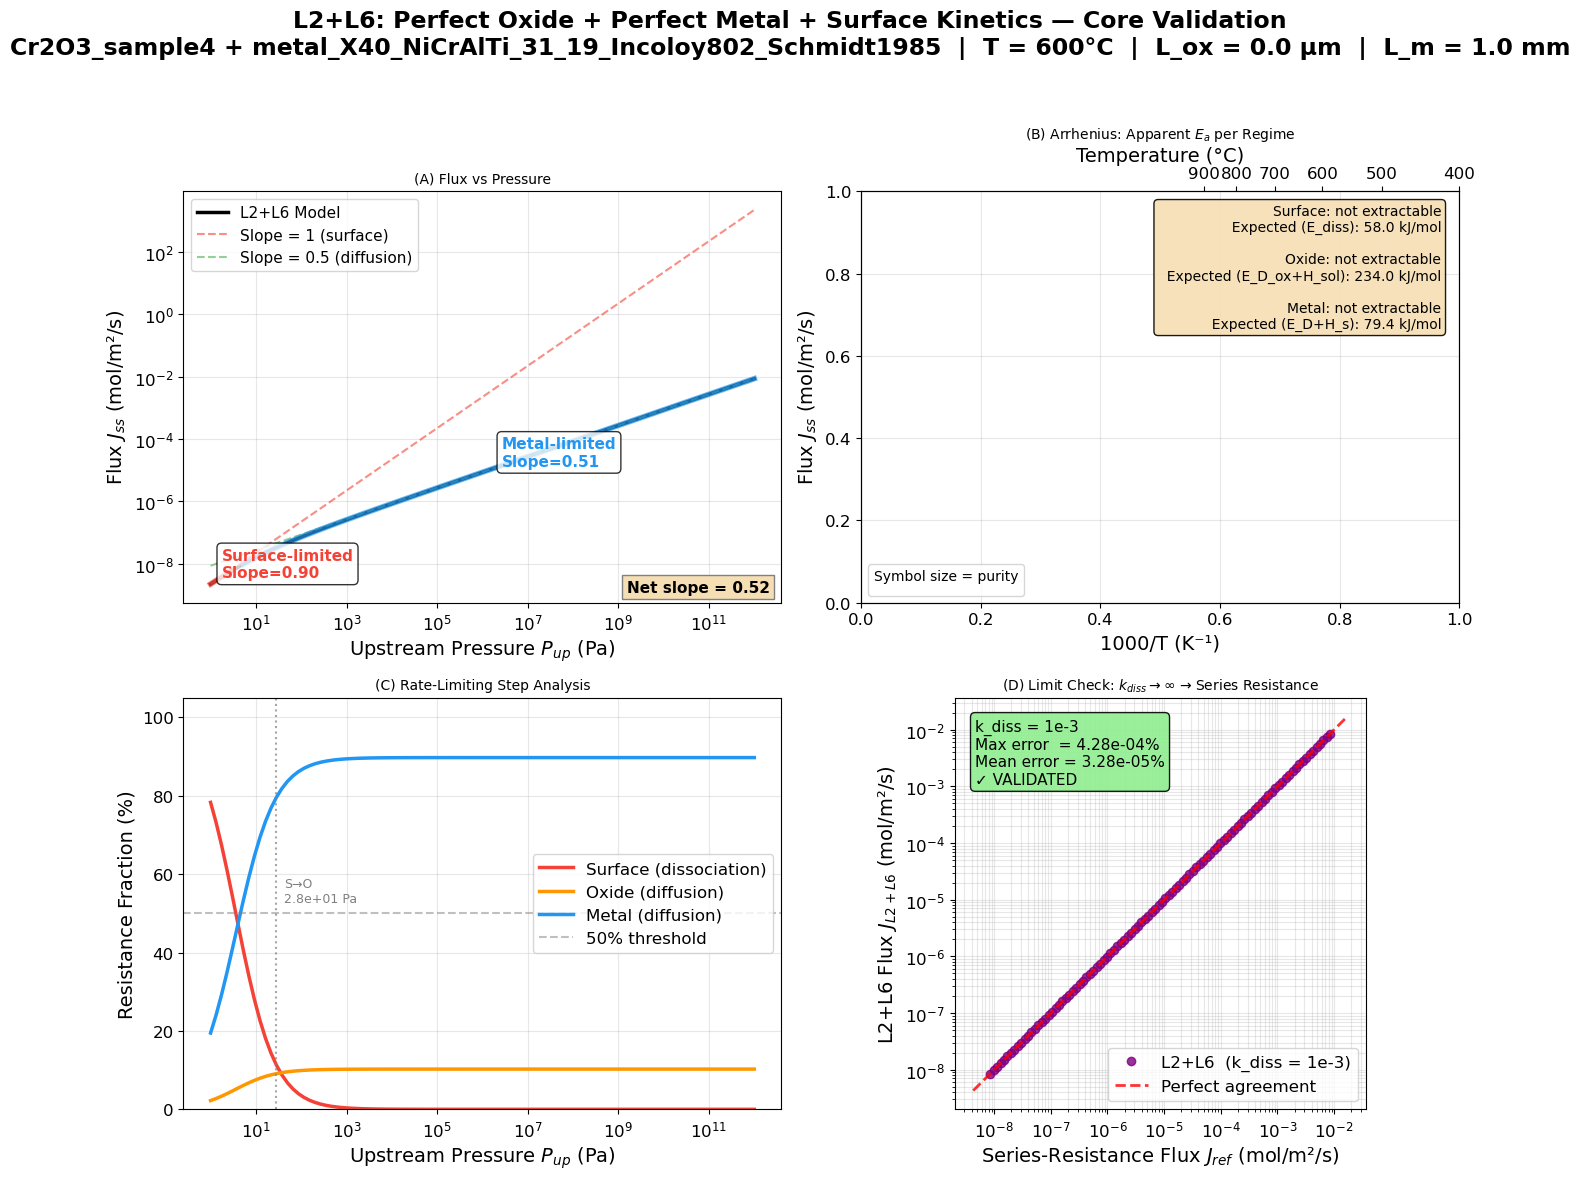


L2+L6 FIGURE 1 — VALIDATION SUMMARY
  Net log-log slope:       0.5222
  θ range:                 0.0000 → 0.8410
  Series limit error:      4.28e-04%  (✓)

  Arrhenius results:
    Surface: not extractable
    Oxide: not extractable
    Metal: not extractable


In [18]:
# =============================================================================
# CELL 4 — FIGURE 1: Core Validation (2×2)
# =============================================================================
"""
Figure 1 validates the L2+L6 model from four angles at operating temperature.
This is the first level with three competing resistances, making it the
canonical figure for the full series-resistance framework.

Panel (A) — Flux vs Pressure
    Question: Does the model produce the correct three-regime pressure
    behaviour?
    The hero plot. Shows J_ss vs P_up on a log-log scale. The curve should
    show three distinct regimes: slope≈1 (surface-limited, low P), slope≈0.5
    (oxide-limited or metal-limited, intermediate/high P), with possible
    transitions between them. Style follows the widget — no fill_between.
    The curve is recolored by regime using thick colored segments with slope
    annotation boxes sitting directly on each segment. The black model curve
    sits underneath, the colored overlay sits on top. Reference lines for
    slope=1 and slope=0.5 are drawn as dashed lines. Net slope annotation
    box in the bottom right corner.

Panel (B) — Arrhenius: apparent Ea per regime
    Question: Does the model extract the correct activation energy in each
    regime, and does it match the known reference values from config?
    Sweeps temperature from T_RANGE[0] to T_RANGE[1]. At each temperature
    all properties are recomputed via helper functions. The solver is called
    at up to three fixed pressures — one per dominant regime — selected in
    Cell 3 as the median of each dominant region (fraction > 90%). A linear
    fit to ln(J) vs 1000/T gives the apparent Ea for each regime. Extracted
    Ea is compared to config references: E_diss (surface), E_D_ox+H_sol_ox
    (oxide), E_D+H_s (metal). Dual x-axis: 1000/T bottom, °C top.

Panel (C) — Resistance Fractions vs Pressure
    Question: Which step controls the rate, and how does the balance shift
    with pressure?
    Plots R_surface/R_total, R_oxide/R_total, and R_metal/R_total as
    percentages vs pressure on a semilog scale — consistent with L1+L6
    and L2a+L6. With three resistances there can be two crossover
    pressures: surface→oxide (S→O) and oxide→metal (O→M). Both are
    marked with vertical lines if present. The 50% threshold line marks
    where each fraction is dominant. If no crossovers exist a text
    annotation states which regime dominates throughout.

Panel (D) — Limit Check: k_diss → ∞ recovers non-L6 result
    Question: As k_diss → ∞, does L2+L6 recover the oxide+metal result
    without surface kinetics?
    Runs the solver at k_diss = 1e-3 (fast kinetics limit) and compares
    J_L2+L6 against the analytical series-resistance flux:
    J = (sqrt(P_up) - sqrt(P_down)) / (1/alpha + 1/beta).
    A parity plot shows agreement — perfect match is a diagonal line.
    This validates the model correctly recovers the L2+L5 (no L6) limit
    when surface kinetics is fast. Green box if max error < 1%.
"""

props = dict(boxstyle='round', facecolor='wheat', alpha=0.9)

fig, axes = plt.subplots(2, 2, figsize=STYLE['figsize'])
fig.suptitle(
    f'L2+L6: Perfect Oxide + Perfect Metal + Surface Kinetics — Core Validation\n'
    f'{OXIDE_KEY} + {METAL_KEY}  |  T = {T_op-273.15:.0f}°C  |  '
    f'L_ox = {L_ox*1e6:.1f} μm  |  L_m = {L_m*1e3:.1f} mm',
    fontsize=STYLE['fontsize_suptitle']-1, fontweight='bold', y=0.98
)

# ─────────────────────────────────────────────────────────────────────────────
# (A) FLUX vs PRESSURE — three regimes
# ─────────────────────────────────────────────────────────────────────────────
ax1 = axes[0, 0]

ax1.loglog(
    P_RANGE_ARR[valid], J_arr[valid],
    color='black', lw=STYLE['linewidth'], label='L2+L6 Model'
)

if np.any(valid):
    P_ref1  = P_RANGE_ARR[valid][0]
    J_ref1  = J_arr[valid][0]
    ax1.loglog(
        P_RANGE_ARR[valid],
        J_ref1 * (P_RANGE_ARR[valid] / P_ref1) ** 1.0,
        color=CURVE_STYLES['slope_1']['color'],
        ls=CURVE_STYLES['slope_1']['ls'],
        lw=CURVE_STYLES['slope_1']['lw'],
        alpha=CURVE_STYLES['slope_1']['alpha'],
        label='Slope = 1 (surface)'
    )
    P_ref05 = P_RANGE_ARR[valid][-1]
    J_ref05 = J_arr[valid][-1]
    ax1.loglog(
        P_RANGE_ARR[valid],
        J_ref05 * (P_RANGE_ARR[valid] / P_ref05) ** 0.5,
        color=CURVE_STYLES['slope_05']['color'],
        ls=CURVE_STYLES['slope_05']['ls'],
        lw=CURVE_STYLES['slope_05']['lw'],
        alpha=CURVE_STYLES['slope_05']['alpha'],
        label='Slope = 0.5 (diffusion)'
    )

# Colored regime segments + slope annotation boxes
region_styles = [
    ('surface', CURVE_STYLES['surface_region']['color'], 'Surface-limited'),
    ('oxide',   CURVE_STYLES['oxide_region']['color'],   'Oxide-limited'),
    ('metal',   CURVE_STYLES['metal_region']['color'],   'Metal-limited'),
    ('mixed',   CURVE_STYLES['mixed_region']['color'],   'Mixed'),
]

for regime, color, label in region_styles:
    mask = (rl_arr == regime) & valid
    if not np.any(mask):
        continue
    idxs = np.where(mask)[0]
    for _, g in groupby(enumerate(idxs), lambda x: x[0] - x[1]):
        group = list(map(itemgetter(1), g))
        if len(group) < 3:
            continue
        P_seg = P_RANGE_ARR[group]
        J_seg = J_arr[group]
        ax1.loglog(P_seg, J_seg, color=color, lw=4, alpha=0.7)
        slope_seg, *_ = stats.linregress(
            np.log10(P_seg), np.log10(np.abs(J_seg))
        )
        mid = len(group) // 2
        ax1.text(
            P_seg[mid], J_seg[mid],
            f'{label}\nSlope={slope_seg:.2f}',
            color=color,
            fontsize=STYLE['fontsize_annotation'],
            fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
        )

log_P_v   = np.log10(P_RANGE_ARR[valid])
log_J_v   = np.log10(np.abs(J_arr[valid]))
slope_net, *_ = stats.linregress(log_P_v, log_J_v)

ax1.text(
    0.98, 0.02, f'Net slope = {slope_net:.2f}',
    transform=ax1.transAxes, ha='right', va='bottom',
    fontsize=STYLE['fontsize_annotation'], fontweight='bold',
    bbox=dict(boxstyle='square', fc='wheat', ec='gray', alpha=1)
)

ax1.set_xlabel('Upstream Pressure $P_{up}$ (Pa)', fontsize=STYLE['fontsize_axis'])
ax1.set_ylabel('Flux $J_{ss}$ (mol/m²/s)',         fontsize=STYLE['fontsize_axis'])
ax1.set_title('(A) Flux vs Pressure',               fontsize=STYLE['fontsize_title'])
ax1.legend(fontsize=STYLE['fontsize_legend']-1, loc='upper left')
ax1.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax1.tick_params(labelsize=STYLE['fontsize_tick'])

# ─────────────────────────────────────────────────────────────────────────────
# (B) ARRHENIUS — apparent Ea per regime, classified by regime purity
# ─────────────────────────────────────────────────────────────────────────────
ax2 = axes[0, 1]

temperatures_K = np.linspace(T_RANGE[0], T_RANGE[1], N_T)
inv_T          = 1000.0 / temperatures_K
arrhenius_results = {}

# ── Regime classification helper ─────────────────────────────────────────────
def classify_regime(fs, fo, fm, pure_thresh=0.90, mixed_thresh=0.50):
    """
    Classify a single T point into one of seven regime categories
    based on resistance fractions at that temperature and pressure.
    pure_thresh  : fraction above which a step is called 'pure'
    mixed_thresh : fraction above which a step is called 'dominant'
    """
    if fs >= pure_thresh:    return 'pure_surface'
    elif fo >= pure_thresh:  return 'pure_oxide'
    elif fm >= pure_thresh:  return 'pure_metal'
    elif fs >= mixed_thresh: return 'mixed_surface'
    elif fo >= mixed_thresh: return 'mixed_oxide'
    elif fm >= mixed_thresh: return 'mixed_metal'
    else:                    return 'mixed'

# ── Per-class plot styles ─────────────────────────────────────────────────────
regime_class_styles = {
    'pure_surface':  {'color': CURVE_STYLES['surface_region']['color'],
                      'marker': 'o', 'ms': 8,  'alpha': 1.0},
    'mixed_surface': {'color': CURVE_STYLES['surface_region']['color'],
                      'marker': 'o', 'ms': 5,  'alpha': 0.35},
    'pure_oxide':    {'color': CURVE_STYLES['oxide_region']['color'],
                      'marker': 's', 'ms': 8,  'alpha': 1.0},
    'mixed_oxide':   {'color': CURVE_STYLES['oxide_region']['color'],
                      'marker': 's', 'ms': 5,  'alpha': 0.35},
    'pure_metal':    {'color': CURVE_STYLES['metal_region']['color'],
                      'marker': '^', 'ms': 8,  'alpha': 1.0},
    'mixed_metal':   {'color': CURVE_STYLES['metal_region']['color'],
                      'marker': '^', 'ms': 5,  'alpha': 0.35},
    'mixed':         {'color': CURVE_STYLES['mixed_region']['color'],
                      'marker': 'x', 'ms': 6,  'alpha': 0.5},
}

regime_Ea_cases = [
    ('surface', P_for_surface_Ea, CURVE_STYLES['surface_region']['color'], 'o'),
    ('oxide',   P_for_oxide_Ea,   CURVE_STYLES['oxide_region']['color'],   's'),
    ('metal',   P_for_metal_Ea,   CURVE_STYLES['metal_region']['color'],   '^'),
]

plotted_class_labels = set()

for label, P_fixed, color, marker in regime_Ea_cases:
    if P_fixed is None:
        arrhenius_results[label] = None
        continue

    J_row     = []
    fs_row    = []
    fo_row    = []
    fm_row    = []
    class_row = []

    for T_K in temperatures_K:
        try:
            r = solve_steady_state_flux_direct(
                P_fixed, P_down, L_m,
                get_k_diss_at_T(T_K), get_K_eq_at_T(T_K),
                get_D_ox_at_T(T_K),   get_K_ox_at_T(T_K), L_ox,
                get_D_m_at_T(T_K),    get_K_s_m_at_T(T_K),
            )
            J_row.append(r['J_ss'])
            fs = r['resistances']['fraction_surface']
            fo = r['resistances']['fraction_oxide']
            fm = r['resistances']['fraction_metal']
            fs_row.append(fs)
            fo_row.append(fo)
            fm_row.append(fm)
            class_row.append(classify_regime(fs, fo, fm))
        except Exception:
            J_row.append(np.nan)
            fs_row.append(np.nan)
            fo_row.append(np.nan)
            fm_row.append(np.nan)
            class_row.append('mixed')

    J_arr_T   = np.array(J_row)
    class_arr = np.array(class_row)

    # Pure mask — only points classified as pure target regime
    pure = (class_arr == f'pure_{label}') & ~np.isnan(J_arr_T) & (J_arr_T > 0)

    # Plot all classified points with distinct size/alpha/marker
    for cls, sty in regime_class_styles.items():
        mask = (class_arr == cls) & ~np.isnan(J_arr_T) & (J_arr_T > 0)
        if not np.any(mask):
            continue
        cls_label = cls.replace('_', ' ').capitalize()
        ax2.semilogy(
            inv_T[mask], J_arr_T[mask],
            ls='none',
            color=sty['color'],
            marker=sty['marker'],
            ms=sty['ms'],
            alpha=sty['alpha'],
            label=cls_label if cls_label not in plotted_class_labels
                  else '_nolegend_'
        )
        plotted_class_labels.add(cls_label)

    # Arrhenius fit on pure points only
    if np.sum(pure) < 3:
        print(f"  ⚠  {label}: only {np.sum(pure)} pure T points "
              f"(fraction > 90%) — fit skipped")
        arrhenius_results[label] = None
        continue

    slope, intercept, r_val, *_ = stats.linregress(
        inv_T[pure], np.log(J_arr_T[pure])
    )
    E_a = -slope * R * 1000

    arrhenius_results[label] = {
        'J':            J_arr_T,
        'valid':        pure,
        'slope':        slope,
        'intercept':    intercept,
        'r_sq':         r_val**2,
        'E_a':          E_a,
        'P_fixed':      P_fixed,
        'color':        color,
        'n_pure':       int(np.sum(pure)),
        'T_pure_range': (temperatures_K[pure].min() - 273.15,
                         temperatures_K[pure].max() - 273.15),
        'class_arr':    class_arr,
    }

    # Fitted line through pure points only
    ax2.semilogy(
        inv_T[pure],
        np.exp(slope * inv_T[pure] + intercept),
        color=color, ls='--', lw=2.0, alpha=0.9,
        label=f'Fit {label}  (pure pts)'
    )

# ── Dual x-axis ───────────────────────────────────────────────────────────────
ax2_top = ax2.twiny()
ax2_top.set_xlim(ax2.get_xlim())
T_ticks_C = np.array([200, 300, 400, 500, 600, 700, 800, 900])
T_ticks_K = T_ticks_C + 273.15
in_range  = (T_ticks_K >= T_RANGE[0]) & (T_ticks_K <= T_RANGE[1])
if np.any(in_range):
    ax2_top.set_xticks(1000.0 / T_ticks_K[in_range])
    ax2_top.set_xticklabels([f'{t}' for t in T_ticks_C[in_range]])
ax2_top.set_xlabel('Temperature (°C)', fontsize=STYLE['fontsize_axis'])
ax2_top.tick_params(labelsize=STYLE['fontsize_tick'])

# ── Annotation box ────────────────────────────────────────────────────────────
E_refs    = {'surface': E_REF_SURFACE, 'oxide': E_REF_OXIDE, 'metal': E_REF_METAL}
ref_names = {'surface': 'E_diss', 'oxide': 'E_D_ox+H_sol', 'metal': 'E_D+H_s'}
annot     = []

for lbl in ('surface', 'oxide', 'metal'):
    res = arrhenius_results.get(lbl)
    E_r = E_refs[lbl]
    rn  = ref_names[lbl]
    if res is None:
        annot.append(f'{lbl.capitalize()}: not extractable')
        annot.append(f'  Expected ({rn}): {E_r/1000:.1f} kJ/mol')
    else:
        match = abs(res['E_a'] - E_r) < 3000
        annot.append(f'{lbl.capitalize()}-limited:')
        annot.append(f'  Extracted: {res["E_a"]/1000:.1f} kJ/mol')
        annot.append(f'  Expected ({rn}): {E_r/1000:.1f} kJ/mol')
        annot.append(f'  R²={res["r_sq"]:.4f}  {"✓" if match else "⚠"}')
        annot.append(f'  T range: {res["T_pure_range"][0]:.0f}–'
                     f'{res["T_pure_range"][1]:.0f}°C  '
                     f'({res["n_pure"]} pure pts)')
    annot.append('')

ax2.text(
    0.97, 0.97, '\n'.join(annot).rstrip(),
    transform=ax2.transAxes, fontsize=STYLE['fontsize_annotation']-1,
    va='top', ha='right',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9)
)

ax2.set_xlabel('1000/T (K⁻¹)',             fontsize=STYLE['fontsize_axis'])
ax2.set_ylabel('Flux $J_{ss}$ (mol/m²/s)', fontsize=STYLE['fontsize_axis'])
ax2.set_title('(B) Arrhenius: Apparent $E_a$ per Regime',
              fontsize=STYLE['fontsize_title'])
ax2.legend(fontsize=STYLE['fontsize_legend']-2, loc='lower left',
           ncol=2, title='Symbol size = purity')
ax2.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax2.tick_params(labelsize=STYLE['fontsize_tick'])

# ─────────────────────────────────────────────────────────────────────────────
# (C) RESISTANCE FRACTIONS vs PRESSURE
# ─────────────────────────────────────────────────────────────────────────────
ax3 = axes[1, 0]

ax3.semilogx(
    P_RANGE_ARR[valid], frac_surface_arr[valid] * 100,
    color=CURVE_STYLES['surface_region']['color'],
    lw=STYLE['linewidth'], label='Surface (dissociation)'
)
ax3.semilogx(
    P_RANGE_ARR[valid], frac_oxide_arr[valid] * 100,
    color=CURVE_STYLES['oxide_region']['color'],
    lw=STYLE['linewidth'], label='Oxide (diffusion)'
)
ax3.semilogx(
    P_RANGE_ARR[valid], frac_metal_arr[valid] * 100,
    color=CURVE_STYLES['metal_region']['color'],
    lw=STYLE['linewidth'], label='Metal (diffusion)'
)
ax3.axhline(
    50,
    color=CURVE_STYLES['threshold']['color'],
    ls=CURVE_STYLES['threshold']['ls'],
    lw=CURVE_STYLES['threshold']['lw'],
    alpha=CURVE_STYLES['threshold']['alpha'],
    label='50% threshold'
)

# Crossover annotations — up to two for three-resistance system
if P_cross_surf_oxide is not None:
    ax3.axvline(P_cross_surf_oxide, color='gray', ls=':', lw=1.5, alpha=0.7)
    ax3.text(
        P_cross_surf_oxide * 1.5, 53,
        f'S→O\n{P_cross_surf_oxide:.1e} Pa',
        fontsize=STYLE['fontsize_annotation']-2, color='gray'
    )
if P_cross_oxide_metal is not None:
    ax3.axvline(P_cross_oxide_metal, color='gray', ls=':', lw=1.5, alpha=0.7)
    ax3.text(
        P_cross_oxide_metal * 1.5, 53,
        f'O→M\n{P_cross_oxide_metal:.1e} Pa',
        fontsize=STYLE['fontsize_annotation']-2, color='gray'
    )

if P_cross_surf_oxide is None and P_cross_oxide_metal is None:
    dominant = ('Surface' if n_surface >= n_oxide and n_surface >= n_metal
                else 'Oxide' if n_oxide >= n_metal else 'Metal')
    ax3.text(
        0.05, 0.50,
        f'No crossover in range\n{dominant}-limited throughout',
        transform=ax3.transAxes,
        fontsize=STYLE['fontsize_annotation'],
        va='center',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9)
    )

ax3.set_xlabel('Upstream Pressure $P_{up}$ (Pa)', fontsize=STYLE['fontsize_axis'])
ax3.set_ylabel('Resistance Fraction (%)',          fontsize=STYLE['fontsize_axis'])
ax3.set_title('(C) Rate-Limiting Step Analysis',   fontsize=STYLE['fontsize_title'])
ax3.set_ylim(0, 105)
ax3.legend(fontsize=STYLE['fontsize_legend'], loc='center right')
ax3.grid(True, alpha=STYLE['grid_alpha'])
ax3.tick_params(labelsize=STYLE['fontsize_tick'])

# ─────────────────────────────────────────────────────────────────────────────
# (D) LIMIT CHECK — k_diss → ∞ recovers series resistance result
# ─────────────────────────────────────────────────────────────────────────────
ax4 = axes[1, 1]

# Series resistance reference (no surface kinetics)
# J = (sqrt(P_up) - sqrt(P_down)) / (1/alpha + 1/beta)
J_series = ((np.sqrt(P_RANGE_ARR) - np.sqrt(P_down)) /
            (1.0/alpha + 1.0/beta))

# L2+L6 at high k_diss
J_high_k = []
for P_up in P_RANGE_ARR:
    try:
        r = solve_steady_state_flux_direct(
            P_up, P_down, L_m,
            1e-3, K_eq,
            D_ox, K_ox, L_ox,
            D_m, K_s_m
        )
        J_high_k.append(r['J_ss'])
    except Exception:
        J_high_k.append(np.nan)
J_high_k = np.array(J_high_k)

valid_parity = ~np.isnan(J_high_k) & (J_series > 0) & (J_high_k > 0)

ax4.loglog(
    J_series[valid_parity], J_high_k[valid_parity],
    'o', color=CURVE_STYLES['L2_L6']['color'],
    markersize=6, alpha=0.8,
    label='L2+L6  (k_diss = 1e-3)'
)

J_min = min(J_series[valid_parity].min(), J_high_k[valid_parity].min()) * 0.5
J_max = max(J_series[valid_parity].max(), J_high_k[valid_parity].max()) * 2.0
ax4.loglog(
    [J_min, J_max], [J_min, J_max],
    color=CURVE_STYLES['parity']['color'],
    ls=CURVE_STYLES['parity']['ls'],
    lw=CURVE_STYLES['parity']['lw'],
    alpha=CURVE_STYLES['parity']['alpha'],
    label='Perfect agreement'
)

rel_errors = (np.abs(J_high_k[valid_parity] - J_series[valid_parity])
              / J_series[valid_parity] * 100)
max_err   = rel_errors.max()
mean_err  = rel_errors.mean()
box_color = 'lightgreen' if max_err < 1.0 else 'lightyellow'

ax4.text(
    0.05, 0.95,
    f'k_diss = 1e-3\n'
    f'Max error  = {max_err:.2e}%\n'
    f'Mean error = {mean_err:.2e}%\n'
    f'{"✓ VALIDATED" if max_err < 1.0 else "⚠ CHECK k_diss"}',
    transform=ax4.transAxes, fontsize=STYLE['fontsize_annotation'],
    va='top',
    bbox=dict(boxstyle='round', facecolor=box_color, alpha=0.9)
)

ax4.set_xlabel('Series-Resistance Flux $J_{ref}$ (mol/m²/s)', fontsize=STYLE['fontsize_axis'])
ax4.set_ylabel('L2+L6 Flux $J_{L2+L6}$ (mol/m²/s)',           fontsize=STYLE['fontsize_axis'])
ax4.set_title(r'(D) Limit Check: $k_{diss} \to \infty$ → Series Resistance',
              fontsize=STYLE['fontsize_title'])
ax4.set_aspect('equal', adjustable='box')
ax4.legend(fontsize=STYLE['fontsize_legend'], loc='lower right')
ax4.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax4.tick_params(labelsize=STYLE['fontsize_tick'])

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print("\n" + "=" * 60)
print("L2+L6 FIGURE 1 — VALIDATION SUMMARY")
print("=" * 60)
print(f"  Net log-log slope:       {slope_net:.4f}")
print(f"  θ range:                 "
      f"{np.nanmin(theta_arr):.4f} → {np.nanmax(theta_arr):.4f}")
print(f"  Series limit error:      {max_err:.2e}%  "
      f"({'✓' if max_err < 1.0 else '⚠'})")
print(f"\n  Arrhenius results:")
for lbl in ('surface', 'oxide', 'metal'):
    res = arrhenius_results.get(lbl)
    E_r = E_refs[lbl]
    if res is None:
        print(f"    {lbl.capitalize()}: not extractable")
    else:
        match = abs(res['E_a'] - E_r) < 3000
        print(f"    {lbl.capitalize()}: extracted={res['E_a']/1000:.1f} "
              f"expected={E_r/1000:.1f} kJ/mol  "
              f"{'✓' if match else '⚠'}")
print("=" * 60)

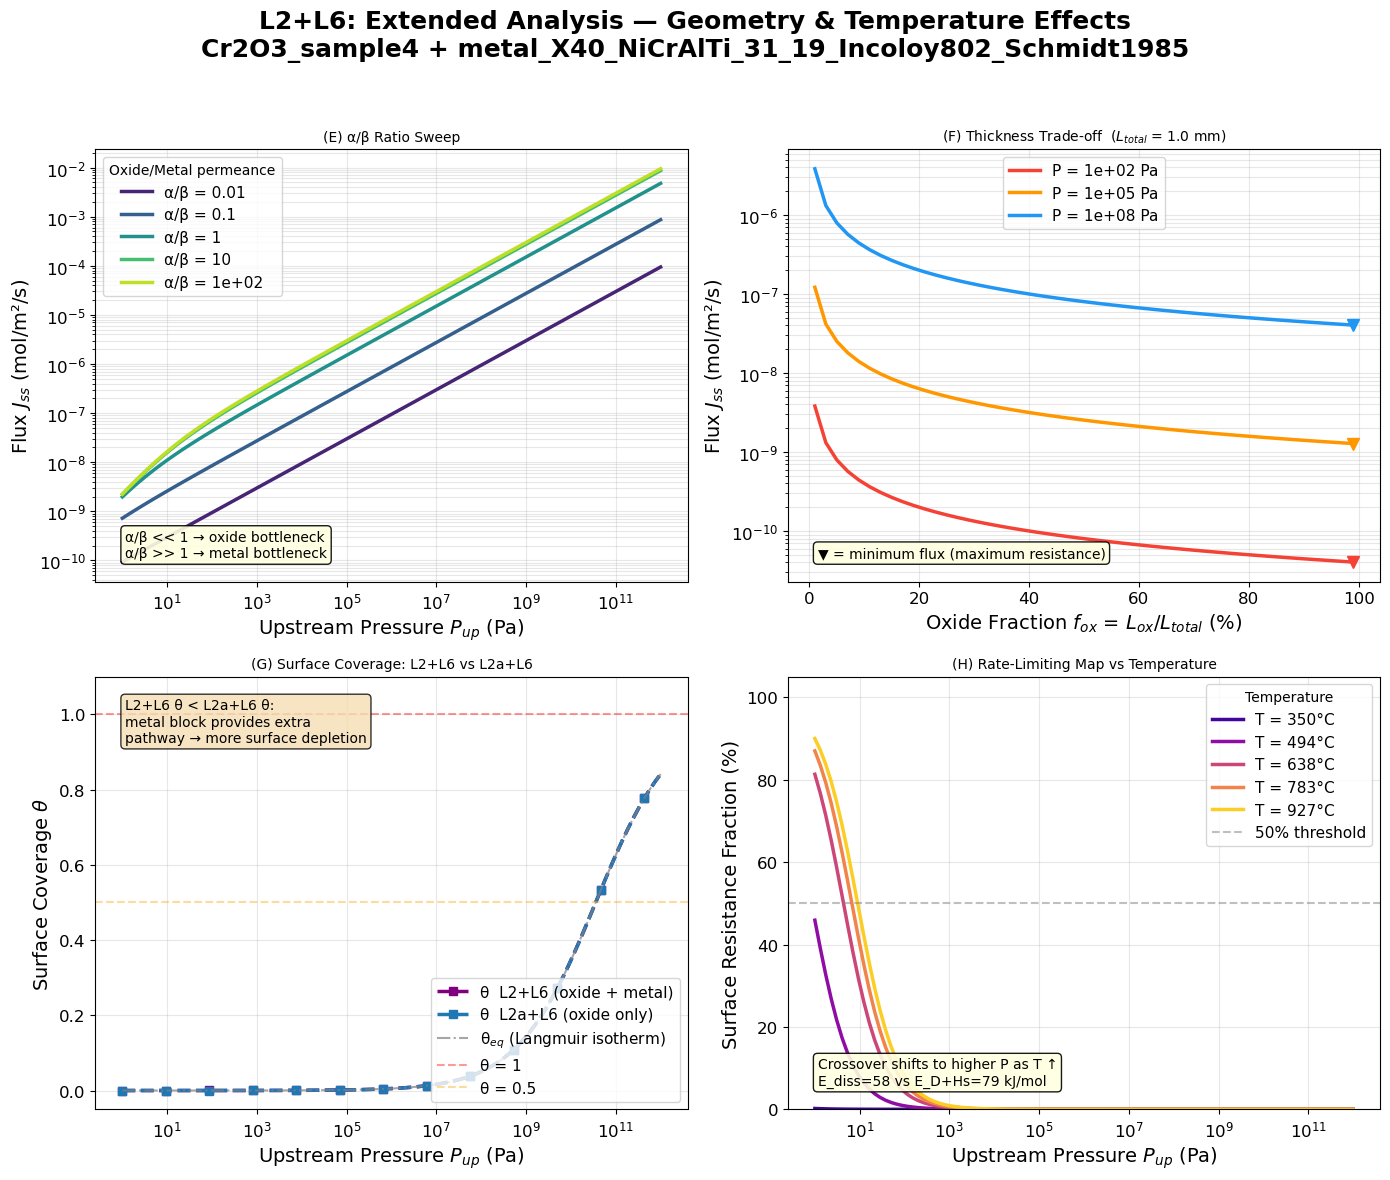


L2+L6 FIGURE 2 — SUMMARY
  α/β at operating conditions: 8.744e+00
  Surface/diffusion crossover across T sweep:
    T = 638°C  →  P_crossover = 4.04e+00 Pa
    T = 783°C  →  P_crossover = 5.34e+00 Pa
    T = 927°C  →  P_crossover = 7.05e+00 Pa


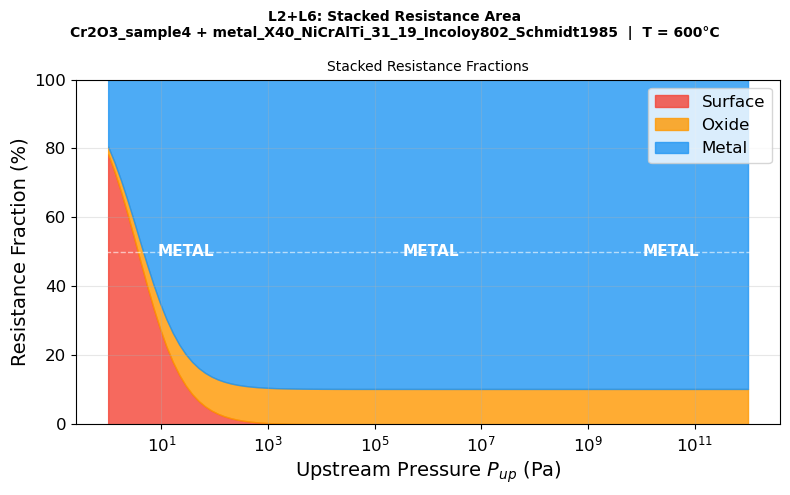

In [19]:
# =============================================================================
# CELL 5 — FIGURE 2: Extended Analysis (2×2)
# =============================================================================
"""
Figure 2 explores how system geometry and temperature affect the three-way
resistance balance.

Panel (E) — α/β Ratio Sweep
    Question: How does the oxide-to-metal permeance ratio determine which
    diffusion step is rate-limiting?
    Fixes surface kinetics and sweeps alpha/beta from 0.01 to 100 by varying
    alpha (oxide permeance) at fixed beta (metal permeance). At alpha/beta << 1
    the oxide is the bottleneck. At alpha/beta >> 1 the metal is the
    bottleneck. Plots J_ss vs P_up for several alpha/beta values on one axes.
    Each curve is labeled with its alpha/beta value. Shows that the
    surface-to-diffusion crossover pressure is independent of alpha/beta
    but the crossover between oxide-limited and metal-limited depends
    entirely on their ratio.

Panel (F) — Thickness Trade-off
    Question: If total membrane thickness is fixed, what is the optimal
    split between oxide and metal thickness?
    Co-varies L_ox and L_m at fixed total thickness L_total = L_ox + L_m.
    Plots J_ss vs the oxide fraction f_ox = L_ox / L_total. Shows there is
    a minimum flux (maximum resistance) at a specific oxide fraction, and
    that the minimum shifts with pressure and temperature.

Panel (G) — Surface Coverage θ vs Pressure
    Question: How does the addition of a metal block (vs L2a+L6) change
    the surface coverage behaviour?
    Plots steady-state θ alongside the Langmuir equilibrium isotherm.
    Compares θ_ss from L2+L6 against θ_ss from L2a+L6 at the same surface
    kinetics to isolate the effect of the metal block on surface coverage.
    The metal block provides an additional pathway for H to leave the
    surface, depleting θ further below equilibrium in the surface-limited
    regime.

Panel (H) — Rate-Limiting Map vs Temperature
    Question: How does the three-way balance shift with temperature?
    Runs the full pressure sweep at 5 temperatures spread across T_RANGE.
    Plots surface resistance fraction (%) vs pressure for each temperature
    using a plasma colormap. The crossover pressure shift direction is
    annotated with the physical reason from config activation energies.

Figure 3 (standalone) — Stacked Resistance Area
    Question: How do all three resistances share the total resistance burden
    visually across the full pressure range?
    Plots R_surface, R_oxide, and R_metal as a stacked area filling 100%
    at every pressure point. Unlike the line plot in panel (C), this shows
    all three fractions simultaneously as filled bands — any growth in one
    comes visually at the expense of the others. The dominant regime label
    is annotated at low, mid, and high pressure within the bands.
"""

from calculations.surface_kinetics import solve_steady_state_flux_L2aL6

fig2, axes2 = plt.subplots(2, 2, figsize=STYLE['figsize'])
fig2.suptitle(
    f'L2+L6: Extended Analysis — Geometry & Temperature Effects\n'
    f'{OXIDE_KEY} + {METAL_KEY}',
    fontsize=STYLE['fontsize_suptitle'], fontweight='bold', y=0.98
)

# ─────────────────────────────────────────────────────────────────────────────
# (E) α/β RATIO SWEEP
# ─────────────────────────────────────────────────────────────────────────────
ax_E = axes2[0, 0]

# Sweep alpha/beta by scaling alpha at fixed beta
ab_ratios  = [0.01, 0.1, 1.0, 10.0, 100.0]
ab_colors  = plt.cm.viridis(np.linspace(0.1, 0.9, len(ab_ratios)))

for ab, col in zip(ab_ratios, ab_colors):
    alpha_test = ab * beta    # scale alpha to hit target ratio
    J_ab = []
    for P_up in P_RANGE_ARR:
        try:
            # Equivalent D_ox for this alpha: D_ox_test = alpha_test * L_ox / K_ox
            D_ox_test = alpha_test * L_ox / K_ox
            r = solve_steady_state_flux_direct(
                P_up, P_down, L_m,
                k_diss, K_eq,
                D_ox_test, K_ox, L_ox,
                D_m, K_s_m
            )
            J_ab.append(r['J_ss'])
        except Exception:
            J_ab.append(np.nan)

    J_ab   = np.array(J_ab)
    v_ab   = ~np.isnan(J_ab) & (J_ab > 0)
    if not np.any(v_ab):
        continue

    ax_E.loglog(
        P_RANGE_ARR[v_ab], J_ab[v_ab],
        color=col, lw=STYLE['linewidth'],
        label=f'α/β = {ab:.2g}'
    )

ax_E.set_xlabel('Upstream Pressure $P_{up}$ (Pa)', fontsize=STYLE['fontsize_axis'])
ax_E.set_ylabel('Flux $J_{ss}$ (mol/m²/s)',         fontsize=STYLE['fontsize_axis'])
ax_E.set_title('(E) α/β Ratio Sweep',               fontsize=STYLE['fontsize_title'])
ax_E.legend(fontsize=STYLE['fontsize_legend']-1, loc='upper left',
            title='Oxide/Metal permeance')
ax_E.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax_E.tick_params(labelsize=STYLE['fontsize_tick'])
ax_E.text(
    0.05, 0.05,
    'α/β << 1 → oxide bottleneck\nα/β >> 1 → metal bottleneck',
    transform=ax_E.transAxes, fontsize=STYLE['fontsize_annotation']-1,
    va='bottom',
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9)
)

# ─────────────────────────────────────────────────────────────────────────────
# (F) THICKNESS TRADE-OFF
# ─────────────────────────────────────────────────────────────────────────────
ax_F = axes2[0, 1]

L_total     = L_ox + L_m
f_ox_sweep  = np.linspace(0.01, 0.99, 50)   # oxide fraction of total
P_cases     = [1e2, 1e5, 1e8]
P_colors_tf = [CURVE_STYLES['surface_region']['color'],
               CURVE_STYLES['oxide_region']['color'],
               CURVE_STYLES['metal_region']['color']]

for P_fixed, col in zip(P_cases, P_colors_tf):
    J_tf = []
    for f in f_ox_sweep:
        L_ox_t = f * L_total
        L_m_t  = (1 - f) * L_total
        try:
            r = solve_steady_state_flux_direct(
                P_fixed, P_down, L_m_t,
                k_diss, K_eq,
                D_ox, K_ox, L_ox_t,
                D_m, K_s_m
            )
            J_tf.append(r['J_ss'])
        except Exception:
            J_tf.append(np.nan)

    J_tf  = np.array(J_tf)
    v_tf  = ~np.isnan(J_tf) & (J_tf > 0)
    if not np.any(v_tf):
        continue

    ax_F.semilogy(
        f_ox_sweep[v_tf] * 100, J_tf[v_tf],
        color=col, lw=STYLE['linewidth'],
        label=f'P = {P_fixed:.0e} Pa'
    )

    # Mark minimum flux point
    min_idx = np.nanargmin(J_tf)
    if not np.isnan(J_tf[min_idx]):
        ax_F.plot(
            f_ox_sweep[min_idx] * 100, J_tf[min_idx],
            'v', color=col, ms=9
        )

ax_F.set_xlabel('Oxide Fraction $f_{ox}$ = $L_{ox}/L_{total}$ (%)',
                fontsize=STYLE['fontsize_axis'])
ax_F.set_ylabel('Flux $J_{ss}$ (mol/m²/s)',  fontsize=STYLE['fontsize_axis'])
ax_F.set_title(f'(F) Thickness Trade-off  ($L_{{total}}$ = {L_total*1e3:.1f} mm)',
               fontsize=STYLE['fontsize_title'])
ax_F.legend(fontsize=STYLE['fontsize_legend']-1, loc='upper center')
ax_F.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax_F.tick_params(labelsize=STYLE['fontsize_tick'])
ax_F.text(
    0.05, 0.05,
    '▼ = minimum flux (maximum resistance)',
    transform=ax_F.transAxes, fontsize=STYLE['fontsize_annotation']-1,
    va='bottom',
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9)
)

# ─────────────────────────────────────────────────────────────────────────────
# (G) SURFACE COVERAGE θ — L2+L6 vs L2a+L6
# ─────────────────────────────────────────────────────────────────────────────
ax_G = axes2[1, 0]

# L2a+L6 coverage for comparison (no metal block)
theta_L2a = []
for P_up in P_RANGE_ARR:
    try:
        r2a = solve_steady_state_flux_L2aL6(
            P_up, P_down,
            k_diss, K_eq, D_ox, K_ox, L_ox
        )
        theta_L2a.append(r2a['theta'])
    except Exception:
        theta_L2a.append(np.nan)
theta_L2a = np.array(theta_L2a)

# Equilibrium Langmuir isotherm
theta_eq = (np.sqrt(K_eq * P_RANGE_ARR) /
            (1 + np.sqrt(K_eq * P_RANGE_ARR)))

ax_G.semilogx(
    P_RANGE_ARR[valid], theta_arr[valid],
    color=CURVE_STYLES['L2_L6']['color'],
    ls=CURVE_STYLES['L2_L6']['ls'],
    lw=STYLE['linewidth'],
    marker=CURVE_STYLES['L2_L6']['marker'],
    ms=CURVE_STYLES['L2_L6']['ms'],
    markevery=8,
    label='θ  L2+L6 (oxide + metal)'
)

v2a = ~np.isnan(theta_L2a)
ax_G.semilogx(
    P_RANGE_ARR[v2a], theta_L2a[v2a],
    color=CURVE_STYLES['L2a_L6']['color'],
    ls=CURVE_STYLES['L2a_L6']['ls'],
    lw=STYLE['linewidth'],
    marker=CURVE_STYLES['L2a_L6']['marker'],
    ms=CURVE_STYLES['L2a_L6']['ms'],
    markevery=8,
    label='θ  L2a+L6 (oxide only)'
)

ax_G.semilogx(
    P_RANGE_ARR, theta_eq,
    color='gray', ls='-.', lw=1.5, alpha=0.7,
    label=r'θ$_{eq}$ (Langmuir isotherm)'
)
ax_G.axhline(1.0, color='red',    ls='--', lw=1.5, alpha=0.4, label='θ = 1')
ax_G.axhline(0.5, color='orange', ls='--', lw=1.5, alpha=0.4, label='θ = 0.5')

ax_G.text(
    0.05, 0.95,
    'L2+L6 θ < L2a+L6 θ:\nmetal block provides extra\n'
    'pathway → more surface depletion',
    transform=ax_G.transAxes, fontsize=STYLE['fontsize_annotation']-1,
    va='top',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8)
)

ax_G.set_xlabel('Upstream Pressure $P_{up}$ (Pa)', fontsize=STYLE['fontsize_axis'])
ax_G.set_ylabel('Surface Coverage $\\theta$',       fontsize=STYLE['fontsize_axis'])
ax_G.set_title('(G) Surface Coverage: L2+L6 vs L2a+L6',
               fontsize=STYLE['fontsize_title'])
ax_G.set_ylim(-0.05, 1.1)
ax_G.legend(fontsize=STYLE['fontsize_legend']-1, loc='lower right')
ax_G.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax_G.tick_params(labelsize=STYLE['fontsize_tick'])

# ─────────────────────────────────────────────────────────────────────────────
# (H) RATE-LIMITING MAP vs TEMPERATURE
# ─────────────────────────────────────────────────────────────────────────────
ax_H = axes2[1, 1]

T_map_values        = np.linspace(T_RANGE[0], T_RANGE[1], 5)
T_colors_map        = plt.cm.plasma(np.linspace(0.1, 0.9, len(T_map_values)))
crossover_pressures = []

for T_K, col in zip(T_map_values, T_colors_map):
    fs_row = []
    for P_up in P_RANGE_ARR:
        try:
            r = solve_steady_state_flux_direct(
                P_up, P_down, L_m,
                get_k_diss_at_T(T_K), get_K_eq_at_T(T_K),
                get_D_ox_at_T(T_K),   get_K_ox_at_T(T_K), L_ox,
                get_D_m_at_T(T_K),    get_K_s_m_at_T(T_K),
            )
            fs_row.append(r['resistances']['fraction_surface'] * 100)
        except Exception:
            fs_row.append(np.nan)

    fs_row    = np.array(fs_row)
    valid_row = ~np.isnan(fs_row)
    if not np.any(valid_row):
        continue

    ax_H.semilogx(
        P_RANGE_ARR[valid_row], fs_row[valid_row],
        color=col, lw=STYLE['linewidth'],
        label=f'T = {T_K-273.15:.0f}°C'
    )

    sc = np.where(np.diff(np.sign(fs_row[valid_row] - 50)))[0]
    if len(sc) > 0:
        idx  = sc[0]
        fs_v = fs_row[valid_row]
        if idx + 1 < len(fs_v) and fs_v[idx] > 50 and fs_v[idx+1] < 50:
            crossover_pressures.append((T_K, P_RANGE_ARR[valid_row][idx]))

ax_H.axhline(
    50,
    color=CURVE_STYLES['threshold']['color'],
    ls=CURVE_STYLES['threshold']['ls'],
    lw=CURVE_STYLES['threshold']['lw'],
    alpha=CURVE_STYLES['threshold']['alpha'],
    label='50% threshold'
)

if len(crossover_pressures) >= 2:
    T_low,  P_co_low  = crossover_pressures[0]
    T_high, P_co_high = crossover_pressures[-1]
    direction = 'lower P as T ↑' if P_co_high < P_co_low else 'higher P as T ↑'
    ax_H.text(
        0.05, 0.05,
        f'Crossover shifts to {direction}\n'
        f'E_diss={E_REF_SURFACE/1000:.0f} vs '
        f'E_D+Hs={E_REF_METAL/1000:.0f} kJ/mol',
        transform=ax_H.transAxes,
        fontsize=STYLE['fontsize_annotation']-1, va='bottom',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9)
    )
elif len(crossover_pressures) == 0:
    ax_H.text(
        0.05, 0.05,
        'No surface/diffusion crossover\nfound across T range',
        transform=ax_H.transAxes,
        fontsize=STYLE['fontsize_annotation']-1, va='bottom',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9)
    )

ax_H.set_xlabel('Upstream Pressure $P_{up}$ (Pa)',  fontsize=STYLE['fontsize_axis'])
ax_H.set_ylabel('Surface Resistance Fraction (%)',  fontsize=STYLE['fontsize_axis'])
ax_H.set_title('(H) Rate-Limiting Map vs Temperature',
               fontsize=STYLE['fontsize_title'])
ax_H.set_ylim(0, 105)
ax_H.legend(fontsize=STYLE['fontsize_legend']-1, loc='upper right',
            title='Temperature')
ax_H.grid(True, alpha=STYLE['grid_alpha'])
ax_H.tick_params(labelsize=STYLE['fontsize_tick'])

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print("\n" + "=" * 60)
print("L2+L6 FIGURE 2 — SUMMARY")
print("=" * 60)
print(f"  α/β at operating conditions: {alpha/beta:.3e}")
if crossover_pressures:
    print(f"  Surface/diffusion crossover across T sweep:")
    for T_K, P_co in crossover_pressures:
        print(f"    T = {T_K-273.15:.0f}°C  →  P_crossover = {P_co:.2e} Pa")
print("=" * 60)

# =============================================================================
# FIGURE 3 — Stacked Resistance Area (standalone)
# =============================================================================
fig3, ax_stack = plt.subplots(1, 1, figsize=(8, 5))
fig3.suptitle(
    f'L2+L6: Stacked Resistance Area\n'
    f'{OXIDE_KEY} + {METAL_KEY}  |  T = {T_op-273.15:.0f}°C',
    fontsize=STYLE['fontsize_title'], fontweight='bold'
)

fs = frac_surface_arr[valid] * 100
fo = frac_oxide_arr[valid]   * 100
fm = frac_metal_arr[valid]   * 100
Pv = P_RANGE_ARR[valid]

ax_stack.fill_between(
    Pv, 0, fs,
    color=CURVE_STYLES['surface_region']['color'],
    alpha=0.8, label='Surface'
)
ax_stack.fill_between(
    Pv, fs, fs + fo,
    color=CURVE_STYLES['oxide_region']['color'],
    alpha=0.8, label='Oxide'
)
ax_stack.fill_between(
    Pv, fs + fo, fs + fo + fm,
    color=CURVE_STYLES['metal_region']['color'],
    alpha=0.8, label='Metal'
)

ax_stack.set_xscale('log')
ax_stack.set_ylim(0, 100)
ax_stack.axhline(50, color='white', ls='--', lw=1.0, alpha=0.6)

# Dominant regime label at three representative pressures
for P_annot in [Pv[len(Pv)//8], Pv[len(Pv)//2], Pv[7*len(Pv)//8]]:
    idx = np.argmin(np.abs(Pv - P_annot))
    dom = rl_arr[valid][idx]
    ax_stack.text(
        P_annot, 50, dom.upper(),
        ha='center', va='center',
        fontsize=STYLE['fontsize_annotation'],
        color='white', fontweight='bold'
    )

ax_stack.set_xlabel('Upstream Pressure $P_{up}$ (Pa)', fontsize=STYLE['fontsize_axis'])
ax_stack.set_ylabel('Resistance Fraction (%)',          fontsize=STYLE['fontsize_axis'])
ax_stack.set_title('Stacked Resistance Fractions',      fontsize=STYLE['fontsize_title'])
ax_stack.legend(fontsize=STYLE['fontsize_legend'], loc='upper right')
ax_stack.grid(True, alpha=STYLE['grid_alpha'])
ax_stack.tick_params(labelsize=STYLE['fontsize_tick'])

plt.tight_layout()
plt.show()

In [20]:
# =============================================================================
# CELL 6 — DATAFRAME OUTPUT
# =============================================================================
df = pd.DataFrame(rows)

df_display = df.copy()
for col in df_display.columns:
    if col in ('Rate-Limiting', 'Error'):
        continue
    if df_display[col].dtype == float:
        if 'fraction' in col.lower():
            df_display[col] = df_display[col].round(2)
        elif 'theta' in col.lower():
            df_display[col] = df_display[col].round(6)
        else:
            df_display[col] = df_display[col].apply(
                lambda x: f'{x:.4e}' if pd.notna(x) else 'NaN'
            )

n_surface_df = (df['Rate-Limiting'] == 'SURFACE').sum()
n_oxide_df   = (df['Rate-Limiting'] == 'OXIDE').sum()
n_metal_df   = (df['Rate-Limiting'] == 'METAL').sum()
n_mixed_df   = (df['Rate-Limiting'] == 'MIXED').sum()
n_error_df   = (df['Rate-Limiting'] == 'ERROR').sum()

print("=" * 60)
print("L2+L6 RESULTS DATAFRAME")
print("=" * 60)
print(f"  Oxide:       {OXIDE_KEY}")
print(f"  Metal:       {METAL_KEY}")
print(f"  T:           {T_op-273.15:.0f}°C  ({T_op} K)")
print(f"  L_ox:        {L_ox*1e6:.1f} μm")
print(f"  L_m:         {L_m*1e3:.1f} mm")
print(f"  k_diss:      {k_diss:.3e}  mol/m²/s/Pa")
print(f"  K_eq:        {K_eq:.3e}  Pa⁻¹")
print(f"  α:           {alpha:.3e}  mol/m²/s/Pa^0.5")
print(f"  β:           {beta:.3e}  mol/m²/s/Pa^0.5")
print(f"  α/β:         {alpha/beta:.3e}")
print(f"\n  Total rows:        {len(df)}")
print(f"  Surface-limited:   {n_surface_df}")
print(f"  Oxide-limited:     {n_oxide_df}")
print(f"  Metal-limited:     {n_metal_df}")
print(f"  Mixed:             {n_mixed_df}")
if n_error_df > 0:
    print(f"  Errors:            {n_error_df}  ⚠")
print("=" * 60)

display(df_display)

L2+L6 RESULTS DATAFRAME
  Oxide:       Cr2O3_sample4
  Metal:       metal_X40_NiCrAlTi_31_19_Incoloy802_Schmidt1985
  T:           600°C  (873 K)
  L_ox:        0.0 μm
  L_m:         1.0 mm
  k_diss:      2.370e-09  mol/m²/s/Pa
  K_eq:        2.799e-11  Pa⁻¹
  α:           8.337e-08  mol/m²/s/Pa^0.5
  β:           9.534e-09  mol/m²/s/Pa^0.5
  α/β:         8.744e+00

  Total rows:        100
  Surface-limited:   5
  Oxide-limited:     0
  Metal-limited:     94
  Mixed:             1


,P_up (Pa),P_int (Pa),J_ss (mol/m²/s),θ_surface,α_oxide,β_metal,R_surface,R_oxide,R_metal,R_total,fraction_surface (%),fraction_oxide (%),fraction_metal (%),Rate-Limiting
0,1.0000e+00,5.3815e-02,2.2118e-09,1.3677e-06,8.3368e-08,9.5343e-09,4.2191e+08,1.1995e+07,1.0488e+08,5.3879e+08,78.31,2.23,19.47,SURFACE
1,1.3219e+00,9.0428e-02,2.8671e-09,1.7728e-06,8.3368e-08,9.5343e-09,3.1916e+08,1.1995e+07,1.0488e+08,4.3604e+08,73.20,2.75,24.05,SURFACE
2,1.7475e+00,1.5051e-01,3.6989e-09,2.2872e-06,8.3368e-08,9.5343e-09,2.4143e+08,1.1995e+07,1.0488e+08,3.5831e+08,67.38,3.35,29.27,SURFACE
3,2.3101e+00,2.4779e-01,4.7461e-09,2.9347e-06,8.3368e-08,9.5343e-09,1.8263e+08,1.1995e+07,1.0488e+08,2.9951e+08,60.98,4.00,35.02,SURFACE
4,3.0539e+00,4.0294e-01,6.0522e-09,3.7423e-06,8.3368e-08,9.5343e-09,1.3816e+08,1.1995e+07,1.0488e+08,2.5504e+08,54.17,4.70,41.13,SURFACE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,3.2745e+11,2.6367e+11,4.8957e-03,7.5169e-01,8.3368e-08,9.5343e-09,2.0897e-02,1.1995e+07,1.0488e+08,1.1688e+08,0.00,10.26,89.74,METAL
96,4.3288e+11,3.4855e+11,5.6289e-03,7.7682e-01,8.3368e-08,9.5343e-09,1.9567e-02,1.1995e+07,1.0488e+08,1.1688e+08,0.00,10.26,89.74,METAL
97,5.7224e+11,4.6075e+11,6.4718e-03,8.0007e-01,8.3368e-08,9.5343e-09,1.8446e-02,1.1995e+07,1.0488e+08,1.1688e+08,0.00,10.26,89.74,METAL
98,7.5646e+11,6.0908e+11,7.4410e-03,8.2146e-01,8.3368e-08,9.5343e-09,1.7497e-02,1.1995e+07,1.0488e+08,1.1688e+08,0.00,10.26,89.74,METAL


## Level 3+ L6: Surface Kinetics with Mixed Regimes

In [21]:
# =============================================================================
# CELL 1 — SETUP
# Run once. All imports and helper functions.
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import brentq
import pandas as pd
from itertools import groupby
from operator import itemgetter
from IPython.display import display

from calculations.surface_kinetics import (
    calculate_mixed_defect_flux_L6,
    calculate_path_flux_L6,
    solve_steady_state_flux_direct,
)
from calculations.config.model_config import (
    R, F,
    METALS, OXIDES, CONDITIONS, VALIDATION,
    PLOT_STYLE as STYLE,
    CURVE_STYLES,
    apply_style,
    build_simulation_config,
)

# ── Simulation config ─────────────────────────────────────────────────────────
SIM       = build_simulation_config(
    metal='metal_X40_NiCrAlTi_31_19_Incoloy802_Schmidt1985',
    oxide='Cr2O3_sample4',
    T_operating=873,
    P_upstream=1e5,
    L_metal=1e-3,
)

METAL_KEY  = SIM['metal_name']
OXIDE_KEY  = SIM['oxide_name']
METAL      = METALS[METAL_KEY]
OXIDE      = OXIDES[OXIDE_KEY]
SK_OX      = OXIDE['surface_kinetics']     # oxide surface kinetics
SK_M       = METAL['surface_kinetics']     # metal surface kinetics (pinhole)

# ── Pressure sweep ────────────────────────────────────────────────────────────
P_RANGE_ARR = np.logspace(-3, 12, 100)
P_DOWN      = SIM['P_downstream']
T_RANGE     = CONDITIONS['T_range']
N_T         = CONDITIONS['n_T_points']

# ── Arrhenius helper functions — oxide ───────────────────────────────────────
def get_k_diss_at_T(T_K):
    return SK_OX['k_diss_ref'] * np.exp(
        (-SK_OX['E_diss'] / R) * (1/T_K - 1/SK_OX['T_ref'])
    )

def get_K_eq_at_T(T_K):
    return SK_OX['K_eq_ref'] * np.exp(
        (-SK_OX['H_eq'] / R) * (1/T_K - 1/SK_OX['T_ref'])
    )

def get_D_ox_at_T(T_K):
    return OXIDE['D_ox_ref'] * np.exp(
        (-OXIDE['E_D_ox'] / R) * (1/T_K - 1/OXIDE['T_ref'])
    )

def get_K_ox_at_T(T_K):
    return OXIDE['K_ox_ref'] * np.exp(
        (-OXIDE['H_sol_ox'] / R) * (1/T_K - 1/OXIDE['T_ref'])
    )

# ── Arrhenius helper functions — metal ───────────────────────────────────────
def get_D_m_at_T(T_K):
    return METAL['D_ref'] * np.exp(
        (-METAL['E_D'] / R) * (1/T_K - 1/METAL['T_ref'])
    )

def get_K_s_m_at_T(T_K):
    return METAL['K_s_ref'] * np.exp(
        (-METAL['H_s'] / R) * (1/T_K - 1/METAL['T_ref'])
    )

def get_k_diss_metal_at_T(T_K):
    """Metal surface k_diss — used for pinhole paths when not Sieverts limit."""
    return SK_M['k_diss_metal_ref'] * np.exp(
        (-SK_M['E_diss_metal'] / R) * (1/T_K - 1/SK_M['T_ref'])
    )

def get_K_eq_metal_at_T(T_K):
    """Metal surface K_eq — used for pinhole paths when not Sieverts limit."""
    return SK_M['K_eq_metal_ref'] * np.exp(
        (-SK_M['H_eq_metal'] / R) * (1/T_K - 1/SK_M['T_ref'])
    )

# ── Known reference activation energies ──────────────────────────────────────
E_REF_SURFACE = SK_OX['E_diss']
E_REF_OXIDE   = OXIDE['E_D_ox'] + OXIDE['H_sol_ox']
E_REF_METAL   = METAL['E_D']    + METAL['H_s']

print("=" * 60)
print("SETUP COMPLETE")
print("=" * 60)
print(f"  Metal:           {METAL_KEY}")
print(f"  Oxide:           {OXIDE_KEY}")
print(f"  E_ref surface:   {E_REF_SURFACE/1000:.1f} kJ/mol  (E_diss)")
print(f"  E_ref oxide:     {E_REF_OXIDE/1000:.1f} kJ/mol  (E_D_ox + H_sol_ox)")
print(f"  E_ref metal:     {E_REF_METAL/1000:.1f} kJ/mol  (E_D + H_s)")
print(f"  P range:         {P_RANGE_ARR[0]:.0e} – {P_RANGE_ARR[-1]:.0e} Pa")
print(f"  T range:         {T_RANGE[0]} – {T_RANGE[1]} K")
print("=" * 60)

SETUP COMPLETE
  Metal:           metal_X40_NiCrAlTi_31_19_Incoloy802_Schmidt1985
  Oxide:           Cr2O3_sample4
  E_ref surface:   58.0 kJ/mol  (E_diss)
  E_ref oxide:     234.0 kJ/mol  (E_D_ox + H_sol_ox)
  E_ref metal:     79.4 kJ/mol  (E_D + H_s)
  P range:         1e-03 – 1e+12 Pa
  T range:         623 – 1200 K


In [22]:
# =============================================================================
# CELL 2 — PARAMETERS
# All physics values at operating temperature, pulled from config.
# Change values in config and rerun from this cell downward.
# =============================================================================

# ── Operating conditions ──────────────────────────────────────────────────────
T_op   = SIM['T_operating']
L_ox   = SIM['L_oxide']
L_m    = SIM['L_metal']
P_down = SIM['P_downstream']

# ── Surface kinetics at T_op — oxide surface ──────────────────────────────────
k_diss   = get_k_diss_at_T(T_op)
K_eq     = get_K_eq_at_T(T_op)
k_recomb = k_diss / K_eq

# ── Oxide transport at T_op ───────────────────────────────────────────────────
D_ox = get_D_ox_at_T(T_op)
K_ox = get_K_ox_at_T(T_op)

# ── Metal transport at T_op ───────────────────────────────────────────────────
D_m   = get_D_m_at_T(T_op)
K_s_m = get_K_s_m_at_T(T_op)

# ── Metal surface kinetics at T_op — for pinhole paths ───────────────────────
k_diss_metal = get_k_diss_metal_at_T(T_op)
K_eq_metal   = get_K_eq_metal_at_T(T_op)

# ── Derived permeances ────────────────────────────────────────────────────────
alpha_intact = D_ox * K_ox / L_ox
beta         = D_m  * K_s_m / L_m

# ── Defect configuration — from SIM (built by build_simulation_config) ────────
defect_config       = SIM['defect_config']
use_sieverts_pinhole = SIM['oxide_defects'].get('use_sieverts_pinhole', False)

# Pinhole kinetics: None triggers Sieverts limit inside the solver
k_diss_metal_arg = None if use_sieverts_pinhole else k_diss_metal
K_eq_metal_arg   = None if use_sieverts_pinhole else K_eq_metal

# ── Validation sweep parameters — from config ─────────────────────────────────
VAL_L3          = VALIDATION['L3']
f_compare       = VAL_L3['defect_fractions_compare']   # panel (A) sweep
f_defect_min    = VAL_L3['f_defect_min']               # panel (B) sweep
f_defect_max    = VAL_L3['f_defect_max']
n_defect_points = VAL_L3['n_defect_points']
f_limit_check   = VAL_L3['f_defect_limit_check']       # panel (D) limit

# ── Print verification ────────────────────────────────────────────────────────
print("=" * 60)
print(f"L3+L6 PARAMETERS AT T = {T_op-273.15:.0f}°C  ({T_op} K)")
print("=" * 60)

print(f"\n  Geometry")
print(f"    L_ox     = {L_ox:.3e}  m")
print(f"    L_m      = {L_m:.3e}  m")
print(f"    P_down   = {P_down:.1e}  Pa")

print(f"\n  Oxide surface kinetics  [config: oxide surface_kinetics]")
print(f"    k_diss   = {k_diss:.3e}  mol/m²/s/Pa")
print(f"    K_eq     = {K_eq:.3e}  Pa⁻¹")
print(f"    k_recomb = {k_recomb:.3e}  mol/m²/s")

print(f"\n  Oxide transport  [config: Arrhenius]")
print(f"    D_ox     = {D_ox:.3e}  m²/s")
print(f"    K_ox     = {K_ox:.3e}  mol/m³/Pa^0.5")

print(f"\n  Metal transport  [config: Arrhenius]")
print(f"    D_m      = {D_m:.3e}  m²/s")
print(f"    K_s_m    = {K_s_m:.3e}  mol/m³/Pa^0.5")

print(f"\n  Metal surface kinetics  [config: metal surface_kinetics]")
print(f"    k_diss_metal = {k_diss_metal:.3e}  mol/m²/s/Pa")
print(f"    K_eq_metal   = {K_eq_metal:.3e}  Pa⁻¹")
print(f"    Pinhole mode: {'Sieverts limit' if use_sieverts_pinhole else 'Metal surface kinetics'}")

print(f"\n  Derived permeances")
print(f"    α_intact = {alpha_intact:.3e}  mol/m²/s/Pa^0.5")
print(f"    β        = {beta:.3e}  mol/m²/s/Pa^0.5")
print(f"    α/β      = {alpha_intact/beta:.3e}")

print(f"\n  Defect configuration  [config: OXIDE_DEFECTS]")
total_f = sum(v['area_fraction'] for v in defect_config.values())
for path, cfg in defect_config.items():
    extras = ''
    if 'thickness_factor' in cfg:
        extras = f"  γ = {cfg['thickness_factor']}"
        alpha_path = alpha_intact / cfg['thickness_factor']
        extras += f"  → α_crack = {alpha_path:.2e}"
    if 'diffusivity_factor' in cfg:
        extras = f"  δ = {cfg['diffusivity_factor']}"
        alpha_path = cfg['diffusivity_factor'] * alpha_intact
        extras += f"  → α_GB = {alpha_path:.2e}"
    print(f"    {path:<16} f = {cfg['area_fraction']*100:.3f}%{extras}")
print(f"    {'intact':<16} f = {(1-total_f)*100:.3f}%  (= 1 - total defect)")
print(f"    Total defect fraction = {total_f*100:.3f}%")

if total_f > 0.5:
    print(f"\n  ⚠  WARNING: total defect fraction = {total_f*100:.1f}% — unusually high")
if total_f == 0:
    print(f"\n  ⚠  WARNING: all defect fractions are zero — L3+L6 = L2+L6")

print(f"\n  Reference activation energies  [config]")
print(f"    E_diss        = {E_REF_SURFACE/1000:.1f} kJ/mol")
print(f"    E_D_ox+H_sol  = {E_REF_OXIDE/1000:.1f} kJ/mol")
print(f"    E_D+H_s       = {E_REF_METAL/1000:.1f} kJ/mol")

print("\n" + "=" * 60)

L3+L6 PARAMETERS AT T = 600°C  (873 K)

  Geometry
    L_ox     = 4.800e-08  m
    L_m      = 1.000e-03  m
    P_down   = 0.0e+00  Pa

  Oxide surface kinetics  [config: oxide surface_kinetics]
    k_diss   = 2.370e-09  mol/m²/s/Pa
    K_eq     = 2.799e-11  Pa⁻¹
    k_recomb = 8.468e+01  mol/m²/s

  Oxide transport  [config: Arrhenius]
    D_ox     = 1.395e-17  m²/s
    K_ox     = 2.869e+02  mol/m³/Pa^0.5

  Metal transport  [config: Arrhenius]
    D_m      = 2.487e-10  m²/s
    K_s_m    = 3.834e-02  mol/m³/Pa^0.5

  Metal surface kinetics  [config: metal surface_kinetics]
    k_diss_metal = 4.611e-07  mol/m²/s/Pa
    K_eq_metal   = 8.212e-09  Pa⁻¹
    Pinhole mode: Metal surface kinetics

  Derived permeances
    α_intact = 8.337e-08  mol/m²/s/Pa^0.5
    β        = 9.534e-09  mol/m²/s/Pa^0.5
    α/β      = 8.744e+00

  Defect configuration  [config: OXIDE_DEFECTS]
    pinhole          f = 0.100%
    crack            f = 0.100%  γ = 0.1  → α_crack = 8.34e-07
    grain_boundary   f = 0.

In [23]:
# =============================================================================
# CELL 3 — COMPUTE
# Single-pass loop over full pressure range.
# Builds all arrays, regime summary, and Arrhenius pressure selection.
# =============================================================================

# ── Single-pass loop ──────────────────────────────────────────────────────────
rows              = []
J_arr             = []
J_intact_arr      = []
J_pinhole_arr     = []
J_crack_arr       = []
J_gb_arr          = []
frac_intact_arr   = []
frac_pinhole_arr  = []
frac_crack_arr    = []
frac_gb_arr       = []
enhancement_arr   = []
dominant_path_arr = []
frac_surface_arr  = []
frac_oxide_arr    = []
frac_metal_arr    = []
rate_lim_arr      = []

for P_up in P_RANGE_ARR:
    try:
        r = calculate_mixed_defect_flux_L6(
            P_up, P_down, L_m,
            k_diss, K_eq,
            D_ox, K_ox, L_ox,
            D_m, K_s_m,
            defect_config,
            k_diss_metal=k_diss_metal_arg,
            K_eq_metal=K_eq_metal_arg,
        )

        J_total      = r['J_total']
        enhancement  = r['enhancement_factor']
        dom_path     = r['dominant_path']
        fb           = r['flux_breakdown']

        # Per-path flux fractions
        frac_intact  = fb.get('intact',         {}).get('fraction_of_total', 0.0)
        frac_pinhole = fb.get('pinhole',         {}).get('fraction_of_total', 0.0)
        frac_crack   = fb.get('crack',           {}).get('fraction_of_total', 0.0)
        frac_gb      = fb.get('grain_boundary',  {}).get('fraction_of_total', 0.0)

        # Per-path absolute flux
        J_intact_v   = fb.get('intact',         {}).get('flux', np.nan)
        J_pinhole_v  = fb.get('pinhole',         {}).get('flux', np.nan)
        J_crack_v    = fb.get('crack',           {}).get('flux', np.nan)
        J_gb_v       = fb.get('grain_boundary',  {}).get('flux', np.nan)

        # Resistance fractions from dominant path
        if dom_path == 'intact':
            res = r['intact_path']['resistances']
        elif dom_path in r.get('defect_paths', {}):
            res = r['defect_paths'][dom_path]['path_result']['resistances']
        else:
            # Mixed — use intact path as proxy
            res = r['intact_path']['resistances']

        fs = res.get('fraction_surface', np.nan)
        fo = res.get('fraction_oxide',   np.nan)
        fm = res.get('fraction_metal',   np.nan)
        rl = r.get('system_rate_limiting', 'mixed')

        J_arr.append(J_total)
        J_intact_arr.append(J_intact_v)
        J_pinhole_arr.append(J_pinhole_v)
        J_crack_arr.append(J_crack_v)
        J_gb_arr.append(J_gb_v)
        frac_intact_arr.append(frac_intact)
        frac_pinhole_arr.append(frac_pinhole)
        frac_crack_arr.append(frac_crack)
        frac_gb_arr.append(frac_gb)
        enhancement_arr.append(enhancement)
        dominant_path_arr.append(dom_path)
        frac_surface_arr.append(fs)
        frac_oxide_arr.append(fo)
        frac_metal_arr.append(fm)
        rate_lim_arr.append(rl)

        rows.append({
            'P_up (Pa)':            P_up,
            'J_total (mol/m²/s)':   J_total,
            'J_intact':             J_intact_v,
            'J_pinhole':            J_pinhole_v,
            'J_crack':              J_crack_v,
            'J_grain_boundary':     J_gb_v,
            'frac_intact (%)':      frac_intact  * 100,
            'frac_pinhole (%)':     frac_pinhole * 100,
            'frac_crack (%)':       frac_crack   * 100,
            'frac_GB (%)':          frac_gb      * 100,
            'enhancement_factor':   enhancement,
            'dominant_path':        dom_path,
            'fraction_surface (%)': fs * 100 if not np.isnan(fs) else np.nan,
            'fraction_oxide (%)':   fo * 100 if not np.isnan(fo) else np.nan,
            'fraction_metal (%)':   fm * 100 if not np.isnan(fm) else np.nan,
            'system_rate_limiting': rl.upper(),
        })

    except Exception as e:
        for lst in [J_arr, J_intact_arr, J_pinhole_arr, J_crack_arr,
                    J_gb_arr, frac_intact_arr, frac_pinhole_arr,
                    frac_crack_arr, frac_gb_arr, enhancement_arr,
                    frac_surface_arr, frac_oxide_arr, frac_metal_arr]:
            lst.append(np.nan)
        dominant_path_arr.append('error')
        rate_lim_arr.append('error')
        rows.append({'P_up (Pa)': P_up, 'system_rate_limiting': 'ERROR',
                     'Error': str(e)})

# ── Convert to arrays ─────────────────────────────────────────────────────────
J_arr            = np.array(J_arr)
J_intact_arr     = np.array(J_intact_arr)
J_pinhole_arr    = np.array(J_pinhole_arr)
J_crack_arr      = np.array(J_crack_arr)
J_gb_arr         = np.array(J_gb_arr)
frac_intact_arr  = np.array(frac_intact_arr)
frac_pinhole_arr = np.array(frac_pinhole_arr)
frac_crack_arr   = np.array(frac_crack_arr)
frac_gb_arr      = np.array(frac_gb_arr)
enhancement_arr  = np.array(enhancement_arr)
frac_surface_arr = np.array(frac_surface_arr)
frac_oxide_arr   = np.array(frac_oxide_arr)
frac_metal_arr   = np.array(frac_metal_arr)
rate_lim_arr     = np.array(rate_lim_arr)
dominant_path_arr= np.array(dominant_path_arr)
valid            = ~np.isnan(J_arr)

# ── Rate-limiting classification (dominant path) ──────────────────────────────
rl_arr = np.where(frac_surface_arr > 0.5, 'surface',
         np.where(frac_oxide_arr   > 0.5, 'oxide',
         np.where(frac_metal_arr   > 0.5, 'metal', 'mixed')))

# ── Regime summary ────────────────────────────────────────────────────────────
n_surface = np.sum((frac_surface_arr > 0.5) & valid)
n_oxide   = np.sum((frac_oxide_arr   > 0.5) & valid)
n_metal   = np.sum((frac_metal_arr   > 0.5) & valid)
n_mixed   = np.sum(
    (frac_surface_arr <= 0.5) & (frac_oxide_arr <= 0.5) &
    (frac_metal_arr   <= 0.5) & valid
)

surf_dom_mask  = (frac_surface_arr > 0.90) & valid
oxide_dom_mask = (frac_oxide_arr   > 0.90) & valid
metal_dom_mask = (frac_metal_arr   > 0.90) & valid
P_surf_dom     = P_RANGE_ARR[surf_dom_mask]
P_oxide_dom    = P_RANGE_ARR[oxide_dom_mask]
P_metal_dom    = P_RANGE_ARR[metal_dom_mask]

# ── Arrhenius pressure selection ──────────────────────────────────────────────
P_for_surface_Ea = np.median(P_surf_dom)  if len(P_surf_dom)  > 3 else None
P_for_oxide_Ea   = np.median(P_oxide_dom) if len(P_oxide_dom) > 3 else None
P_for_metal_Ea   = np.median(P_metal_dom) if len(P_metal_dom) > 3 else None

# ── Dominant path summary ─────────────────────────────────────────────────────
dom_counts = {}
for p in ['intact', 'pinhole', 'crack', 'grain_boundary', 'mixed', 'error']:
    dom_counts[p] = np.sum(dominant_path_arr == p)

# ── Crossover pressures (diagnostic) ─────────────────────────────────────────
def find_crossover(frac_a, frac_b, valid_mask):
    vc   = valid_mask & ~np.isnan(frac_a) & ~np.isnan(frac_b)
    if np.sum(vc) < 2:
        return None
    diff = frac_a[vc] - frac_b[vc]
    Pv   = P_RANGE_ARR[vc]
    sc   = np.where(np.diff(np.sign(diff)))[0]
    if len(sc) == 0:
        return None
    idx = sc[0]
    return Pv[idx] if diff[idx] > 0 else None

P_cross_surf_oxide = find_crossover(frac_surface_arr, frac_oxide_arr, valid)
P_cross_surf_metal = find_crossover(frac_surface_arr, frac_metal_arr, valid)
P_cross_oxide_metal= find_crossover(frac_oxide_arr,   frac_metal_arr, valid)

# ── Print regime summary ──────────────────────────────────────────────────────
print("=" * 60)
print(f"L3+L6 REGIME SUMMARY  (T = {T_op-273.15:.0f}°C, {np.sum(valid)} valid points)")
print("=" * 60)

print(f"\n  Resistance regime (dominant path fractions > 50%)")
print(f"    Surface-limited:  {n_surface:3d} points")
print(f"    Oxide-limited:    {n_oxide:3d} points")
print(f"    Metal-limited:    {n_metal:3d} points")
print(f"    Mixed:            {n_mixed:3d} points")

print(f"\n  Dominant oxide path")
for path, count in dom_counts.items():
    if count > 0:
        print(f"    {path:<18} {count:3d} points")

print(f"\n  Dominant regions (fraction > 90%) — used for Arrhenius")
for label, dom, P_ea in [
    ('Surface', P_surf_dom,  P_for_surface_Ea),
    ('Oxide',   P_oxide_dom, P_for_oxide_Ea),
    ('Metal',   P_metal_dom, P_for_metal_Ea),
]:
    if len(dom) > 3:
        print(f"    {label}-dominant: {len(dom):3d} points  "
              f"P = {dom.min():.1e} – {dom.max():.1e} Pa  "
              f"→ P_for_{label.lower()}_Ea = {P_ea:.2e} Pa")
    else:
        print(f"    {label}-dominant: {len(dom):3d} points  "
              f"(insufficient — {label.lower()} Ea not extractable)")

print(f"\n  Crossover pressures (diagnostic only)")
for desc, P_co in [
    ('Surface → Oxide', P_cross_surf_oxide),
    ('Surface → Metal', P_cross_surf_metal),
    ('Oxide   → Metal', P_cross_oxide_metal),
]:
    val = f'{P_co:.2e} Pa' if P_co is not None else 'not found'
    print(f"    {desc}:  {val}")

print(f"\n  Enhancement factor range:")
valid_enh = enhancement_arr[valid & ~np.isnan(enhancement_arr)]
if len(valid_enh) > 0:
    print(f"    Min = {valid_enh.min():.3f}  Max = {valid_enh.max():.3f}")

print(f"\n  J range:  {np.nanmin(J_arr):.2e} → {np.nanmax(J_arr):.2e} mol/m²/s")
print("=" * 60)

L3+L6 REGIME SUMMARY  (T = 600°C, 100 valid points)

  Resistance regime (dominant path fractions > 50%)
    Surface-limited:   24 points
    Oxide-limited:      0 points
    Metal-limited:     75 points
    Mixed:              1 points

  Dominant oxide path
    intact             100 points

  Dominant regions (fraction > 90%) — used for Arrhenius
    Surface-dominant:  18 points  P = 1.0e-03 – 3.8e-01 Pa  → P_for_surface_Ea = 1.97e-02 Pa
    Oxide-dominant:   0 points  (insufficient — oxide Ea not extractable)
    Metal-dominant:   0 points  (insufficient — metal Ea not extractable)

  Crossover pressures (diagnostic only)
    Surface → Oxide:  3.51e+01 Pa
    Surface → Metal:  3.05e+00 Pa
    Oxide   → Metal:  not found

  Enhancement factor range:
    Min = 1.000  Max = 1.091

  J range:  2.59e-12 → 8.56e-03 mol/m²/s


Panel (A): 100 pressure points  1.0e-03 – 1.0e+12 Pa


/var/folders/1n/dcvsyv296ql8fwf980zkh0d40000gp/T/ipykernel_61772/819424877.py:630: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


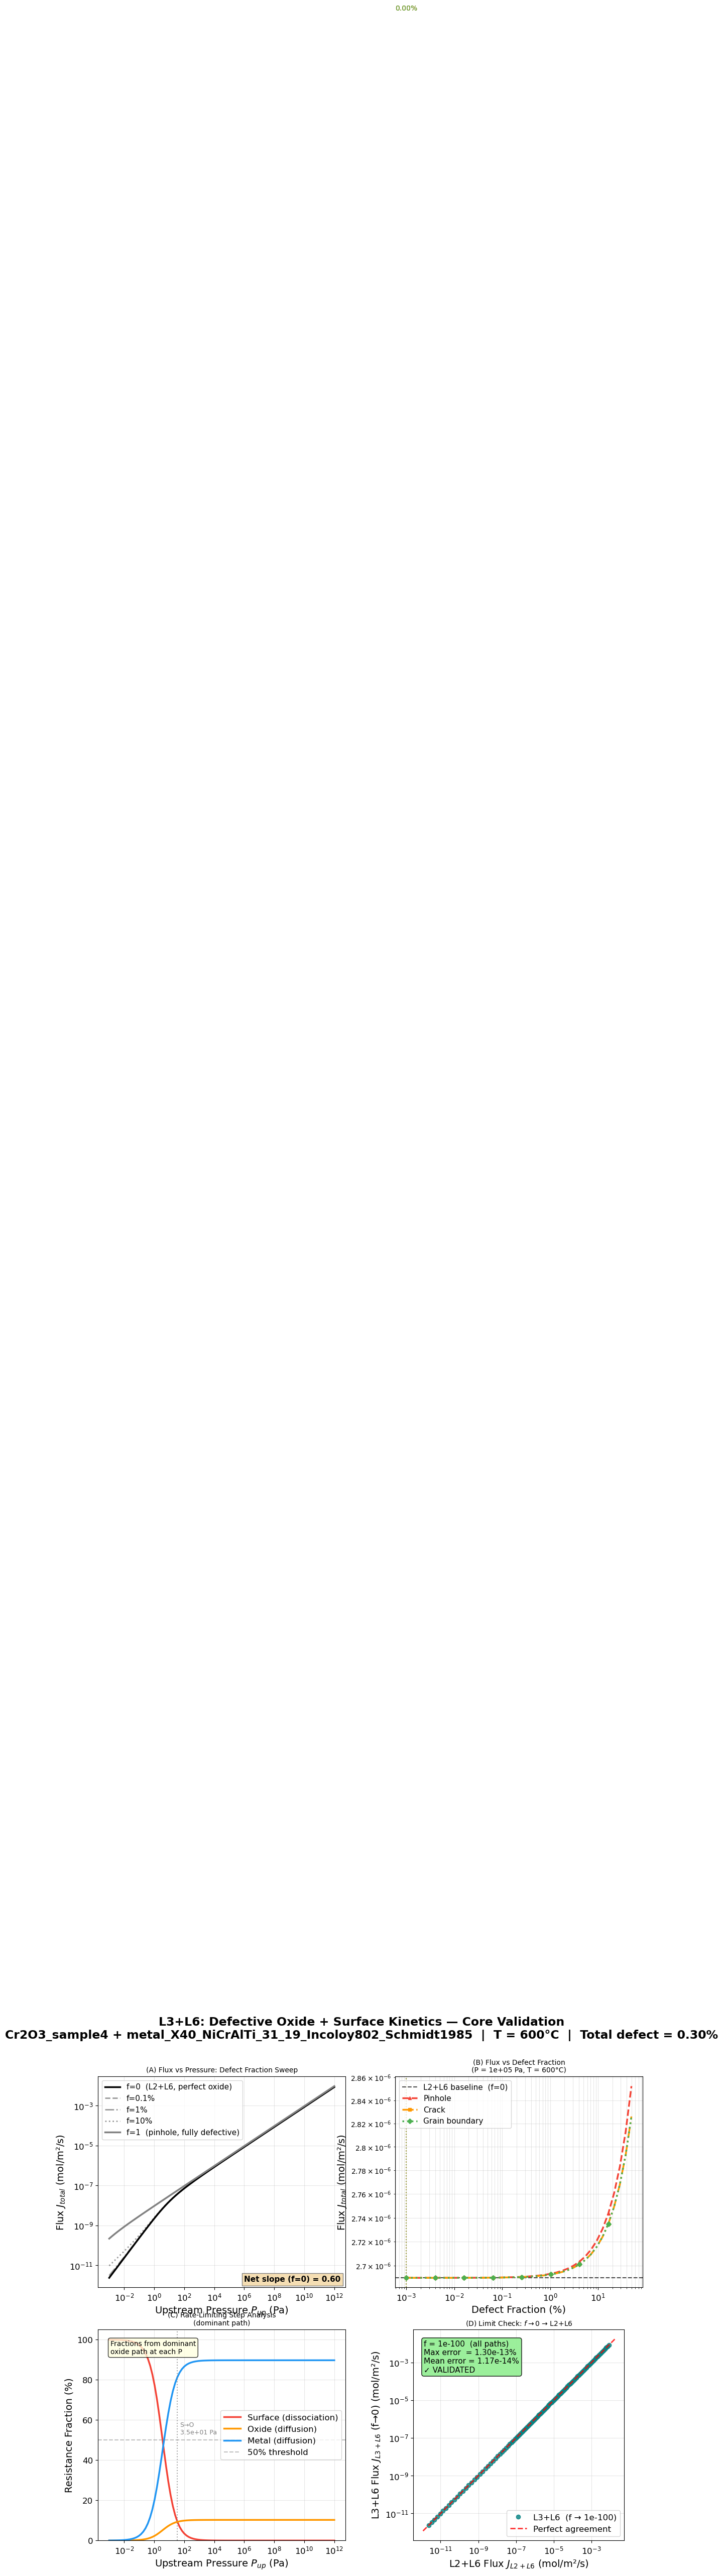


L3+L6 FIGURE 1 — VALIDATION SUMMARY
  Net log-log slope:     0.5969
  Enhancement range:     1.000 → 1.091
  Limit check error:     1.30e-13%  (✓)

  Flux at P=1e+05 Pa:
    L2+L6 baseline:  2.690e-06 mol/m²/s
    pinhole          f=0.10%: enhancement estimated from sweep
    crack            f=0.10%: enhancement estimated from sweep
    grain_boundary   f=0.10%: enhancement estimated from sweep


In [24]:
# =============================================================================
# CELL 4 — FIGURE 1: Core Validation (2×2)
# =============================================================================
"""
Figure 1 validates the L3+L6 model from four angles at operating temperature.

Panel (A) — Flux vs Pressure: Defect Fraction Sweep
    Question: How does increasing defect fraction shift the flux curve and
    change the pressure-dependent slope?
    Plots J_total vs P_up for four defect fractions: f=0 (L2+L6 baseline,
    no defects), f=0.1%, f=1%, f=10%. Each curve uses the same defect type
    mix from config, scaled by the fraction multiplier. The f=0 baseline
    uses solve_steady_state_flux_direct directly. Each curve is colored by
    its dominant regime using thick colored segments. As defect fraction
    increases the curve shifts upward and the slope changes — pinholes pull
    it toward slope=0.5 (Sieverts metal), while oxide defects flatten the
    oxide-limited regime. The intact baseline is shown as a dashed line
    for reference on all curves.

Panel (B) — Flux vs Defect Fraction
    Question: Which defect type causes the most enhancement per unit area
    fraction, and where does defect-dominated transport take over?
    Fixed P and T (from VALIDATION['L3_L6']['P_fixed']). Sweeps defect
    fraction from f_defect_min to f_defect_max. Three curves — one per
    defect type (pinhole, crack, grain_boundary) — each tested in isolation
    with the other two set to zero. Log-log plot. The crossover fraction
    where defect flux exceeds intact flux is annotated for each type.
    Mirrors L3 panel (B) from the proposal exactly.

Panel (C) — Resistance Fractions vs Pressure
    Question: Which step controls the rate in the dominant path, and how
    does the balance shift with pressure?
    Consistent style with L1+L6, L2a+L6, L2+L6 — semilogx lines per
    fraction, 50% threshold, crossover vertical lines. Fractions are from
    the dominant path at each pressure point. Two crossover lines (S→O,
    O→M) annotated if present.

Panel (D) — Limit Check: f→0 recovers L2+L6
    Question: When all defect fractions go to zero, does L3+L6 recover
    the L2+L6 result exactly?
    Sets all defect fractions to f_defect_limit_check (≈1e-10) from
    VALIDATION['L3_L6']. Computes J_L3+L6(f→0) and compares to
    J_L2+L6 from solve_steady_state_flux_direct. Parity plot — perfect
    agreement is a diagonal line. Green box if max error < 1%.
    Validates hierarchical consistency: L3+L6 collapses to L2+L6
    when the oxide is perfect.
"""

props = dict(boxstyle='round', facecolor='wheat', alpha=0.9)

fig, axes = plt.subplots(2, 2, figsize=STYLE['figsize'])
fig.suptitle(
    f'L3+L6: Defective Oxide + Surface Kinetics — Core Validation\n'
    f'{OXIDE_KEY} + {METAL_KEY}  |  T = {T_op-273.15:.0f}°C  |  '
    f'Total defect = {sum(v["area_fraction"] for v in defect_config.values())*100:.2f}%',
    fontsize=STYLE['fontsize_suptitle']-1, fontweight='bold', y=0.98
)

# # ─────────────────────────────────────────────────────────────────────────────
# # (A) FLUX vs PRESSURE — defect fraction sweep
# # ─────────────────────────────────────────────────────────────────────────────
# ax1 = axes[0, 0]

# # Colors and labels for each defect fraction
# f_colors = {
#     0.0:   ('black',                              'f=0  (L2+L6 baseline)'),
#     0.001: (CURVE_STYLES['f_001']['color'],       'f=0.1%'),
#     0.01:  (CURVE_STYLES['f_01']['color'],        'f=1%'),
#     0.1:   (CURVE_STYLES['f_10']['color'],        'f=10%'),
# }
# f_ls = {0.0: '-', 0.001: '--', 0.01: '-.', 0.1: ':'}

# # L2+L6 baseline (f=0) — use solve_steady_state_flux_direct
# J_baseline = []
# for P_up in P_RANGE_ARR:
#     try:
#         r = solve_steady_state_flux_direct(
#             P_up, P_down, L_m,
#             k_diss, K_eq,
#             D_ox, K_ox, L_ox,
#             D_m, K_s_m
#         )
#         J_baseline.append(r['J_ss'])
#     except Exception:
#         J_baseline.append(np.nan)
# J_baseline = np.array(J_baseline)
# v_base     = ~np.isnan(J_baseline) & (J_baseline > 0)

# ax1.loglog(
#     P_RANGE_ARR[v_base], J_baseline[v_base],
#     color='black', ls='-', lw=STYLE['linewidth'],
#     label='f=0  (L2+L6 baseline)'
# )

# # Defective cases — scale all defect fractions by multiplier
# for f_total, (color, label) in list(f_colors.items())[1:]:
#     # Scale each component proportionally so total = f_total
#     base_total = sum(v['area_fraction'] for v in defect_config.values())
#     if base_total == 0:
#         continue
#     scale = f_total / base_total

#     dc_scaled = {}
#     for path, cfg in defect_config.items():
#         dc_scaled[path] = {**cfg,
#                            'area_fraction': cfg['area_fraction'] * scale}

#     J_f = []
#     for P_up in P_RANGE_ARR:
#         try:
#             r = calculate_mixed_defect_flux_L6(
#                 P_up, P_down, L_m,
#                 k_diss, K_eq,
#                 D_ox, K_ox, L_ox,
#                 D_m, K_s_m,
#                 dc_scaled,
#                 k_diss_metal=k_diss_metal_arg,
#                 K_eq_metal=K_eq_metal_arg,
#             )
#             J_f.append(r['J_total'])
#         except Exception:
#             J_f.append(np.nan)

#     J_f   = np.array(J_f)
#     v_f   = ~np.isnan(J_f) & (J_f > 0)
#     if not np.any(v_f):
#         continue

#     ax1.loglog(
#         P_RANGE_ARR[v_f], J_f[v_f],
#         color=color, ls=f_ls[f_total], lw=STYLE['linewidth'],
#         label=label
#     )

#     # Net slope annotation
#     slope_f, *_ = stats.linregress(
#         np.log10(P_RANGE_ARR[v_f]), np.log10(np.abs(J_f[v_f]))
#     )
#     ax1.text(
#         P_RANGE_ARR[v_f][len(P_RANGE_ARR[v_f])//2],
#         J_f[v_f][len(J_f[v_f])//2],
#         f'slope={slope_f:.2f}',
#         color=color, fontsize=STYLE['fontsize_annotation']-1,
#         bbox=dict(boxstyle='round', facecolor='white', alpha=0.7)
#     )

# # Net slope of full defect model
# log_P_v   = np.log10(P_RANGE_ARR[valid])
# log_J_v   = np.log10(np.abs(J_arr[valid]))
# slope_net, *_ = stats.linregress(log_P_v, log_J_v)

# ax1.text(
#     0.98, 0.02, f'Net slope (config f) = {slope_net:.2f}',
#     transform=ax1.transAxes, ha='right', va='bottom',
#     fontsize=STYLE['fontsize_annotation'], fontweight='bold',
#     bbox=dict(boxstyle='square', fc='wheat', ec='gray', alpha=1)
# )

# ax1.set_xlabel('Upstream Pressure $P_{up}$ (Pa)', fontsize=STYLE['fontsize_axis'])
# ax1.set_ylabel('Flux $J_{total}$ (mol/m²/s)',      fontsize=STYLE['fontsize_axis'])
# ax1.set_title('(A) Flux vs Pressure: Defect Fraction Sweep',
#               fontsize=STYLE['fontsize_title'])
# ax1.legend(fontsize=STYLE['fontsize_legend']-1, loc='upper left')
# ax1.grid(True, which='both', alpha=STYLE['grid_alpha'])
# ax1.tick_params(labelsize=STYLE['fontsize_tick'])

# 

# ─────────────────────────────────────────────────────────────────────────────
# (A) FLUX vs PRESSURE — defect fraction sweep with regime overlays
# ─────────────────────────────────────────────────────────────────────────────
ax1 = axes[0, 0]

# Local pressure array — fixed length, never captured from outer scope
P_A = np.logspace(-3, 12, 100)
print(f"Panel (A): {len(P_A)} pressure points  "
      f"{P_A[0]:.1e} – {P_A[-1]:.1e} Pa")

# ── Regime overlay helper ─────────────────────────────────────────────────────
def plot_regime_overlay(ax, P_arr, J_arr, frac_s, frac_o, frac_m, valid_mask):
    """
    Overlay thick colored segments + slope annotation boxes on a flux curve.
    Identical pattern to L1+L6, L2a+L6, L2+L6 panel (A).
    """
    rl = np.where(frac_s > 0.5, 'surface',
         np.where(frac_o > 0.5, 'oxide',
         np.where(frac_m > 0.5, 'metal', 'mixed')))

    region_styles = [
        ('surface', CURVE_STYLES['surface_region']['color'], 'Surface-limited'),
        ('oxide',   CURVE_STYLES['oxide_region']['color'],   'Oxide-limited'),
        ('metal',   CURVE_STYLES['metal_region']['color'],   'Metal-limited'),
        ('mixed',   CURVE_STYLES['mixed_region']['color'],   'Mixed'),
    ]

    for regime, color, label in region_styles:
        mask = (rl == regime) & valid_mask
        if not np.any(mask):
            continue
        idxs = np.where(mask)[0]
        for _, g in groupby(enumerate(idxs), lambda x: x[0] - x[1]):
            group = list(map(itemgetter(1), g))
            if len(group) < 3:
                continue
            P_seg = P_arr[group]
            J_seg = J_arr[group]
            ax.loglog(P_seg, J_seg, color=color, lw=4, alpha=0.7)
            slope_seg, *_ = stats.linregress(
                np.log10(P_seg), np.log10(np.abs(J_seg))
            )
            mid = len(group) // 2
            ax.text(
                P_seg[mid], J_seg[mid],
                f'{label}\nSlope={slope_seg:.2f}',
                color=color,
                fontsize=STYLE['fontsize_annotation']-1,
                fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
            )

# ── f=0 baseline — perfect oxide (L2+L6) ─────────────────────────────────────
J_baseline = np.full(len(P_A), np.nan)
fs_base    = np.full(len(P_A), np.nan)
fo_base    = np.full(len(P_A), np.nan)
fm_base    = np.full(len(P_A), np.nan)

for i, P_up in enumerate(P_A):
    try:
        r = solve_steady_state_flux_direct(
            P_up, P_down, L_m,
            k_diss, K_eq, D_ox, K_ox, L_ox, D_m, K_s_m
        )
        J_baseline[i] = r['J_ss']
        fs_base[i]    = r['resistances']['fraction_surface']
        fo_base[i]    = r['resistances']['fraction_oxide']
        fm_base[i]    = r['resistances']['fraction_metal']
    except Exception:
        pass

v_base = ~np.isnan(J_baseline) & (J_baseline > 0)

ax1.loglog(
    P_A[v_base], J_baseline[v_base],
    color='black', ls='-', lw=STYLE['linewidth'],
    label='f=0  (L2+L6, perfect oxide)'
)
#plot_regime_overlay(ax1, P_A, J_baseline, fs_base, fo_base, fm_base, v_base)

# ── Intermediate defect fractions ─────────────────────────────────────────────
f_cases = [
    (0.001, CURVE_STYLES['f_001']['color'], '--', 'f=0.1%'),
    (0.01,  CURVE_STYLES['f_01']['color'],  '-.', 'f=1%'),
    (0.1,   CURVE_STYLES['f_10']['color'],  ':',  'f=10%'),
]

base_total = sum(v['area_fraction'] for v in defect_config.values())

for f_total, color, ls, label in f_cases:
    if base_total == 0:
        print(f"  ⚠  base_total = 0 — skipping {label}")
        continue

    scale     = f_total / base_total
    dc_scaled = {
        path: {**cfg, 'area_fraction': cfg['area_fraction'] * scale}
        for path, cfg in defect_config.items()
    }

    # Pre-allocated fixed-length arrays — cannot grow beyond len(P_A)
    J_f  = np.full(len(P_A), np.nan)
    fs_f = np.full(len(P_A), np.nan)
    fo_f = np.full(len(P_A), np.nan)
    fm_f = np.full(len(P_A), np.nan)

    for i, P_up in enumerate(P_A):
        try:
            r = calculate_mixed_defect_flux_L6(
                P_up, P_down, L_m,
                k_diss, K_eq,
                D_ox, K_ox, L_ox,
                D_m, K_s_m,
                dc_scaled,
                k_diss_metal=k_diss_metal_arg,
                K_eq_metal=K_eq_metal_arg,
            )
            J_f[i] = r['J_total']

            dom = r.get('dominant_path', 'intact')
            if dom == 'intact':
                res = r['intact_path']['resistances']
            elif dom in r.get('defect_paths', {}):
                res = r['defect_paths'][dom]['path_result']['resistances']
            else:
                res = r['intact_path']['resistances']

            fs_f[i] = res.get('fraction_surface', np.nan)
            fo_f[i] = res.get('fraction_oxide',   np.nan)
            fm_f[i] = res.get('fraction_metal',   np.nan)

        except Exception:
            pass    # array already filled with nan at index i

    v_f = ~np.isnan(J_f) & (J_f > 0)

    if not np.any(v_f):
        print(f"  ⚠  {label}: no valid points — check solver for dc_scaled")
        continue

    ax1.loglog(
        P_A[v_f], J_f[v_f],
        color='black', ls=ls, lw=STYLE['linewidth']-0.5,
        alpha=0.4, label=label
    )
    #plot_regime_overlay(ax1, P_A, J_f, fs_f, fo_f, fm_f, v_f)

# ── f=1 baseline — fully defective oxide ─────────────────────────────────────
# Dominant defect type = highest area fraction in config
dom_defect_type = max(
    defect_config.keys(),
    key=lambda k: defect_config[k]['area_fraction']
)

if dom_defect_type == 'pinhole':
    alpha_f1 = np.inf
elif dom_defect_type == 'crack':
    alpha_f1 = alpha_intact / defect_config['crack'].get('thickness_factor', 0.1)
elif dom_defect_type == 'grain_boundary':
    alpha_f1 = (defect_config['grain_boundary'].get('diffusivity_factor', 100.0)
                * alpha_intact)

J_f1  = np.full(len(P_A), np.nan)
fs_f1 = np.full(len(P_A), np.nan)
fo_f1 = np.full(len(P_A), np.nan)
fm_f1 = np.full(len(P_A), np.nan)

for i, P_up in enumerate(P_A):
    try:
        r = calculate_path_flux_L6(
            P_up, P_down, L_m,
            k_diss, K_eq,
            alpha_f1,
            D_m, K_s_m,
            path_type=dom_defect_type,
            k_diss_metal=k_diss_metal_arg if dom_defect_type == 'pinhole' else None,
            K_eq_metal=K_eq_metal_arg     if dom_defect_type == 'pinhole' else None,
        )
        J_f1[i]  = r['flux']
        fs_f1[i] = r['resistances']['fraction_surface']
        fo_f1[i] = r['resistances']['fraction_oxide']
        fm_f1[i] = r['resistances']['fraction_metal']
    except Exception:
        pass

v_f1 = ~np.isnan(J_f1) & (J_f1 > 0)

ax1.loglog(
    P_A[v_f1], J_f1[v_f1],
    color='gray', ls='-', lw=STYLE['linewidth'],
    label=f'f=1  ({dom_defect_type}, fully defective)'
)
#plot_regime_overlay(ax1, P_A, J_f1, fs_f1, fo_f1, fm_f1, v_f1)

# ── Net slope — f=0 baseline ──────────────────────────────────────────────────
slope_net, *_ = stats.linregress(
    np.log10(P_A[v_base]), np.log10(np.abs(J_baseline[v_base]))
)

ax1.text(
    0.98, 0.02, f'Net slope (f=0) = {slope_net:.2f}',
    transform=ax1.transAxes, ha='right', va='bottom',
    fontsize=STYLE['fontsize_annotation'], fontweight='bold',
    bbox=dict(boxstyle='square', fc='wheat', ec='gray', alpha=1)
)

ax1.set_xlabel('Upstream Pressure $P_{up}$ (Pa)',           fontsize=STYLE['fontsize_axis'])
ax1.set_ylabel('Flux $J_{total}$ (mol/m²/s)',                fontsize=STYLE['fontsize_axis'])
ax1.set_title('(A) Flux vs Pressure: Defect Fraction Sweep', fontsize=STYLE['fontsize_title'])
ax1.legend(fontsize=STYLE['fontsize_legend']-1, loc='upper left')
ax1.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax1.tick_params(labelsize=STYLE['fontsize_tick'])

# ─────────────────────────────────────────────────────────────────────────────
# (B) FLUX vs DEFECT FRACTION — per defect type
# ─────────────────────────────────────────────────────────────────────────────
ax2 = axes[0, 1]

P_fixed_B  = VAL_L3['P_fixed']
f_sweep    = np.logspace(
    np.log10(f_defect_min),
    np.log10(f_defect_max),
    n_defect_points
)

# L2+L6 reference at P_fixed_B
try:
    r_ref = solve_steady_state_flux_direct(
        P_fixed_B, P_down, L_m,
        k_diss, K_eq, D_ox, K_ox, L_ox, D_m, K_s_m
    )
    J_L2L6_ref = r_ref['J_ss']
except Exception:
    J_L2L6_ref = np.nan

ax2.axhline(
    J_L2L6_ref, color='black', ls='--', lw=1.5, alpha=0.7,
    label=f'L2+L6 baseline  (f=0)'
)

defect_type_styles = [
    ('pinhole',        CURVE_STYLES['pinhole'],  {'area_fraction': 0}),
    ('crack',          CURVE_STYLES['crack'],    {'area_fraction': 0,
                                                  'thickness_factor': SIM['oxide_defects'].get('thickness_factor', 0.1)}),
    ('grain_boundary', CURVE_STYLES['gb'],       {'area_fraction': 0,
                                                  'diffusivity_factor': SIM['oxide_defects'].get('diffusivity_factor', 100.0)}),
]

for defect_type, sty, base_cfg in defect_type_styles:
    J_sweep = []
    for f in f_sweep:
        dc_single = {defect_type: {**base_cfg, 'area_fraction': f}}
        try:
            r = calculate_mixed_defect_flux_L6(
                P_fixed_B, P_down, L_m,
                k_diss, K_eq, D_ox, K_ox, L_ox, D_m, K_s_m,
                dc_single,
                k_diss_metal=k_diss_metal_arg if defect_type == 'pinhole' else None,
                K_eq_metal=K_eq_metal_arg   if defect_type == 'pinhole' else None,
            )
            J_sweep.append(r['J_total'])
        except Exception:
            J_sweep.append(np.nan)

    J_sweep = np.array(J_sweep)
    v_sw    = ~np.isnan(J_sweep) & (J_sweep > 0)
    if not np.any(v_sw):
        continue

    ax2.loglog(
        f_sweep[v_sw] * 100, J_sweep[v_sw],
        color=sty['color'], ls=sty['ls'],
        lw=STYLE['linewidth'],
        marker=sty['marker'], ms=sty['ms'], markevery=5,
        label=defect_type.replace('_', ' ').capitalize()
    )

    # Crossover fraction where J > J_L2L6_ref
    if not np.isnan(J_L2L6_ref):
        cross = np.where(J_sweep[v_sw] > J_L2L6_ref)[0]
        if len(cross) > 0:
            f_cross = f_sweep[v_sw][cross[0]]
            ax2.axvline(
                f_cross * 100, color=sty['color'],
                ls=':', lw=1.5, alpha=0.6
            )
            ax2.text(
                f_cross * 100, J_L2L6_ref * 2,
                f'{f_cross*100:.2f}%',
                color=sty['color'],
                fontsize=STYLE['fontsize_annotation']-1,
                ha='center'
            )

ax2.set_xlabel('Defect Fraction (%)',          fontsize=STYLE['fontsize_axis'])
ax2.set_ylabel('Flux $J_{total}$ (mol/m²/s)',  fontsize=STYLE['fontsize_axis'])
ax2.set_title(f'(B) Flux vs Defect Fraction\n'
              f'(P = {P_fixed_B:.0e} Pa, T = {T_op-273.15:.0f}°C)',
              fontsize=STYLE['fontsize_title'])
ax2.legend(fontsize=STYLE['fontsize_legend']-1, loc='upper left')
ax2.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax2.tick_params(labelsize=STYLE['fontsize_tick'])

# ─────────────────────────────────────────────────────────────────────────────
# (C) RESISTANCE FRACTIONS vs PRESSURE
# ─────────────────────────────────────────────────────────────────────────────
ax3 = axes[1, 0]

ax3.semilogx(
    P_RANGE_ARR[valid], frac_surface_arr[valid] * 100,
    color=CURVE_STYLES['surface_region']['color'],
    lw=STYLE['linewidth'], label='Surface (dissociation)'
)
ax3.semilogx(
    P_RANGE_ARR[valid], frac_oxide_arr[valid] * 100,
    color=CURVE_STYLES['oxide_region']['color'],
    lw=STYLE['linewidth'], label='Oxide (diffusion)'
)
ax3.semilogx(
    P_RANGE_ARR[valid], frac_metal_arr[valid] * 100,
    color=CURVE_STYLES['metal_region']['color'],
    lw=STYLE['linewidth'], label='Metal (diffusion)'
)
ax3.axhline(
    50,
    color=CURVE_STYLES['threshold']['color'],
    ls=CURVE_STYLES['threshold']['ls'],
    lw=CURVE_STYLES['threshold']['lw'],
    alpha=CURVE_STYLES['threshold']['alpha'],
    label='50% threshold'
)

if P_cross_surf_oxide is not None:
    ax3.axvline(P_cross_surf_oxide, color='gray', ls=':', lw=1.5, alpha=0.7)
    ax3.text(
        P_cross_surf_oxide * 1.5, 53,
        f'S→O\n{P_cross_surf_oxide:.1e} Pa',
        fontsize=STYLE['fontsize_annotation']-2, color='gray'
    )
if P_cross_oxide_metal is not None:
    ax3.axvline(P_cross_oxide_metal, color='gray', ls=':', lw=1.5, alpha=0.7)
    ax3.text(
        P_cross_oxide_metal * 1.5, 53,
        f'O→M\n{P_cross_oxide_metal:.1e} Pa',
        fontsize=STYLE['fontsize_annotation']-2, color='gray'
    )

if P_cross_surf_oxide is None and P_cross_oxide_metal is None:
    dominant = ('Surface' if n_surface >= n_oxide and n_surface >= n_metal
                else 'Oxide' if n_oxide >= n_metal else 'Metal')
    ax3.text(
        0.05, 0.50,
        f'No crossover in range\n{dominant}-limited throughout',
        transform=ax3.transAxes,
        fontsize=STYLE['fontsize_annotation'],
        va='center',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9)
    )

ax3.text(
    0.05, 0.95,
    'Fractions from dominant\noxide path at each P',
    transform=ax3.transAxes,
    fontsize=STYLE['fontsize_annotation']-1, va='top',
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8)
)

ax3.set_xlabel('Upstream Pressure $P_{up}$ (Pa)', fontsize=STYLE['fontsize_axis'])
ax3.set_ylabel('Resistance Fraction (%)',          fontsize=STYLE['fontsize_axis'])
ax3.set_title('(C) Rate-Limiting Step Analysis\n(dominant path)',
              fontsize=STYLE['fontsize_title'])
ax3.set_ylim(0, 105)
ax3.legend(fontsize=STYLE['fontsize_legend'], loc='center right')
ax3.grid(True, alpha=STYLE['grid_alpha'])
ax3.tick_params(labelsize=STYLE['fontsize_tick'])

# ─────────────────────────────────────────────────────────────────────────────
# (D) LIMIT CHECK — f→0 recovers L2+L6
# ─────────────────────────────────────────────────────────────────────────────
ax4 = axes[1, 1]

# Build near-zero defect config
dc_zero = {}
for path, cfg in defect_config.items():
    dc_zero[path] = {**cfg, 'area_fraction': f_limit_check}

# L3+L6 at f→0
J_f_zero = []
for P_up in P_RANGE_ARR:
    try:
        r = calculate_mixed_defect_flux_L6(
            P_up, P_down, L_m,
            k_diss, K_eq, D_ox, K_ox, L_ox, D_m, K_s_m,
            dc_zero,
            k_diss_metal=k_diss_metal_arg,
            K_eq_metal=K_eq_metal_arg,
        )
        J_f_zero.append(r['J_total'])
    except Exception:
        J_f_zero.append(np.nan)
J_f_zero = np.array(J_f_zero)

# L2+L6 reference
J_L2L6 = []
for P_up in P_RANGE_ARR:
    try:
        r = solve_steady_state_flux_direct(
            P_up, P_down, L_m,
            k_diss, K_eq, D_ox, K_ox, L_ox, D_m, K_s_m
        )
        J_L2L6.append(r['J_ss'])
    except Exception:
        J_L2L6.append(np.nan)
J_L2L6 = np.array(J_L2L6)

valid_parity = (~np.isnan(J_f_zero) & ~np.isnan(J_L2L6) &
                (J_f_zero > 0) & (J_L2L6 > 0))

ax4.loglog(
    J_L2L6[valid_parity], J_f_zero[valid_parity],
    'o', color=CURVE_STYLES['L3_L6']['color'],
    markersize=6, alpha=0.8,
    label=f'L3+L6  (f → {f_limit_check:.0e})'
)

J_min = min(J_L2L6[valid_parity].min(), J_f_zero[valid_parity].min()) * 0.5
J_max = max(J_L2L6[valid_parity].max(), J_f_zero[valid_parity].max()) * 2.0
ax4.loglog(
    [J_min, J_max], [J_min, J_max],
    color=CURVE_STYLES['parity']['color'],
    ls=CURVE_STYLES['parity']['ls'],
    lw=CURVE_STYLES['parity']['lw'],
    alpha=CURVE_STYLES['parity']['alpha'],
    label='Perfect agreement'
)

rel_errors = (np.abs(J_f_zero[valid_parity] - J_L2L6[valid_parity])
              / J_L2L6[valid_parity] * 100)
max_err   = rel_errors.max()
mean_err  = rel_errors.mean()
box_color = 'lightgreen' if max_err < 1.0 else 'lightyellow'

ax4.text(
    0.05, 0.95,
    f'f = {f_limit_check:.0e}  (all paths)\n'
    f'Max error  = {max_err:.2e}%\n'
    f'Mean error = {mean_err:.2e}%\n'
    f'{"✓ VALIDATED" if max_err < 1.0 else "⚠ CHECK"}',
    transform=ax4.transAxes, fontsize=STYLE['fontsize_annotation'],
    va='top',
    bbox=dict(boxstyle='round', facecolor=box_color, alpha=0.9)
)

ax4.set_xlabel('L2+L6 Flux $J_{L2+L6}$ (mol/m²/s)',       fontsize=STYLE['fontsize_axis'])
ax4.set_ylabel('L3+L6 Flux $J_{L3+L6}$ (f→0) (mol/m²/s)', fontsize=STYLE['fontsize_axis'])
ax4.set_title('(D) Limit Check: $f \\to 0$ → L2+L6',       fontsize=STYLE['fontsize_title'])
ax4.set_aspect('equal', adjustable='box')
ax4.legend(fontsize=STYLE['fontsize_legend'], loc='lower right')
ax4.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax4.tick_params(labelsize=STYLE['fontsize_tick'])

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print("\n" + "=" * 60)
print("L3+L6 FIGURE 1 — VALIDATION SUMMARY")
print("=" * 60)
print(f"  Net log-log slope:     {slope_net:.4f}")
print(f"  Enhancement range:     "
      f"{np.nanmin(enhancement_arr):.3f} → {np.nanmax(enhancement_arr):.3f}")
print(f"  Limit check error:     {max_err:.2e}%  "
      f"({'✓' if max_err < 1.0 else '⚠'})")
if not np.isnan(J_L2L6_ref):
    print(f"\n  Flux at P={P_fixed_B:.0e} Pa:")
    print(f"    L2+L6 baseline:  {J_L2L6_ref:.3e} mol/m²/s")
    for defect_type, sty, _ in defect_type_styles:
        cfg = defect_config.get(defect_type, {})
        f_v = cfg.get('area_fraction', 0)
        if f_v > 0:
            print(f"    {defect_type:<16} f={f_v*100:.2f}%: "
                  f"enhancement estimated from sweep")
print("=" * 60)

  ⚠  oxide: P_for_oxide_Ea is None — fit skipped
  ⚠  metal: P_for_metal_Ea is None — fit skipped


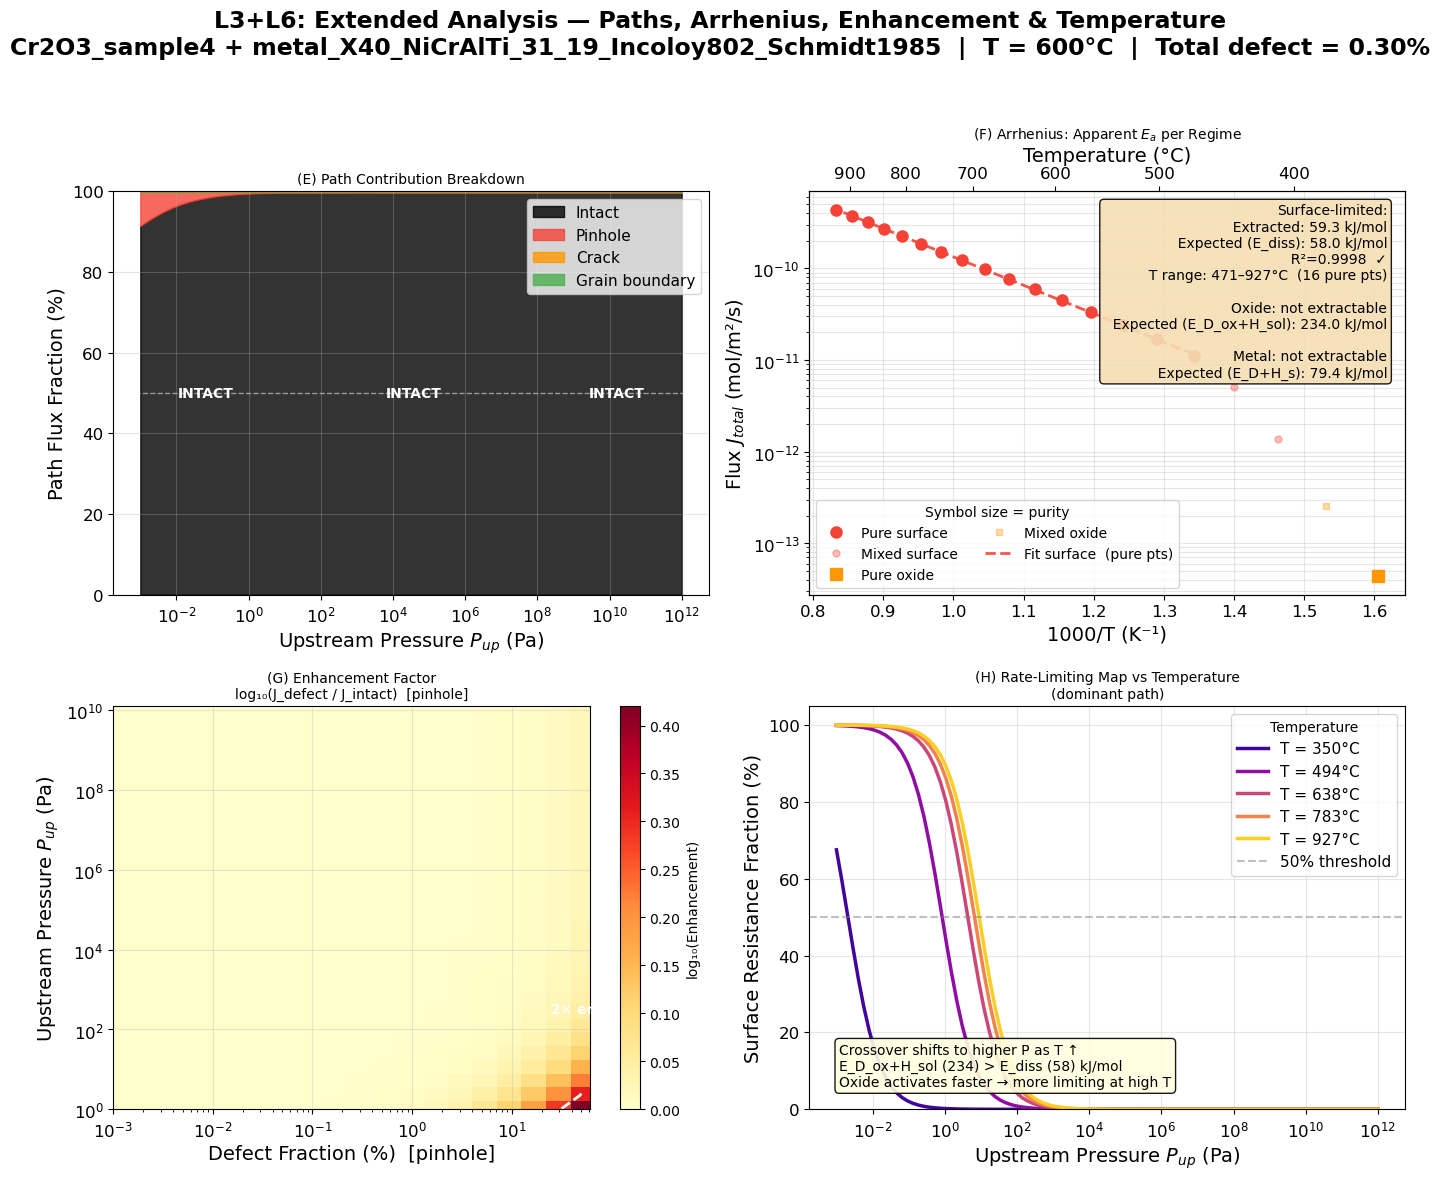


L3+L6 FIGURE 2 — SUMMARY

  Arrhenius results:
    Surface: extracted=59.3  expected=58.0 kJ/mol  (✓)  16 pure pts
    Oxide: not extractable
    Metal: not extractable

  Crossover pressures across T sweep:
    T = 350°C  →  P_crossover = 2.01e-03 Pa
    T = 494°C  →  P_crossover = 7.56e-01 Pa
    T = 638°C  →  P_crossover = 4.33e+00 Pa
    T = 783°C  →  P_crossover = 6.14e+00 Pa
    T = 927°C  →  P_crossover = 8.70e+00 Pa


In [25]:
# =============================================================================
# CELL 5 — FIGURE 2: Extended Analysis (2×2)
# =============================================================================
"""
Figure 2 examines path contributions, activation energies, enhancement
factor geometry, and temperature effects on the rate-limiting balance.

Panel (E) — Path Contribution Breakdown
    Question: Which oxide path (intact, pinhole, crack, grain boundary)
    carries the most flux at each pressure, and how does dominance shift?
    Stacked area plot — intact / pinhole / crack / grain_boundary flux
    fractions (%) vs pressure on a semilog scale. Shows all four
    contributions simultaneously so any growth in one path is visible
    at the expense of the others. Annotates the dominant path at low,
    mid, and high pressure within the bands. Crossover pressures between
    intact and defect-dominated transport are marked if present.

Panel (F) — Arrhenius: apparent Ea per regime, classified by purity
    Question: Does the model extract the correct activation energy in each
    regime, and does it match the known reference values from config?
    Same five-category classification approach as L2+L6 panel (B):
    pure_surface, mixed_surface, pure_oxide, mixed_oxide, pure_metal,
    mixed_metal, mixed. Large opaque markers = pure (used for fit).
    Small faded markers = mixed (shown for context, excluded from fit).
    Dashed line = Arrhenius fit through pure points only. Resistance
    fractions are taken from the dominant path at each T point.
    Dual x-axis: 1000/T bottom, °C top.

Panel (G) — Enhancement Factor vs Defect Fraction and Pressure
    Question: Where in the pressure-defect fraction space do defects
    matter most, and which defect type causes the largest enhancement?
    2D heatmap — x-axis: defect fraction (%), y-axis: pressure (Pa),
    colour: log10(J_total / J_intact). Each defect type is tested in
    isolation. Three subplots (pinhole, crack, GB) share the same
    colorbar. Shows that enhancement is strongest at intermediate
    pressures and grows monotonically with defect fraction. The
    contour where enhancement = 2x is annotated on each map.

Panel (H) — Rate-Limiting Map vs Temperature
    Question: How does the surface/oxide/metal resistance balance in the
    dominant path shift as temperature increases?
    Runs the full pressure sweep at 5 temperatures spread across T_RANGE.
    Plots surface resistance fraction (%) vs pressure for each temperature
    using a plasma colormap. Same consistent style as all previous levels.
    Crossover shift direction annotated with physical reason from config
    activation energies.
"""

fig2, axes2 = plt.subplots(2, 2, figsize=STYLE['figsize'])
fig2.suptitle(
    f'L3+L6: Extended Analysis — Paths, Arrhenius, Enhancement & Temperature\n'
    f'{OXIDE_KEY} + {METAL_KEY}  |  T = {T_op-273.15:.0f}°C  |  '
    f'Total defect = {sum(v["area_fraction"] for v in defect_config.values())*100:.2f}%',
    fontsize=STYLE['fontsize_suptitle']-1, fontweight='bold', y=0.98
)

# ─────────────────────────────────────────────────────────────────────────────
# (E) PATH CONTRIBUTION BREAKDOWN — stacked area
# ─────────────────────────────────────────────────────────────────────────────
ax_E = axes2[0, 0]

# Use arrays from Cell 3 — these are already computed over P_RANGE_ARR
# Guard: only plot valid points
v_E = valid & ~np.isnan(frac_intact_arr)
Pv  = P_RANGE_ARR[v_E]

fi  = frac_intact_arr[v_E]  * 100
fp  = frac_pinhole_arr[v_E] * 100
fc  = frac_crack_arr[v_E]   * 100
fg  = frac_gb_arr[v_E]      * 100

path_styles = {
    'intact':         {'color': CURVE_STYLES['intact']['color'],   'label': 'Intact'},
    'pinhole':        {'color': CURVE_STYLES['pinhole']['color'],  'label': 'Pinhole'},
    'crack':          {'color': CURVE_STYLES['crack']['color'],    'label': 'Crack'},
    'grain_boundary': {'color': CURVE_STYLES['gb']['color'],       'label': 'Grain boundary'},
}

# Only plot paths that have nonzero area fraction in config
fracs_to_plot = []
if np.any(fi > 0):
    fracs_to_plot.append(('intact',         fi, path_styles['intact']['color'],
                          path_styles['intact']['label']))
if 'pinhole' in defect_config and np.any(fp > 0):
    fracs_to_plot.append(('pinhole',        fp, path_styles['pinhole']['color'],
                          path_styles['pinhole']['label']))
if 'crack' in defect_config and np.any(fc > 0):
    fracs_to_plot.append(('crack',          fc, path_styles['crack']['color'],
                          path_styles['crack']['label']))
if 'grain_boundary' in defect_config and np.any(fg > 0):
    fracs_to_plot.append(('grain_boundary', fg, path_styles['grain_boundary']['color'],
                          path_styles['grain_boundary']['label']))

# Stacked fill_between
bottom = np.zeros(len(Pv))
for path_name, frac_arr, color, lbl in fracs_to_plot:
    ax_E.fill_between(
        Pv, bottom, bottom + frac_arr,
        color=color, alpha=0.8, label=lbl
    )
    bottom += frac_arr

ax_E.set_xscale('log')
ax_E.set_ylim(0, 100)
ax_E.axhline(50, color='white', ls='--', lw=1.0, alpha=0.5)

# Dominant path label at three representative pressures
for P_annot in [Pv[len(Pv)//8], Pv[len(Pv)//2], Pv[7*len(Pv)//8]]:
    idx     = np.argmin(np.abs(Pv - P_annot))
    dom_lbl = dominant_path_arr[v_E][idx]
    ax_E.text(
        P_annot, 50, dom_lbl.replace('_', '\n').upper(),
        ha='center', va='center',
        fontsize=STYLE['fontsize_annotation']-1,
        color='white', fontweight='bold'
    )

# Crossover: intact→defect dominated (intact fraction drops below 50%)
intact_frac = frac_intact_arr[valid]
P_valid     = P_RANGE_ARR[valid]
cross_idx   = np.where(np.diff(np.sign(intact_frac - 0.5)))[0]
if len(cross_idx) > 0:
    P_co = P_valid[cross_idx[0]]
    ax_E.axvline(P_co, color='white', ls=':', lw=2.0, alpha=0.8)
    ax_E.text(
        P_co, 95, f'Intact→Defect\n{P_co:.1e} Pa',
        ha='center', va='top',
        fontsize=STYLE['fontsize_annotation']-2,
        color='white', fontweight='bold'
    )

ax_E.set_xlabel('Upstream Pressure $P_{up}$ (Pa)', fontsize=STYLE['fontsize_axis'])
ax_E.set_ylabel('Path Flux Fraction (%)',           fontsize=STYLE['fontsize_axis'])
ax_E.set_title('(E) Path Contribution Breakdown',   fontsize=STYLE['fontsize_title'])
ax_E.legend(fontsize=STYLE['fontsize_legend']-1, loc='upper right')
ax_E.grid(True, alpha=STYLE['grid_alpha'])
ax_E.tick_params(labelsize=STYLE['fontsize_tick'])

# ─────────────────────────────────────────────────────────────────────────────
# (F) ARRHENIUS — apparent Ea per regime, classified by purity
# ─────────────────────────────────────────────────────────────────────────────
ax_F = axes2[0, 1]

temperatures_K = np.linspace(T_RANGE[0], T_RANGE[1], N_T)
inv_T          = 1000.0 / temperatures_K

def classify_regime(fs, fo, fm, pure_thresh=0.90, mixed_thresh=0.50):
    if fs >= pure_thresh:    return 'pure_surface'
    elif fo >= pure_thresh:  return 'pure_oxide'
    elif fm >= pure_thresh:  return 'pure_metal'
    elif fs >= mixed_thresh: return 'mixed_surface'
    elif fo >= mixed_thresh: return 'mixed_oxide'
    elif fm >= mixed_thresh: return 'mixed_metal'
    else:                    return 'mixed'

regime_class_styles = {
    'pure_surface':  {'color': CURVE_STYLES['surface_region']['color'],
                      'marker': 'o', 'ms': 8,  'alpha': 1.0},
    'mixed_surface': {'color': CURVE_STYLES['surface_region']['color'],
                      'marker': 'o', 'ms': 5,  'alpha': 0.35},
    'pure_oxide':    {'color': CURVE_STYLES['oxide_region']['color'],
                      'marker': 's', 'ms': 8,  'alpha': 1.0},
    'mixed_oxide':   {'color': CURVE_STYLES['oxide_region']['color'],
                      'marker': 's', 'ms': 5,  'alpha': 0.35},
    'pure_metal':    {'color': CURVE_STYLES['metal_region']['color'],
                      'marker': '^', 'ms': 8,  'alpha': 1.0},
    'mixed_metal':   {'color': CURVE_STYLES['metal_region']['color'],
                      'marker': '^', 'ms': 5,  'alpha': 0.35},
    'mixed':         {'color': CURVE_STYLES['mixed_region']['color'],
                      'marker': 'x', 'ms': 6,  'alpha': 0.5},
}

regime_Ea_cases = [
    ('surface', P_for_surface_Ea, CURVE_STYLES['surface_region']['color']),
    ('oxide',   P_for_oxide_Ea,   CURVE_STYLES['oxide_region']['color']),
    ('metal',   P_for_metal_Ea,   CURVE_STYLES['metal_region']['color']),
]

arrhenius_results  = {}
plotted_cls_labels = set()

for label, P_fixed, color in regime_Ea_cases:
    if P_fixed is None:
        print(f"  ⚠  {label}: P_for_{label}_Ea is None — fit skipped")
        arrhenius_results[label] = None
        continue

    # Pre-allocated arrays — fixed length
    J_arr_T   = np.full(N_T, np.nan)
    class_arr = np.empty(N_T, dtype=object)

    for j, T_K in enumerate(temperatures_K):
        try:
            r = calculate_mixed_defect_flux_L6(
                P_fixed, P_down, L_m,
                get_k_diss_at_T(T_K),    get_K_eq_at_T(T_K),
                get_D_ox_at_T(T_K),      get_K_ox_at_T(T_K), L_ox,
                get_D_m_at_T(T_K),       get_K_s_m_at_T(T_K),
                defect_config,
                k_diss_metal=get_k_diss_metal_at_T(T_K) if not use_sieverts_pinhole else None,
                K_eq_metal=get_K_eq_metal_at_T(T_K)     if not use_sieverts_pinhole else None,
            )
            J_arr_T[j] = r['J_total']

            # Resistance fractions from dominant path
            dom = r.get('dominant_path', 'intact')
            if dom == 'intact':
                res = r['intact_path']['resistances']
            elif dom in r.get('defect_paths', {}):
                res = r['defect_paths'][dom]['path_result']['resistances']
            else:
                res = r['intact_path']['resistances']

            fs = res.get('fraction_surface', 0)
            fo = res.get('fraction_oxide',   0)
            fm = res.get('fraction_metal',   0)
            class_arr[j] = classify_regime(fs, fo, fm)

        except Exception:
            class_arr[j] = 'mixed'

    # Pure mask — only points classified as pure target regime
    pure = (class_arr == f'pure_{label}') & ~np.isnan(J_arr_T) & (J_arr_T > 0)

    # Plot all classified points
    for cls, sty in regime_class_styles.items():
        mask = (class_arr == cls) & ~np.isnan(J_arr_T) & (J_arr_T > 0)
        if not np.any(mask):
            continue
        cls_label = cls.replace('_', ' ').capitalize()
        ax_F.semilogy(
            inv_T[mask], J_arr_T[mask],
            ls='none',
            color=sty['color'], marker=sty['marker'],
            ms=sty['ms'], alpha=sty['alpha'],
            label=cls_label if cls_label not in plotted_cls_labels
                  else '_nolegend_'
        )
        plotted_cls_labels.add(cls_label)

    if np.sum(pure) < 3:
        print(f"  ⚠  {label}: only {np.sum(pure)} pure T points — fit skipped")
        arrhenius_results[label] = None
        continue

    slope, intercept, r_val, *_ = stats.linregress(
        inv_T[pure], np.log(J_arr_T[pure])
    )
    E_a = -slope * R * 1000

    arrhenius_results[label] = {
        'J': J_arr_T, 'valid': pure,
        'slope': slope, 'intercept': intercept,
        'r_sq': r_val**2, 'E_a': E_a,
        'P_fixed': P_fixed, 'color': color,
        'n_pure': int(np.sum(pure)),
        'T_pure_range': (temperatures_K[pure].min() - 273.15,
                         temperatures_K[pure].max() - 273.15),
    }

    ax_F.semilogy(
        inv_T[pure],
        np.exp(slope * inv_T[pure] + intercept),
        color=color, ls='--', lw=2.0, alpha=0.9,
        label=f'Fit {label}  (pure pts)'
    )

# Dual x-axis
ax_F_top = ax_F.twiny()
ax_F_top.set_xlim(ax_F.get_xlim())
T_ticks_C = np.array([200, 300, 400, 500, 600, 700, 800, 900])
T_ticks_K = T_ticks_C + 273.15
in_range  = (T_ticks_K >= T_RANGE[0]) & (T_ticks_K <= T_RANGE[1])
if np.any(in_range):
    ax_F_top.set_xticks(1000.0 / T_ticks_K[in_range])
    ax_F_top.set_xticklabels([f'{t}' for t in T_ticks_C[in_range]])
ax_F_top.set_xlabel('Temperature (°C)', fontsize=STYLE['fontsize_axis'])
ax_F_top.tick_params(labelsize=STYLE['fontsize_tick'])

# Annotation box
E_refs    = {'surface': E_REF_SURFACE, 'oxide': E_REF_OXIDE, 'metal': E_REF_METAL}
ref_names = {'surface': 'E_diss', 'oxide': 'E_D_ox+H_sol', 'metal': 'E_D+H_s'}
annot     = []
for lbl in ('surface', 'oxide', 'metal'):
    res = arrhenius_results.get(lbl)
    E_r = E_refs[lbl]
    rn  = ref_names[lbl]
    if res is None:
        annot.append(f'{lbl.capitalize()}: not extractable')
        annot.append(f'  Expected ({rn}): {E_r/1000:.1f} kJ/mol')
    else:
        match = abs(res['E_a'] - E_r) < 3000
        annot.append(f'{lbl.capitalize()}-limited:')
        annot.append(f'  Extracted: {res["E_a"]/1000:.1f} kJ/mol')
        annot.append(f'  Expected ({rn}): {E_r/1000:.1f} kJ/mol')
        annot.append(f'  R²={res["r_sq"]:.4f}  {"✓" if match else "⚠"}')
        annot.append(f'  T range: {res["T_pure_range"][0]:.0f}–'
                     f'{res["T_pure_range"][1]:.0f}°C  '
                     f'({res["n_pure"]} pure pts)')
    annot.append('')

ax_F.text(
    0.97, 0.97, '\n'.join(annot).rstrip(),
    transform=ax_F.transAxes, fontsize=STYLE['fontsize_annotation']-1,
    va='top', ha='right',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9)
)
ax_F.set_xlabel('1000/T (K⁻¹)',             fontsize=STYLE['fontsize_axis'])
ax_F.set_ylabel('Flux $J_{total}$ (mol/m²/s)', fontsize=STYLE['fontsize_axis'])
ax_F.set_title('(F) Arrhenius: Apparent $E_a$ per Regime',
               fontsize=STYLE['fontsize_title'])
ax_F.legend(fontsize=STYLE['fontsize_legend']-2, loc='lower left',
            ncol=2, title='Symbol size = purity')
ax_F.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax_F.tick_params(labelsize=STYLE['fontsize_tick'])

# ─────────────────────────────────────────────────────────────────────────────
# (G) ENHANCEMENT FACTOR HEATMAP — per defect type
# ─────────────────────────────────────────────────────────────────────────────
ax_G = axes2[1, 0]

f_sweep_G = np.logspace(
    np.log10(f_defect_min),
    np.log10(f_defect_max),
    20
)
P_sweep_G = np.logspace(
    np.log10(VAL_L3['enhancement_P_range'][0]),
    np.log10(VAL_L3['enhancement_P_range'][1]),
    VAL_L3['n_enhancement_P_points']
)

# Use dominant defect type for heatmap
heatmap_defect = dom_defect_type
base_cfg_G = defect_config.get(heatmap_defect, {}).copy()
if 'area_fraction' not in base_cfg_G:
    base_cfg_G = {'area_fraction': 0.0}

# Pre-allocate enhancement grid
enh_grid = np.full((len(P_sweep_G), len(f_sweep_G)), np.nan)

for pi, P_up in enumerate(P_sweep_G):
    # L2+L6 reference (no defects)
    try:
        r_ref = solve_steady_state_flux_direct(
            P_up, P_down, L_m,
            k_diss, K_eq, D_ox, K_ox, L_ox, D_m, K_s_m
        )
        J_ref = r_ref['J_ss']
    except Exception:
        J_ref = np.nan

    if np.isnan(J_ref) or J_ref <= 0:
        continue

    for fi_idx, f in enumerate(f_sweep_G):
        dc_g = {heatmap_defect: {**base_cfg_G, 'area_fraction': f}}
        try:
            r = calculate_mixed_defect_flux_L6(
                P_up, P_down, L_m,
                k_diss, K_eq, D_ox, K_ox, L_ox, D_m, K_s_m,
                dc_g,
                k_diss_metal=k_diss_metal_arg if heatmap_defect == 'pinhole' else None,
                K_eq_metal=K_eq_metal_arg     if heatmap_defect == 'pinhole' else None,
            )
            enh = r['J_total'] / J_ref
            enh_grid[pi, fi_idx] = np.log10(enh) if enh > 0 else np.nan
        except Exception:
            pass

# Plot heatmap
F_mesh, P_mesh = np.meshgrid(f_sweep_G * 100, P_sweep_G)
valid_G = ~np.isnan(enh_grid)

if np.any(valid_G):
    im = ax_G.pcolormesh(
        F_mesh, P_mesh, enh_grid,
        cmap='YlOrRd', shading='auto',
        vmin=0, vmax=np.nanmax(enh_grid)
    )
    plt.colorbar(im, ax=ax_G, label='log₁₀(Enhancement)')

    # 2x enhancement contour (log10(2) ≈ 0.301)
    try:
        ax_G.contour(
            F_mesh, P_mesh, enh_grid,
            levels=[np.log10(2)],
            colors='white', linewidths=2, linestyles='--'
        )
        ax_G.text(
            f_sweep_G[-1] * 100 * 0.5,
            P_sweep_G[len(P_sweep_G)//4],
            '2× enhancement',
            color='white', fontsize=STYLE['fontsize_annotation']-1,
            fontweight='bold'
        )
    except Exception:
        pass

ax_G.set_yscale('log')
ax_G.set_xscale('log')
ax_G.set_xlabel(f'Defect Fraction (%)  [{heatmap_defect}]',
                fontsize=STYLE['fontsize_axis'])
ax_G.set_ylabel('Upstream Pressure $P_{up}$ (Pa)', fontsize=STYLE['fontsize_axis'])
ax_G.set_title(f'(G) Enhancement Factor\n'
               f'log₁₀(J_defect / J_intact)  [{heatmap_defect}]',
               fontsize=STYLE['fontsize_title'])
ax_G.tick_params(labelsize=STYLE['fontsize_tick'])
ax_G.grid(True, alpha=STYLE['grid_alpha'])

# ─────────────────────────────────────────────────────────────────────────────
# (H) RATE-LIMITING MAP vs TEMPERATURE
# ─────────────────────────────────────────────────────────────────────────────
ax_H = axes2[1, 1]

T_map_values        = np.linspace(T_RANGE[0], T_RANGE[1], 5)
T_colors_map        = plt.cm.plasma(np.linspace(0.1, 0.9, len(T_map_values)))
crossover_pressures = []

P_H = np.logspace(-3, 12, 100)

for T_K, col in zip(T_map_values, T_colors_map):
    fs_row = np.full(len(P_H), np.nan)

    for i, P_up in enumerate(P_H):
        try:
            r = calculate_mixed_defect_flux_L6(
                P_up, P_down, L_m,
                get_k_diss_at_T(T_K),    get_K_eq_at_T(T_K),
                get_D_ox_at_T(T_K),      get_K_ox_at_T(T_K), L_ox,
                get_D_m_at_T(T_K),       get_K_s_m_at_T(T_K),
                defect_config,
                k_diss_metal=get_k_diss_metal_at_T(T_K) if not use_sieverts_pinhole else None,
                K_eq_metal=get_K_eq_metal_at_T(T_K)     if not use_sieverts_pinhole else None,
            )
            dom = r.get('dominant_path', 'intact')
            if dom == 'intact':
                res = r['intact_path']['resistances']
            elif dom in r.get('defect_paths', {}):
                res = r['defect_paths'][dom]['path_result']['resistances']
            else:
                res = r['intact_path']['resistances']
            fs_row[i] = res.get('fraction_surface', np.nan) * 100
        except Exception:
            pass

    valid_row = ~np.isnan(fs_row)
    if not np.any(valid_row):
        continue

    ax_H.semilogx(
        P_H[valid_row], fs_row[valid_row],
        color=col, lw=STYLE['linewidth'],
        label=f'T = {T_K-273.15:.0f}°C'
    )

    sc = np.where(np.diff(np.sign(fs_row[valid_row] - 50)))[0]
    if len(sc) > 0:
        idx  = sc[0]
        fs_v = fs_row[valid_row]
        if idx + 1 < len(fs_v) and fs_v[idx] > 50 and fs_v[idx+1] < 50:
            crossover_pressures.append((T_K, P_H[valid_row][idx]))

ax_H.axhline(
    50,
    color=CURVE_STYLES['threshold']['color'],
    ls=CURVE_STYLES['threshold']['ls'],
    lw=CURVE_STYLES['threshold']['lw'],
    alpha=CURVE_STYLES['threshold']['alpha'],
    label='50% threshold'
)

if len(crossover_pressures) >= 2:
    T_low,  P_co_low  = crossover_pressures[0]
    T_high, P_co_high = crossover_pressures[-1]
    if P_co_high < P_co_low:
        direction = 'lower P as T ↑'
        physical  = (f'E_diss ({E_REF_SURFACE/1000:.0f}) > '
                     f'E_D_ox+H_sol ({E_REF_OXIDE/1000:.0f}) kJ/mol')
        meaning   = 'Surface activates faster → less limiting at high T'
    else:
        direction = 'higher P as T ↑'
        physical  = (f'E_D_ox+H_sol ({E_REF_OXIDE/1000:.0f}) > '
                     f'E_diss ({E_REF_SURFACE/1000:.0f}) kJ/mol')
        meaning   = 'Oxide activates faster → more limiting at high T'
    ax_H.text(
        0.05, 0.05,
        f'Crossover shifts to {direction}\n{physical}\n{meaning}',
        transform=ax_H.transAxes,
        fontsize=STYLE['fontsize_annotation']-1, va='bottom',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9)
    )
elif len(crossover_pressures) == 0:
    dominant = 'surface-limited' if n_surface > n_oxide else 'oxide-limited'
    ax_H.text(
        0.05, 0.05,
        f'No crossover at any T\nSystem is {dominant}\nacross full pressure range',
        transform=ax_H.transAxes,
        fontsize=STYLE['fontsize_annotation']-1, va='bottom',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9)
    )

ax_H.set_xlabel('Upstream Pressure $P_{up}$ (Pa)',  fontsize=STYLE['fontsize_axis'])
ax_H.set_ylabel('Surface Resistance Fraction (%)',  fontsize=STYLE['fontsize_axis'])
ax_H.set_title('(H) Rate-Limiting Map vs Temperature\n(dominant path)',
               fontsize=STYLE['fontsize_title'])
ax_H.set_ylim(0, 105)
ax_H.legend(fontsize=STYLE['fontsize_legend']-1, loc='upper right',
            title='Temperature')
ax_H.grid(True, alpha=STYLE['grid_alpha'])
ax_H.tick_params(labelsize=STYLE['fontsize_tick'])

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print("\n" + "=" * 60)
print("L3+L6 FIGURE 2 — SUMMARY")
print("=" * 60)
print(f"\n  Arrhenius results:")
for lbl in ('surface', 'oxide', 'metal'):
    res = arrhenius_results.get(lbl)
    E_r = E_refs[lbl]
    if res is None:
        print(f"    {lbl.capitalize()}: not extractable")
    else:
        match = abs(res['E_a'] - E_r) < 3000
        print(f"    {lbl.capitalize()}: extracted={res['E_a']/1000:.1f}  "
              f"expected={E_r/1000:.1f} kJ/mol  "
              f"({'✓' if match else '⚠'})  "
              f"{res['n_pure']} pure pts")
if crossover_pressures:
    print(f"\n  Crossover pressures across T sweep:")
    for T_K, P_co in crossover_pressures:
        print(f"    T = {T_K-273.15:.0f}°C  →  P_crossover = {P_co:.2e} Pa")
else:
    dominant = 'surface-limited' if n_surface > n_oxide else 'oxide-limited'
    print(f"\n  No crossover — system predominantly {dominant}")
print("=" * 60)

In [26]:
# =============================================================================
# CELL 6 — DATAFRAME OUTPUT
# =============================================================================
df = pd.DataFrame(rows)

df_display = df.copy()
for col in df_display.columns:
    if col in ('system_rate_limiting', 'dominant_path', 'Error'):
        continue
    if df_display[col].dtype == float:
        if 'fraction' in col.lower():
            df_display[col] = df_display[col].round(2)
        elif 'enhancement' in col.lower():
            df_display[col] = df_display[col].round(4)
        else:
            df_display[col] = df_display[col].apply(
                lambda x: f'{x:.4e}' if pd.notna(x) else 'NaN'
            )

n_surface_df = (df['system_rate_limiting'] == 'SURFACE').sum()
n_oxide_df   = (df['system_rate_limiting'] == 'OXIDE').sum()
n_metal_df   = (df['system_rate_limiting'] == 'METAL').sum()
n_mixed_df   = (df['system_rate_limiting'] == 'MIXED').sum()
n_error_df   = (df['system_rate_limiting'] == 'ERROR').sum()

n_intact_df  = (df['dominant_path'] == 'intact').sum()
n_pin_df     = (df['dominant_path'] == 'pinhole').sum()
n_crack_df   = (df['dominant_path'] == 'crack').sum()
n_gb_df      = (df['dominant_path'] == 'grain_boundary').sum()

print("=" * 60)
print("L3+L6 RESULTS DATAFRAME")
print("=" * 60)
print(f"  Oxide:       {OXIDE_KEY}")
print(f"  Metal:       {METAL_KEY}")
print(f"  T:           {T_op-273.15:.0f}°C  ({T_op} K)")
print(f"  L_ox:        {L_ox*1e6:.1f} μm")
print(f"  L_m:         {L_m*1e3:.1f} mm")
print(f"  k_diss:      {k_diss:.3e}  mol/m²/s/Pa")
print(f"  K_eq:        {K_eq:.3e}  Pa⁻¹")
print(f"  α_intact:    {alpha_intact:.3e}  mol/m²/s/Pa^0.5")
print(f"  β:           {beta:.3e}  mol/m²/s/Pa^0.5")

print(f"\n  Defect configuration")
for path, cfg in defect_config.items():
    print(f"    {path:<16} f = {cfg['area_fraction']*100:.3f}%")

print(f"\n  Total rows:          {len(df)}")
print(f"\n  Resistance regime (dominant path):")
print(f"    Surface-limited:   {n_surface_df}")
print(f"    Oxide-limited:     {n_oxide_df}")
print(f"    Metal-limited:     {n_metal_df}")
print(f"    Mixed:             {n_mixed_df}")
if n_error_df > 0:
    print(f"    Errors:            {n_error_df}  ⚠")

print(f"\n  Dominant oxide path:")
print(f"    Intact:            {n_intact_df}")
print(f"    Pinhole:           {n_pin_df}")
print(f"    Crack:             {n_crack_df}")
print(f"    Grain boundary:    {n_gb_df}")

print(f"\n  Enhancement factor:")
valid_enh = df['enhancement_factor'].dropna()
if len(valid_enh) > 0:
    print(f"    Min = {valid_enh.min():.4f}")
    print(f"    Max = {valid_enh.max():.4f}")
    print(f"    Mean = {valid_enh.mean():.4f}")

print("=" * 60)

display(df_display)

L3+L6 RESULTS DATAFRAME
  Oxide:       Cr2O3_sample4
  Metal:       metal_X40_NiCrAlTi_31_19_Incoloy802_Schmidt1985
  T:           600°C  (873 K)
  L_ox:        0.0 μm
  L_m:         1.0 mm
  k_diss:      2.370e-09  mol/m²/s/Pa
  K_eq:        2.799e-11  Pa⁻¹
  α_intact:    8.337e-08  mol/m²/s/Pa^0.5
  β:           9.534e-09  mol/m²/s/Pa^0.5

  Defect configuration
    pinhole          f = 0.100%
    crack            f = 0.100%
    grain_boundary   f = 0.100%

  Total rows:          100

  Resistance regime (dominant path):
    Surface-limited:   24
    Oxide-limited:     0
    Metal-limited:     75
    Mixed:             1

  Dominant oxide path:
    Intact:            100
    Pinhole:           0
    Crack:             0
    Grain boundary:    0

  Enhancement factor:
    Min = 1.0003
    Max = 1.0912
    Mean = 1.0067


,P_up (Pa),J_total (mol/m²/s),J_intact,J_pinhole,J_crack,J_grain_boundary,frac_intact (%),frac_pinhole (%),frac_crack (%),frac_GB (%),enhancement_factor,dominant_path,fraction_surface (%),fraction_oxide (%),fraction_metal (%),system_rate_limiting
0,1.0000e-03,2.5864e-12,2.3702e-12,2.1863e-10,2.3702e-12,2.3702e-12,9.1364e+01,8.4530e+00,9.1639e-02,9.1639e-02,1.0912,intact,99.97,0.00,0.02,SURFACE
1,1.4175e-03,3.6300e-12,3.3596e-12,2.7367e-10,3.3597e-12,3.3597e-12,9.2276e+01,7.5393e+00,9.2553e-02,9.2553e-02,1.0805,intact,99.96,0.00,0.04,SURFACE
2,2.0092e-03,5.0975e-12,4.7622e-12,3.4002e-10,4.7622e-12,4.7622e-12,9.3143e+01,6.6703e+00,9.3423e-02,9.3423e-02,1.0704,intact,99.94,0.01,0.05,SURFACE
3,2.8480e-03,7.1617e-12,6.7487e-12,4.1970e-10,6.7485e-12,6.7485e-12,9.3951e+01,5.8604e+00,9.4232e-02,9.4232e-02,1.0612,intact,99.92,0.01,0.07,SURFACE
4,4.0370e-03,1.0071e-11,9.5655e-12,5.1518e-10,9.5661e-12,9.5661e-12,9.4695e+01,5.1154e+00,9.4985e-02,9.4985e-02,1.0529,intact,99.89,0.01,0.10,SURFACE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2.4771e+11,4.2594e-03,4.2581e-03,4.7450e-03,4.6914e-03,4.6914e-03,9.9668e+01,1.1140e-01,1.1014e-01,1.1014e-01,1.0003,intact,0.00,10.26,89.74,METAL
96,3.5112e+11,5.0711e-03,5.0695e-03,5.6493e-03,5.5854e-03,5.5854e-03,9.9668e+01,1.1140e-01,1.1014e-01,1.1014e-01,1.0003,intact,0.00,10.26,89.74,METAL
97,4.9770e+11,6.0376e-03,6.0356e-03,6.7259e-03,6.6498e-03,6.6498e-03,9.9668e+01,1.1140e-01,1.1014e-01,1.1014e-01,1.0003,intact,0.00,10.26,89.74,METAL
98,7.0548e+11,7.1881e-03,7.1858e-03,8.0076e-03,7.9171e-03,7.9171e-03,9.9668e+01,1.1140e-01,1.1014e-01,1.1014e-01,1.0003,intact,0.00,10.26,89.74,METAL


### L2a + L4 + L6: Mixed Surface Kinetics + Mixed Bulk Diffusion

In [27]:
# =============================================================================
# CELL 1 — SETUP
# Run once. All imports and helper functions.
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import brentq
import pandas as pd
from itertools import groupby
from operator import itemgetter
from IPython.display import display

from calculations.surface_kinetics import (
    calculate_defective_metal_flux_L6,
    solve_steady_state_flux_direct,
)
from calculations.config.model_config import (
    R, F,
    METALS, OXIDES, CONDITIONS, VALIDATION, MICROSTRUCTURE,
    PLOT_STYLE as STYLE,
    CURVE_STYLES,
    apply_style,
    build_simulation_config,
)

# ── Simulation config ─────────────────────────────────────────────────────────
SIM       = build_simulation_config(
    metal='metal_X40_NiCrAlTi_31_19_Incoloy802_Schmidt1985',
    oxide='Cr2O3_sample4',
    T_operating=873,
    P_upstream=1e5,
    L_metal=1e-3,
)

METAL_KEY = SIM['metal_name']
OXIDE_KEY = SIM['oxide_name']
METAL     = METALS[METAL_KEY]
OXIDE     = OXIDES[OXIDE_KEY]
SK_OX     = OXIDE['surface_kinetics']

# ── Pressure sweep ────────────────────────────────────────────────────────────
P_RANGE_ARR = np.logspace(-3, 12, 100)
P_DOWN      = SIM['P_downstream']
T_RANGE     = CONDITIONS['T_range']
N_T         = CONDITIONS['n_T_points']

# ── Arrhenius helper functions — oxide ───────────────────────────────────────
def get_k_diss_at_T(T_K):
    return SK_OX['k_diss_ref'] * np.exp(
        (-SK_OX['E_diss'] / R) * (1/T_K - 1/SK_OX['T_ref'])
    )

def get_K_eq_at_T(T_K):
    return SK_OX['K_eq_ref'] * np.exp(
        (-SK_OX['H_eq'] / R) * (1/T_K - 1/SK_OX['T_ref'])
    )

def get_D_ox_at_T(T_K):
    return OXIDE['D_ox_ref'] * np.exp(
        (-OXIDE['E_D_ox'] / R) * (1/T_K - 1/OXIDE['T_ref'])
    )

def get_K_ox_at_T(T_K):
    return OXIDE['K_ox_ref'] * np.exp(
        (-OXIDE['H_sol_ox'] / R) * (1/T_K - 1/OXIDE['T_ref'])
    )

# ── Arrhenius helper functions — metal ───────────────────────────────────────
def get_D_m_at_T(T_K):
    return METAL['D_ref'] * np.exp(
        (-METAL['E_D'] / R) * (1/T_K - 1/METAL['T_ref'])
    )

def get_K_s_m_at_T(T_K):
    return METAL['K_s_ref'] * np.exp(
        (-METAL['H_s'] / R) * (1/T_K - 1/METAL['T_ref'])
    )

# ── D_eff helper — correct signature ─────────────────────────────────────────
def get_D_eff_at_T(T_K, mode, microstructure):
    """
    Compute effective metal diffusivity at T_K for a given mode.
    Uses a reference condition (P=1e5, P_down=0) and extracts D_eff.
    Falls back to D_lattice if solver fails.
    """
    try:
        r = calculate_defective_metal_flux_L6(
            1e5, 0,
            SIM['L_metal'],               # thickness
            T_K,                          # temperature — 4th positional
            get_k_diss_at_T(T_K),
            get_K_eq_at_T(T_K),
            get_D_ox_at_T(T_K),
            get_K_ox_at_T(T_K),
            SIM['L_oxide'],
            get_D_m_at_T(T_K),           # D_lattice
            get_K_s_m_at_T(T_K),
            microstructure_params=microstructure,
            mode=mode,
        )
        return r.get('D_eff', get_D_m_at_T(T_K))
    except Exception:
        return get_D_m_at_T(T_K)

# ── Known reference activation energies ──────────────────────────────────────
E_REF_SURFACE = SK_OX['E_diss']
E_REF_OXIDE   = OXIDE['E_D_ox'] + OXIDE['H_sol_ox']
E_REF_METAL   = METAL['E_D']    + METAL['H_s']

print("=" * 60)
print("SETUP COMPLETE")
print("=" * 60)
print(f"  Metal:           {METAL_KEY}")
print(f"  Oxide:           {OXIDE_KEY}")
print(f"  E_ref surface:   {E_REF_SURFACE/1000:.1f} kJ/mol  (E_diss)")
print(f"  E_ref oxide:     {E_REF_OXIDE/1000:.1f} kJ/mol  (E_D_ox + H_sol_ox)")
print(f"  E_ref metal:     {E_REF_METAL/1000:.1f} kJ/mol  (E_D + H_s)")
print(f"  P range:         {P_RANGE_ARR[0]:.0e} – {P_RANGE_ARR[-1]:.0e} Pa")
print(f"  T range:         {T_RANGE[0]} – {T_RANGE[1]} K")
print(f"  Valid modes:     none, gb_only, trapping_only, both")
print("=" * 60)

SETUP COMPLETE
  Metal:           metal_X40_NiCrAlTi_31_19_Incoloy802_Schmidt1985
  Oxide:           Cr2O3_sample4
  E_ref surface:   58.0 kJ/mol  (E_diss)
  E_ref oxide:     234.0 kJ/mol  (E_D_ox + H_sol_ox)
  E_ref metal:     79.4 kJ/mol  (E_D + H_s)
  P range:         1e-03 – 1e+12 Pa
  T range:         623 – 1200 K
  Valid modes:     none, gb_only, trapping_only, both


In [28]:
# =============================================================================
# CELL 2 — PARAMETERS
# All physics values at operating temperature, pulled from config.
# Change values in config and rerun from this cell downward.
# =============================================================================

# ── Operating conditions ──────────────────────────────────────────────────────
T_op   = SIM['T_operating']
L_ox   = SIM['L_oxide']
L_m    = SIM['L_metal']
P_down = SIM['P_downstream']

# ── Surface kinetics at T_op ──────────────────────────────────────────────────
k_diss   = get_k_diss_at_T(T_op)
K_eq     = get_K_eq_at_T(T_op)
k_recomb = k_diss / K_eq

# ── Oxide transport at T_op ───────────────────────────────────────────────────
D_ox = get_D_ox_at_T(T_op)
K_ox = get_K_ox_at_T(T_op)

# ── Metal lattice transport at T_op ───────────────────────────────────────────
D_m   = get_D_m_at_T(T_op)
K_s_m = get_K_s_m_at_T(T_op)

# ── Microstructure — from config ──────────────────────────────────────────────
microstructure = SIM['microstructure']
mode           = microstructure.get('mode', 'both')
grain_size     = microstructure['grain_size']
gb_thickness   = microstructure['gb_thickness']
gb_type        = microstructure.get('gb_type', 'LAGB')
lattice_density= microstructure['lattice_density']
trap_list      = microstructure['trap_list']

# ── D_eff at T_op — all four modes ───────────────────────────────────────────
D_eff_modes = {}
for m in ('none', 'gb', 'traps', 'both'):
    D_eff_modes[m] = get_D_eff_at_T(T_op, m, microstructure)

D_eff = D_eff_modes[mode]    # operating mode D_eff

# ── Derived permeances ────────────────────────────────────────────────────────
alpha    = D_ox  * K_ox / L_ox
beta_L   = D_m   * K_s_m / L_m    # lattice only
beta_eff = D_eff * K_s_m / L_m    # effective (with microstructure)

# ── Validation sweep parameters — from config ─────────────────────────────────
VAL_L4            = VALIDATION['L4']
grain_size_sweep  = VAL_L4['grain_size']
T_grain_size      = VAL_L4['T_grain_size']

# ── Print verification ────────────────────────────────────────────────────────
print("=" * 60)
print(f"L2+L4+L6 PARAMETERS AT T = {T_op-273.15:.0f}°C  ({T_op} K)")
print("=" * 60)

print(f"\n  Geometry")
print(f"    L_ox     = {L_ox:.3e}  m")
print(f"    L_m      = {L_m:.3e}  m")
print(f"    P_down   = {P_down:.1e}  Pa")

print(f"\n  Surface kinetics  [config: oxide surface_kinetics]")
print(f"    k_diss   = {k_diss:.3e}  mol/m²/s/Pa")
print(f"    K_eq     = {K_eq:.3e}  Pa⁻¹")
print(f"    k_recomb = {k_recomb:.3e}  mol/m²/s")

print(f"\n  Oxide transport  [config: Arrhenius]")
print(f"    D_ox     = {D_ox:.3e}  m²/s")
print(f"    K_ox     = {K_ox:.3e}  mol/m³/Pa^0.5")

print(f"\n  Metal lattice transport  [config: Arrhenius]")
print(f"    D_m      = {D_m:.3e}  m²/s")
print(f"    K_s_m    = {K_s_m:.3e}  mol/m³/Pa^0.5")

print(f"\n  Microstructure  [config: MICROSTRUCTURE]")
print(f"    mode             = {mode}")
print(f"    grain_size       = {grain_size*1e6:.1f} μm")
print(f"    gb_thickness     = {gb_thickness*1e9:.1f} nm")
print(f"    gb_type          = {gb_type}")
print(f"    lattice_density  = {lattice_density:.3e}  m⁻³")
print(f"    traps:")
for trap in trap_list:
    print(f"      {trap['name']:<20} "
          f"E_b = {trap['binding_energy']/F:.2f} eV  "
          f"n = {trap['density']:.2e} m⁻³")

print(f"\n  D_eff at T_op — all modes  [config: MICROSTRUCTURE]")
for m, D in D_eff_modes.items():
    ratio = D / D_m
    marker = ' ← active' if m == mode else ''
    print(f"    mode={m:<6}  D_eff = {D:.3e} m²/s  "
          f"D_eff/D_m = {ratio:.4f}{marker}")

print(f"\n  Derived permeances")
print(f"    α        = {alpha:.3e}  mol/m²/s/Pa^0.5  (oxide)")
print(f"    β_latt   = {beta_L:.3e}  mol/m²/s/Pa^0.5  (lattice only)")
print(f"    β_eff    = {beta_eff:.3e}  mol/m²/s/Pa^0.5  (mode={mode})")
print(f"    α/β_eff  = {alpha/beta_eff:.3e}")

print(f"\n  Reference activation energies  [config]")
print(f"    E_diss        = {E_REF_SURFACE/1000:.1f} kJ/mol")
print(f"    E_D_ox+H_sol  = {E_REF_OXIDE/1000:.1f} kJ/mol")
print(f"    E_D+H_s       = {E_REF_METAL/1000:.1f} kJ/mol")

if mode == 'none':
    print(f"\n  ⚠  mode='none' — microstructure has no effect. "
          f"L2+L4+L6 = L2+L6 at this setting.")
if D_eff / D_m > 10:
    print(f"\n  ⚠  D_eff/D_m = {D_eff/D_m:.1f} — "
          f"GB short-circuit dominates at T_op.")
if D_eff / D_m < 0.1:
    print(f"\n  ⚠  D_eff/D_m = {D_eff/D_m:.3f} — "
          f"trapping strongly suppresses diffusion at T_op.")

print("\n" + "=" * 60)

L2+L4+L6 PARAMETERS AT T = 600°C  (873 K)

  Geometry
    L_ox     = 4.800e-08  m
    L_m      = 1.000e-03  m
    P_down   = 0.0e+00  Pa

  Surface kinetics  [config: oxide surface_kinetics]
    k_diss   = 2.370e-09  mol/m²/s/Pa
    K_eq     = 2.799e-11  Pa⁻¹
    k_recomb = 8.468e+01  mol/m²/s

  Oxide transport  [config: Arrhenius]
    D_ox     = 1.395e-17  m²/s
    K_ox     = 2.869e+02  mol/m³/Pa^0.5

  Metal lattice transport  [config: Arrhenius]
    D_m      = 2.487e-10  m²/s
    K_s_m    = 3.834e-02  mol/m³/Pa^0.5

  Microstructure  [config: MICROSTRUCTURE]
    mode             = both
    grain_size       = 100.0 μm
    gb_thickness     = 0.5 nm
    gb_type          = LAGB
    lattice_density  = 8.774e+28  m⁻³
    traps:
      vacancies            E_b = 0.43 eV  n = 1.00e+26 m⁻³
      dislocations         E_b = 0.20 eV  n = 8.16e+12 m⁻³
      grain_boundaries     E_b = 0.27 eV  n = 6.00e+14 m⁻³
      Carbides             E_b = 0.27 eV  n = 2.00e+25 m⁻³

  D_eff at T_op — all modes

/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:621: UserWarning: Temperature 873.0 K is outside data range [873.1, 1273.2] K. Extrapolation may be inaccurate.
  warnings.warn(f"Temperature {T_kelvin:.1f} K is outside data range "


In [29]:
# =============================================================================
# CELL 2 — PARAMETERS
# All physics values at operating temperature, pulled from config.
# Change values in config and rerun from this cell downward.
# =============================================================================

# ── Operating conditions ──────────────────────────────────────────────────────
T_op   = SIM['T_operating']
L_ox   = SIM['L_oxide']
L_m    = SIM['L_metal']
P_down = SIM['P_downstream']

# ── Surface kinetics at T_op ──────────────────────────────────────────────────
k_diss   = get_k_diss_at_T(T_op)
K_eq     = get_K_eq_at_T(T_op)
k_recomb = k_diss / K_eq

# ── Oxide transport at T_op ───────────────────────────────────────────────────
D_ox = get_D_ox_at_T(T_op)
K_ox = get_K_ox_at_T(T_op)

# ── Metal lattice transport at T_op ───────────────────────────────────────────
D_m   = get_D_m_at_T(T_op)
K_s_m = get_K_s_m_at_T(T_op)

# ── Microstructure — from config ──────────────────────────────────────────────
microstructure = SIM['microstructure']
mode           = microstructure.get('mode', 'both')
grain_size     = microstructure['grain_size']
gb_thickness   = microstructure['gb_thickness']
gb_type        = microstructure.get('gb_type', 'LAGB')
lattice_density= microstructure['lattice_density']
trap_list      = microstructure['trap_list']

# ── D_eff at T_op — all four modes (correct mode strings) ────────────────────
D_eff_modes = {}
for m in ('none', 'gb_only', 'trapping_only', 'both'):
    D_eff_modes[m] = get_D_eff_at_T(T_op, m, microstructure)

D_eff = D_eff_modes[mode]    # operating mode D_eff

# ── Derived permeances ────────────────────────────────────────────────────────
alpha    = D_ox  * K_ox / L_ox
beta_L   = D_m   * K_s_m / L_m    # lattice only
beta_eff = D_eff * K_s_m / L_m    # effective (with microstructure)

# ── Validation sweep parameters — from config ─────────────────────────────────
VAL_L4           = VALIDATION['L4']
grain_size_sweep = VAL_L4['grain_size']
T_grain_size     = VAL_L4['T_grain_size']

# ── Print verification ────────────────────────────────────────────────────────
print("=" * 60)
print(f"L2+L4+L6 PARAMETERS AT T = {T_op-273.15:.0f}°C  ({T_op} K)")
print("=" * 60)

print(f"\n  Geometry")
print(f"    L_ox     = {L_ox:.3e}  m")
print(f"    L_m      = {L_m:.3e}  m")
print(f"    P_down   = {P_down:.1e}  Pa")

print(f"\n  Surface kinetics  [config: oxide surface_kinetics]")
print(f"    k_diss   = {k_diss:.3e}  mol/m²/s/Pa")
print(f"    K_eq     = {K_eq:.3e}  Pa⁻¹")
print(f"    k_recomb = {k_recomb:.3e}  mol/m²/s")

print(f"\n  Oxide transport  [config: Arrhenius]")
print(f"    D_ox     = {D_ox:.3e}  m²/s")
print(f"    K_ox     = {K_ox:.3e}  mol/m³/Pa^0.5")

print(f"\n  Metal lattice transport  [config: Arrhenius]")
print(f"    D_m      = {D_m:.3e}  m²/s")
print(f"    K_s_m    = {K_s_m:.3e}  mol/m³/Pa^0.5")

print(f"\n  Microstructure  [config: MICROSTRUCTURE]")
print(f"    mode             = {mode}")
print(f"    grain_size       = {grain_size*1e6:.1f} μm")
print(f"    gb_thickness     = {gb_thickness*1e9:.1f} nm")
print(f"    gb_type          = {gb_type}")
print(f"    lattice_density  = {lattice_density:.3e}  m⁻³")
print(f"    traps:")
for trap in trap_list:
    print(f"      {trap['name']:<20} "
          f"E_b = {trap['binding_energy']/F:.2f} eV  "
          f"n = {trap['density']:.2e} m⁻³")

print(f"\n  D_eff at T_op — all modes")
for m, D in D_eff_modes.items():
    ratio  = D / D_m
    marker = ' ← active' if m == mode else ''
    print(f"    mode={m:<14}  D_eff = {D:.3e} m²/s  "
          f"D_eff/D_m = {ratio:.4f}{marker}")

print(f"\n  Derived permeances")
print(f"    α        = {alpha:.3e}  mol/m²/s/Pa^0.5  (oxide)")
print(f"    β_latt   = {beta_L:.3e}  mol/m²/s/Pa^0.5  (lattice only)")
print(f"    β_eff    = {beta_eff:.3e}  mol/m²/s/Pa^0.5  (mode={mode})")
print(f"    α/β_eff  = {alpha/beta_eff:.3e}")

print(f"\n  Reference activation energies  [config]")
print(f"    E_diss        = {E_REF_SURFACE/1000:.1f} kJ/mol")
print(f"    E_D_ox+H_sol  = {E_REF_OXIDE/1000:.1f} kJ/mol")
print(f"    E_D+H_s       = {E_REF_METAL/1000:.1f} kJ/mol")

if mode == 'none':
    print(f"\n  ⚠  mode='none' — microstructure disabled. L2+L4+L6 = L2+L6.")
if D_eff / D_m > 10:
    print(f"\n  ⚠  D_eff/D_m = {D_eff/D_m:.1f} — GB short-circuit dominates at T_op.")
if D_eff / D_m < 0.1:
    print(f"\n  ⚠  D_eff/D_m = {D_eff/D_m:.3f} — trapping strongly suppresses diffusion.")

print("\n" + "=" * 60)

L2+L4+L6 PARAMETERS AT T = 600°C  (873 K)

  Geometry
    L_ox     = 4.800e-08  m
    L_m      = 1.000e-03  m
    P_down   = 0.0e+00  Pa

  Surface kinetics  [config: oxide surface_kinetics]
    k_diss   = 2.370e-09  mol/m²/s/Pa
    K_eq     = 2.799e-11  Pa⁻¹
    k_recomb = 8.468e+01  mol/m²/s

  Oxide transport  [config: Arrhenius]
    D_ox     = 1.395e-17  m²/s
    K_ox     = 2.869e+02  mol/m³/Pa^0.5

  Metal lattice transport  [config: Arrhenius]
    D_m      = 2.487e-10  m²/s
    K_s_m    = 3.834e-02  mol/m³/Pa^0.5

  Microstructure  [config: MICROSTRUCTURE]
    mode             = both
    grain_size       = 100.0 μm
    gb_thickness     = 0.5 nm
    gb_type          = LAGB
    lattice_density  = 8.774e+28  m⁻³
    traps:
      vacancies            E_b = 0.43 eV  n = 1.00e+26 m⁻³
      dislocations         E_b = 0.20 eV  n = 8.16e+12 m⁻³
      grain_boundaries     E_b = 0.27 eV  n = 6.00e+14 m⁻³
      Carbides             E_b = 0.27 eV  n = 2.00e+25 m⁻³

  D_eff at T_op — all modes

In [30]:
# =============================================================================
# CELL 3 — COMPUTE
# Single-pass loop over full pressure range.
# Builds all arrays, regime summary, and Arrhenius pressure selection.
# =============================================================================

# ── Single-pass loop — pre-allocated fixed-length arrays ─────────────────────
rows             = []
J_arr            = np.full(len(P_RANGE_ARR), np.nan)
theta_arr        = np.full(len(P_RANGE_ARR), np.nan)
P_int_arr        = np.full(len(P_RANGE_ARR), np.nan)
D_eff_arr        = np.full(len(P_RANGE_ARR), np.nan)
frac_surface_arr = np.full(len(P_RANGE_ARR), np.nan)
frac_oxide_arr   = np.full(len(P_RANGE_ARR), np.nan)
frac_metal_arr   = np.full(len(P_RANGE_ARR), np.nan)
R_surface_arr    = np.full(len(P_RANGE_ARR), np.nan)
R_oxide_arr      = np.full(len(P_RANGE_ARR), np.nan)
R_metal_arr      = np.full(len(P_RANGE_ARR), np.nan)
R_total_arr      = np.full(len(P_RANGE_ARR), np.nan)
rate_lim_arr     = np.empty(len(P_RANGE_ARR), dtype=object)

for i, P_up in enumerate(P_RANGE_ARR):
    try:
        r = calculate_defective_metal_flux_L6(
            P_up, P_down,
            L_m,                              # thickness
            T_op,                             # temperature — 4th positional
            k_diss, K_eq,
            D_ox, K_ox, L_ox,
            D_m,                              # D_lattice
            K_s_m,
            microstructure_params=microstructure,
            mode=mode,
        )

        J_arr[i]            = r['flux']
        theta_arr[i]        = r['theta_surface']
        P_int_arr[i]        = r['P_int']
        D_eff_arr[i]        = r.get('D_eff', D_m)
        frac_surface_arr[i] = r['resistances']['fraction_surface']
        frac_oxide_arr[i]   = r['resistances']['fraction_oxide']
        frac_metal_arr[i]   = r['resistances']['fraction_metal']
        R_surface_arr[i]    = r['resistances']['R_surface']
        R_oxide_arr[i]      = r['resistances']['R_oxide']
        R_metal_arr[i]      = r['resistances']['R_metal']
        R_total_arr[i]      = r['resistances']['R_total']
        rate_lim_arr[i]     = r['rate_limiting']

        rows.append({
            'P_up (Pa)':            P_up,
            'P_int (Pa)':           r['P_int'],
            'J_ss (mol/m²/s)':      r['flux'],
            'θ_surface':            r['theta_surface'],
            'D_eff (m²/s)':         r.get('D_eff', D_m),
            'D_eff/D_m':            r.get('D_eff', D_m) / D_m,
            'α_oxide':              r.get('alpha', alpha),
            'β_eff':                r.get('beta_eff', beta_eff),
            'R_surface':            r['resistances']['R_surface'],
            'R_oxide':              r['resistances']['R_oxide'],
            'R_metal':              r['resistances']['R_metal'],
            'R_total':              r['resistances']['R_total'],
            'fraction_surface (%)': r['resistances']['fraction_surface'] * 100,
            'fraction_oxide (%)':   r['resistances']['fraction_oxide']   * 100,
            'fraction_metal (%)':   r['resistances']['fraction_metal']   * 100,
            'Rate-Limiting':        r['rate_limiting'].upper(),
            'mode':                 mode,
        })

    except Exception as e:
        rate_lim_arr[i] = 'error'
        rows.append({
            'P_up (Pa)':     P_up,
            'Rate-Limiting': 'ERROR',
            'mode':          mode,
            'Error':         str(e),
        })

# ── Derived arrays ────────────────────────────────────────────────────────────
valid  = ~np.isnan(J_arr)

rl_arr = np.where(frac_surface_arr > 0.5, 'surface',
         np.where(frac_oxide_arr   > 0.5, 'oxide',
         np.where(frac_metal_arr   > 0.5, 'metal', 'mixed')))

# ── Regime summary ────────────────────────────────────────────────────────────
n_surface = np.sum((frac_surface_arr > 0.5) & valid)
n_oxide   = np.sum((frac_oxide_arr   > 0.5) & valid)
n_metal   = np.sum((frac_metal_arr   > 0.5) & valid)
n_mixed   = np.sum(
    (frac_surface_arr <= 0.5) & (frac_oxide_arr <= 0.5) &
    (frac_metal_arr   <= 0.5) & valid
)

surf_dom_mask  = (frac_surface_arr > 0.90) & valid
oxide_dom_mask = (frac_oxide_arr   > 0.90) & valid
metal_dom_mask = (frac_metal_arr   > 0.90) & valid
P_surf_dom     = P_RANGE_ARR[surf_dom_mask]
P_oxide_dom    = P_RANGE_ARR[oxide_dom_mask]
P_metal_dom    = P_RANGE_ARR[metal_dom_mask]

P_for_surface_Ea = np.median(P_surf_dom)  if len(P_surf_dom)  > 3 else None
P_for_oxide_Ea   = np.median(P_oxide_dom) if len(P_oxide_dom) > 3 else None
P_for_metal_Ea   = np.median(P_metal_dom) if len(P_metal_dom) > 3 else None

# ── Crossover pressures ───────────────────────────────────────────────────────
def find_crossover(frac_a, frac_b, valid_mask):
    vc   = valid_mask & ~np.isnan(frac_a) & ~np.isnan(frac_b)
    if np.sum(vc) < 2:
        return None
    diff = frac_a[vc] - frac_b[vc]
    Pv   = P_RANGE_ARR[vc]
    sc   = np.where(np.diff(np.sign(diff)))[0]
    if len(sc) == 0:
        return None
    idx = sc[0]
    return Pv[idx] if diff[idx] > 0 else None

P_cross_surf_oxide  = find_crossover(frac_surface_arr, frac_oxide_arr,  valid)
P_cross_surf_metal  = find_crossover(frac_surface_arr, frac_metal_arr,  valid)
P_cross_oxide_metal = find_crossover(frac_oxide_arr,   frac_metal_arr,  valid)

# ── Print regime summary ──────────────────────────────────────────────────────
print("=" * 60)
print(f"L2+L4+L6 REGIME SUMMARY")
print(f"T = {T_op-273.15:.0f}°C  |  mode = {mode}  |  "
      f"{np.sum(valid)} valid points")
print("=" * 60)

print(f"\n  Resistance regime (fraction > 50%)")
print(f"    Surface-limited:  {n_surface:3d} points")
print(f"    Oxide-limited:    {n_oxide:3d} points")
print(f"    Metal-limited:    {n_metal:3d} points")
print(f"    Mixed:            {n_mixed:3d} points")

print(f"\n  Dominant regions (fraction > 90%) — used for Arrhenius")
for label, dom, P_ea in [
    ('Surface', P_surf_dom,  P_for_surface_Ea),
    ('Oxide',   P_oxide_dom, P_for_oxide_Ea),
    ('Metal',   P_metal_dom, P_for_metal_Ea),
]:
    if len(dom) > 3:
        print(f"    {label}-dominant: {len(dom):3d} points  "
              f"P = {dom.min():.1e} – {dom.max():.1e} Pa  "
              f"→ P_for_{label.lower()}_Ea = {P_ea:.2e} Pa")
    else:
        print(f"    {label}-dominant: {len(dom):3d} points  "
              f"(insufficient — {label.lower()} Ea not extractable)")

print(f"\n  Crossover pressures (diagnostic only)")
for desc, P_co in [
    ('Surface → Oxide', P_cross_surf_oxide),
    ('Surface → Metal', P_cross_surf_metal),
    ('Oxide   → Metal', P_cross_oxide_metal),
]:
    val = f'{P_co:.2e} Pa' if P_co is not None else 'not found'
    print(f"    {desc}:  {val}")

print(f"\n  D_eff at T_op")
print(f"    D_eff (mode={mode})  = {D_eff:.3e} m²/s")
print(f"    D_m   (lattice)     = {D_m:.3e} m²/s")
print(f"    D_eff/D_m           = {D_eff/D_m:.4f}")
d_eff_range = D_eff_arr[valid]
if len(d_eff_range) > 0:
    print(f"    D_eff range over P  = "
          f"{np.nanmin(d_eff_range):.3e} – {np.nanmax(d_eff_range):.3e} m²/s")

if np.sum(valid) > 0:
    print(f"\n  θ range:  {np.nanmin(theta_arr):.4f} → {np.nanmax(theta_arr):.4f}")
    print(f"  J range:  {np.nanmin(J_arr):.2e} → {np.nanmax(J_arr):.2e} mol/m²/s")
else:
    print(f"\n  ⚠  No valid points — check solver signature and config.")
print("=" * 60)

L2+L4+L6 REGIME SUMMARY
T = 600°C  |  mode = both  |  100 valid points

  Resistance regime (fraction > 50%)
    Surface-limited:   23 points
    Oxide-limited:      0 points
    Metal-limited:     76 points
    Mixed:              1 points

  Dominant regions (fraction > 90%) — used for Arrhenius
    Surface-dominant:  17 points  P = 1.0e-03 – 2.7e-01 Pa  → P_for_surface_Ea = 1.63e-02 Pa
    Oxide-dominant:   0 points  (insufficient — oxide Ea not extractable)
    Metal-dominant:  66 points  P = 1.4e+02 – 1.0e+12 Pa  → P_for_metal_Ea = 1.21e+07 Pa

  Crossover pressures (diagnostic only)
    Surface → Oxide:  3.51e+01 Pa
    Surface → Metal:  3.05e+00 Pa
    Oxide   → Metal:  not found

  D_eff at T_op
    D_eff (mode=both)  = 1.924e-10 m²/s
    D_m   (lattice)     = 2.487e-10 m²/s
    D_eff/D_m           = 0.7737
    D_eff range over P  = 1.924e-10 – 1.924e-10 m²/s

  θ range:  0.0000 → 0.8410
  J range:  2.37e-12 → 6.78e-03 mol/m²/s


/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:1197: UserWarning: Trap 'vacancies' has occupancy θ = 0.91 > 0.9. Approaching saturation - Oriani model may be inaccurate.
  warnings.warn(warning_msg)
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:1197: UserWarning: Trap 'vacancies' has occupancy θ = 0.90 > 0.9. Approaching saturation - Oriani model may be inaccurate.
  warnings.warn(warning_msg)
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:1197: UserWarning: Trap 'vacancies' has occupancy θ = 0.93 > 0.9. Approaching saturation - Oriani model may be inaccurate.
  warnings.warn(warning_msg)
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:1197: UserWarning: Trap 'vacancies' has occupancy θ = 0.92 > 0.9. Approaching saturation - Oriani model may be inacc

/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:613: UserWarning: Temperature 623.0 K is far outside data range [873.1, 1273.2] K. Clamping to nearest data limit for interpolation.
  warnings.warn(
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:613: UserWarning: Temperature 653.4 K is far outside data range [873.1, 1273.2] K. Clamping to nearest data limit for interpolation.
  warnings.warn(
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:621: UserWarning: Temperature 683.7 K is outside data range [873.1, 1273.2] K. Extrapolation may be inaccurate.
  warnings.warn(f"Temperature {T_kelvin:.1f} K is outside data range "
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:621: UserWarning: Temperature 714.1 K is outside data range [873.1, 1273.2] K. Extrapolat

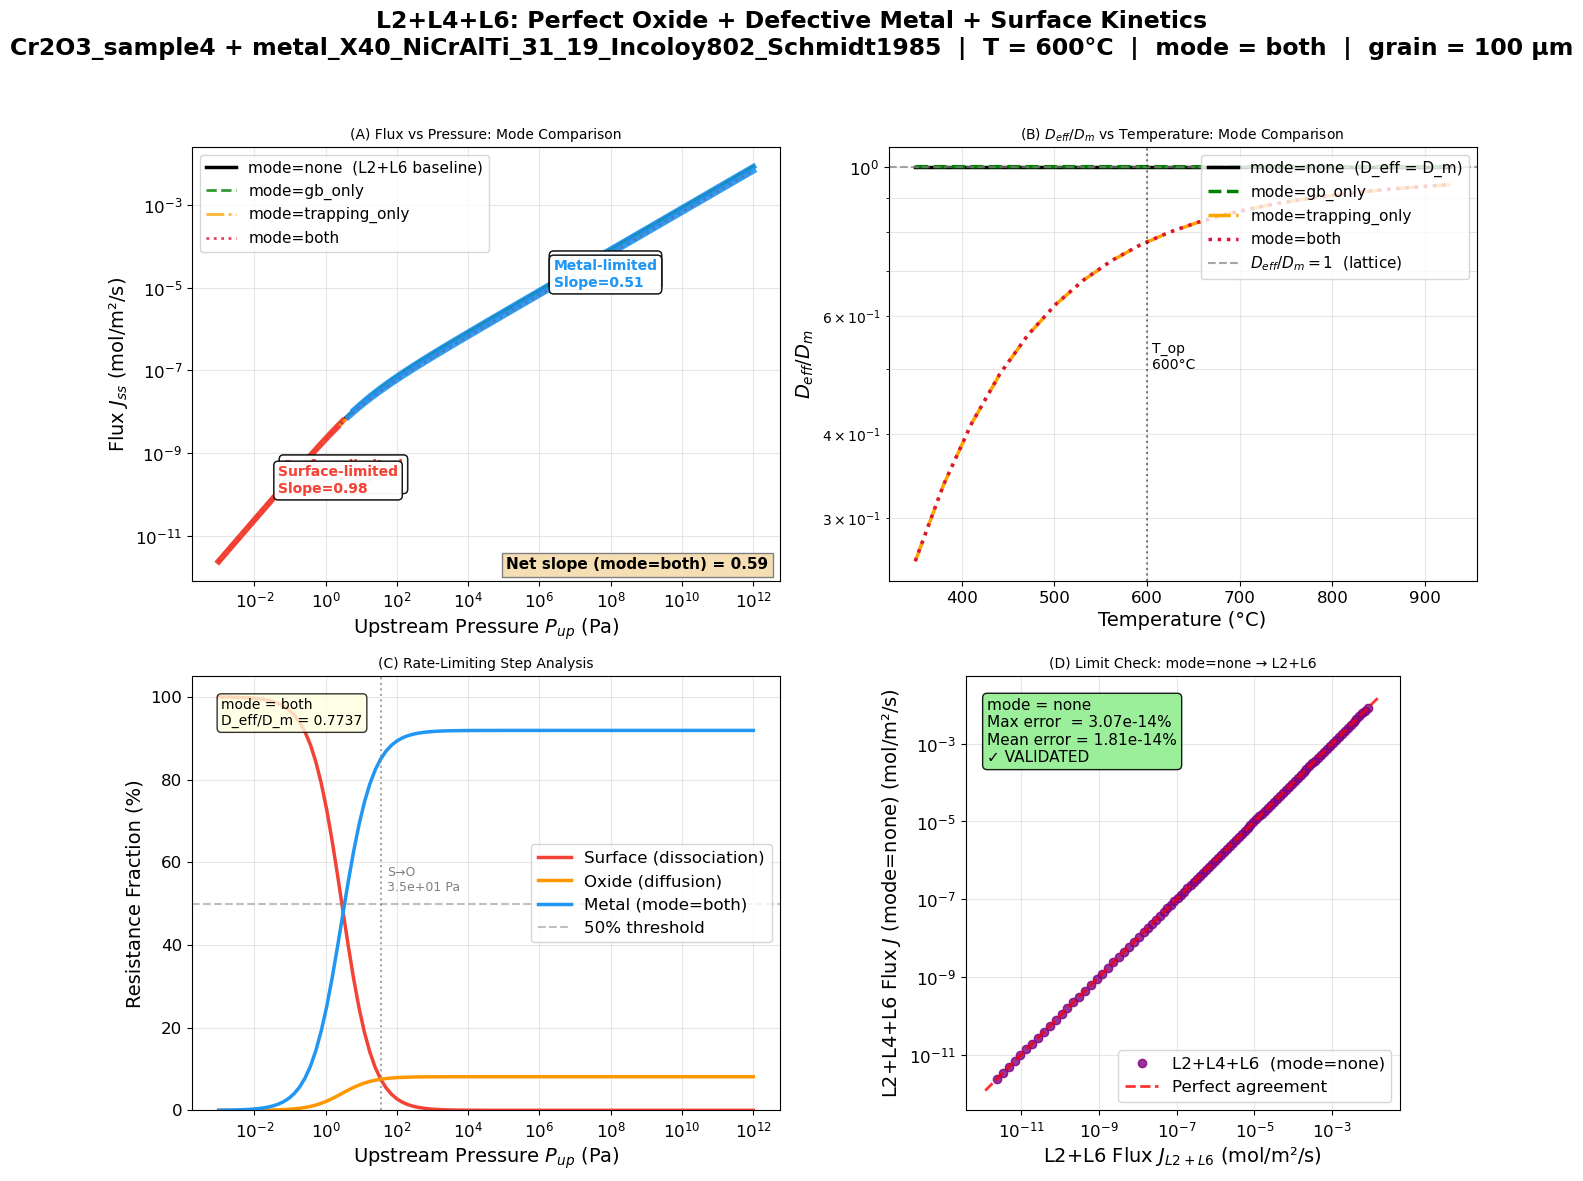


L2+L4+L6 FIGURE 1 — VALIDATION SUMMARY
  Net log-log slope (mode=both): 0.5892
  D_eff/D_m at T_op:
    mode=none            1.0000
    mode=gb_only         1.0007
    mode=trapping_only   0.7732
    mode=both            0.7737
  Limit check error (mode=none): 3.07e-14%  (✓)
  S→O crossover:  3.51e+01 Pa


In [31]:
# =============================================================================
# CELL 4 — FIGURE 1: Core Validation (2×2)
# =============================================================================
"""
Figure 1 validates the L2+L4+L6 model from four angles at operating
temperature. The key new dimension vs L2+L6 is the microstructure mode.

Panel (A) — Flux vs Pressure: Mode Comparison
    Question: How does each microstructure mode shift the flux curve and
    regime boundaries relative to the pure lattice baseline?
    Four curves: mode='none' (L2+L6 baseline), mode='gb_only' (GB
    short-circuit only), mode='trapping_only' (trapping only),
    mode='both'. Each curve has colored regime overlays and slope
    annotation boxes using the identical pattern from all previous levels.
    mode='none' is the black solid baseline. The other three use
    CURVE_STYLES colors. Net slope annotation box references the active
    config mode.

Panel (B) — D_eff/D_m vs Temperature: Mode Comparison
    Question: How does each microstructure mode change the effective
    diffusivity relative to the lattice value across the temperature range,
    and where does each mode cross D_eff/D_m = 1?
    Sweeps temperature from T_RANGE[0] to T_RANGE[1]. Computes D_eff for
    each mode at each T via get_D_eff_at_T. GBs push ratio above 1 at
    low T (short-circuit). Traps push it below 1 at low T (delayed
    diffusion). The crossover temperature for each mode is annotated.
    Dual x-axis: °C bottom, K top.

Panel (C) — Resistance Fractions vs Pressure
    Question: Which step controls the rate at operating conditions?
    Consistent style with all previous levels — semilogx lines per
    fraction, 50% threshold, S→O and O→M crossover vertical lines.
    Uses the active config mode. Annotation box shows mode and D_eff/D_m.

Panel (D) — Limit Check: mode='none' recovers L2+L6
    Question: When microstructure is disabled, does L2+L4+L6 recover
    the L2+L6 result exactly?
    Runs calculate_defective_metal_flux_L6 with mode='none' and compares
    to solve_steady_state_flux_direct. Parity plot. Green box if < 1%.
"""

props = dict(boxstyle='round', facecolor='wheat', alpha=0.9)

fig, axes = plt.subplots(2, 2, figsize=STYLE['figsize'])
fig.suptitle(
    f'L2+L4+L6: Perfect Oxide + Defective Metal + Surface Kinetics\n'
    f'{OXIDE_KEY} + {METAL_KEY}  |  T = {T_op-273.15:.0f}°C  |  '
    f'mode = {mode}  |  grain = {grain_size*1e6:.0f} μm',
    fontsize=STYLE['fontsize_suptitle']-1, fontweight='bold', y=0.98
)

# ── Regime overlay helper — identical to all previous levels ──────────────────
def plot_regime_overlay(ax, P_arr, J_arr, frac_s, frac_o, frac_m, valid_mask):
    rl = np.where(frac_s > 0.5, 'surface',
         np.where(frac_o > 0.5, 'oxide',
         np.where(frac_m > 0.5, 'metal', 'mixed')))

    region_styles = [
        ('surface', CURVE_STYLES['surface_region']['color'], 'Surface-limited'),
        ('oxide',   CURVE_STYLES['oxide_region']['color'],   'Oxide-limited'),
        ('metal',   CURVE_STYLES['metal_region']['color'],   'Metal-limited'),
        ('mixed',   CURVE_STYLES['mixed_region']['color'],   'Mixed'),
    ]

    for regime, color, label in region_styles:
        mask = (rl == regime) & valid_mask
        if not np.any(mask):
            continue
        idxs = np.where(mask)[0]
        for _, g in groupby(enumerate(idxs), lambda x: x[0] - x[1]):
            group = list(map(itemgetter(1), g))
            if len(group) < 3:
                continue
            P_seg = P_arr[group]
            J_seg = J_arr[group]
            ax.loglog(P_seg, J_seg, color=color, lw=4, alpha=0.7)
            slope_seg, *_ = stats.linregress(
                np.log10(P_seg), np.log10(np.abs(J_seg))
            )
            mid = len(group) // 2
            ax.text(
                P_seg[mid], J_seg[mid],
                f'{label}\nSlope={slope_seg:.2f}',
                color=color,
                fontsize=STYLE['fontsize_annotation']-1,
                fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
            )

# ─────────────────────────────────────────────────────────────────────────────
# (A) FLUX vs PRESSURE — mode comparison
# ─────────────────────────────────────────────────────────────────────────────
ax1 = axes[0, 0]
P_A = np.logspace(-3, 12, 100)

mode_cases = [
    ('none',          'black',                              '-',  'mode=none  (L2+L6 baseline)'),
    ('gb_only',       CURVE_STYLES['L4_gb']['color'],       '--', 'mode=gb_only'),
    ('trapping_only', CURVE_STYLES['L4_trap']['color'],     '-.', 'mode=trapping_only'),
    ('both',          CURVE_STYLES['L4_both']['color'],     ':',  'mode=both'),
]

for m, color, ls, label in mode_cases:
    J_m  = np.full(len(P_A), np.nan)
    fs_m = np.full(len(P_A), np.nan)
    fo_m = np.full(len(P_A), np.nan)
    fm_m = np.full(len(P_A), np.nan)

    for i, P_up in enumerate(P_A):
        try:
            r = calculate_defective_metal_flux_L6(
                P_up, P_down,
                L_m,
                T_op,
                k_diss, K_eq,
                D_ox, K_ox, L_ox,
                D_m,
                K_s_m,
                microstructure_params=microstructure,
                mode=m,
            )
            J_m[i]  = r['flux']
            fs_m[i] = r['resistances']['fraction_surface']
            fo_m[i] = r['resistances']['fraction_oxide']
            fm_m[i] = r['resistances']['fraction_metal']
        except Exception:
            pass

    v_m = ~np.isnan(J_m) & (J_m > 0)
    if not np.any(v_m):
        print(f"  ⚠  mode={m}: no valid points")
        continue

    lw    = STYLE['linewidth'] if m == 'none' else STYLE['linewidth'] - 0.5
    alpha_val = 1.0            if m == 'none' else 0.8

    ax1.loglog(
        P_A[v_m], J_m[v_m],
        color=color, ls=ls, lw=lw, alpha=alpha_val,
        label=label
    )
    plot_regime_overlay(ax1, P_A, J_m, fs_m, fo_m, fm_m, v_m)

# Net slope annotation
v_net = ~np.isnan(J_arr) & (J_arr > 0)
if np.sum(v_net) > 2:
    slope_net, *_ = stats.linregress(
        np.log10(P_RANGE_ARR[v_net]),
        np.log10(np.abs(J_arr[v_net]))
    )
    ax1.text(
        0.98, 0.02, f'Net slope (mode={mode}) = {slope_net:.2f}',
        transform=ax1.transAxes, ha='right', va='bottom',
        fontsize=STYLE['fontsize_annotation'], fontweight='bold',
        bbox=dict(boxstyle='square', fc='wheat', ec='gray', alpha=1)
    )
else:
    slope_net = np.nan

ax1.set_xlabel('Upstream Pressure $P_{up}$ (Pa)',      fontsize=STYLE['fontsize_axis'])
ax1.set_ylabel('Flux $J_{ss}$ (mol/m²/s)',              fontsize=STYLE['fontsize_axis'])
ax1.set_title('(A) Flux vs Pressure: Mode Comparison', fontsize=STYLE['fontsize_title'])
ax1.legend(fontsize=STYLE['fontsize_legend']-1, loc='upper left')
ax1.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax1.tick_params(labelsize=STYLE['fontsize_tick'])

# ─────────────────────────────────────────────────────────────────────────────
# (B) D_eff/D_m vs TEMPERATURE — mode comparison
# ─────────────────────────────────────────────────────────────────────────────
ax2 = axes[0, 1]

temperatures_K = np.linspace(T_RANGE[0], T_RANGE[1], N_T)

mode_D_styles = [
    ('none',          'black',                              '-',  'mode=none  (D_eff = D_m)'),
    ('gb_only',       CURVE_STYLES['L4_gb']['color'],       '--', 'mode=gb_only'),
    ('trapping_only', CURVE_STYLES['L4_trap']['color'],     '-.', 'mode=trapping_only'),
    ('both',          CURVE_STYLES['L4_both']['color'],     ':',  'mode=both'),
]

for m, color, ls, label in mode_D_styles:
    ratio_arr = np.full(N_T, np.nan)

    for j, T_K in enumerate(temperatures_K):
        D_latt  = get_D_m_at_T(T_K)
        D_eff_j = get_D_eff_at_T(T_K, m, microstructure)
        if D_latt > 0:
            ratio_arr[j] = D_eff_j / D_latt

    v_r = ~np.isnan(ratio_arr)
    if not np.any(v_r):
        continue

    ax2.semilogy(
        temperatures_K[v_r] - 273.15, ratio_arr[v_r],
        color=color, ls=ls, lw=STYLE['linewidth'],
        label=label
    )

    # Annotate crossover where ratio crosses 1
    if m in ('gb_only', 'both'):
        cross = np.where(np.diff(np.sign(ratio_arr[v_r] - 1.0)))[0]
        if len(cross) > 0:
            T_cross = temperatures_K[v_r][cross[0]] - 273.15
            ax2.axvline(T_cross, color=color, ls=':', lw=1.5, alpha=0.6)
            ax2.text(
                T_cross + 5, 2.0,
                f'{T_cross:.0f}°C',
                color=color, fontsize=STYLE['fontsize_annotation']-1
            )

# Unity reference line
ax2.axhline(
    1.0, color='gray', ls='--', lw=1.5, alpha=0.7,
    label='$D_{eff}/D_m = 1$  (lattice)'
)

# T_op marker
ax2.axvline(
    T_op - 273.15, color='black', ls=':', lw=1.5, alpha=0.5
)
ax2.text(
    T_op - 273.15 + 5, 0.5,
    f'T_op\n{T_op-273.15:.0f}°C',
    fontsize=STYLE['fontsize_annotation']-1, color='black'
)

ax2.set_xlabel('Temperature (°C)',      fontsize=STYLE['fontsize_axis'])
ax2.set_ylabel('$D_{eff}/D_m$',         fontsize=STYLE['fontsize_axis'])
ax2.set_title('(B) $D_{eff}/D_m$ vs Temperature: Mode Comparison',
              fontsize=STYLE['fontsize_title'])
ax2.legend(fontsize=STYLE['fontsize_legend']-1, loc='upper right')
ax2.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax2.tick_params(labelsize=STYLE['fontsize_tick'])

# ─────────────────────────────────────────────────────────────────────────────
# (C) RESISTANCE FRACTIONS vs PRESSURE
# ─────────────────────────────────────────────────────────────────────────────
ax3 = axes[1, 0]

ax3.semilogx(
    P_RANGE_ARR[valid], frac_surface_arr[valid] * 100,
    color=CURVE_STYLES['surface_region']['color'],
    lw=STYLE['linewidth'], label='Surface (dissociation)'
)
ax3.semilogx(
    P_RANGE_ARR[valid], frac_oxide_arr[valid] * 100,
    color=CURVE_STYLES['oxide_region']['color'],
    lw=STYLE['linewidth'], label='Oxide (diffusion)'
)
ax3.semilogx(
    P_RANGE_ARR[valid], frac_metal_arr[valid] * 100,
    color=CURVE_STYLES['metal_region']['color'],
    lw=STYLE['linewidth'], label=f'Metal (mode={mode})'
)
ax3.axhline(
    50,
    color=CURVE_STYLES['threshold']['color'],
    ls=CURVE_STYLES['threshold']['ls'],
    lw=CURVE_STYLES['threshold']['lw'],
    alpha=CURVE_STYLES['threshold']['alpha'],
    label='50% threshold'
)

if P_cross_surf_oxide is not None:
    ax3.axvline(P_cross_surf_oxide, color='gray', ls=':', lw=1.5, alpha=0.7)
    ax3.text(
        P_cross_surf_oxide * 1.5, 53,
        f'S→O\n{P_cross_surf_oxide:.1e} Pa',
        fontsize=STYLE['fontsize_annotation']-2, color='gray'
    )
if P_cross_oxide_metal is not None:
    ax3.axvline(P_cross_oxide_metal, color='gray', ls=':', lw=1.5, alpha=0.7)
    ax3.text(
        P_cross_oxide_metal * 1.5, 53,
        f'O→M\n{P_cross_oxide_metal:.1e} Pa',
        fontsize=STYLE['fontsize_annotation']-2, color='gray'
    )

if P_cross_surf_oxide is None and P_cross_oxide_metal is None:
    dominant = ('Surface' if n_surface >= n_oxide and n_surface >= n_metal
                else 'Oxide' if n_oxide >= n_metal else 'Metal')
    ax3.text(
        0.05, 0.50,
        f'No crossover in range\n{dominant}-limited throughout',
        transform=ax3.transAxes,
        fontsize=STYLE['fontsize_annotation'],
        va='center',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9)
    )

ax3.text(
    0.05, 0.95,
    f'mode = {mode}\nD_eff/D_m = {D_eff/D_m:.4f}',
    transform=ax3.transAxes,
    fontsize=STYLE['fontsize_annotation']-1, va='top',
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8)
)

ax3.set_xlabel('Upstream Pressure $P_{up}$ (Pa)', fontsize=STYLE['fontsize_axis'])
ax3.set_ylabel('Resistance Fraction (%)',          fontsize=STYLE['fontsize_axis'])
ax3.set_title('(C) Rate-Limiting Step Analysis',   fontsize=STYLE['fontsize_title'])
ax3.set_ylim(0, 105)
ax3.legend(fontsize=STYLE['fontsize_legend'], loc='center right')
ax3.grid(True, alpha=STYLE['grid_alpha'])
ax3.tick_params(labelsize=STYLE['fontsize_tick'])

# ─────────────────────────────────────────────────────────────────────────────
# (D) LIMIT CHECK — mode='none' recovers L2+L6
# ─────────────────────────────────────────────────────────────────────────────
ax4 = axes[1, 1]

P_D    = np.logspace(-3, 12, 100)
J_none = np.full(len(P_D), np.nan)
J_L2L6 = np.full(len(P_D), np.nan)

for i, P_up in enumerate(P_D):
    try:
        r_none = calculate_defective_metal_flux_L6(
            P_up, P_down,
            L_m,
            T_op,
            k_diss, K_eq,
            D_ox, K_ox, L_ox,
            D_m,
            K_s_m,
            microstructure_params=microstructure,
            mode='none',
        )
        J_none[i] = r_none['flux']
    except Exception:
        pass

    try:
        r_L2L6 = solve_steady_state_flux_direct(
            P_up, P_down, L_m,
            k_diss, K_eq,
            D_ox, K_ox, L_ox,
            D_m, K_s_m
        )
        J_L2L6[i] = r_L2L6['J_ss']
    except Exception:
        pass

valid_parity = (~np.isnan(J_none) & ~np.isnan(J_L2L6) &
                (J_none > 0) & (J_L2L6 > 0))

if np.any(valid_parity):
    ax4.loglog(
        J_L2L6[valid_parity], J_none[valid_parity],
        'o', color=CURVE_STYLES['L2_L6']['color'],
        markersize=6, alpha=0.8,
        label='L2+L4+L6  (mode=none)'
    )

    J_min = min(J_L2L6[valid_parity].min(), J_none[valid_parity].min()) * 0.5
    J_max = max(J_L2L6[valid_parity].max(), J_none[valid_parity].max()) * 2.0
    ax4.loglog(
        [J_min, J_max], [J_min, J_max],
        color=CURVE_STYLES['parity']['color'],
        ls=CURVE_STYLES['parity']['ls'],
        lw=CURVE_STYLES['parity']['lw'],
        alpha=CURVE_STYLES['parity']['alpha'],
        label='Perfect agreement'
    )

    rel_errors = (np.abs(J_none[valid_parity] - J_L2L6[valid_parity])
                  / J_L2L6[valid_parity] * 100)
    max_err   = rel_errors.max()
    mean_err  = rel_errors.mean()
    box_color = 'lightgreen' if max_err < 1.0 else 'lightyellow'

    ax4.text(
        0.05, 0.95,
        f'mode = none\n'
        f'Max error  = {max_err:.2e}%\n'
        f'Mean error = {mean_err:.2e}%\n'
        f'{"✓ VALIDATED" if max_err < 1.0 else "⚠ CHECK"}',
        transform=ax4.transAxes, fontsize=STYLE['fontsize_annotation'],
        va='top',
        bbox=dict(boxstyle='round', facecolor=box_color, alpha=0.9)
    )
else:
    max_err  = np.nan
    mean_err = np.nan
    ax4.text(
        0.5, 0.5, 'No valid parity points\nCheck solver',
        transform=ax4.transAxes, ha='center', va='center',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9)
    )

ax4.set_xlabel('L2+L6 Flux $J_{L2+L6}$ (mol/m²/s)',         fontsize=STYLE['fontsize_axis'])
ax4.set_ylabel('L2+L4+L6 Flux $J$ (mode=none) (mol/m²/s)',  fontsize=STYLE['fontsize_axis'])
ax4.set_title('(D) Limit Check: mode=none → L2+L6',          fontsize=STYLE['fontsize_title'])
ax4.set_aspect('equal', adjustable='box')
ax4.legend(fontsize=STYLE['fontsize_legend'], loc='lower right')
ax4.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax4.tick_params(labelsize=STYLE['fontsize_tick'])

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print("\n" + "=" * 60)
print("L2+L4+L6 FIGURE 1 — VALIDATION SUMMARY")
print("=" * 60)
if not np.isnan(slope_net):
    print(f"  Net log-log slope (mode={mode}): {slope_net:.4f}")
print(f"  D_eff/D_m at T_op:")
for m, D in D_eff_modes.items():
    print(f"    mode={m:<14}  {D/D_m:.4f}")
print(f"  Limit check error (mode=none): {max_err:.2e}%  "
      f"({'✓' if not np.isnan(max_err) and max_err < 1.0 else '⚠'})")
if P_cross_surf_oxide is not None:
    print(f"  S→O crossover:  {P_cross_surf_oxide:.2e} Pa")
if P_cross_oxide_metal is not None:
    print(f"  O→M crossover:  {P_cross_oxide_metal:.2e} Pa")
print("=" * 60)

/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:1410: UserWarning: GB volume fraction 15.00% > 10%. GB network percolation effects become important. Consider using Hart model instead of parallel.
  warnings.warn(f"GB volume fraction {f_gb:.2%} > 10%. "
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:1410: UserWarning: GB volume fraction 10.09% > 10%. GB network percolation effects become important. Consider using Hart model instead of parallel.
  warnings.warn(f"GB volume fraction {f_gb:.2%} > 10%. "
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:2006: UserWarning: GB enhancement (1.46×) and trapping (0.77×) nearly cancel. Small parameter changes could significantly affect results.
  warnings.warn(msg)
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:200

  ⚠  oxide: P_for_oxide_Ea is None — fit skipped


/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:613: UserWarning: Temperature 623.0 K is far outside data range [873.1, 1273.2] K. Clamping to nearest data limit for interpolation.
  warnings.warn(
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:621: UserWarning: Temperature 767.2 K is outside data range [873.1, 1273.2] K. Extrapolation may be inaccurate.
  warnings.warn(f"Temperature {T_kelvin:.1f} K is outside data range "
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:2006: UserWarning: GB enhancement (1.00×) and trapping (0.81×) nearly cancel. Small parameter changes could significantly affect results.
  warnings.warn(msg)
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:2006: UserWarning: GB enhancement (1.00×) and trapping (0.90×) nearly cancel. Sm

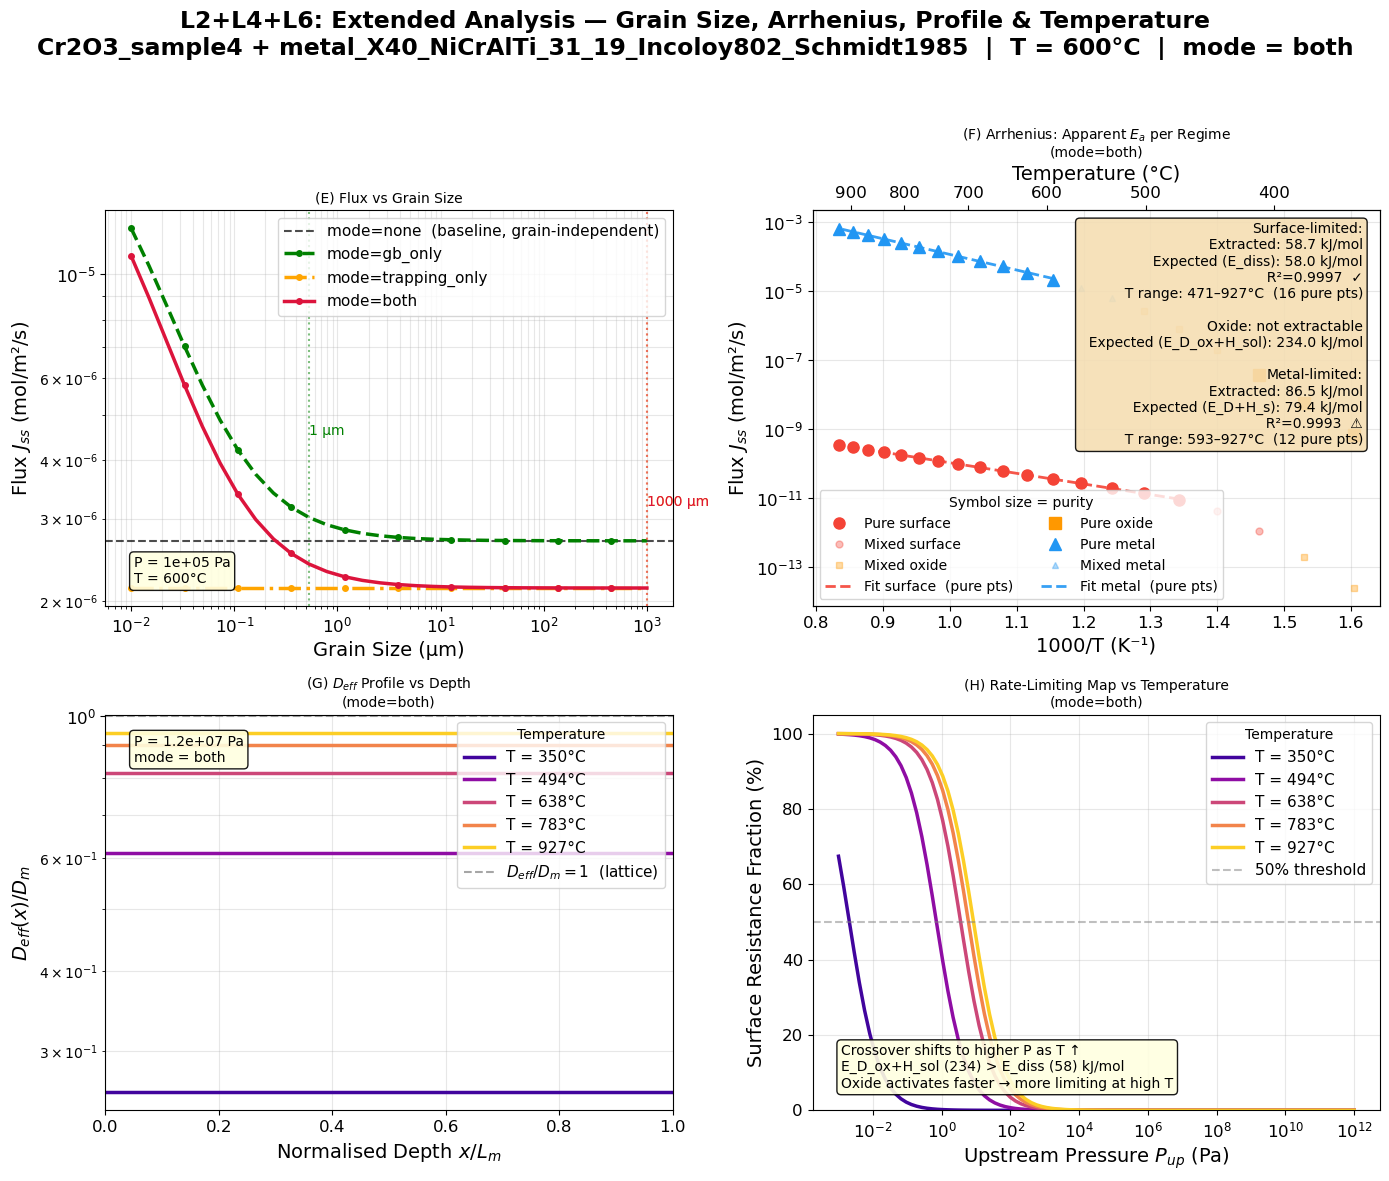


L2+L4+L6 FIGURE 2 — SUMMARY
  mode = both

  Arrhenius results:
    Surface: extracted=58.7  expected=58.0 kJ/mol  shift=+0.8 kJ/mol  (✓)  16 pure pts
    Oxide: not extractable
    Metal: extracted=86.5  expected=79.4 kJ/mol  shift=+7.1 kJ/mol  (⚠)  12 pure pts

  Crossover pressures across T sweep:
    T = 350°C  →  P_crossover = 2.01e-03 Pa
    T = 494°C  →  P_crossover = 5.34e-01 Pa
    T = 638°C  →  P_crossover = 3.05e+00 Pa
    T = 783°C  →  P_crossover = 4.33e+00 Pa
    T = 927°C  →  P_crossover = 6.14e+00 Pa


In [32]:
# =============================================================================
# CELL 5 — FIGURE 2: Extended Analysis (2×2)
# =============================================================================
"""
Figure 2 examines grain size sensitivity, activation energies, D_eff
spatial profile, and temperature effects on the rate-limiting balance.

Panel (E) — Flux vs Grain Size
    Question: How does grain size change the flux for each microstructure
    mode, and at what grain size does the microstructure effect saturate?
    Fixed T and P (from VALIDATION['L4']). Sweeps grain_size from
    grain_size_sweep range in config. Three curves — mode='gb_only',
    mode='trapping_only', mode='both'. mode='none' is the horizontal
    baseline (grain-size independent). Log-log plot. Shows flux saturates
    at large grain sizes (bulk lattice limit) and diverges from the
    baseline at small grain sizes where GB area fraction dominates.
    The grain size where each mode crosses 10% deviation from baseline
    is annotated.

Panel (F) — Arrhenius: apparent Ea per regime, classified by purity
    Question: Does the model extract the correct activation energy in each
    regime, and does microstructure shift the apparent Ea vs the pure
    lattice reference?
    Same five-category classification approach as all previous levels.
    Uses calculate_defective_metal_flux_L6 with active config mode at
    each T. Resistance fractions from the solver result. Dashed fit line
    through pure points only. Annotation box shows extracted vs expected
    Ea and T range used. The metal regime apparent Ea is expected to
    shift from E_D+H_s when microstructure is active — this panel
    quantifies that shift.

Panel (G) — D_eff Profile vs Metal Depth at Multiple T
    Question: How does D_eff vary through the metal thickness at different
    temperatures, and does the concentration gradient create a meaningful
    D_eff profile?
    Runs the solver at P_for_metal_Ea (or fallback P) at 5 temperatures.
    Extracts the D_eff spatial profile (x vs D) from r['profiles'].
    Plots D_eff/D_m vs normalised depth x/L_m for each temperature using
    plasma colormap. A flat profile means D_eff is concentration-
    independent at that T. A gradient means the inlet concentration
    is high enough to change trap occupancy or GB contribution across
    the thickness.

Panel (H) — Rate-Limiting Map vs Temperature
    Question: How does the surface/oxide/metal resistance balance shift
    as temperature increases for the active config mode?
    Runs the full pressure sweep at 5 temperatures. Plots surface
    resistance fraction (%) vs pressure using plasma colormap.
    Consistent style with all previous levels. Crossover shift direction
    annotated with physical reason from config activation energies.
"""

fig2, axes2 = plt.subplots(2, 2, figsize=STYLE['figsize'])
fig2.suptitle(
    f'L2+L4+L6: Extended Analysis — Grain Size, Arrhenius, Profile & Temperature\n'
    f'{OXIDE_KEY} + {METAL_KEY}  |  T = {T_op-273.15:.0f}°C  |  mode = {mode}',
    fontsize=STYLE['fontsize_suptitle']-1, fontweight='bold', y=0.98
)

# ─────────────────────────────────────────────────────────────────────────────
# (E) FLUX vs GRAIN SIZE
# ─────────────────────────────────────────────────────────────────────────────
ax_E = axes2[0, 0]

P_fixed_E = VAL_L4['P_fixed']

# mode='none' baseline — grain-size independent
try:
    r_base_E = calculate_defective_metal_flux_L6(
        P_fixed_E, P_down,
        L_m, T_grain_size,
        k_diss, K_eq,
        D_ox, K_ox, L_ox,
        D_m, K_s_m,
        microstructure_params=microstructure,
        mode='none',
    )
    J_baseline_E = r_base_E['flux']
except Exception:
    J_baseline_E = np.nan

if not np.isnan(J_baseline_E):
    ax_E.axhline(
        J_baseline_E, color='black', ls='--', lw=1.5, alpha=0.7,
        label='mode=none  (baseline, grain-independent)'
    )

grain_mode_styles = [
    ('gb_only',       CURVE_STYLES['L4_gb']['color'],   '--', 'mode=gb_only'),
    ('trapping_only', CURVE_STYLES['L4_trap']['color'], '-.', 'mode=trapping_only'),
    ('both',          CURVE_STYLES['L4_both']['color'], '-',  'mode=both'),
]

for m, color, ls, label in grain_mode_styles:
    J_gs = np.full(len(grain_size_sweep), np.nan)

    for i, gs in enumerate(grain_size_sweep):
        ms_gs = {**microstructure, 'grain_size': gs}
        try:
            r = calculate_defective_metal_flux_L6(
                P_fixed_E, P_down,
                L_m, T_grain_size,
                k_diss, K_eq,
                D_ox, K_ox, L_ox,
                D_m, K_s_m,
                microstructure_params=ms_gs,
                mode=m,
            )
            J_gs[i] = r['flux']
        except Exception:
            pass

    v_gs = ~np.isnan(J_gs) & (J_gs > 0)
    if not np.any(v_gs):
        print(f"  ⚠  mode={m}: no valid grain size points")
        continue

    ax_E.loglog(
        grain_size_sweep[v_gs] * 1e6, J_gs[v_gs],
        color=color, ls=ls, lw=STYLE['linewidth'],
        marker='o', ms=4, markevery=3,
        label=label
    )

    # Annotate grain size where deviation from baseline exceeds 10%
    if not np.isnan(J_baseline_E):
        dev = np.abs(J_gs[v_gs] - J_baseline_E) / J_baseline_E
        cross_10 = np.where(dev > 0.10)[0]
        if len(cross_10) > 0:
            gs_cross = grain_size_sweep[v_gs][cross_10[-1]]
            ax_E.axvline(
                gs_cross * 1e6, color=color, ls=':', lw=1.5, alpha=0.5
            )
            ax_E.text(
                gs_cross * 1e6, J_gs[v_gs][cross_10[-1]] * 1.5,
                f'{gs_cross*1e6:.0f} μm',
                color=color, fontsize=STYLE['fontsize_annotation']-1
            )

ax_E.text(
    0.05, 0.05,
    f'P = {P_fixed_E:.0e} Pa\nT = {T_grain_size-273.15:.0f}°C',
    transform=ax_E.transAxes, fontsize=STYLE['fontsize_annotation']-1,
    va='bottom',
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9)
)

ax_E.set_xlabel('Grain Size (μm)',            fontsize=STYLE['fontsize_axis'])
ax_E.set_ylabel('Flux $J_{ss}$ (mol/m²/s)',   fontsize=STYLE['fontsize_axis'])
ax_E.set_title('(E) Flux vs Grain Size',       fontsize=STYLE['fontsize_title'])
ax_E.legend(fontsize=STYLE['fontsize_legend']-1, loc='upper right')
ax_E.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax_E.tick_params(labelsize=STYLE['fontsize_tick'])

# ─────────────────────────────────────────────────────────────────────────────
# (F) ARRHENIUS — apparent Ea per regime, classified by purity
# ─────────────────────────────────────────────────────────────────────────────
ax_F = axes2[0, 1]

temperatures_K = np.linspace(T_RANGE[0], T_RANGE[1], N_T)
inv_T          = 1000.0 / temperatures_K

def classify_regime(fs, fo, fm, pure_thresh=0.90, mixed_thresh=0.50):
    if fs >= pure_thresh:    return 'pure_surface'
    elif fo >= pure_thresh:  return 'pure_oxide'
    elif fm >= pure_thresh:  return 'pure_metal'
    elif fs >= mixed_thresh: return 'mixed_surface'
    elif fo >= mixed_thresh: return 'mixed_oxide'
    elif fm >= mixed_thresh: return 'mixed_metal'
    else:                    return 'mixed'

regime_class_styles = {
    'pure_surface':  {'color': CURVE_STYLES['surface_region']['color'],
                      'marker': 'o', 'ms': 8,  'alpha': 1.0},
    'mixed_surface': {'color': CURVE_STYLES['surface_region']['color'],
                      'marker': 'o', 'ms': 5,  'alpha': 0.35},
    'pure_oxide':    {'color': CURVE_STYLES['oxide_region']['color'],
                      'marker': 's', 'ms': 8,  'alpha': 1.0},
    'mixed_oxide':   {'color': CURVE_STYLES['oxide_region']['color'],
                      'marker': 's', 'ms': 5,  'alpha': 0.35},
    'pure_metal':    {'color': CURVE_STYLES['metal_region']['color'],
                      'marker': '^', 'ms': 8,  'alpha': 1.0},
    'mixed_metal':   {'color': CURVE_STYLES['metal_region']['color'],
                      'marker': '^', 'ms': 5,  'alpha': 0.35},
    'mixed':         {'color': CURVE_STYLES['mixed_region']['color'],
                      'marker': 'x', 'ms': 6,  'alpha': 0.5},
}

regime_Ea_cases = [
    ('surface', P_for_surface_Ea, CURVE_STYLES['surface_region']['color']),
    ('oxide',   P_for_oxide_Ea,   CURVE_STYLES['oxide_region']['color']),
    ('metal',   P_for_metal_Ea,   CURVE_STYLES['metal_region']['color']),
]

arrhenius_results  = {}
plotted_cls_labels = set()

for label, P_fixed, color in regime_Ea_cases:
    if P_fixed is None:
        print(f"  ⚠  {label}: P_for_{label}_Ea is None — fit skipped")
        arrhenius_results[label] = None
        continue

    J_arr_T   = np.full(N_T, np.nan)
    class_arr = np.empty(N_T, dtype=object)

    for j, T_K in enumerate(temperatures_K):
        try:
            r = calculate_defective_metal_flux_L6(
                P_fixed, P_down,
                L_m,
                T_K,
                get_k_diss_at_T(T_K), get_K_eq_at_T(T_K),
                get_D_ox_at_T(T_K),   get_K_ox_at_T(T_K), L_ox,
                get_D_m_at_T(T_K),
                get_K_s_m_at_T(T_K),
                microstructure_params=microstructure,
                mode=mode,
            )
            J_arr_T[j] = r['flux']
            fs = r['resistances']['fraction_surface']
            fo = r['resistances']['fraction_oxide']
            fm = r['resistances']['fraction_metal']
            class_arr[j] = classify_regime(fs, fo, fm)
        except Exception:
            class_arr[j] = 'mixed'

    pure = (class_arr == f'pure_{label}') & ~np.isnan(J_arr_T) & (J_arr_T > 0)

    # Plot all classified points
    for cls, sty in regime_class_styles.items():
        mask = (class_arr == cls) & ~np.isnan(J_arr_T) & (J_arr_T > 0)
        if not np.any(mask):
            continue
        cls_label = cls.replace('_', ' ').capitalize()
        ax_F.semilogy(
            inv_T[mask], J_arr_T[mask],
            ls='none',
            color=sty['color'], marker=sty['marker'],
            ms=sty['ms'], alpha=sty['alpha'],
            label=cls_label if cls_label not in plotted_cls_labels
                  else '_nolegend_'
        )
        plotted_cls_labels.add(cls_label)

    if np.sum(pure) < 3:
        print(f"  ⚠  {label}: only {np.sum(pure)} pure T points — fit skipped")
        arrhenius_results[label] = None
        continue

    slope, intercept, r_val, *_ = stats.linregress(
        inv_T[pure], np.log(J_arr_T[pure])
    )
    E_a = -slope * R * 1000

    arrhenius_results[label] = {
        'J': J_arr_T, 'valid': pure,
        'slope': slope, 'intercept': intercept,
        'r_sq': r_val**2, 'E_a': E_a,
        'P_fixed': P_fixed, 'color': color,
        'n_pure': int(np.sum(pure)),
        'T_pure_range': (temperatures_K[pure].min() - 273.15,
                         temperatures_K[pure].max() - 273.15),
    }

    ax_F.semilogy(
        inv_T[pure],
        np.exp(slope * inv_T[pure] + intercept),
        color=color, ls='--', lw=2.0, alpha=0.9,
        label=f'Fit {label}  (pure pts)'
    )

# Dual x-axis
ax_F_top = ax_F.twiny()
ax_F_top.set_xlim(ax_F.get_xlim())
T_ticks_C = np.array([200, 300, 400, 500, 600, 700, 800, 900])
T_ticks_K = T_ticks_C + 273.15
in_range  = (T_ticks_K >= T_RANGE[0]) & (T_ticks_K <= T_RANGE[1])
if np.any(in_range):
    ax_F_top.set_xticks(1000.0 / T_ticks_K[in_range])
    ax_F_top.set_xticklabels([f'{t}' for t in T_ticks_C[in_range]])
ax_F_top.set_xlabel('Temperature (°C)', fontsize=STYLE['fontsize_axis'])
ax_F_top.tick_params(labelsize=STYLE['fontsize_tick'])

# Annotation box
E_refs    = {'surface': E_REF_SURFACE, 'oxide': E_REF_OXIDE, 'metal': E_REF_METAL}
ref_names = {'surface': 'E_diss', 'oxide': 'E_D_ox+H_sol', 'metal': 'E_D+H_s'}
annot     = []
for lbl in ('surface', 'oxide', 'metal'):
    res = arrhenius_results.get(lbl)
    E_r = E_refs[lbl]
    rn  = ref_names[lbl]
    if res is None:
        annot.append(f'{lbl.capitalize()}: not extractable')
        annot.append(f'  Expected ({rn}): {E_r/1000:.1f} kJ/mol')
    else:
        match = abs(res['E_a'] - E_r) < 3000
        annot.append(f'{lbl.capitalize()}-limited:')
        annot.append(f'  Extracted: {res["E_a"]/1000:.1f} kJ/mol')
        annot.append(f'  Expected ({rn}): {E_r/1000:.1f} kJ/mol')
        annot.append(f'  R²={res["r_sq"]:.4f}  {"✓" if match else "⚠"}')
        annot.append(f'  T range: {res["T_pure_range"][0]:.0f}–'
                     f'{res["T_pure_range"][1]:.0f}°C  '
                     f'({res["n_pure"]} pure pts)')
    annot.append('')

ax_F.text(
    0.97, 0.97, '\n'.join(annot).rstrip(),
    transform=ax_F.transAxes, fontsize=STYLE['fontsize_annotation']-1,
    va='top', ha='right',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9)
)
ax_F.set_xlabel('1000/T (K⁻¹)',             fontsize=STYLE['fontsize_axis'])
ax_F.set_ylabel('Flux $J_{ss}$ (mol/m²/s)', fontsize=STYLE['fontsize_axis'])
ax_F.set_title(f'(F) Arrhenius: Apparent $E_a$ per Regime\n(mode={mode})',
               fontsize=STYLE['fontsize_title'])
ax_F.legend(fontsize=STYLE['fontsize_legend']-2, loc='lower left',
            ncol=2, title='Symbol size = purity')
ax_F.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax_F.tick_params(labelsize=STYLE['fontsize_tick'])

# ─────────────────────────────────────────────────────────────────────────────
# (G) D_eff PROFILE vs METAL DEPTH at multiple T
# ─────────────────────────────────────────────────────────────────────────────
ax_G = axes2[1, 0]

T_profile_values = np.linspace(T_RANGE[0], T_RANGE[1], 5)
T_colors_G       = plt.cm.plasma(np.linspace(0.1, 0.9, len(T_profile_values)))

# Use P_for_metal_Ea if available, else fallback to P_fixed_E
P_profile = P_for_metal_Ea if P_for_metal_Ea is not None else P_fixed_E

for T_K, col in zip(T_profile_values, T_colors_G):
    try:
        r_prof = calculate_defective_metal_flux_L6(
            P_profile, P_down,
            L_m,
            T_K,
            get_k_diss_at_T(T_K), get_K_eq_at_T(T_K),
            get_D_ox_at_T(T_K),   get_K_ox_at_T(T_K), L_ox,
            get_D_m_at_T(T_K),
            get_K_s_m_at_T(T_K),
            microstructure_params=microstructure,
            mode=mode,
        )

        profiles = r_prof.get('profiles', {})
        x_arr    = profiles.get('x', None)
        D_arr    = profiles.get('D', None)
        D_latt_T = get_D_m_at_T(T_K)

        if x_arr is None or D_arr is None:
            continue

        x_norm   = x_arr / L_m
        ratio_arr = D_arr / D_latt_T

        ax_G.semilogy(
            x_norm, ratio_arr,
            color=col, lw=STYLE['linewidth'],
            label=f'T = {T_K-273.15:.0f}°C'
        )

    except Exception:
        pass

ax_G.axhline(
    1.0, color='gray', ls='--', lw=1.5, alpha=0.7,
    label='$D_{eff}/D_m = 1$  (lattice)'
)

ax_G.text(
    0.05, 0.95,
    f'P = {P_profile:.1e} Pa\nmode = {mode}',
    transform=ax_G.transAxes, fontsize=STYLE['fontsize_annotation']-1,
    va='top',
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9)
)

ax_G.set_xlabel('Normalised Depth $x/L_m$',   fontsize=STYLE['fontsize_axis'])
ax_G.set_ylabel('$D_{eff}(x)/D_m$',           fontsize=STYLE['fontsize_axis'])
ax_G.set_title(f'(G) $D_{{eff}}$ Profile vs Depth\n(mode={mode})',
               fontsize=STYLE['fontsize_title'])
ax_G.set_xlim(0, 1)
ax_G.legend(fontsize=STYLE['fontsize_legend']-1, loc='upper right',
            title='Temperature')
ax_G.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax_G.tick_params(labelsize=STYLE['fontsize_tick'])

# ─────────────────────────────────────────────────────────────────────────────
# (H) RATE-LIMITING MAP vs TEMPERATURE
# ─────────────────────────────────────────────────────────────────────────────
ax_H = axes2[1, 1]

T_map_values        = np.linspace(T_RANGE[0], T_RANGE[1], 5)
T_colors_map        = plt.cm.plasma(np.linspace(0.1, 0.9, len(T_map_values)))
crossover_pressures = []

P_H = np.logspace(-3, 12, 100)

for T_K, col in zip(T_map_values, T_colors_map):
    fs_row = np.full(len(P_H), np.nan)

    for i, P_up in enumerate(P_H):
        try:
            r = calculate_defective_metal_flux_L6(
                P_up, P_down,
                L_m,
                T_K,
                get_k_diss_at_T(T_K), get_K_eq_at_T(T_K),
                get_D_ox_at_T(T_K),   get_K_ox_at_T(T_K), L_ox,
                get_D_m_at_T(T_K),
                get_K_s_m_at_T(T_K),
                microstructure_params=microstructure,
                mode=mode,
            )
            fs_row[i] = r['resistances']['fraction_surface'] * 100
        except Exception:
            pass

    valid_row = ~np.isnan(fs_row)
    if not np.any(valid_row):
        continue

    ax_H.semilogx(
        P_H[valid_row], fs_row[valid_row],
        color=col, lw=STYLE['linewidth'],
        label=f'T = {T_K-273.15:.0f}°C'
    )

    sc = np.where(np.diff(np.sign(fs_row[valid_row] - 50)))[0]
    if len(sc) > 0:
        idx  = sc[0]
        fs_v = fs_row[valid_row]
        if idx + 1 < len(fs_v) and fs_v[idx] > 50 and fs_v[idx+1] < 50:
            crossover_pressures.append((T_K, P_H[valid_row][idx]))

ax_H.axhline(
    50,
    color=CURVE_STYLES['threshold']['color'],
    ls=CURVE_STYLES['threshold']['ls'],
    lw=CURVE_STYLES['threshold']['lw'],
    alpha=CURVE_STYLES['threshold']['alpha'],
    label='50% threshold'
)

if len(crossover_pressures) >= 2:
    T_low,  P_co_low  = crossover_pressures[0]
    T_high, P_co_high = crossover_pressures[-1]
    if P_co_high < P_co_low:
        direction = 'lower P as T ↑'
        physical  = (f'E_diss ({E_REF_SURFACE/1000:.0f}) > '
                     f'E_D_ox+H_sol ({E_REF_OXIDE/1000:.0f}) kJ/mol')
        meaning   = 'Surface activates faster → less limiting at high T'
    else:
        direction = 'higher P as T ↑'
        physical  = (f'E_D_ox+H_sol ({E_REF_OXIDE/1000:.0f}) > '
                     f'E_diss ({E_REF_SURFACE/1000:.0f}) kJ/mol')
        meaning   = 'Oxide activates faster → more limiting at high T'
    ax_H.text(
        0.05, 0.05,
        f'Crossover shifts to {direction}\n{physical}\n{meaning}',
        transform=ax_H.transAxes,
        fontsize=STYLE['fontsize_annotation']-1, va='bottom',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9)
    )
elif len(crossover_pressures) == 0:
    dominant = 'surface-limited' if n_surface > n_oxide else 'oxide-limited'
    ax_H.text(
        0.05, 0.05,
        f'No crossover at any T\nSystem is {dominant}\nacross full pressure range',
        transform=ax_H.transAxes,
        fontsize=STYLE['fontsize_annotation']-1, va='bottom',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9)
    )

ax_H.set_xlabel('Upstream Pressure $P_{up}$ (Pa)',  fontsize=STYLE['fontsize_axis'])
ax_H.set_ylabel('Surface Resistance Fraction (%)',  fontsize=STYLE['fontsize_axis'])
ax_H.set_title(f'(H) Rate-Limiting Map vs Temperature\n(mode={mode})',
               fontsize=STYLE['fontsize_title'])
ax_H.set_ylim(0, 105)
ax_H.legend(fontsize=STYLE['fontsize_legend']-1, loc='upper right',
            title='Temperature')
ax_H.grid(True, alpha=STYLE['grid_alpha'])
ax_H.tick_params(labelsize=STYLE['fontsize_tick'])

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print("\n" + "=" * 60)
print("L2+L4+L6 FIGURE 2 — SUMMARY")
print("=" * 60)
print(f"  mode = {mode}")
print(f"\n  Arrhenius results:")
for lbl in ('surface', 'oxide', 'metal'):
    res = arrhenius_results.get(lbl)
    E_r = E_refs[lbl]
    if res is None:
        print(f"    {lbl.capitalize()}: not extractable")
    else:
        match = abs(res['E_a'] - E_r) < 3000
        shift = res['E_a'] - E_r
        print(f"    {lbl.capitalize()}: extracted={res['E_a']/1000:.1f}  "
              f"expected={E_r/1000:.1f} kJ/mol  "
              f"shift={shift/1000:+.1f} kJ/mol  "
              f"({'✓' if match else '⚠'})  "
              f"{res['n_pure']} pure pts")
if crossover_pressures:
    print(f"\n  Crossover pressures across T sweep:")
    for T_K, P_co in crossover_pressures:
        print(f"    T = {T_K-273.15:.0f}°C  →  P_crossover = {P_co:.2e} Pa")
print("=" * 60)

In [33]:
# =============================================================================
# CELL 6 — DATAFRAME OUTPUT
# =============================================================================
df = pd.DataFrame(rows)

df_display = df.copy()
for col in df_display.columns:
    if col in ('Rate-Limiting', 'mode', 'Error'):
        continue
    if df_display[col].dtype == float:
        if 'fraction' in col.lower():
            df_display[col] = df_display[col].round(2)
        elif 'theta' in col.lower():
            df_display[col] = df_display[col].round(6)
        elif 'D_eff/D_m' in col:
            df_display[col] = df_display[col].round(6)
        else:
            df_display[col] = df_display[col].apply(
                lambda x: f'{x:.4e}' if pd.notna(x) else 'NaN'
            )

n_surface_df = (df['Rate-Limiting'] == 'SURFACE').sum()
n_oxide_df   = (df['Rate-Limiting'] == 'OXIDE').sum()
n_metal_df   = (df['Rate-Limiting'] == 'METAL').sum()
n_mixed_df   = (df['Rate-Limiting'] == 'MIXED').sum()
n_error_df   = (df['Rate-Limiting'] == 'ERROR').sum()

print("=" * 60)
print("L2+L4+L6 RESULTS DATAFRAME")
print("=" * 60)
print(f"  Oxide:           {OXIDE_KEY}")
print(f"  Metal:           {METAL_KEY}")
print(f"  T:               {T_op-273.15:.0f}°C  ({T_op} K)")
print(f"  L_ox:            {L_ox*1e6:.1f} μm")
print(f"  L_m:             {L_m*1e3:.1f} mm")
print(f"  mode:            {mode}")
print(f"  grain_size:      {grain_size*1e6:.1f} μm")
print(f"  k_diss:          {k_diss:.3e}  mol/m²/s/Pa")
print(f"  K_eq:            {K_eq:.3e}  Pa⁻¹")
print(f"  α:               {alpha:.3e}  mol/m²/s/Pa^0.5  (oxide)")
print(f"  β_latt:          {beta_L:.3e}  mol/m²/s/Pa^0.5  (lattice)")
print(f"  β_eff:           {beta_eff:.3e}  mol/m²/s/Pa^0.5  (mode={mode})")
print(f"  D_eff/D_m:       {D_eff/D_m:.6f}")

print(f"\n  Total rows:        {len(df)}")
print(f"\n  Resistance regime:")
print(f"    Surface-limited: {n_surface_df}")
print(f"    Oxide-limited:   {n_oxide_df}")
print(f"    Metal-limited:   {n_metal_df}")
print(f"    Mixed:           {n_mixed_df}")
if n_error_df > 0:
    print(f"    Errors:          {n_error_df}  ⚠")

# D_eff statistics across pressure sweep
d_eff_col = df.get('D_eff (m²/s)', pd.Series(dtype=float))
if 'D_eff (m²/s)' in df.columns:
    d_vals = df['D_eff (m²/s)'].dropna()
    if len(d_vals) > 0:
        print(f"\n  D_eff across pressure sweep:")
        print(f"    Min:   {d_vals.min():.4e} m²/s")
        print(f"    Max:   {d_vals.max():.4e} m²/s")
        print(f"    Mean:  {d_vals.mean():.4e} m²/s")
        print(f"    D_m:   {D_m:.4e} m²/s")

if 'D_eff/D_m' in df.columns:
    ratio_vals = df['D_eff/D_m'].dropna()
    if len(ratio_vals) > 0:
        print(f"\n  D_eff/D_m range:  "
              f"{ratio_vals.min():.6f} → {ratio_vals.max():.6f}")

print("=" * 60)

display(df_display)

L2+L4+L6 RESULTS DATAFRAME
  Oxide:           Cr2O3_sample4
  Metal:           metal_X40_NiCrAlTi_31_19_Incoloy802_Schmidt1985
  T:               600°C  (873 K)
  L_ox:            0.0 μm
  L_m:             1.0 mm
  mode:            both
  grain_size:      100.0 μm
  k_diss:          2.370e-09  mol/m²/s/Pa
  K_eq:            2.799e-11  Pa⁻¹
  α:               8.337e-08  mol/m²/s/Pa^0.5  (oxide)
  β_latt:          9.534e-09  mol/m²/s/Pa^0.5  (lattice)
  β_eff:           7.377e-09  mol/m²/s/Pa^0.5  (mode=both)
  D_eff/D_m:       0.773740

  Total rows:        100

  Resistance regime:
    Surface-limited: 23
    Oxide-limited:   0
    Metal-limited:   76
    Mixed:           1

  D_eff across pressure sweep:
    Min:   1.9240e-10 m²/s
    Max:   1.9240e-10 m²/s
    Mean:  1.9240e-10 m²/s
    D_m:   2.4866e-10 m²/s

  D_eff/D_m range:  0.773740 → 0.773740


,P_up (Pa),P_int (Pa),J_ss (mol/m²/s),θ_surface,D_eff (m²/s),D_eff/D_m,α_oxide,β_eff,R_surface,R_oxide,R_metal,R_total,fraction_surface (%),fraction_oxide (%),fraction_metal (%),Rate-Limiting,mode
0,1.0000e-03,1.0322e-07,2.3702e-12,1.8502e-09,1.9240e-10,0.77374,8.3368e-08,7.3771e-09,4.2191e+11,1.1995e+07,1.3555e+08,4.2205e+11,99.97,0.00,0.03,SURFACE,both
1,1.4175e-03,2.0740e-07,3.3596e-12,2.6226e-09,1.9240e-10,0.77374,8.3368e-08,7.3771e-09,2.9765e+11,1.1995e+07,1.3555e+08,2.9779e+11,99.95,0.00,0.05,SURFACE,both
2,2.0092e-03,4.1650e-07,4.7609e-12,3.7164e-09,1.9240e-10,0.77374,8.3368e-08,7.3771e-09,2.0998e+11,1.1995e+07,1.3555e+08,2.1013e+11,99.93,0.01,0.06,SURFACE,both
3,2.8480e-03,8.3673e-07,6.7480e-12,5.2676e-09,1.9240e-10,0.77374,8.3368e-08,7.3771e-09,1.4814e+11,1.1995e+07,1.3555e+08,1.4829e+11,99.90,0.01,0.09,SURFACE,both
4,4.0370e-03,1.6807e-06,9.5638e-12,7.4656e-09,1.9240e-10,0.77374,8.3368e-08,7.3771e-09,1.0451e+11,1.1995e+07,1.3555e+08,1.0466e+11,99.86,0.01,0.13,SURFACE,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2.4771e+11,2.0905e+11,3.3730e-03,7.2474e-01,1.9240e-10,0.77374,8.3368e-08,7.3771e-09,2.2480e-02,1.1995e+07,1.3555e+08,1.4755e+08,0.00,8.13,91.87,METAL,both
96,3.5112e+11,2.9633e+11,4.0158e-03,7.5815e-01,1.9240e-10,0.77374,8.3368e-08,7.3771e-09,2.0543e-02,1.1995e+07,1.3555e+08,1.4755e+08,0.00,8.13,91.87,METAL,both
97,4.9770e+11,4.2003e+11,4.7811e-03,7.8868e-01,1.9240e-10,0.77374,8.3368e-08,7.3771e-09,1.8983e-02,1.1995e+07,1.3555e+08,1.4755e+08,0.00,8.13,91.87,METAL,both
98,7.0548e+11,5.9538e+11,5.6922e-03,8.1629e-01,1.9240e-10,0.77374,8.3368e-08,7.3771e-09,1.7720e-02,1.1995e+07,1.3555e+08,1.4755e+08,0.00,8.13,91.87,METAL,both


## L3+L4+L6: Defective Oxide + Defective Metal + Surface Kinetics

In [34]:
# =============================================================================
# CELL 1 — SETUP
# Run once. All imports and helper functions.
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import brentq
import pandas as pd
from itertools import groupby
from operator import itemgetter
from IPython.display import display

from calculations.surface_kinetics import (
    calculate_full_model_flux_L346_v2,
    calculate_mixed_defect_flux_L6,
    calculate_defective_metal_flux_L6,
    solve_steady_state_flux_direct,
)
from calculations.config.model_config import (
    R, F,
    METALS, OXIDES, CONDITIONS, VALIDATION, MICROSTRUCTURE,
    PLOT_STYLE as STYLE,
    CURVE_STYLES,
    apply_style,
    build_simulation_config,
)

# ── Simulation config ─────────────────────────────────────────────────────────
SIM       = build_simulation_config(
    metal='metal_X40_NiCrAlTi_31_19_Incoloy802_Schmidt1985',
    oxide='Cr2O3_sample4',
    T_operating=873,
    P_upstream=1e5,
    L_metal=1e-3,
)

METAL_KEY = SIM['metal_name']
OXIDE_KEY = SIM['oxide_name']
METAL     = METALS[METAL_KEY]
OXIDE     = OXIDES[OXIDE_KEY]
SK_OX     = OXIDE['surface_kinetics']
SK_M      = METAL['surface_kinetics']

# ── Pressure sweep ────────────────────────────────────────────────────────────
P_RANGE_ARR = np.logspace(-3, 12, 100)
P_DOWN      = SIM['P_downstream']
T_RANGE     = CONDITIONS['T_range']
N_T         = CONDITIONS['n_T_points']

# ── Arrhenius helpers — oxide surface ────────────────────────────────────────
def get_k_diss_at_T(T_K):
    return SK_OX['k_diss_ref'] * np.exp(
        (-SK_OX['E_diss'] / R) * (1/T_K - 1/SK_OX['T_ref'])
    )

def get_K_eq_at_T(T_K):
    return SK_OX['K_eq_ref'] * np.exp(
        (-SK_OX['H_eq'] / R) * (1/T_K - 1/SK_OX['T_ref'])
    )

def get_D_ox_at_T(T_K):
    return OXIDE['D_ox_ref'] * np.exp(
        (-OXIDE['E_D_ox'] / R) * (1/T_K - 1/OXIDE['T_ref'])
    )

def get_K_ox_at_T(T_K):
    return OXIDE['K_ox_ref'] * np.exp(
        (-OXIDE['H_sol_ox'] / R) * (1/T_K - 1/OXIDE['T_ref'])
    )

# ── Arrhenius helpers — metal ────────────────────────────────────────────────
def get_D_m_at_T(T_K):
    return METAL['D_ref'] * np.exp(
        (-METAL['E_D'] / R) * (1/T_K - 1/METAL['T_ref'])
    )

def get_K_s_m_at_T(T_K):
    return METAL['K_s_ref'] * np.exp(
        (-METAL['H_s'] / R) * (1/T_K - 1/METAL['T_ref'])
    )

def get_k_diss_metal_at_T(T_K):
    return SK_M['k_diss_metal_ref'] * np.exp(
        (-SK_M['E_diss_metal'] / R) * (1/T_K - 1/SK_M['T_ref'])
    )

def get_K_eq_metal_at_T(T_K):
    return SK_M['K_eq_metal_ref'] * np.exp(
        (-SK_M['H_eq_metal'] / R) * (1/T_K - 1/SK_M['T_ref'])
    )

# ── D_eff helper ──────────────────────────────────────────────────────────────
def get_D_eff_at_T(T_K, mode, microstructure):
    try:
        r = calculate_defective_metal_flux_L6(
            1e5, 0, SIM['L_metal'], T_K,
            get_k_diss_at_T(T_K), get_K_eq_at_T(T_K),
            get_D_ox_at_T(T_K),   get_K_ox_at_T(T_K), SIM['L_oxide'],
            get_D_m_at_T(T_K),    get_K_s_m_at_T(T_K),
            microstructure_params=microstructure,
            mode=mode,
        )
        return r.get('D_eff', get_D_m_at_T(T_K))
    except Exception:
        return get_D_m_at_T(T_K)

# ── Reference activation energies ────────────────────────────────────────────
E_REF_SURFACE = SK_OX['E_diss']
E_REF_OXIDE   = OXIDE['E_D_ox'] + OXIDE['H_sol_ox']
E_REF_METAL   = METAL['E_D']    + METAL['H_s']

print("=" * 60)
print("SETUP COMPLETE")
print("=" * 60)
print(f"  Metal:         {METAL_KEY}")
print(f"  Oxide:         {OXIDE_KEY}")
print(f"  E_ref surface: {E_REF_SURFACE/1000:.1f} kJ/mol")
print(f"  E_ref oxide:   {E_REF_OXIDE/1000:.1f} kJ/mol")
print(f"  E_ref metal:   {E_REF_METAL/1000:.1f} kJ/mol")
print(f"  P range:       {P_RANGE_ARR[0]:.0e} – {P_RANGE_ARR[-1]:.0e} Pa")
print(f"  T range:       {T_RANGE[0]} – {T_RANGE[1]} K")
print("=" * 60)

SETUP COMPLETE
  Metal:         metal_X40_NiCrAlTi_31_19_Incoloy802_Schmidt1985
  Oxide:         Cr2O3_sample4
  E_ref surface: 58.0 kJ/mol
  E_ref oxide:   234.0 kJ/mol
  E_ref metal:   79.4 kJ/mol
  P range:       1e-03 – 1e+12 Pa
  T range:       623 – 1200 K


In [35]:
# =============================================================================
# CELL 2 — PARAMETERS
# All physics values at operating temperature, pulled from config.
# =============================================================================

# ── Operating conditions ──────────────────────────────────────────────────────
T_op   = SIM['T_operating']
L_ox   = SIM['L_oxide']
L_m    = SIM['L_metal']
P_down = SIM['P_downstream']

# ── Surface kinetics at T_op ──────────────────────────────────────────────────
k_diss   = get_k_diss_at_T(T_op)
K_eq     = get_K_eq_at_T(T_op)
k_recomb = k_diss / K_eq

# ── Oxide transport at T_op ───────────────────────────────────────────────────
D_ox = get_D_ox_at_T(T_op)
K_ox = get_K_ox_at_T(T_op)

# ── Metal lattice transport at T_op ───────────────────────────────────────────
D_m   = get_D_m_at_T(T_op)
K_s_m = get_K_s_m_at_T(T_op)

# ── Metal surface kinetics — for pinhole paths ────────────────────────────────
k_diss_metal = get_k_diss_metal_at_T(T_op)
K_eq_metal   = get_K_eq_metal_at_T(T_op)

# ── Microstructure from config ────────────────────────────────────────────────
microstructure = SIM['microstructure']
mode           = microstructure.get('mode', 'both')
grain_size     = microstructure['grain_size']

# ── D_eff at T_op — all four modes ───────────────────────────────────────────
D_eff_modes = {}
for m in ('none', 'gb_only', 'trapping_only', 'both'):
    D_eff_modes[m] = get_D_eff_at_T(T_op, m, microstructure)
D_eff = D_eff_modes[mode]

# ── Defect configuration from SIM ────────────────────────────────────────────
defect_config        = SIM['defect_config']
use_sieverts_pinhole = SIM['oxide_defects'].get('use_sieverts_pinhole', False)
k_diss_metal_arg     = None if use_sieverts_pinhole else k_diss_metal
K_eq_metal_arg       = None if use_sieverts_pinhole else K_eq_metal

# ── Derived ───────────────────────────────────────────────────────────────────
alpha_intact = D_ox * K_ox / L_ox
beta_L       = D_m   * K_s_m / L_m
beta_eff     = D_eff * K_s_m / L_m

# ── Validation parameters ─────────────────────────────────────────────────────
VAL_L3 = VALIDATION['L3']
VAL_L4 = VALIDATION['L4']
f_limit_check = VAL_L3['f_defect_limit_check']

# ── Print verification ────────────────────────────────────────────────────────
print("=" * 60)
print(f"L3+L4+L6 PARAMETERS AT T = {T_op-273.15:.0f}°C  ({T_op} K)")
print("=" * 60)

print(f"\n  Geometry")
print(f"    L_ox   = {L_ox:.3e}  m")
print(f"    L_m    = {L_m:.3e}  m")
print(f"    P_down = {P_down:.1e}  Pa")

print(f"\n  Oxide surface kinetics  [config: oxide surface_kinetics]")
print(f"    k_diss   = {k_diss:.3e}  mol/m²/s/Pa")
print(f"    K_eq     = {K_eq:.3e}  Pa⁻¹")

print(f"\n  Oxide transport  [config: Arrhenius]")
print(f"    D_ox   = {D_ox:.3e}  m²/s")
print(f"    K_ox   = {K_ox:.3e}  mol/m³/Pa^0.5")
print(f"    α      = {alpha_intact:.3e}  mol/m²/s/Pa^0.5")

print(f"\n  Defect configuration  [config: OXIDE_DEFECTS]")
total_f = sum(v['area_fraction'] for v in defect_config.values())
for path, cfg in defect_config.items():
    extras = ''
    if 'thickness_factor' in cfg:
        extras = f"  γ={cfg['thickness_factor']}"
    if 'diffusivity_factor' in cfg:
        extras = f"  δ={cfg['diffusivity_factor']}"
    print(f"    {path:<16} f = {cfg['area_fraction']*100:.3f}%{extras}")
print(f"    {'intact':<16} f = {(1-total_f)*100:.3f}%")
print(f"    Total defect fraction = {total_f*100:.3f}%")

print(f"\n  Metal lattice transport  [config: Arrhenius]")
print(f"    D_m    = {D_m:.3e}  m²/s")
print(f"    K_s_m  = {K_s_m:.3e}  mol/m³/Pa^0.5")

print(f"\n  Microstructure  [config: MICROSTRUCTURE]")
print(f"    mode       = {mode}")
print(f"    grain_size = {grain_size*1e6:.1f} μm")

print(f"\n  D_eff at T_op — all modes")
for m, D in D_eff_modes.items():
    marker = ' ← active' if m == mode else ''
    print(f"    mode={m:<14}  D_eff/D_m = {D/D_m:.4f}{marker}")

print(f"\n  Derived permeances")
print(f"    α_intact = {alpha_intact:.3e}  mol/m²/s/Pa^0.5")
print(f"    β_latt   = {beta_L:.3e}  mol/m²/s/Pa^0.5")
print(f"    β_eff    = {beta_eff:.3e}  mol/m²/s/Pa^0.5  (mode={mode})")

print(f"\n  Pinhole mode: "
      f"{'Sieverts limit' if use_sieverts_pinhole else 'Metal surface kinetics'}")

if total_f > 0.5:
    print(f"\n  ⚠  WARNING: total defect fraction = {total_f*100:.1f}%")
if total_f == 0:
    print(f"\n  ⚠  WARNING: all defect fractions zero — L3+L4+L6 = L2+L4+L6")
if mode == 'none':
    print(f"\n  ⚠  mode='none' — L3+L4+L6 = L3+L6")

print("\n" + "=" * 60)

L3+L4+L6 PARAMETERS AT T = 600°C  (873 K)

  Geometry
    L_ox   = 4.800e-08  m
    L_m    = 1.000e-03  m
    P_down = 0.0e+00  Pa

  Oxide surface kinetics  [config: oxide surface_kinetics]
    k_diss   = 2.370e-09  mol/m²/s/Pa
    K_eq     = 2.799e-11  Pa⁻¹

  Oxide transport  [config: Arrhenius]
    D_ox   = 1.395e-17  m²/s
    K_ox   = 2.869e+02  mol/m³/Pa^0.5
    α      = 8.337e-08  mol/m²/s/Pa^0.5

  Defect configuration  [config: OXIDE_DEFECTS]
    pinhole          f = 0.100%
    crack            f = 0.100%  γ=0.1
    grain_boundary   f = 0.100%  δ=10
    intact           f = 99.700%
    Total defect fraction = 0.300%

  Metal lattice transport  [config: Arrhenius]
    D_m    = 2.487e-10  m²/s
    K_s_m  = 3.834e-02  mol/m³/Pa^0.5

  Microstructure  [config: MICROSTRUCTURE]
    mode       = both
    grain_size = 100.0 μm

  D_eff at T_op — all modes
    mode=none            D_eff/D_m = 1.0000
    mode=gb_only         D_eff/D_m = 1.0007
    mode=trapping_only   D_eff/D_m = 0.7732

/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:621: UserWarning: Temperature 873.0 K is outside data range [873.1, 1273.2] K. Extrapolation may be inaccurate.
  warnings.warn(f"Temperature {T_kelvin:.1f} K is outside data range "


In [36]:
# =============================================================================
# CELL 3 — COMPUTE
# Single-pass loop over full pressure range.
# =============================================================================

rows             = []
J_arr            = np.full(len(P_RANGE_ARR), np.nan)
J_intact_arr     = np.full(len(P_RANGE_ARR), np.nan)
J_pinhole_arr    = np.full(len(P_RANGE_ARR), np.nan)
J_crack_arr      = np.full(len(P_RANGE_ARR), np.nan)
J_gb_arr         = np.full(len(P_RANGE_ARR), np.nan)
frac_intact_arr  = np.full(len(P_RANGE_ARR), np.nan)
frac_pinhole_arr = np.full(len(P_RANGE_ARR), np.nan)
frac_crack_arr   = np.full(len(P_RANGE_ARR), np.nan)
frac_gb_arr      = np.full(len(P_RANGE_ARR), np.nan)
enhancement_arr  = np.full(len(P_RANGE_ARR), np.nan)
D_eff_avg_arr    = np.full(len(P_RANGE_ARR), np.nan)
frac_surface_arr = np.full(len(P_RANGE_ARR), np.nan)
frac_oxide_arr   = np.full(len(P_RANGE_ARR), np.nan)
frac_metal_arr   = np.full(len(P_RANGE_ARR), np.nan)
dominant_path_arr= np.empty(len(P_RANGE_ARR), dtype=object)
rate_lim_arr     = np.empty(len(P_RANGE_ARR), dtype=object)

for i, P_up in enumerate(P_RANGE_ARR):
    try:
        r = calculate_full_model_flux_L346_v2(
            P_up, P_down, L_m, T_op,
            k_diss, K_eq,
            D_ox, K_ox, L_ox,
            D_m, K_s_m,
            microstructure,
            defect_config,
            k_diss_metal=k_diss_metal_arg,
            K_eq_metal=K_eq_metal_arg,
            mode=mode,
        )

        fb  = r['flux_breakdown']
        dom = r['dominant_path']
        res = r.get('flux_weighted_resistances')

        J_arr[i]            = r['J_total']
        J_intact_arr[i]     = fb.get('intact',         {}).get('flux', np.nan)
        J_pinhole_arr[i]    = fb.get('pinhole',         {}).get('flux', np.nan)
        J_crack_arr[i]      = fb.get('crack',           {}).get('flux', np.nan)
        J_gb_arr[i]         = fb.get('grain_boundary',  {}).get('flux', np.nan)
        frac_intact_arr[i]  = fb.get('intact',         {}).get('fraction_of_total', 0.0)
        frac_pinhole_arr[i] = fb.get('pinhole',         {}).get('fraction_of_total', 0.0)
        frac_crack_arr[i]   = fb.get('crack',           {}).get('fraction_of_total', 0.0)
        frac_gb_arr[i]      = fb.get('grain_boundary',  {}).get('fraction_of_total', 0.0)
        enhancement_arr[i]  = r['enhancement_vs_intact']
        D_eff_avg_arr[i]    = r['D_eff_avg']
        dominant_path_arr[i]= dom
        rate_lim_arr[i]     = r['system_rate_limiting']

        if res is not None:
            frac_surface_arr[i] = res['fraction_surface']
            frac_oxide_arr[i]   = res['fraction_oxide']
            frac_metal_arr[i]   = res['fraction_metal']

        rows.append({
            'P_up (Pa)':            P_up,
            'J_total (mol/m²/s)':   r['J_total'],
            'J_intact':             J_intact_arr[i],
            'J_pinhole':            J_pinhole_arr[i],
            'J_crack':              J_crack_arr[i],
            'J_grain_boundary':     J_gb_arr[i],
            'frac_intact (%)':      frac_intact_arr[i]  * 100,
            'frac_pinhole (%)':     frac_pinhole_arr[i] * 100,
            'frac_crack (%)':       frac_crack_arr[i]   * 100,
            'frac_GB (%)':          frac_gb_arr[i]      * 100,
            'enhancement_factor':   r['enhancement_vs_intact'],
            'D_eff_avg (m²/s)':     r['D_eff_avg'],
            'D_eff_avg/D_m':        r['D_eff_avg'] / D_m,
            'dominant_path':        dom,
            'fraction_surface (%)': frac_surface_arr[i] * 100
                                    if not np.isnan(frac_surface_arr[i]) else np.nan,
            'fraction_oxide (%)':   frac_oxide_arr[i]   * 100
                                    if not np.isnan(frac_oxide_arr[i])   else np.nan,
            'fraction_metal (%)':   frac_metal_arr[i]   * 100
                                    if not np.isnan(frac_metal_arr[i])   else np.nan,
            'system_rate_limiting': r['system_rate_limiting'].upper(),
            'mode':                 mode,
        })

    except Exception as e:
        dominant_path_arr[i] = 'error'
        rate_lim_arr[i]      = 'error'
        rows.append({
            'P_up (Pa)':           P_up,
            'system_rate_limiting': 'ERROR',
            'mode':                 mode,
            'Error':                str(e),
        })

# ── Derived arrays ────────────────────────────────────────────────────────────
valid = ~np.isnan(J_arr)

# Only classify where flux_weighted_resistances was not None
res_valid = valid & ~np.isnan(frac_surface_arr)

rl_arr = np.where(
    res_valid & (frac_surface_arr > 0.5), 'surface',
    np.where(
        res_valid & (frac_oxide_arr > 0.5), 'oxide',
        np.where(
            res_valid & (frac_metal_arr > 0.5), 'metal', 'mixed'
        )
    )
)

# ── Regime summary ────────────────────────────────────────────────────────────
n_surface = np.sum((frac_surface_arr > 0.5) & res_valid)
n_oxide   = np.sum((frac_oxide_arr   > 0.5) & res_valid)
n_metal   = np.sum((frac_metal_arr   > 0.5) & res_valid)
n_mixed   = np.sum(
    (frac_surface_arr <= 0.5) & (frac_oxide_arr <= 0.5) &
    (frac_metal_arr   <= 0.5) & res_valid
)

surf_dom_mask  = (frac_surface_arr > 0.90) & res_valid
oxide_dom_mask = (frac_oxide_arr   > 0.90) & res_valid
metal_dom_mask = (frac_metal_arr   > 0.90) & res_valid
P_surf_dom     = P_RANGE_ARR[surf_dom_mask]
P_oxide_dom    = P_RANGE_ARR[oxide_dom_mask]
P_metal_dom    = P_RANGE_ARR[metal_dom_mask]

P_for_surface_Ea = np.median(P_surf_dom)  if len(P_surf_dom)  > 3 else None
P_for_oxide_Ea   = np.median(P_oxide_dom) if len(P_oxide_dom) > 3 else None
P_for_metal_Ea   = np.median(P_metal_dom) if len(P_metal_dom) > 3 else None

# ── Crossover pressures ───────────────────────────────────────────────────────
def find_crossover(frac_a, frac_b, valid_mask):
    vc   = valid_mask & ~np.isnan(frac_a) & ~np.isnan(frac_b)
    if np.sum(vc) < 2:
        return None
    diff = frac_a[vc] - frac_b[vc]
    Pv   = P_RANGE_ARR[vc]
    sc   = np.where(np.diff(np.sign(diff)))[0]
    if len(sc) == 0:
        return None
    idx = sc[0]
    return Pv[idx] if diff[idx] > 0 else None

P_cross_surf_oxide  = find_crossover(frac_surface_arr, frac_oxide_arr,  res_valid)
P_cross_surf_metal  = find_crossover(frac_surface_arr, frac_metal_arr,  res_valid)
P_cross_oxide_metal = find_crossover(frac_oxide_arr,   frac_metal_arr,  res_valid)

# ── Dominant path summary ─────────────────────────────────────────────────────
dom_counts = {}
for p in ['intact', 'pinhole', 'crack', 'grain_boundary', 'mixed', 'error']:
    dom_counts[p] = np.sum(dominant_path_arr == p)

# ── Print regime summary ──────────────────────────────────────────────────────
print("=" * 60)
print(f"L3+L4+L6 REGIME SUMMARY")
print(f"T = {T_op-273.15:.0f}°C  |  mode = {mode}  |  "
      f"{np.sum(valid)} valid points")
print("=" * 60)

print(f"\n  Resistance regime (dominant path, fraction > 50%)")
print(f"    Surface-limited: {n_surface:3d}  points")
print(f"    Oxide-limited:   {n_oxide:3d}  points")
print(f"    Metal-limited:   {n_metal:3d}  points")
print(f"    Mixed (no res):  {n_mixed:3d}  points")

print(f"\n  Dominant oxide path")
for path, count in dom_counts.items():
    if count > 0:
        print(f"    {path:<18}  {count:3d} points")

print(f"\n  Dominant regions (fraction > 90%) — used for Arrhenius")
for label, dom, P_ea in [
    ('Surface', P_surf_dom,  P_for_surface_Ea),
    ('Oxide',   P_oxide_dom, P_for_oxide_Ea),
    ('Metal',   P_metal_dom, P_for_metal_Ea),
]:
    if len(dom) > 3:
        print(f"    {label}-dominant: {len(dom):3d} pts  "
              f"P = {dom.min():.1e} – {dom.max():.1e} Pa  "
              f"→ {P_ea:.2e} Pa")
    else:
        print(f"    {label}-dominant: {len(dom):3d} pts  "
              f"(insufficient — {label.lower()} Ea not extractable)")

print(f"\n  Crossover pressures (diagnostic only)")
for desc, P_co in [
    ('Surface → Oxide', P_cross_surf_oxide),
    ('Surface → Metal', P_cross_surf_metal),
    ('Oxide   → Metal', P_cross_oxide_metal),
]:
    val = f'{P_co:.2e} Pa' if P_co is not None else 'not found'
    print(f"    {desc}:  {val}")

enh_valid = enhancement_arr[valid & ~np.isnan(enhancement_arr)]
if len(enh_valid) > 0:
    print(f"\n  Enhancement (J_total / J_intact):")
    print(f"    Min = {enh_valid.min():.3f}  Max = {enh_valid.max():.3f}")

if np.sum(valid) > 0:
    print(f"\n  J range: {np.nanmin(J_arr):.2e} → {np.nanmax(J_arr):.2e} mol/m²/s")
else:
    print(f"\n  ⚠  No valid points — check solver signature and config.")
print("=" * 60)

/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:1197: UserWarning: Trap 'vacancies' has occupancy θ = 0.91 > 0.9. Approaching saturation - Oriani model may be inaccurate.
  warnings.warn(warning_msg)
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:1197: UserWarning: Trap 'vacancies' has occupancy θ = 0.90 > 0.9. Approaching saturation - Oriani model may be inaccurate.
  warnings.warn(warning_msg)
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:1197: UserWarning: Trap 'vacancies' has occupancy θ = 0.92 > 0.9. Approaching saturation - Oriani model may be inaccurate.
  warnings.warn(warning_msg)
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:1197: UserWarning: Trap 'vacancies' has occupancy θ = 0.93 > 0.9. Approaching saturation - Oriani model may be inacc

L3+L4+L6 REGIME SUMMARY
T = 600°C  |  mode = both  |  100 valid points

  Resistance regime (dominant path, fraction > 50%)
    Surface-limited:  23  points
    Oxide-limited:     0  points
    Metal-limited:    76  points
    Mixed (no res):    1  points

  Dominant oxide path
    intact              100 points

  Dominant regions (fraction > 90%) — used for Arrhenius
    Surface-dominant:  17 pts  P = 1.0e-03 – 2.7e-01 Pa  → 1.63e-02 Pa
    Oxide-dominant:   0 pts  (insufficient — oxide Ea not extractable)
    Metal-dominant:  66 pts  P = 1.4e+02 – 1.0e+12 Pa  → 1.21e+07 Pa

  Crossover pressures (diagnostic only)
    Surface → Oxide:  3.51e+01 Pa
    Surface → Metal:  3.05e+00 Pa
    Oxide   → Metal:  not found

  Enhancement (J_total / J_intact):
    Min = 1.000  Max = 1.076

  J range: 2.55e-12 → 6.78e-03 mol/m²/s


/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:1197: UserWarning: Trap 'vacancies' has occupancy θ = 0.99 > 0.9. Approaching saturation - Oriani model may be inaccurate.
  warnings.warn(warning_msg)


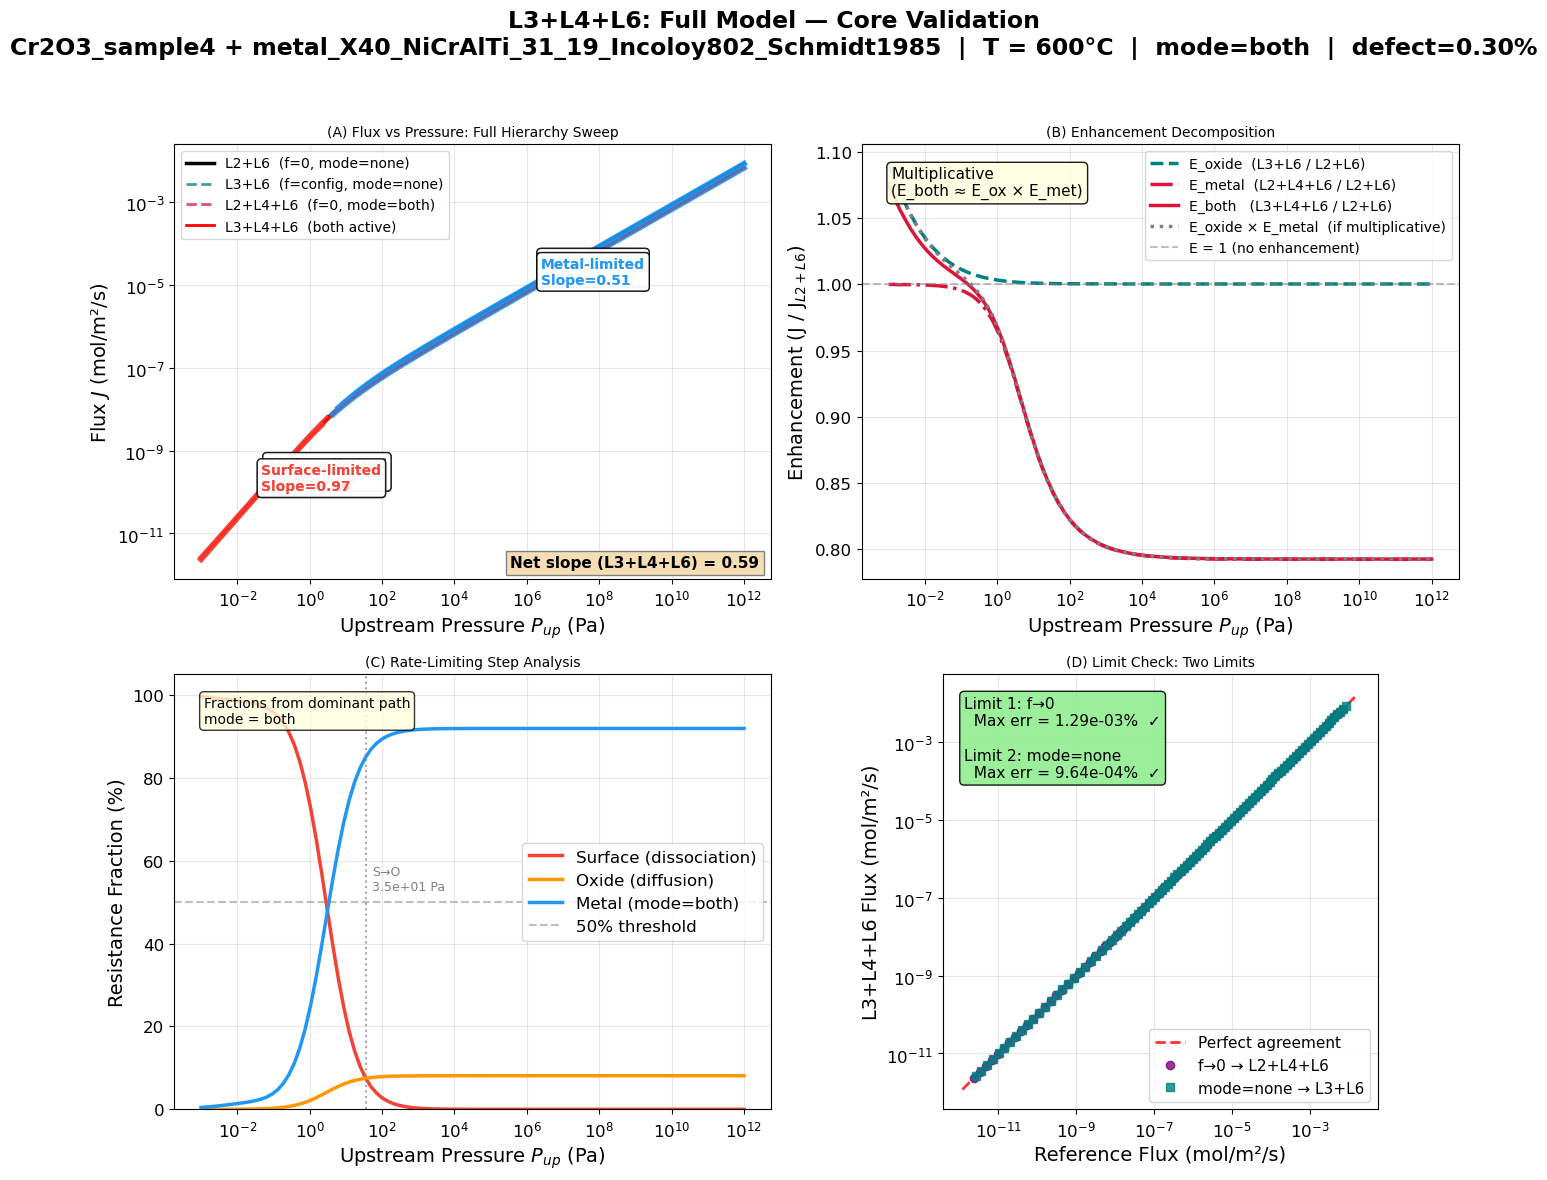


L3+L4+L6 FIGURE 1 — VALIDATION SUMMARY
  Net log-log slope (L3+L4+L6): 0.5884
  D_eff_avg/D_m at T_op:  0.0000
  Enhancement range:  1.000 – 1.076

  Limit check 1 (f→0 → L2+L4+L6): max err = 1.29e-03%  ✓
  Limit check 2 (mode=none → L3+L6): max err = 9.64e-04%  ✓


In [37]:
# =============================================================================
# CELL 4 — FIGURE 1: Core Validation (2×2)
# =============================================================================
"""
Figure 1 validates the L3+L4+L6 model from four angles at operating
temperature. The key question is whether oxide defects and metal
microstructure act additively, multiplicatively, or whether one dominates.

Panel (A) — Flux vs Pressure: Full Hierarchy Sweep
    Question: How does each level of physical complexity shift the flux
    curve, and what is the combined effect of defective oxide + defective
    metal + surface kinetics?
    Five curves in order of complexity:
      - L2+L6      (f=0, mode=none)  — black solid — pure series resistance
      - L3+L6      (f=config, mode=none) — oxide defects only
      - L2+L4+L6   (f=0, mode=config)   — metal microstructure only
      - L3+L4+L6   (f=config, mode=config) — both active (config run)
    Each curve has colored regime overlays and slope annotation boxes
    using the identical pattern from all previous levels. The separation
    between L3+L6 and L2+L4+L6 curves shows which effect dominates at
    each pressure.

Panel (B) — Enhancement Decomposition vs Pressure
    Question: Are the effects of oxide defects and metal microstructure
    additive, multiplicative, or does one dominate?
    Plots three enhancement ratios vs pressure on a semilogy scale:
      - E_oxide  = J_L3+L6(f=config, mode=none) / J_L2+L6
      - E_metal  = J_L2+L4+L6(f=0, mode=config) / J_L2+L6
      - E_both   = J_L3+L4+L6 / J_L2+L6
    A horizontal line at E=1 marks no enhancement. If E_both ≈ E_oxide ×
    E_metal the effects multiply. If E_both ≈ max(E_oxide, E_metal) one
    dominates. The annotation box states which behaviour is observed.

Panel (C) — Resistance Fractions vs Pressure
    Consistent style with all previous levels. Uses flux_weighted_resistances
    from the dominant path. Note annotation states which path is dominant
    and flags when flux_weighted_resistances is None (mixed dominant path).

Panel (D) — Limit Check: two limits on one parity plot
    Question: Does L3+L4+L6 recover L2+L4+L6 when f→0, and recover
    L3+L6 when mode='none'?
    Two parity comparisons on the same axes:
      - Circles: J_L3+L4+L6(f→0) vs J_L2+L4+L6  (oxide defects off)
      - Squares: J_L3+L4+L6(mode=none) vs J_L3+L6 (metal microstructure off)
    Both should fall on the diagonal. Green annotation if both < 1%.
    Validates hierarchical consistency: L3+L4+L6 collapses to the
    correct sub-model when each physical effect is individually disabled.
"""

props = dict(boxstyle='round', facecolor='wheat', alpha=0.9)

fig, axes = plt.subplots(2, 2, figsize=STYLE['figsize'])
fig.suptitle(
    f'L3+L4+L6: Full Model — Core Validation\n'
    f'{OXIDE_KEY} + {METAL_KEY}  |  T = {T_op-273.15:.0f}°C  |  '
    f'mode={mode}  |  defect={sum(v["area_fraction"] for v in defect_config.values())*100:.2f}%',
    fontsize=STYLE['fontsize_suptitle']-1, fontweight='bold', y=0.98
)

# ── Regime overlay helper ─────────────────────────────────────────────────────
def plot_regime_overlay(ax, P_arr, J_arr, frac_s, frac_o, frac_m, valid_mask):
    rl = np.where(frac_s > 0.5, 'surface',
         np.where(frac_o > 0.5, 'oxide',
         np.where(frac_m > 0.5, 'metal', 'mixed')))

    region_styles = [
        ('surface', CURVE_STYLES['surface_region']['color'], 'Surface-limited'),
        ('oxide',   CURVE_STYLES['oxide_region']['color'],   'Oxide-limited'),
        ('metal',   CURVE_STYLES['metal_region']['color'],   'Metal-limited'),
        ('mixed',   CURVE_STYLES['mixed_region']['color'],   'Mixed'),
    ]

    for regime, color, lbl in region_styles:
        mask = (rl == regime) & valid_mask
        if not np.any(mask):
            continue
        idxs = np.where(mask)[0]
        for _, g in groupby(enumerate(idxs), lambda x: x[0] - x[1]):
            group = list(map(itemgetter(1), g))
            if len(group) < 3:
                continue
            P_seg = P_arr[group]
            J_seg = J_arr[group]
            ax.loglog(P_seg, J_seg, color=color, lw=4, alpha=0.7)
            slope_seg, *_ = stats.linregress(
                np.log10(P_seg), np.log10(np.abs(J_seg))
            )
            mid = len(group) // 2
            ax.text(
                P_seg[mid], J_seg[mid],
                f'{lbl}\nSlope={slope_seg:.2f}',
                color=color, fontsize=STYLE['fontsize_annotation']-1,
                fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
            )

# ─────────────────────────────────────────────────────────────────────────────
# (A) FLUX vs PRESSURE — full hierarchy sweep
# ─────────────────────────────────────────────────────────────────────────────
ax1 = axes[0, 0]
P_A = np.logspace(-3, 12, 100)

# Build zero-defect config for f=0 cases
dc_zero = {
    path: {**cfg, 'area_fraction': f_limit_check}
    for path, cfg in defect_config.items()
}

hierarchy_cases = [
    # (label, solver_fn, kwargs, color, ls)
    (
        'L2+L6  (f=0, mode=none)',
        'L2L6', None, 'black', '-',
    ),
    (
        'L3+L6  (f=config, mode=none)',
        'L3L6', None,
        CURVE_STYLES['L3_L6']['color'],
        CURVE_STYLES['L3_L6']['ls'],
    ),
    (
        f'L2+L4+L6  (f=0, mode={mode})',
        'L2L4L6', None,
        CURVE_STYLES['L4_both']['color'],
        '--',
    ),
    (
        f'L3+L4+L6  (both active)',
        'L3L4L6', None,
        CURVE_STYLES['L3_L4_L6']['color'] if 'L3_L4_L6' in CURVE_STYLES
        else 'crimson',
        '-',
    ),
]

# Storage for enhancement computation in panel B
J_curves = {}

for label, solver_key, _, color, ls in hierarchy_cases:
    J_h  = np.full(len(P_A), np.nan)
    fs_h = np.full(len(P_A), np.nan)
    fo_h = np.full(len(P_A), np.nan)
    fm_h = np.full(len(P_A), np.nan)

    for i, P_up in enumerate(P_A):
        try:
            if solver_key == 'L2L6':
                r = solve_steady_state_flux_direct(
                    P_up, P_down, L_m,
                    k_diss, K_eq, D_ox, K_ox, L_ox, D_m, K_s_m
                )
                J_h[i]  = r['J_ss']
                fs_h[i] = r['resistances']['fraction_surface']
                fo_h[i] = r['resistances']['fraction_oxide']
                fm_h[i] = r['resistances']['fraction_metal']

            elif solver_key == 'L3L6':
                r = calculate_mixed_defect_flux_L6(
                    P_up, P_down, L_m,
                    k_diss, K_eq, D_ox, K_ox, L_ox, D_m, K_s_m,
                    defect_config,
                    k_diss_metal=k_diss_metal_arg,
                    K_eq_metal=K_eq_metal_arg,
                )
                J_h[i] = r['J_total']
                dom = r.get('dominant_path', 'intact')
                if dom == 'intact':
                    res = r['intact_path']['resistances']
                elif dom in r.get('defect_paths', {}):
                    res = r['defect_paths'][dom]['path_result']['resistances']
                else:
                    res = r['intact_path']['resistances']
                fs_h[i] = res.get('fraction_surface', np.nan)
                fo_h[i] = res.get('fraction_oxide',   np.nan)
                fm_h[i] = res.get('fraction_metal',   np.nan)

            elif solver_key == 'L2L4L6':
                r = calculate_defective_metal_flux_L6(
                    P_up, P_down, L_m, T_op,
                    k_diss, K_eq, D_ox, K_ox, L_ox, D_m, K_s_m,
                    microstructure_params=microstructure,
                    mode=mode,
                )
                J_h[i]  = r['flux']
                fs_h[i] = r['resistances']['fraction_surface']
                fo_h[i] = r['resistances']['fraction_oxide']
                fm_h[i] = r['resistances']['fraction_metal']

            elif solver_key == 'L3L4L6':
                r = calculate_full_model_flux_L346_v2(
                    P_up, P_down, L_m, T_op,
                    k_diss, K_eq, D_ox, K_ox, L_ox, D_m, K_s_m,
                    microstructure, defect_config,
                    k_diss_metal=k_diss_metal_arg,
                    K_eq_metal=K_eq_metal_arg,
                    mode=mode,
                )
                J_h[i] = r['J_total']
                res = r.get('flux_weighted_resistances')
                if res is not None:
                    fs_h[i] = res['fraction_surface']
                    fo_h[i] = res['fraction_oxide']
                    fm_h[i] = res['fraction_metal']

        except Exception:
            pass

    J_curves[solver_key] = J_h.copy()

    v_h = ~np.isnan(J_h) & (J_h > 0)
    if not np.any(v_h):
        print(f"  ⚠  {label}: no valid points")
        continue

    lw = STYLE['linewidth'] if solver_key == 'L2L6' else STYLE['linewidth'] - 0.5
    ax1.loglog(
        P_A[v_h], J_h[v_h],
        color=color, ls=ls, lw=lw,
        alpha=1.0 if solver_key in ('L2L6', 'L3L4L6') else 0.75,
        label=label
    )
    plot_regime_overlay(ax1, P_A, J_h, fs_h, fo_h, fm_h, v_h)

# Net slope
v_net = ~np.isnan(J_arr) & (J_arr > 0)
if np.sum(v_net) > 2:
    slope_net, *_ = stats.linregress(
        np.log10(P_RANGE_ARR[v_net]), np.log10(np.abs(J_arr[v_net]))
    )
    ax1.text(
        0.98, 0.02, f'Net slope (L3+L4+L6) = {slope_net:.2f}',
        transform=ax1.transAxes, ha='right', va='bottom',
        fontsize=STYLE['fontsize_annotation'], fontweight='bold',
        bbox=dict(boxstyle='square', fc='wheat', ec='gray', alpha=1)
    )

ax1.set_xlabel('Upstream Pressure $P_{up}$ (Pa)',         fontsize=STYLE['fontsize_axis'])
ax1.set_ylabel('Flux $J$ (mol/m²/s)',                      fontsize=STYLE['fontsize_axis'])
ax1.set_title('(A) Flux vs Pressure: Full Hierarchy Sweep', fontsize=STYLE['fontsize_title'])
ax1.legend(fontsize=STYLE['fontsize_legend']-2, loc='upper left')
ax1.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax1.tick_params(labelsize=STYLE['fontsize_tick'])

# ─────────────────────────────────────────────────────────────────────────────
# (B) ENHANCEMENT DECOMPOSITION vs PRESSURE
# ─────────────────────────────────────────────────────────────────────────────
ax2 = axes[0, 1]

J_L2L6   = J_curves.get('L2L6',   np.full(len(P_A), np.nan))
J_L3L6   = J_curves.get('L3L6',   np.full(len(P_A), np.nan))
J_L2L4L6 = J_curves.get('L2L4L6', np.full(len(P_A), np.nan))
J_L3L4L6 = J_curves.get('L3L4L6', np.full(len(P_A), np.nan))

v_enh = (J_L2L6 > 0) & ~np.isnan(J_L2L6)

E_oxide = np.full(len(P_A), np.nan)
E_metal = np.full(len(P_A), np.nan)
E_both  = np.full(len(P_A), np.nan)
E_prod  = np.full(len(P_A), np.nan)

E_oxide[v_enh] = J_L3L6[v_enh]   / J_L2L6[v_enh]
E_metal[v_enh] = J_L2L4L6[v_enh] / J_L2L6[v_enh]
E_both[v_enh]  = J_L3L4L6[v_enh] / J_L2L6[v_enh]
E_prod[v_enh]  = E_oxide[v_enh] * E_metal[v_enh]

for arr, color, ls, label in [
    (E_oxide, CURVE_STYLES['L3_L6']['color'],   '--', 'E_oxide  (L3+L6 / L2+L6)'),
    (E_metal, CURVE_STYLES['L4_both']['color'], '-.', 'E_metal  (L2+L4+L6 / L2+L6)'),
    (E_both,  'crimson',                         '-',  'E_both   (L3+L4+L6 / L2+L6)'),
    (E_prod,  'gray',                            ':',  'E_oxide × E_metal  (if multiplicative)'),
]:
    v_a = ~np.isnan(arr) & (arr > 0)
    if not np.any(v_a):
        continue
    ax2.semilogx(P_A[v_a], arr[v_a], color=color, ls=ls,
                 lw=STYLE['linewidth'], label=label)

ax2.axhline(1.0, color='gray', ls='--', lw=1.5, alpha=0.5, label='E = 1 (no enhancement)')

# Annotation: additive vs multiplicative
v_mid = v_enh & ~np.isnan(E_both) & ~np.isnan(E_prod)
if np.any(v_mid):
    ratio = np.nanmedian(E_both[v_mid] / E_prod[v_mid])
    if ratio > 0.8:
        behaviour = 'Multiplicative\n(E_both ≈ E_ox × E_met)'
    elif np.nanmedian(E_both[v_mid]) > np.nanmedian(np.maximum(E_oxide[v_mid], E_metal[v_mid])):
        behaviour = 'Super-multiplicative'
    else:
        behaviour = 'Sub-multiplicative\n(one effect dominates)'
    ax2.text(
        0.05, 0.95, behaviour,
        transform=ax2.transAxes, fontsize=STYLE['fontsize_annotation'],
        va='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9)
    )

ax2.set_xlabel('Upstream Pressure $P_{up}$ (Pa)', fontsize=STYLE['fontsize_axis'])
ax2.set_ylabel('Enhancement (J / J$_{L2+L6}$)',   fontsize=STYLE['fontsize_axis'])
ax2.set_title('(B) Enhancement Decomposition',     fontsize=STYLE['fontsize_title'])
ax2.legend(fontsize=STYLE['fontsize_legend']-2, loc='upper right')
ax2.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax2.tick_params(labelsize=STYLE['fontsize_tick'])

# ─────────────────────────────────────────────────────────────────────────────
# (C) RESISTANCE FRACTIONS vs PRESSURE
# ─────────────────────────────────────────────────────────────────────────────
ax3 = axes[1, 0]

ax3.semilogx(
    P_RANGE_ARR[res_valid], frac_surface_arr[res_valid] * 100,
    color=CURVE_STYLES['surface_region']['color'],
    lw=STYLE['linewidth'], label='Surface (dissociation)'
)
ax3.semilogx(
    P_RANGE_ARR[res_valid], frac_oxide_arr[res_valid] * 100,
    color=CURVE_STYLES['oxide_region']['color'],
    lw=STYLE['linewidth'], label='Oxide (diffusion)'
)
ax3.semilogx(
    P_RANGE_ARR[res_valid], frac_metal_arr[res_valid] * 100,
    color=CURVE_STYLES['metal_region']['color'],
    lw=STYLE['linewidth'], label=f'Metal (mode={mode})'
)
ax3.axhline(
    50,
    color=CURVE_STYLES['threshold']['color'],
    ls=CURVE_STYLES['threshold']['ls'],
    lw=CURVE_STYLES['threshold']['lw'],
    alpha=CURVE_STYLES['threshold']['alpha'],
    label='50% threshold'
)

n_mixed_dom = np.sum(dominant_path_arr == 'mixed')
frac_missing = np.sum(valid) - np.sum(res_valid)

if P_cross_surf_oxide is not None:
    ax3.axvline(P_cross_surf_oxide, color='gray', ls=':', lw=1.5, alpha=0.7)
    ax3.text(
        P_cross_surf_oxide * 1.5, 53,
        f'S→O\n{P_cross_surf_oxide:.1e} Pa',
        fontsize=STYLE['fontsize_annotation']-2, color='gray'
    )
if P_cross_oxide_metal is not None:
    ax3.axvline(P_cross_oxide_metal, color='gray', ls=':', lw=1.5, alpha=0.7)
    ax3.text(
        P_cross_oxide_metal * 1.5, 53,
        f'O→M\n{P_cross_oxide_metal:.1e} Pa',
        fontsize=STYLE['fontsize_annotation']-2, color='gray'
    )

annot_c = f'Fractions from dominant path\nmode = {mode}'
if frac_missing > 0:
    annot_c += f'\n{frac_missing} pts: dominant=mixed\n(flux_weighted_resistances=None)'
ax3.text(
    0.05, 0.95, annot_c,
    transform=ax3.transAxes,
    fontsize=STYLE['fontsize_annotation']-1, va='top',
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8)
)

ax3.set_xlabel('Upstream Pressure $P_{up}$ (Pa)', fontsize=STYLE['fontsize_axis'])
ax3.set_ylabel('Resistance Fraction (%)',          fontsize=STYLE['fontsize_axis'])
ax3.set_title('(C) Rate-Limiting Step Analysis',   fontsize=STYLE['fontsize_title'])
ax3.set_ylim(0, 105)
ax3.legend(fontsize=STYLE['fontsize_legend'], loc='center right')
ax3.grid(True, alpha=STYLE['grid_alpha'])
ax3.tick_params(labelsize=STYLE['fontsize_tick'])

# ─────────────────────────────────────────────────────────────────────────────
# (D) LIMIT CHECK — two limits on one parity plot
# ─────────────────────────────────────────────────────────────────────────────
ax4 = axes[1, 1]

P_D         = np.logspace(-3, 12, 100)

# Limit 1: f→0 should recover L2+L4+L6
J_f0        = np.full(len(P_D), np.nan)   # L3+L4+L6 with f→0
J_L2L4L6_D  = np.full(len(P_D), np.nan)  # L2+L4+L6 reference

# Limit 2: mode='none' should recover L3+L6
J_mnone     = np.full(len(P_D), np.nan)  # L3+L4+L6 with mode=none
J_L3L6_D    = np.full(len(P_D), np.nan)  # L3+L6 reference

for i, P_up in enumerate(P_D):
    try:
        r = calculate_full_model_flux_L346_v2(
            P_up, P_down, L_m, T_op,
            k_diss, K_eq, D_ox, K_ox, L_ox, D_m, K_s_m,
            microstructure, dc_zero,
            k_diss_metal=k_diss_metal_arg,
            K_eq_metal=K_eq_metal_arg,
            mode=mode,
        )
        J_f0[i] = r['J_total']
    except Exception:
        pass

    try:
        r = calculate_defective_metal_flux_L6(
            P_up, P_down, L_m, T_op,
            k_diss, K_eq, D_ox, K_ox, L_ox, D_m, K_s_m,
            microstructure_params=microstructure,
            mode=mode,
        )
        J_L2L4L6_D[i] = r['flux']
    except Exception:
        pass

    try:
        r = calculate_full_model_flux_L346_v2(
            P_up, P_down, L_m, T_op,
            k_diss, K_eq, D_ox, K_ox, L_ox, D_m, K_s_m,
            microstructure, defect_config,
            k_diss_metal=k_diss_metal_arg,
            K_eq_metal=K_eq_metal_arg,
            mode='none',
        )
        J_mnone[i] = r['J_total']
    except Exception:
        pass

    try:
        r = calculate_mixed_defect_flux_L6(
            P_up, P_down, L_m,
            k_diss, K_eq, D_ox, K_ox, L_ox, D_m, K_s_m,
            defect_config,
            k_diss_metal=k_diss_metal_arg,
            K_eq_metal=K_eq_metal_arg,
        )
        J_L3L6_D[i] = r['J_total']
    except Exception:
        pass

# Parity plot — limit 1: circles
vp1 = (~np.isnan(J_f0) & ~np.isnan(J_L2L4L6_D) &
       (J_f0 > 0) & (J_L2L4L6_D > 0))
# Parity plot — limit 2: squares
vp2 = (~np.isnan(J_mnone) & ~np.isnan(J_L3L6_D) &
       (J_mnone > 0) & (J_L3L6_D > 0))

all_J = []
if np.any(vp1):
    all_J += [J_L2L4L6_D[vp1].min(), J_f0[vp1].min(),
              J_L2L4L6_D[vp1].max(), J_f0[vp1].max()]
if np.any(vp2):
    all_J += [J_L3L6_D[vp2].min(), J_mnone[vp2].min(),
              J_L3L6_D[vp2].max(), J_mnone[vp2].max()]

if all_J:
    J_min_p = min(all_J) * 0.5
    J_max_p = max(all_J) * 2.0
    ax4.loglog(
        [J_min_p, J_max_p], [J_min_p, J_max_p],
        color=CURVE_STYLES['parity']['color'],
        ls=CURVE_STYLES['parity']['ls'],
        lw=CURVE_STYLES['parity']['lw'],
        alpha=CURVE_STYLES['parity']['alpha'],
        label='Perfect agreement'
    )

max_err1 = max_err2 = np.nan

if np.any(vp1):
    ax4.loglog(
        J_L2L4L6_D[vp1], J_f0[vp1],
        'o', color=CURVE_STYLES['L2_L6']['color'],
        markersize=6, alpha=0.8,
        label=f'f→0 → L2+L4+L6'
    )
    err1 = np.abs(J_f0[vp1] - J_L2L4L6_D[vp1]) / J_L2L4L6_D[vp1] * 100
    max_err1 = err1.max()

if np.any(vp2):
    ax4.loglog(
        J_L3L6_D[vp2], J_mnone[vp2],
        's', color=CURVE_STYLES['L3_L6']['color'],
        markersize=6, alpha=0.8,
        label=f'mode=none → L3+L6'
    )
    err2 = np.abs(J_mnone[vp2] - J_L3L6_D[vp2]) / J_L3L6_D[vp2] * 100
    max_err2 = err2.max()

ok1 = not np.isnan(max_err1) and max_err1 < 1.0
ok2 = not np.isnan(max_err2) and max_err2 < 1.0
box_color = 'lightgreen' if (ok1 and ok2) else 'lightyellow'

annot_d = (
    f'Limit 1: f→0\n'
    f'  Max err = {max_err1:.2e}%  {"✓" if ok1 else "⚠"}\n\n'
    f'Limit 2: mode=none\n'
    f'  Max err = {max_err2:.2e}%  {"✓" if ok2 else "⚠"}'
)
ax4.text(
    0.05, 0.95, annot_d,
    transform=ax4.transAxes, fontsize=STYLE['fontsize_annotation'],
    va='top',
    bbox=dict(boxstyle='round', facecolor=box_color, alpha=0.9)
)

ax4.set_xlabel('Reference Flux (mol/m²/s)',   fontsize=STYLE['fontsize_axis'])
ax4.set_ylabel('L3+L4+L6 Flux (mol/m²/s)',   fontsize=STYLE['fontsize_axis'])
ax4.set_title('(D) Limit Check: Two Limits',  fontsize=STYLE['fontsize_title'])
ax4.set_aspect('equal', adjustable='box')
ax4.legend(fontsize=STYLE['fontsize_legend']-1, loc='lower right')
ax4.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax4.tick_params(labelsize=STYLE['fontsize_tick'])

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print("\n" + "=" * 60)
print("L3+L4+L6 FIGURE 1 — VALIDATION SUMMARY")
print("=" * 60)
if np.sum(v_net) > 2:
    print(f"  Net log-log slope (L3+L4+L6): {slope_net:.4f}")
print(f"  D_eff_avg/D_m at T_op:  "
      f"{np.nanmean(D_eff_avg_arr[valid]):.4f}")
print(f"  Enhancement range:  "
      f"{np.nanmin(enhancement_arr[valid]):.3f} – "
      f"{np.nanmax(enhancement_arr[valid]):.3f}")
print(f"\n  Limit check 1 (f→0 → L2+L4+L6): max err = {max_err1:.2e}%  "
      f"{'✓' if ok1 else '⚠'}")
print(f"  Limit check 2 (mode=none → L3+L6): max err = {max_err2:.2e}%  "
      f"{'✓' if ok2 else '⚠'}")
print("=" * 60)

/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:613: UserWarning: Temperature 623.0 K is far outside data range [873.1, 1273.2] K. Clamping to nearest data limit for interpolation.
  warnings.warn(
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:613: UserWarning: Temperature 653.4 K is far outside data range [873.1, 1273.2] K. Clamping to nearest data limit for interpolation.
  warnings.warn(
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:621: UserWarning: Temperature 683.7 K is outside data range [873.1, 1273.2] K. Extrapolation may be inaccurate.
  warnings.warn(f"Temperature {T_kelvin:.1f} K is outside data range "
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:621: UserWarning: Temperature 714.1 K is outside data range [873.1, 1273.2] K. Extrapolat

  ⚠  oxide: P_for_oxide_Ea is None — fit skipped


/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:2006: UserWarning: GB enhancement (1.27×) and trapping (0.77×) nearly cancel. Small parameter changes could significantly affect results.
  warnings.warn(msg)
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:2006: UserWarning: GB enhancement (1.12×) and trapping (0.77×) nearly cancel. Small parameter changes could significantly affect results.
  warnings.warn(msg)
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:2006: UserWarning: GB enhancement (1.05×) and trapping (0.77×) nearly cancel. Small parameter changes could significantly affect results.
  warnings.warn(msg)
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:613: UserWarning: Temperature 623.0 K is far outside data range [873.1, 1273.2] K. Clamping to 

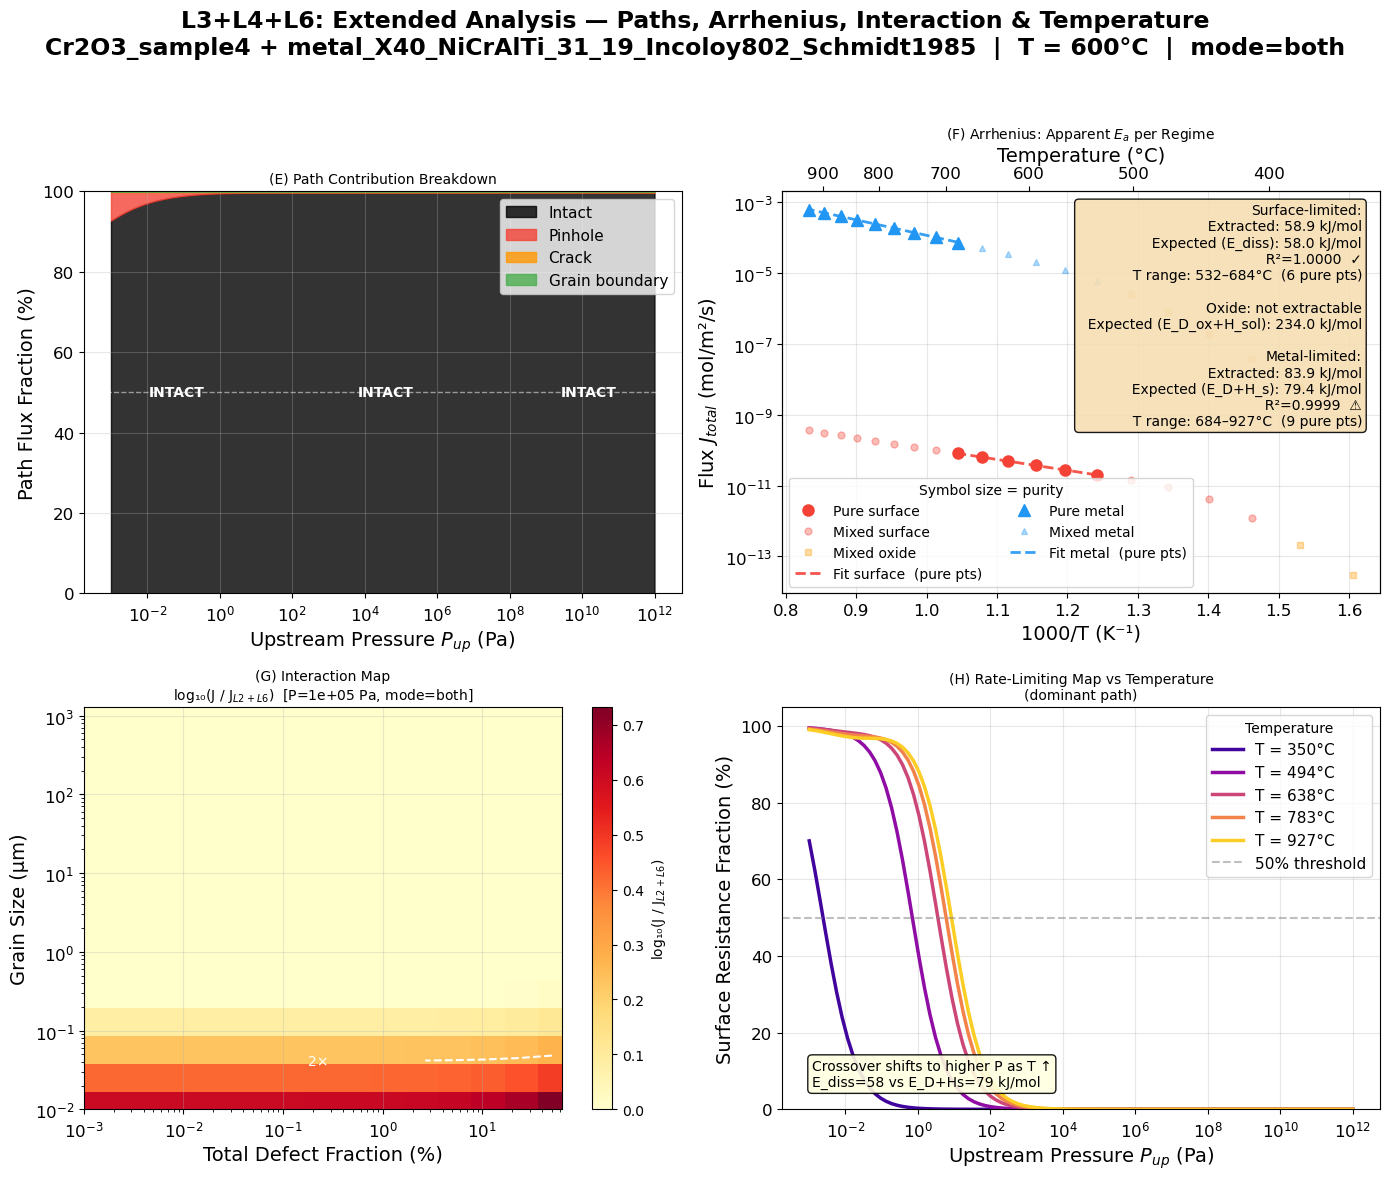


L3+L4+L6 FIGURE 2 — SUMMARY
  mode = both

  Arrhenius results:
    Surface: extracted=58.9  expected=58.0 kJ/mol  shift=+0.9 kJ/mol  (✓)  6 pure pts
    Oxide: not extractable
    Metal: extracted=83.9  expected=79.4 kJ/mol  shift=+4.5 kJ/mol  (⚠)  9 pure pts

  Crossover pressures across T sweep:
    T = 350°C  →  P_crossover = 2.01e-03 Pa
    T = 494°C  →  P_crossover = 5.34e-01 Pa
    T = 638°C  →  P_crossover = 3.05e+00 Pa
    T = 783°C  →  P_crossover = 4.33e+00 Pa
    T = 927°C  →  P_crossover = 6.14e+00 Pa


In [38]:
# =============================================================================
# CELL 5 — FIGURE 2: Extended Analysis (2×2)
# =============================================================================
"""
Figure 2 examines path contributions, activation energies, the combined
enhancement landscape, and temperature effects.

Panel (E) — Path Contribution Breakdown
    Question: Which oxide path carries the most flux, and how does the
    metal microstructure (D_eff) differ between intact and defect paths?
    Stacked area — intact / pinhole / crack / grain_boundary flux
    fractions (%) vs pressure. Same consistent style as L3+L6 panel (E).
    The intact→defect crossover is annotated if present.

Panel (F) — Arrhenius: apparent Ea per regime, classified by purity
    Question: Does the combined model extract the correct activation
    energies, and how does the shift from L2+L4+L6 or L3+L6 compare?
    Same five-category classification. Uses flux_weighted_resistances from
    dominant path at each T. Skips T points where flux_weighted_resistances
    is None (dominant='mixed'). Dual x-axis. Annotation box shows
    extracted vs expected Ea and T range.

Panel (G) — Interaction Map: defect fraction vs grain size
    Question: In the combined parameter space, where does each physical
    effect dominate, and is there a synergy regime?
    2D heatmap — x: defect fraction (%), y: grain size (μm),
    colour: log10(J_L3+L4+L6 / J_L2+L6). Shows how the combined
    enhancement depends on the two structural parameters simultaneously.
    Contours at 2× and 10× enhancement annotated.

Panel (H) — Rate-Limiting Map vs Temperature
    Consistent style. Surface fraction vs pressure at 5 temperatures
    using plasma colormap. Uses flux_weighted_resistances when not None,
    skips otherwise.
"""

fig2, axes2 = plt.subplots(2, 2, figsize=STYLE['figsize'])
fig2.suptitle(
    f'L3+L4+L6: Extended Analysis — Paths, Arrhenius, Interaction & Temperature\n'
    f'{OXIDE_KEY} + {METAL_KEY}  |  T = {T_op-273.15:.0f}°C  |  mode={mode}',
    fontsize=STYLE['fontsize_suptitle']-1, fontweight='bold', y=0.98
)

# ─────────────────────────────────────────────────────────────────────────────
# (E) PATH CONTRIBUTION BREAKDOWN
# ─────────────────────────────────────────────────────────────────────────────
ax_E = axes2[0, 0]

v_E = valid & ~np.isnan(frac_intact_arr)
Pv  = P_RANGE_ARR[v_E]

fi = frac_intact_arr[v_E]  * 100
fp = frac_pinhole_arr[v_E] * 100
fc = frac_crack_arr[v_E]   * 100
fg = frac_gb_arr[v_E]      * 100

fracs_to_plot = []
if np.any(fi > 0):
    fracs_to_plot.append(('intact',
                          CURVE_STYLES['intact']['color'],   fi,  'Intact'))
if 'pinhole' in defect_config and np.any(fp > 0):
    fracs_to_plot.append(('pinhole',
                          CURVE_STYLES['pinhole']['color'],  fp,  'Pinhole'))
if 'crack' in defect_config and np.any(fc > 0):
    fracs_to_plot.append(('crack',
                          CURVE_STYLES['crack']['color'],    fc,  'Crack'))
if 'grain_boundary' in defect_config and np.any(fg > 0):
    fracs_to_plot.append(('grain_boundary',
                          CURVE_STYLES['gb']['color'],       fg,  'Grain boundary'))

bottom = np.zeros(len(Pv))
for _, color, frac_arr, lbl in fracs_to_plot:
    ax_E.fill_between(Pv, bottom, bottom + frac_arr,
                      color=color, alpha=0.8, label=lbl)
    bottom += frac_arr

ax_E.set_xscale('log')
ax_E.set_ylim(0, 100)
ax_E.axhline(50, color='white', ls='--', lw=1.0, alpha=0.5)

for P_annot in [Pv[len(Pv)//8], Pv[len(Pv)//2], Pv[7*len(Pv)//8]]:
    idx = np.argmin(np.abs(Pv - P_annot))
    dom_lbl = dominant_path_arr[v_E][idx]
    ax_E.text(
        P_annot, 50, dom_lbl.replace('_', '\n').upper(),
        ha='center', va='center',
        fontsize=STYLE['fontsize_annotation']-1,
        color='white', fontweight='bold'
    )

intact_frac = frac_intact_arr[valid]
P_valid     = P_RANGE_ARR[valid]
cross_idx   = np.where(np.diff(np.sign(intact_frac - 0.5)))[0]
if len(cross_idx) > 0:
    P_co_E = P_valid[cross_idx[0]]
    ax_E.axvline(P_co_E, color='white', ls=':', lw=2.0, alpha=0.8)
    ax_E.text(
        P_co_E, 95, f'Intact→Defect\n{P_co_E:.1e} Pa',
        ha='center', va='top',
        fontsize=STYLE['fontsize_annotation']-2,
        color='white', fontweight='bold'
    )

ax_E.set_xlabel('Upstream Pressure $P_{up}$ (Pa)', fontsize=STYLE['fontsize_axis'])
ax_E.set_ylabel('Path Flux Fraction (%)',           fontsize=STYLE['fontsize_axis'])
ax_E.set_title('(E) Path Contribution Breakdown',   fontsize=STYLE['fontsize_title'])
ax_E.legend(fontsize=STYLE['fontsize_legend']-1, loc='upper right')
ax_E.grid(True, alpha=STYLE['grid_alpha'])
ax_E.tick_params(labelsize=STYLE['fontsize_tick'])

# ─────────────────────────────────────────────────────────────────────────────
# (F) ARRHENIUS — classified by purity
# ─────────────────────────────────────────────────────────────────────────────
ax_F = axes2[0, 1]

temperatures_K = np.linspace(T_RANGE[0], T_RANGE[1], N_T)
inv_T          = 1000.0 / temperatures_K

def classify_regime(fs, fo, fm, pure_thresh=0.98, mixed_thresh=0.50):
    if fs >= pure_thresh:    return 'pure_surface'
    elif fo >= pure_thresh:  return 'pure_oxide'
    elif fm >= pure_thresh:  return 'pure_metal'
    elif fs >= mixed_thresh: return 'mixed_surface'
    elif fo >= mixed_thresh: return 'mixed_oxide'
    elif fm >= mixed_thresh: return 'mixed_metal'
    else:                    return 'mixed'

regime_class_styles = {
    'pure_surface':  {'color': CURVE_STYLES['surface_region']['color'],
                      'marker': 'o', 'ms': 8,  'alpha': 1.0},
    'mixed_surface': {'color': CURVE_STYLES['surface_region']['color'],
                      'marker': 'o', 'ms': 5,  'alpha': 0.35},
    'pure_oxide':    {'color': CURVE_STYLES['oxide_region']['color'],
                      'marker': 's', 'ms': 8,  'alpha': 1.0},
    'mixed_oxide':   {'color': CURVE_STYLES['oxide_region']['color'],
                      'marker': 's', 'ms': 5,  'alpha': 0.35},
    'pure_metal':    {'color': CURVE_STYLES['metal_region']['color'],
                      'marker': '^', 'ms': 8,  'alpha': 1.0},
    'mixed_metal':   {'color': CURVE_STYLES['metal_region']['color'],
                      'marker': '^', 'ms': 5,  'alpha': 0.35},
    'mixed':         {'color': CURVE_STYLES['mixed_region']['color'],
                      'marker': 'x', 'ms': 6,  'alpha': 0.5},
}

regime_Ea_cases    = [
    ('surface', P_for_surface_Ea, CURVE_STYLES['surface_region']['color']),
    ('oxide',   P_for_oxide_Ea,   CURVE_STYLES['oxide_region']['color']),
    ('metal',   P_for_metal_Ea,   CURVE_STYLES['metal_region']['color']),
]
arrhenius_results  = {}
plotted_cls_labels = set()

for label, P_fixed, color in regime_Ea_cases:
    if P_fixed is None:
        print(f"  ⚠  {label}: P_for_{label}_Ea is None — fit skipped")
        arrhenius_results[label] = None
        continue

    J_arr_T   = np.full(N_T, np.nan)
    class_arr = np.empty(N_T, dtype=object)

    for j, T_K in enumerate(temperatures_K):
        try:
            r = calculate_full_model_flux_L346_v2(
                P_fixed, P_down, L_m, T_K,
                get_k_diss_at_T(T_K), get_K_eq_at_T(T_K),
                get_D_ox_at_T(T_K),   get_K_ox_at_T(T_K), L_ox,
                get_D_m_at_T(T_K),    get_K_s_m_at_T(T_K),
                microstructure, defect_config,
                k_diss_metal=get_k_diss_metal_at_T(T_K) if not use_sieverts_pinhole else None,
                K_eq_metal=get_K_eq_metal_at_T(T_K)     if not use_sieverts_pinhole else None,
                mode=mode,
            )
            J_arr_T[j] = r['J_total']
            res = r.get('flux_weighted_resistances')
            if res is not None:
                class_arr[j] = classify_regime(
                    res['fraction_surface'],
                    res['fraction_oxide'],
                    res['fraction_metal']
                )
            else:
                class_arr[j] = 'mixed'
        except Exception:
            class_arr[j] = 'mixed'

    pure = (class_arr == f'pure_{label}') & ~np.isnan(J_arr_T) & (J_arr_T > 0)

    for cls, sty in regime_class_styles.items():
        mask = (class_arr == cls) & ~np.isnan(J_arr_T) & (J_arr_T > 0)
        if not np.any(mask):
            continue
        cls_label = cls.replace('_', ' ').capitalize()
        ax_F.semilogy(
            inv_T[mask], J_arr_T[mask],
            ls='none', color=sty['color'], marker=sty['marker'],
            ms=sty['ms'], alpha=sty['alpha'],
            label=cls_label if cls_label not in plotted_cls_labels
                  else '_nolegend_'
        )
        plotted_cls_labels.add(cls_label)

    if np.sum(pure) < 3:
        print(f"  ⚠  {label}: only {np.sum(pure)} pure T points — fit skipped")
        arrhenius_results[label] = None
        continue

    slope, intercept, r_val, *_ = stats.linregress(
        inv_T[pure], np.log(J_arr_T[pure])
    )
    E_a = -slope * R * 1000

    arrhenius_results[label] = {
        'J': J_arr_T, 'valid': pure,
        'slope': slope, 'intercept': intercept,
        'r_sq': r_val**2, 'E_a': E_a,
        'P_fixed': P_fixed, 'color': color,
        'n_pure': int(np.sum(pure)),
        'T_pure_range': (temperatures_K[pure].min() - 273.15,
                         temperatures_K[pure].max() - 273.15),
    }

    ax_F.semilogy(
        inv_T[pure],
        np.exp(slope * inv_T[pure] + intercept),
        color=color, ls='--', lw=2.0, alpha=0.9,
        label=f'Fit {label}  (pure pts)'
    )

ax_F_top = ax_F.twiny()
ax_F_top.set_xlim(ax_F.get_xlim())
T_ticks_C = np.array([200, 300, 400, 500, 600, 700, 800, 900])
T_ticks_K = T_ticks_C + 273.15
in_range  = (T_ticks_K >= T_RANGE[0]) & (T_ticks_K <= T_RANGE[1])
if np.any(in_range):
    ax_F_top.set_xticks(1000.0 / T_ticks_K[in_range])
    ax_F_top.set_xticklabels([f'{t}' for t in T_ticks_C[in_range]])
ax_F_top.set_xlabel('Temperature (°C)', fontsize=STYLE['fontsize_axis'])
ax_F_top.tick_params(labelsize=STYLE['fontsize_tick'])

E_refs    = {'surface': E_REF_SURFACE, 'oxide': E_REF_OXIDE, 'metal': E_REF_METAL}
ref_names = {'surface': 'E_diss', 'oxide': 'E_D_ox+H_sol', 'metal': 'E_D+H_s'}
annot     = []
for lbl in ('surface', 'oxide', 'metal'):
    res = arrhenius_results.get(lbl)
    E_r = E_refs[lbl]
    rn  = ref_names[lbl]
    if res is None:
        annot.append(f'{lbl.capitalize()}: not extractable')
        annot.append(f'  Expected ({rn}): {E_r/1000:.1f} kJ/mol')
    else:
        match = abs(res['E_a'] - E_r) < 3000
        annot.append(f'{lbl.capitalize()}-limited:')
        annot.append(f'  Extracted: {res["E_a"]/1000:.1f} kJ/mol')
        annot.append(f'  Expected ({rn}): {E_r/1000:.1f} kJ/mol')
        annot.append(f'  R²={res["r_sq"]:.4f}  {"✓" if match else "⚠"}')
        annot.append(f'  T range: {res["T_pure_range"][0]:.0f}–'
                     f'{res["T_pure_range"][1]:.0f}°C  '
                     f'({res["n_pure"]} pure pts)')
    annot.append('')

ax_F.text(
    0.97, 0.97, '\n'.join(annot).rstrip(),
    transform=ax_F.transAxes, fontsize=STYLE['fontsize_annotation']-1,
    va='top', ha='right',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9)
)
ax_F.set_xlabel('1000/T (K⁻¹)',              fontsize=STYLE['fontsize_axis'])
ax_F.set_ylabel('Flux $J_{total}$ (mol/m²/s)', fontsize=STYLE['fontsize_axis'])
ax_F.set_title('(F) Arrhenius: Apparent $E_a$ per Regime',
               fontsize=STYLE['fontsize_title'])
ax_F.legend(fontsize=STYLE['fontsize_legend']-2, loc='lower left',
            ncol=2, title='Symbol size = purity')
ax_F.grid(True, which='both', alpha=STYLE['grid_alpha'])
ax_F.tick_params(labelsize=STYLE['fontsize_tick'])

# ─────────────────────────────────────────────────────────────────────────────
# (G) INTERACTION MAP — defect fraction vs grain size
# ─────────────────────────────────────────────────────────────────────────────
ax_G = axes2[1, 0]

f_sweep_G  = np.logspace(
    np.log10(VAL_L3['f_defect_min']),
    np.log10(VAL_L3['f_defect_max']),
    15
)
gs_sweep_G = np.logspace(
    np.log10(VAL_L4['grain_size'].min()),
    np.log10(VAL_L4['grain_size'].max()),
    15
)
P_G = VAL_L4['P_fixed']

# L2+L6 reference at P_G
try:
    r_ref_G = solve_steady_state_flux_direct(
        P_G, P_down, L_m,
        k_diss, K_eq, D_ox, K_ox, L_ox, D_m, K_s_m
    )
    J_ref_G = r_ref_G['J_ss']
except Exception:
    J_ref_G = np.nan

enh_grid = np.full((len(gs_sweep_G), len(f_sweep_G)), np.nan)

if not np.isnan(J_ref_G) and J_ref_G > 0:
    base_total_G = sum(v['area_fraction'] for v in defect_config.values())
    for gi, gs in enumerate(gs_sweep_G):
        ms_g = {**microstructure, 'grain_size': gs}
        for fi_idx, f_tot in enumerate(f_sweep_G):
            if base_total_G > 0:
                scale_g  = f_tot / base_total_G
                dc_g     = {
                    path: {**cfg, 'area_fraction': cfg['area_fraction'] * scale_g}
                    for path, cfg in defect_config.items()
                }
            else:
                dc_g = defect_config

            try:
                r_g = calculate_full_model_flux_L346_v2(
                    P_G, P_down, L_m, T_op,
                    k_diss, K_eq, D_ox, K_ox, L_ox, D_m, K_s_m,
                    ms_g, dc_g,
                    k_diss_metal=k_diss_metal_arg,
                    K_eq_metal=K_eq_metal_arg,
                    mode=mode,
                )
                enh = r_g['J_total'] / J_ref_G
                enh_grid[gi, fi_idx] = np.log10(enh) if enh > 0 else np.nan
            except Exception:
                pass

F_mesh, GS_mesh = np.meshgrid(f_sweep_G * 100, gs_sweep_G * 1e6)
v_G = ~np.isnan(enh_grid)

if np.any(v_G):
    im = ax_G.pcolormesh(
        F_mesh, GS_mesh, enh_grid,
        cmap='YlOrRd', shading='auto',
        vmin=0, vmax=np.nanmax(enh_grid)
    )
    plt.colorbar(im, ax=ax_G, label='log₁₀(J / J$_{L2+L6}$)')

    for level, label in [(np.log10(2), '2×'), (np.log10(10), '10×')]:
        if np.nanmax(enh_grid) > level:
            try:
                cs = ax_G.contour(F_mesh, GS_mesh, enh_grid,
                                  levels=[level],
                                  colors='white', linewidths=1.5,
                                  linestyles='--')
                ax_G.clabel(cs, fmt=label, colors='white',
                            fontsize=STYLE['fontsize_annotation']-1)
            except Exception:
                pass

ax_G.set_xscale('log')
ax_G.set_yscale('log')
ax_G.set_xlabel('Total Defect Fraction (%)',    fontsize=STYLE['fontsize_axis'])
ax_G.set_ylabel('Grain Size (μm)',              fontsize=STYLE['fontsize_axis'])
ax_G.set_title(f'(G) Interaction Map\n'
               f'log₁₀(J / J$_{{L2+L6}}$)  [P={P_G:.0e} Pa, mode={mode}]',
               fontsize=STYLE['fontsize_title'])
ax_G.grid(True, alpha=STYLE['grid_alpha'])
ax_G.tick_params(labelsize=STYLE['fontsize_tick'])

# ─────────────────────────────────────────────────────────────────────────────
# (H) RATE-LIMITING MAP vs TEMPERATURE
# ─────────────────────────────────────────────────────────────────────────────
ax_H = axes2[1, 1]

T_map_values        = np.linspace(T_RANGE[0], T_RANGE[1], 5)
T_colors_map        = plt.cm.plasma(np.linspace(0.1, 0.9, len(T_map_values)))
crossover_pressures = []

P_H = np.logspace(-3, 12, 100)

for T_K, col in zip(T_map_values, T_colors_map):
    fs_row = np.full(len(P_H), np.nan)

    for i, P_up in enumerate(P_H):
        try:
            r = calculate_full_model_flux_L346_v2(
                P_up, P_down, L_m, T_K,
                get_k_diss_at_T(T_K), get_K_eq_at_T(T_K),
                get_D_ox_at_T(T_K),   get_K_ox_at_T(T_K), L_ox,
                get_D_m_at_T(T_K),    get_K_s_m_at_T(T_K),
                microstructure, defect_config,
                k_diss_metal=get_k_diss_metal_at_T(T_K) if not use_sieverts_pinhole else None,
                K_eq_metal=get_K_eq_metal_at_T(T_K)     if not use_sieverts_pinhole else None,
                mode=mode,
            )
            res = r.get('flux_weighted_resistances')
            if res is not None:
                fs_row[i] = res['fraction_surface'] * 100
        except Exception:
            pass

    valid_row = ~np.isnan(fs_row)
    if not np.any(valid_row):
        continue

    ax_H.semilogx(
        P_H[valid_row], fs_row[valid_row],
        color=col, lw=STYLE['linewidth'],
        label=f'T = {T_K-273.15:.0f}°C'
    )

    sc = np.where(np.diff(np.sign(fs_row[valid_row] - 50)))[0]
    if len(sc) > 0:
        idx  = sc[0]
        fs_v = fs_row[valid_row]
        if idx + 1 < len(fs_v) and fs_v[idx] > 50 and fs_v[idx+1] < 50:
            crossover_pressures.append((T_K, P_H[valid_row][idx]))

ax_H.axhline(
    50,
    color=CURVE_STYLES['threshold']['color'],
    ls=CURVE_STYLES['threshold']['ls'],
    lw=CURVE_STYLES['threshold']['lw'],
    alpha=CURVE_STYLES['threshold']['alpha'],
    label='50% threshold'
)

if len(crossover_pressures) >= 2:
    T_low,  P_co_low  = crossover_pressures[0]
    T_high, P_co_high = crossover_pressures[-1]
    direction = 'lower P as T ↑' if P_co_high < P_co_low else 'higher P as T ↑'
    ax_H.text(
        0.05, 0.05,
        f'Crossover shifts to {direction}\n'
        f'E_diss={E_REF_SURFACE/1000:.0f} vs '
        f'E_D+Hs={E_REF_METAL/1000:.0f} kJ/mol',
        transform=ax_H.transAxes,
        fontsize=STYLE['fontsize_annotation']-1, va='bottom',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9)
    )
elif len(crossover_pressures) == 0:
    dominant = 'surface-limited' if n_surface > n_oxide else 'oxide-limited'
    ax_H.text(
        0.05, 0.05,
        f'No crossover at any T\nSystem is {dominant}',
        transform=ax_H.transAxes,
        fontsize=STYLE['fontsize_annotation']-1, va='bottom',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9)
    )

ax_H.set_xlabel('Upstream Pressure $P_{up}$ (Pa)',  fontsize=STYLE['fontsize_axis'])
ax_H.set_ylabel('Surface Resistance Fraction (%)',  fontsize=STYLE['fontsize_axis'])
ax_H.set_title('(H) Rate-Limiting Map vs Temperature\n(dominant path)',
               fontsize=STYLE['fontsize_title'])
ax_H.set_ylim(0, 105)
ax_H.legend(fontsize=STYLE['fontsize_legend']-1, loc='upper right',
            title='Temperature')
ax_H.grid(True, alpha=STYLE['grid_alpha'])
ax_H.tick_params(labelsize=STYLE['fontsize_tick'])

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print("\n" + "=" * 60)
print("L3+L4+L6 FIGURE 2 — SUMMARY")
print("=" * 60)
print(f"  mode = {mode}")
print(f"\n  Arrhenius results:")
for lbl in ('surface', 'oxide', 'metal'):
    res = arrhenius_results.get(lbl)
    E_r = E_refs[lbl]
    if res is None:
        print(f"    {lbl.capitalize()}: not extractable")
    else:
        match = abs(res['E_a'] - E_r) < 3000
        shift = res['E_a'] - E_r
        print(f"    {lbl.capitalize()}: extracted={res['E_a']/1000:.1f}  "
              f"expected={E_r/1000:.1f} kJ/mol  "
              f"shift={shift/1000:+.1f} kJ/mol  "
              f"({'✓' if match else '⚠'})  "
              f"{res['n_pure']} pure pts")
if crossover_pressures:
    print(f"\n  Crossover pressures across T sweep:")
    for T_K, P_co in crossover_pressures:
        print(f"    T = {T_K-273.15:.0f}°C  →  P_crossover = {P_co:.2e} Pa")
print("=" * 60)

In [39]:
# =============================================================================
# CELL 6 — DATAFRAME OUTPUT
# =============================================================================
df = pd.DataFrame(rows)

df_display = df.copy()
for col in df_display.columns:
    if col in ('system_rate_limiting', 'dominant_path', 'mode', 'Error'):
        continue
    if df_display[col].dtype == float:
        if 'fraction' in col.lower() and 'frac_' in col.lower():
            df_display[col] = df_display[col].round(2)
        elif 'fraction' in col.lower():
            df_display[col] = df_display[col].round(2)
        elif 'D_eff' in col and '/D_m' in col:
            df_display[col] = df_display[col].round(6)
        elif 'enhancement' in col.lower():
            df_display[col] = df_display[col].round(4)
        else:
            df_display[col] = df_display[col].apply(
                lambda x: f'{x:.4e}' if pd.notna(x) else 'NaN'
            )

n_surface_df = (df['system_rate_limiting'] == 'SURFACE').sum()
n_oxide_df   = (df['system_rate_limiting'] == 'OXIDE').sum()
n_metal_df   = (df['system_rate_limiting'] == 'METAL').sum()
n_mixed_df   = (df['system_rate_limiting'] == 'MIXED').sum()
n_error_df   = (df['system_rate_limiting'] == 'ERROR').sum()

n_intact_df  = (df['dominant_path'] == 'intact').sum()
n_pin_df     = (df['dominant_path'] == 'pinhole').sum()
n_crack_df   = (df['dominant_path'] == 'crack').sum()
n_gb_df      = (df['dominant_path'] == 'grain_boundary').sum()
n_mixdom_df  = (df['dominant_path'] == 'mixed').sum()

print("=" * 60)
print("L3+L4+L6 RESULTS DATAFRAME")
print("=" * 60)
print(f"  Oxide:             {OXIDE_KEY}")
print(f"  Metal:             {METAL_KEY}")
print(f"  T:                 {T_op-273.15:.0f}°C  ({T_op} K)")
print(f"  L_ox:              {L_ox*1e6:.1f} μm")
print(f"  L_m:               {L_m*1e3:.1f} mm")
print(f"  mode:              {mode}")
print(f"  grain_size:        {grain_size*1e6:.1f} μm")
print(f"  k_diss:            {k_diss:.3e}  mol/m²/s/Pa")
print(f"  α_intact:          {alpha_intact:.3e}  mol/m²/s/Pa^0.5")
print(f"  β_eff:             {beta_eff:.3e}  mol/m²/s/Pa^0.5  (mode={mode})")
print(f"  D_eff/D_m:         {D_eff/D_m:.6f}")

print(f"\n  Defect configuration")
for path, cfg in defect_config.items():
    print(f"    {path:<16} f = {cfg['area_fraction']*100:.3f}%")

print(f"\n  Total rows:          {len(df)}")
print(f"\n  Resistance regime (dominant path):")
print(f"    Surface-limited:   {n_surface_df}")
print(f"    Oxide-limited:     {n_oxide_df}")
print(f"    Metal-limited:     {n_metal_df}")
print(f"    Mixed (res=None):  {n_mixed_df}")
if n_error_df > 0:
    print(f"    Errors:            {n_error_df}  ⚠")

print(f"\n  Dominant oxide path:")
print(f"    Intact:            {n_intact_df}")
print(f"    Pinhole:           {n_pin_df}")
print(f"    Crack:             {n_crack_df}")
print(f"    Grain boundary:    {n_gb_df}")
print(f"    Mixed (>1 path):   {n_mixdom_df}")

if 'enhancement_factor' in df.columns:
    enh_vals = df['enhancement_factor'].dropna()
    if len(enh_vals) > 0:
        print(f"\n  Enhancement (J_total / J_intact):")
        print(f"    Min  = {enh_vals.min():.4f}")
        print(f"    Max  = {enh_vals.max():.4f}")
        print(f"    Mean = {enh_vals.mean():.4f}")

if 'D_eff_avg/D_m' in df.columns:
    deff_vals = df['D_eff_avg/D_m'].dropna()
    if len(deff_vals) > 0:
        print(f"\n  D_eff_avg/D_m range:  "
              f"{deff_vals.min():.6f} → {deff_vals.max():.6f}")

print("=" * 60)

display(df_display)

L3+L4+L6 RESULTS DATAFRAME
  Oxide:             Cr2O3_sample4
  Metal:             metal_X40_NiCrAlTi_31_19_Incoloy802_Schmidt1985
  T:                 600°C  (873 K)
  L_ox:              0.0 μm
  L_m:               1.0 mm
  mode:              both
  grain_size:        100.0 μm
  k_diss:            2.370e-09  mol/m²/s/Pa
  α_intact:          8.337e-08  mol/m²/s/Pa^0.5
  β_eff:             7.377e-09  mol/m²/s/Pa^0.5  (mode=both)
  D_eff/D_m:         0.773740

  Defect configuration
    pinhole          f = 0.100%
    crack            f = 0.100%
    grain_boundary   f = 0.100%

  Total rows:          100

  Resistance regime (dominant path):
    Surface-limited:   23
    Oxide-limited:     0
    Metal-limited:     76
    Mixed (res=None):  1

  Dominant oxide path:
    Intact:            100
    Pinhole:           0
    Crack:             0
    Grain boundary:    0
    Mixed (>1 path):   0

  Enhancement (J_total / J_intact):
    Min  = 1.0002
    Max  = 1.0756
    Mean = 1.0053

  D_eff

,P_up (Pa),J_total (mol/m²/s),J_intact,J_pinhole,J_crack,J_grain_boundary,frac_intact (%),frac_pinhole (%),frac_crack (%),frac_GB (%),enhancement_factor,D_eff_avg (m²/s),D_eff_avg/D_m,dominant_path,fraction_surface (%),fraction_oxide (%),fraction_metal (%),system_rate_limiting,mode
0,1.0000e-03,2.5494e-12,2.3702e-12,1.8162e-10,2.3702e-12,2.3702e-12,9.2690e+01,7.1239e+00,9.2969e-02,9.2969e-02,1.0756,1.9240e-10,0.77374,intact,99.55,0.00,0.45,SURFACE,both
1,1.4175e-03,3.5813e-12,3.3597e-12,2.2493e-10,3.3597e-12,3.3597e-12,9.3532e+01,6.2807e+00,9.3813e-02,9.3813e-02,1.0659,1.9240e-10,0.77374,intact,99.44,0.00,0.55,SURFACE,both
2,2.0092e-03,5.0331e-12,4.7610e-12,2.7688e-10,4.7609e-12,4.7609e-12,9.4310e+01,5.5013e+00,9.4591e-02,9.4591e-02,1.0572,1.9240e-10,0.77374,intact,99.32,0.01,0.67,SURFACE,both
3,2.8480e-03,7.0804e-12,6.7480e-12,3.3908e-10,6.7484e-12,6.7484e-12,9.5020e+01,4.7890e+00,9.5311e-02,9.5311e-02,1.0492,1.9240e-10,0.77374,intact,99.18,0.01,0.81,SURFACE,both
4,4.0370e-03,9.9676e-12,9.5638e-12,4.1341e-10,9.5644e-12,9.5644e-12,9.5661e+01,4.1475e+00,9.5955e-02,9.5955e-02,1.0422,1.9240e-10,0.77374,intact,99.03,0.01,0.96,SURFACE,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2.4771e+11,3.3738e-03,3.3730e-03,3.6715e-03,3.6392e-03,3.6392e-03,9.9675e+01,1.0882e-01,1.0787e-01,1.0787e-01,1.0002,1.9240e-10,0.77374,intact,0.00,8.10,91.90,METAL,both
96,3.5112e+11,4.0168e-03,4.0158e-03,4.3711e-03,4.3328e-03,4.3328e-03,9.9675e+01,1.0882e-01,1.0787e-01,1.0787e-01,1.0002,1.9240e-10,0.77374,intact,0.00,8.10,91.90,METAL,both
97,4.9770e+11,4.7823e-03,4.7811e-03,5.2041e-03,5.1585e-03,5.1585e-03,9.9675e+01,1.0882e-01,1.0787e-01,1.0787e-01,1.0002,1.9240e-10,0.77374,intact,0.00,8.10,91.90,METAL,both
98,7.0548e+11,5.6936e-03,5.6922e-03,6.1959e-03,6.1415e-03,6.1415e-03,9.9675e+01,1.0882e-01,1.0787e-01,1.0787e-01,1.0002,1.9240e-10,0.77374,intact,0.00,8.10,91.90,METAL,both
